# Part 1: Introduction and Research Question

In [ ]:
# Intro and Research Question are both in the paper

# Part 2: Corpus and Data

## Scrape Data from The American Presidency Project

### Scrape Data - Interviews

In [ ]:
from pathlib import Path
import os
import re
import time
from datetime import datetime
from urllib.parse import urljoin

import pandas as pd
import requests
from bs4 import BeautifulSoup
from openpyxl import load_workbook
from openpyxl.styles import Alignment, Font

BASE = "https://www.presidency.ucsb.edu"
ARCHIVE_URL = f"{BASE}/documents/app-categories/presidential/interviews?items_per_page=60"
OUT_NAME = "us_presidents_interviews_2010_2026_chunked.xlsx"
START_YEAR = 2010
END_YEAR = 2026
CHUNK_SIZE = 5000
DELAY_SECONDS = 10

def get_onedrive_roots():
    roots = []
    for var in ["OneDrive", "OneDriveConsumer", "OneDriveCommercial"]:
        val = os.environ.get(var)
        if val and Path(val).exists():
            roots.append(Path(val))

    home = Path.home()
    guesses = [
        home / "OneDrive",
        home / "OneDrive - Personal",
        home / "OneDrive - Company",
        Path(r"C:\Users\david\OneDrive"),
        Path.cwd()
    ]

    for p in guesses:
        if p.exists():
            roots.append(p)

    out = []
    seen = set()
    for p in roots:
        s = str(p).lower()
        if s not in seen:
            seen.add(s)
            out.append(p)
    return out

def pick_output_dir():
    roots = get_onedrive_roots()
    return roots[0] if roots else Path.cwd()

OUTDIR = pick_output_dir()
OUT_PATH = OUTDIR / OUT_NAME

print("Saving file to:", OUT_PATH)

session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})

def normalize_space(x):
    return re.sub(r"\s+", " ", str(x)).strip()

def parse_date_text(text):
    text = normalize_space(text)
    try:
        return datetime.strptime(text, "%B %d, %Y")
    except Exception:
        return None

def get_soup(url, retries=3):
    last_error = None
    for attempt in range(retries):
        try:
            r = session.get(url, timeout=60)
            r.raise_for_status()
            return BeautifulSoup(r.text, "html.parser")
        except Exception as e:
            last_error = e
            if attempt < retries - 1:
                print(f"Retry {attempt + 1}/{retries - 1} for {url}")
                time.sleep(DELAY_SECONDS)
    raise last_error

def get_archive_entries(page):
    url = ARCHIVE_URL if page == 0 else f"{ARCHIVE_URL}&page={page}"
    soup = get_soup(url)
    main = soup.find("main") or soup

    entries = []
    blocks = main.select("div.views-row")

    if blocks:
        for block in blocks:
            link = None
            title = ""
            date_text = ""

            for s in block.stripped_strings:
                txt = normalize_space(s)
                if parse_date_text(txt):
                    date_text = txt
                    break

            for a in block.select('a[href^="/documents/"]'):
                href = a.get("href", "")
                text = normalize_space(a.get_text(" ", strip=True))

                if not href:
                    continue
                if "/documents/app-categories/" in href:
                    continue
                if text.lower() == "related":
                    continue
                if "interview" not in href.lower() and "interview" not in text.lower():
                    continue

                link = urljoin(BASE, href)
                title = text
                break

            if link:
                dt = parse_date_text(date_text) if date_text else None
                entries.append({
                    "url": link,
                    "title": title,
                    "date_text": date_text,
                    "year": dt.year if dt else None
                })

    else:
        seen = set()
        for a in main.select('a[href^="/documents/"]'):
            href = a.get("href", "")
            text = normalize_space(a.get_text(" ", strip=True))

            if not href:
                continue
            if "/documents/app-categories/" in href:
                continue
            if "interview" not in href.lower() and "interview" not in text.lower():
                continue

            full_url = urljoin(BASE, href)
            if full_url in seen:
                continue
            seen.add(full_url)

            entries.append({
                "url": full_url,
                "title": text,
                "date_text": "",
                "year": None
            })

    return entries

def get_interview_links():
    links = []
    seen = set()
    page = 0

    while True:
        entries = get_archive_entries(page)
        if not entries:
            break

        page_years = [e["year"] for e in entries if e["year"] is not None]

        added_this_page = 0
        for e in entries:
            if e["url"] in seen:
                continue
            seen.add(e["url"])

            if e["year"] is None or (START_YEAR <= e["year"] <= END_YEAR):
                links.append(e["url"])
                added_this_page += 1

        print(f"Archive page {page}: found {len(entries)} entries | added {added_this_page} | queued {len(links)}")

        if page_years and min(page_years) < START_YEAR:
            break

        page += 1
        time.sleep(DELAY_SECONDS)

    return links

def extract_title(article, soup):
    h1 = article.find("h1") or soup.find("h1")
    return normalize_space(h1.get_text(" ", strip=True)) if h1 else ""

def extract_date(article):
    time_tag = article.find("time")
    if time_tag:
        txt = normalize_space(time_tag.get_text(" ", strip=True))
        if parse_date_text(txt):
            return txt

    for s in article.stripped_strings:
        txt = normalize_space(s)
        if parse_date_text(txt):
            return txt

    return ""

def extract_president(article, title):
    for tag in article.find_all(["h2", "h3", "h4"], limit=10):
        txt = normalize_space(tag.get_text(" ", strip=True))
        if not txt:
            continue
        if txt == title:
            continue
        if "President of the United States" in txt:
            continue
        if txt.lower().startswith("photo of "):
            continue
        return txt
    return ""

def extract_transcript(article, title, date, president):
    paras = []

    for p in article.find_all("p"):
        txt = normalize_space(p.get_text(" ", strip=True))
        if not txt:
            continue
        if txt in {title, date, president}:
            continue
        if txt.lower().startswith("citation:") or txt.lower().startswith("source:"):
            break
        if txt.lower() == "about search":
            continue
        paras.append(txt)

    transcript = "\n\n".join(paras).strip()
    if transcript:
        return transcript

    chunks = []
    for s in article.stripped_strings:
        txt = normalize_space(s)
        if not txt:
            continue
        if txt in {title, date, president}:
            continue
        if txt.lower().startswith("citation:") or txt.lower().startswith("source:"):
            break
        if txt.lower() == "about search":
            continue
        chunks.append(txt)

    return " ".join(chunks).strip()

def scrape_interview(url):
    soup = get_soup(url)
    article = soup.find("article") or soup.find("main") or soup.body

    for tag in article.find_all(["script", "style", "nav", "footer", "aside", "form"]):
        tag.decompose()

    title = extract_title(article, soup)
    date = extract_date(article)
    president = extract_president(article, title)
    transcript = extract_transcript(article, title, date, president)

    return {
        "president": president,
        "date": date,
        "title": title,
        "url": url,
        "transcript": transcript
    }

def chunk_text(text, chunk_size=5000):
    text = str(text).strip()
    pieces = []
    start = 0

    while start < len(text):
        end = min(start + chunk_size, len(text))
        if end < len(text):
            split_at = text.rfind(" ", start, end)
            if split_at > start:
                end = split_at
        piece = text[start:end].strip()
        if piece:
            pieces.append(piece)
        start = end

    return pieces

links = get_interview_links()
print("Total candidate links queued:", len(links))

interviews_rows = []
chunks_rows = []
kept = 0

for url in links:
    rec = scrape_interview(url)
    dt = parse_date_text(rec["date"])

    if not dt:
        print("Skipped (no parsed date):", rec["title"])
        time.sleep(DELAY_SECONDS)
        continue

    if not (START_YEAR <= dt.year <= END_YEAR):
        print(f"Skipped ({dt.year}): {rec['title']}")
        time.sleep(DELAY_SECONDS)
        continue

    kept += 1
    transcript = str(rec.get("transcript", "")).strip()
    parts = chunk_text(transcript, CHUNK_SIZE)

    interviews_rows.append({
        "interview_id": kept,
        "president": rec.get("president", ""),
        "date": rec.get("date", ""),
        "title": rec.get("title", ""),
        "url": rec.get("url", ""),
        "transcript_len": len(transcript),
        "n_chunks": len(parts)
    })

    for j, part in enumerate(parts, start=1):
        chunks_rows.append({
            "interview_id": kept,
            "chunk_no": j,
            "chunk_text": part
        })

    print(f"{kept} kept: {rec['date']} | {rec['title']}")
    time.sleep(DELAY_SECONDS)

df_interviews = pd.DataFrame(interviews_rows)
df_chunks = pd.DataFrame(chunks_rows)

with pd.ExcelWriter(OUT_PATH, engine="openpyxl") as writer:
    df_interviews.to_excel(writer, sheet_name="interviews", index=False)
    df_chunks.to_excel(writer, sheet_name="transcript_chunks", index=False)

wb = load_workbook(OUT_PATH)

ws1 = wb["interviews"]
ws2 = wb["transcript_chunks"]

for cell in ws1[1]:
    cell.font = Font(bold=True)
    cell.alignment = Alignment(horizontal="center", vertical="center")

for cell in ws2[1]:
    cell.font = Font(bold=True)
    cell.alignment = Alignment(horizontal="center", vertical="center")

ws1.freeze_panes = "A2"
ws2.freeze_panes = "A2"

widths1 = {
    "A": 12,
    "B": 28,
    "C": 16,
    "D": 55,
    "E": 80,
    "F": 16,
    "G": 12
}
for col, width in widths1.items():
    ws1.column_dimensions[col].width = width

widths2 = {
    "A": 12,
    "B": 12,
    "C": 110
}
for col, width in widths2.items():
    ws2.column_dimensions[col].width = width

for row in ws2.iter_rows(min_row=2, max_col=3):
    row[2].alignment = Alignment(wrap_text=True, vertical="top")

wb.save(OUT_PATH)

print("\nOUTPUT FILE:", OUT_PATH)
print("\nINTERVIEWS")
print(df_interviews.head(10).to_string(index=False))
print("\nTRANSCRIPT CHUNKS")
print(df_chunks.head(10).to_string(index=False))
print("\nShapes:")
print("interviews:", df_interviews.shape)
print("transcript_chunks:", df_chunks.shape)

### Scrape Data - Farewell Address

In [ ]:
from pathlib import Path
import os
import re
import time
from datetime import datetime
from urllib.parse import urljoin

import pandas as pd
import requests
from bs4 import BeautifulSoup
from openpyxl import load_workbook
from openpyxl.styles import Alignment, Font

BASE = "https://www.presidency.ucsb.edu"
ARCHIVE_URL = f"{BASE}/documents/app-categories/spoken-addresses-and-remarks/presidential/farewell-addresses?items_per_page=10"
OUT_NAME = "us_presidents_farewell_addresses_chunked.xlsx"
START_YEAR = None
END_YEAR = None
CHUNK_SIZE = 5000
DELAY_SECONDS = 10

def get_onedrive_roots():
    roots = []
    for var in ["OneDrive", "OneDriveConsumer", "OneDriveCommercial"]:
        val = os.environ.get(var)
        if val and Path(val).exists():
            roots.append(Path(val))

    home = Path.home()
    guesses = [
        home / "OneDrive",
        home / "OneDrive - Personal",
        home / "OneDrive - Company",
        Path(r"C:\Users\david\OneDrive"),
        Path.cwd()
    ]

    for p in guesses:
        if p.exists():
            roots.append(p)

    out = []
    seen = set()
    for p in roots:
        s = str(p).lower()
        if s not in seen:
            seen.add(s)
            out.append(p)
    return out

def pick_output_dir():
    roots = get_onedrive_roots()
    return roots[0] if roots else Path.cwd()

OUTDIR = pick_output_dir()
OUT_PATH = OUTDIR / OUT_NAME

print("Saving file to:", OUT_PATH)

session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})

def normalize_space(x):
    return re.sub(r"\s+", " ", str(x)).strip()

def parse_date_text(text):
    text = normalize_space(text)
    try:
        return datetime.strptime(text, "%B %d, %Y")
    except Exception:
        return None

def get_soup(url, retries=3):
    last_error = None
    for attempt in range(retries):
        try:
            r = session.get(url, timeout=60)
            r.raise_for_status()
            return BeautifulSoup(r.text, "html.parser")
        except Exception as e:
            last_error = e
            if attempt < retries - 1:
                print(f"Retry {attempt + 1}/{retries - 1} for {url}")
                time.sleep(DELAY_SECONDS)
    raise last_error

def year_is_in_range(year):
    if year is None:
        return True
    if START_YEAR is not None and year < START_YEAR:
        return False
    if END_YEAR is not None and year > END_YEAR:
        return False
    return True

def get_archive_entries(page):
    url = ARCHIVE_URL if page == 0 else f"{ARCHIVE_URL}&page={page}"
    soup = get_soup(url)
    main = soup.find("main") or soup

    entries = []
    blocks = main.select("div.views-row")

    if blocks:
        for block in blocks:
            link = None
            title = ""
            date_text = ""

            for s in block.stripped_strings:
                txt = normalize_space(s)
                if parse_date_text(txt):
                    date_text = txt
                    break

            for a in block.select('a[href^="/documents/"]'):
                href = a.get("href", "")
                text = normalize_space(a.get_text(" ", strip=True))

                if not href:
                    continue
                if "/documents/app-categories/" in href:
                    continue
                if text.lower() == "related":
                    continue

                full_url = urljoin(BASE, href)

                if full_url == url:
                    continue

                link = full_url
                title = text
                break

            if link:
                dt = parse_date_text(date_text) if date_text else None
                entries.append({
                    "url": link,
                    "title": title,
                    "date_text": date_text,
                    "year": dt.year if dt else None
                })

    else:
        seen = set()
        for a in main.select('a[href^="/documents/"]'):
            href = a.get("href", "")
            text = normalize_space(a.get_text(" ", strip=True))

            if not href:
                continue
            if "/documents/app-categories/" in href:
                continue

            full_url = urljoin(BASE, href)
            if full_url in seen:
                continue
            seen.add(full_url)

            entries.append({
                "url": full_url,
                "title": text,
                "date_text": "",
                "year": None
            })

    return entries

def get_document_links():
    links = []
    seen = set()
    page = 0

    while True:
        entries = get_archive_entries(page)
        if not entries:
            break

        added_this_page = 0
        for e in entries:
            if e["url"] in seen:
                continue
            seen.add(e["url"])

            if year_is_in_range(e["year"]):
                links.append(e["url"])
                added_this_page += 1

        print(f"Archive page {page}: found {len(entries)} entries | added {added_this_page} | queued {len(links)}")

        page += 1
        time.sleep(DELAY_SECONDS)

    return links

def extract_title(article, soup):
    h1 = article.find("h1") or soup.find("h1")
    return normalize_space(h1.get_text(" ", strip=True)) if h1 else ""

def extract_date(article):
    time_tag = article.find("time")
    if time_tag:
        txt = normalize_space(time_tag.get_text(" ", strip=True))
        if parse_date_text(txt):
            return txt

    for s in article.stripped_strings:
        txt = normalize_space(s)
        if parse_date_text(txt):
            return txt

    return ""

def extract_president(article, title):
    for tag in article.find_all(["h2", "h3", "h4"], limit=10):
        txt = normalize_space(tag.get_text(" ", strip=True))
        if not txt:
            continue
        if txt == title:
            continue
        if "President of the United States" in txt:
            continue
        if txt.lower().startswith("photo of "):
            continue
        return txt
    return ""

def extract_transcript(article, title, date, president):
    paras = []

    for p in article.find_all("p"):
        txt = normalize_space(p.get_text(" ", strip=True))
        if not txt:
            continue
        if txt in {title, date, president}:
            continue
        if txt.lower().startswith("citation:") or txt.lower().startswith("source:"):
            break
        if txt.lower() == "about search":
            continue
        paras.append(txt)

    transcript = "\n\n".join(paras).strip()

    if transcript:
        return transcript

    chunks = []
    for s in article.stripped_strings:
        txt = normalize_space(s)
        if not txt:
            continue
        if txt in {title, date, president}:
            continue
        if txt.lower().startswith("citation:") or txt.lower().startswith("source:"):
            break
        if txt.lower() == "about search":
            continue
        chunks.append(txt)

    return " ".join(chunks).strip()

def scrape_document(url):
    soup = get_soup(url)
    article = soup.find("article") or soup.find("main") or soup.body

    for tag in article.find_all(["script", "style", "nav", "footer", "aside", "form"]):
        tag.decompose()

    title = extract_title(article, soup)
    date = extract_date(article)
    president = extract_president(article, title)
    transcript = extract_transcript(article, title, date, president)

    return {
        "president": president,
        "date": date,
        "title": title,
        "url": url,
        "transcript": transcript
    }

def chunk_text(text, chunk_size=5000):
    text = str(text).strip()
    pieces = []
    start = 0

    while start < len(text):
        end = min(start + chunk_size, len(text))
        if end < len(text):
            split_at = text.rfind(" ", start, end)
            if split_at > start:
                end = split_at
        piece = text[start:end].strip()
        if piece:
            pieces.append(piece)
        start = end

    return pieces

links = get_document_links()
print("Total links queued:", len(links))

interviews_rows = []
chunks_rows = []

for i, url in enumerate(links, start=1):
    rec = scrape_document(url)
    dt = parse_date_text(rec["date"])

    if dt and not year_is_in_range(dt.year):
        print(f"Skipped ({dt.year}): {rec['title']}")
        if i < len(links):
            time.sleep(DELAY_SECONDS)
        continue

    transcript = str(rec.get("transcript", "")).strip()
    parts = chunk_text(transcript, CHUNK_SIZE)

    interviews_rows.append({
        "interview_id": len(interviews_rows) + 1,
        "president": rec.get("president", ""),
        "date": rec.get("date", ""),
        "title": rec.get("title", ""),
        "url": rec.get("url", ""),
        "transcript_len": len(transcript),
        "n_chunks": len(parts)
    })

    current_id = interviews_rows[-1]["interview_id"]

    for j, part in enumerate(parts, start=1):
        chunks_rows.append({
            "interview_id": current_id,
            "chunk_no": j,
            "chunk_text": part
        })

    print(f"{i}/{len(links)} scraped: {rec['date']} | {rec['title']}")

    if i < len(links):
        time.sleep(DELAY_SECONDS)

df_interviews = pd.DataFrame(interviews_rows)
df_chunks = pd.DataFrame(chunks_rows)

with pd.ExcelWriter(OUT_PATH, engine="openpyxl") as writer:
    df_interviews.to_excel(writer, sheet_name="interviews", index=False)
    df_chunks.to_excel(writer, sheet_name="transcript_chunks", index=False)

wb = load_workbook(OUT_PATH)

ws1 = wb["interviews"]
ws2 = wb["transcript_chunks"]

for cell in ws1[1]:
    cell.font = Font(bold=True)
    cell.alignment = Alignment(horizontal="center", vertical="center")

for cell in ws2[1]:
    cell.font = Font(bold=True)
    cell.alignment = Alignment(horizontal="center", vertical="center")

ws1.freeze_panes = "A2"
ws2.freeze_panes = "A2"

widths1 = {
    "A": 12,
    "B": 28,
    "C": 16,
    "D": 60,
    "E": 80,
    "F": 16,
    "G": 12
}
for col, width in widths1.items():
    ws1.column_dimensions[col].width = width

widths2 = {
    "A": 12,
    "B": 12,
    "C": 110
}
for col, width in widths2.items():
    ws2.column_dimensions[col].width = width

for row in ws2.iter_rows(min_row=2, max_col=3):
    row[2].alignment = Alignment(wrap_text=True, vertical="top")

wb.save(OUT_PATH)

print("\nOUTPUT FILE:", OUT_PATH)
print("\nINTERVIEWS")
print(df_interviews.to_string(index=False))
print("\nTRANSCRIPT CHUNKS")
print(df_chunks.head(10).to_string(index=False))
print("\nShapes:")
print("interviews:", df_interviews.shape)
print("transcript_chunks:", df_chunks.shape)

### Scrape Data - Inaugural

In [ ]:
from pathlib import Path
import os
import re
import time
from datetime import datetime
from urllib.parse import urljoin

import pandas as pd
import requests
from bs4 import BeautifulSoup
from openpyxl import load_workbook
from openpyxl.styles import Alignment, Font

BASE = "https://www.presidency.ucsb.edu"
ARCHIVE_URL = "https://www.presidency.ucsb.edu/documents/app-categories/spoken-addresses-and-remarks/presidential/inaugural-addresses?items_per_page=60"
OUT_NAME = "us_presidents_inaugural_addresses_chunked.xlsx"
START_YEAR = None
END_YEAR = None
CHUNK_SIZE = 5000
DELAY_SECONDS = 10

def get_onedrive_roots():
    roots = []
    for var in ["OneDrive", "OneDriveConsumer", "OneDriveCommercial"]:
        val = os.environ.get(var)
        if val and Path(val).exists():
            roots.append(Path(val))

    home = Path.home()
    guesses = [
        home / "OneDrive",
        home / "OneDrive - Personal",
        home / "OneDrive - Company",
        Path(r"C:\Users\david\OneDrive"),
        Path.cwd()
    ]

    for p in guesses:
        if p.exists():
            roots.append(p)

    out = []
    seen = set()
    for p in roots:
        s = str(p).lower()
        if s not in seen:
            seen.add(s)
            out.append(p)
    return out

def pick_output_dir():
    roots = get_onedrive_roots()
    return roots[0] if roots else Path.cwd()

OUTDIR = pick_output_dir()
OUT_PATH = OUTDIR / OUT_NAME

print("Saving file to:", OUT_PATH)

session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})

def normalize_space(x):
    return re.sub(r"\s+", " ", str(x)).strip()

def parse_date_text(text):
    text = normalize_space(text)
    try:
        return datetime.strptime(text, "%B %d, %Y")
    except Exception:
        return None

def year_is_in_range(year):
    if year is None:
        return True
    if START_YEAR is not None and year < START_YEAR:
        return False
    if END_YEAR is not None and year > END_YEAR:
        return False
    return True

def get_soup(url, retries=3):
    last_error = None
    for attempt in range(retries):
        try:
            r = session.get(url, timeout=60)
            r.raise_for_status()
            return BeautifulSoup(r.text, "html.parser")
        except Exception as e:
            last_error = e
            if attempt < retries - 1:
                print(f"Retry {attempt + 1}/{retries - 1} for {url}")
                time.sleep(DELAY_SECONDS)
    raise last_error

def get_archive_entries(page):
    url = ARCHIVE_URL if page == 0 else f"{ARCHIVE_URL}&page={page}"
    soup = get_soup(url)
    main = soup.find("main") or soup

    entries = []
    blocks = main.select("div.views-row")

    for block in blocks:
        title = ""
        link = None
        date_text = ""
        president = ""

        for s in block.stripped_strings:
            txt = normalize_space(s)
            if parse_date_text(txt):
                date_text = txt
                break

        for a in block.select('a[href^="/documents/"]'):
            href = a.get("href", "")
            text = normalize_space(a.get_text(" ", strip=True))

            if not href:
                continue
            if "/documents/app-categories/" in href:
                continue
            if text.lower() == "related":
                continue

            full_url = urljoin(BASE, href)
            if full_url == url:
                continue

            if not title:
                title = text
                link = full_url
            else:
                president = text
                break

        if link:
            dt = parse_date_text(date_text) if date_text else None
            entries.append({
                "url": link,
                "title": title,
                "president": president,
                "date_text": date_text,
                "year": dt.year if dt else None
            })

    return entries

def get_document_links():
    links = []
    seen = set()
    page = 0

    while True:
        entries = get_archive_entries(page)
        if not entries:
            break

        added_this_page = 0
        for e in entries:
            if e["url"] in seen:
                continue
            seen.add(e["url"])

            if year_is_in_range(e["year"]):
                links.append(e["url"])
                added_this_page += 1

        print(f"Archive page {page}: found {len(entries)} entries | added {added_this_page} | queued {len(links)}")

        page += 1
        time.sleep(DELAY_SECONDS)

    return links

def extract_title(article, soup):
    h1 = article.find("h1") or soup.find("h1")
    return normalize_space(h1.get_text(" ", strip=True)) if h1 else ""

def extract_date(article):
    time_tag = article.find("time")
    if time_tag:
        txt = normalize_space(time_tag.get_text(" ", strip=True))
        if parse_date_text(txt):
            return txt

    for s in article.stripped_strings:
        txt = normalize_space(s)
        if parse_date_text(txt):
            return txt

    return ""

def extract_president(article, title):
    for tag in article.find_all(["h2", "h3", "h4"], limit=10):
        txt = normalize_space(tag.get_text(" ", strip=True))
        if not txt:
            continue
        if txt == title:
            continue
        if "President of the United States" in txt:
            continue
        if txt.lower().startswith("photo of "):
            continue
        return txt
    return ""

def extract_transcript(article, title, date, president):
    paras = []

    for p in article.find_all("p"):
        txt = normalize_space(p.get_text(" ", strip=True))
        if not txt:
            continue
        if txt in {title, date, president}:
            continue
        if txt.lower().startswith("citation:") or txt.lower().startswith("source:"):
            break
        if txt.lower() == "about search":
            continue
        paras.append(txt)

    transcript = "\n\n".join(paras).strip()

    if transcript:
        return transcript

    parts = []
    for s in article.stripped_strings:
        txt = normalize_space(s)
        if not txt:
            continue
        if txt in {title, date, president}:
            continue
        if txt.lower().startswith("citation:") or txt.lower().startswith("source:"):
            break
        if txt.lower() == "about search":
            continue
        parts.append(txt)

    return " ".join(parts).strip()

def scrape_document(url):
    soup = get_soup(url)
    article = soup.find("article") or soup.find("main") or soup.body

    for tag in article.find_all(["script", "style", "nav", "footer", "aside", "form"]):
        tag.decompose()

    title = extract_title(article, soup)
    date = extract_date(article)
    president = extract_president(article, title)
    transcript = extract_transcript(article, title, date, president)

    return {
        "president": president,
        "date": date,
        "title": title,
        "url": url,
        "transcript": transcript
    }

def chunk_text(text, chunk_size=5000):
    text = str(text).strip()
    pieces = []
    start = 0

    while start < len(text):
        end = min(start + chunk_size, len(text))
        if end < len(text):
            split_at = text.rfind(" ", start, end)
            if split_at > start:
                end = split_at
        piece = text[start:end].strip()
        if piece:
            pieces.append(piece)
        start = end

    return pieces

links = get_document_links()
print("Total links queued:", len(links))

interviews_rows = []
chunks_rows = []

for i, url in enumerate(links, start=1):
    rec = scrape_document(url)
    dt = parse_date_text(rec["date"])

    if dt and not year_is_in_range(dt.year):
        print(f"Skipped ({dt.year}): {rec['title']}")
        if i < len(links):
            time.sleep(DELAY_SECONDS)
        continue

    transcript = str(rec.get("transcript", "")).strip()
    parts = chunk_text(transcript, CHUNK_SIZE)

    interviews_rows.append({
        "interview_id": len(interviews_rows) + 1,
        "president": rec.get("president", ""),
        "date": rec.get("date", ""),
        "title": rec.get("title", ""),
        "url": rec.get("url", ""),
        "transcript_len": len(transcript),
        "n_chunks": len(parts)
    })

    current_id = interviews_rows[-1]["interview_id"]

    for j, part in enumerate(parts, start=1):
        chunks_rows.append({
            "interview_id": current_id,
            "chunk_no": j,
            "chunk_text": part
        })

    print(f"{i}/{len(links)} scraped: {rec['date']} | {rec['title']}")

    if i < len(links):
        time.sleep(DELAY_SECONDS)

df_interviews = pd.DataFrame(interviews_rows)
df_chunks = pd.DataFrame(chunks_rows)

with pd.ExcelWriter(OUT_PATH, engine="openpyxl") as writer:
    df_interviews.to_excel(writer, sheet_name="interviews", index=False)
    df_chunks.to_excel(writer, sheet_name="transcript_chunks", index=False)

wb = load_workbook(OUT_PATH)

ws1 = wb["interviews"]
ws2 = wb["transcript_chunks"]

for cell in ws1[1]:
    cell.font = Font(bold=True)
    cell.alignment = Alignment(horizontal="center", vertical="center")

for cell in ws2[1]:
    cell.font = Font(bold=True)
    cell.alignment = Alignment(horizontal="center", vertical="center")

ws1.freeze_panes = "A2"
ws2.freeze_panes = "A2"

widths1 = {
    "A": 12,
    "B": 28,
    "C": 16,
    "D": 60,
    "E": 80,
    "F": 16,
    "G": 12
}
for col, width in widths1.items():
    ws1.column_dimensions[col].width = width

widths2 = {
    "A": 12,
    "B": 12,
    "C": 110
}
for col, width in widths2.items():
    ws2.column_dimensions[col].width = width

for row in ws2.iter_rows(min_row=2, max_col=3):
    row[2].alignment = Alignment(wrap_text=True, vertical="top")

wb.save(OUT_PATH)

print("\nOUTPUT FILE:", OUT_PATH)
print("\nINTERVIEWS")
print(df_interviews.to_string(index=False))
print("\nTRANSCRIPT CHUNKS")
print(df_chunks.head(10).to_string(index=False))
print("\nShapes:")
print("interviews:", df_interviews.shape)
print("transcript_chunks:", df_chunks.shape)

### Scrape Data - Executive Orders

In [ ]:
from pathlib import Path
import os
import re
import time
from datetime import datetime
from urllib.parse import urljoin

import pandas as pd
import requests
from bs4 import BeautifulSoup
from openpyxl import load_workbook
from openpyxl.styles import Alignment, Font

BASE = "https://www.presidency.ucsb.edu"
ARCHIVE_URL = "https://www.presidency.ucsb.edu/documents/app-categories/written-presidential-orders/presidential/executive-orders?items_per_page=60"
OUT_NAME = "us_presidents_executive_orders_1980_1989_chunked.xlsx"
START_YEAR = 1980
END_YEAR = 1989
CHUNK_SIZE = 5000
DELAY_SECONDS = 10

def get_onedrive_roots():
    roots = []
    for var in ["OneDrive", "OneDriveConsumer", "OneDriveCommercial"]:
        val = os.environ.get(var)
        if val and Path(val).exists():
            roots.append(Path(val))

    home = Path.home()
    guesses = [
        home / "OneDrive",
        home / "OneDrive - Personal",
        home / "OneDrive - Company",
        Path(r"C:\Users\david\OneDrive"),
        Path.cwd()
    ]

    for p in guesses:
        if p.exists():
            roots.append(p)

    out = []
    seen = set()
    for p in roots:
        s = str(p).lower()
        if s not in seen:
            seen.add(s)
            out.append(p)
    return out

def pick_output_dir():
    roots = get_onedrive_roots()
    return roots[0] if roots else Path.cwd()

OUTDIR = pick_output_dir()
OUT_PATH = OUTDIR / OUT_NAME

print("Saving file to:", OUT_PATH)

session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})

def normalize_space(x):
    return re.sub(r"\s+", " ", str(x)).strip()

def parse_date_text(text):
    text = normalize_space(text)
    try:
        return datetime.strptime(text, "%B %d, %Y")
    except Exception:
        return None

def year_is_in_range(year):
    if year is None:
        return True
    if START_YEAR is not None and year < START_YEAR:
        return False
    if END_YEAR is not None and year > END_YEAR:
        return False
    return True

def get_soup(url, retries=3):
    last_error = None
    for attempt in range(retries):
        try:
            r = session.get(url, timeout=60)
            r.raise_for_status()
            return BeautifulSoup(r.text, "html.parser")
        except Exception as e:
            last_error = e
            if attempt < retries - 1:
                print(f"Retry {attempt + 1}/{retries - 1} for {url}")
                time.sleep(DELAY_SECONDS)
    raise last_error

def get_archive_entries(page):
    url = ARCHIVE_URL if page == 0 else f"{ARCHIVE_URL}&page={page}"
    soup = get_soup(url)
    main = soup.find("main") or soup

    entries = []
    blocks = main.select("div.views-row")

    for block in blocks:
        title = ""
        link = None
        date_text = ""
        president = ""

        for s in block.stripped_strings:
            txt = normalize_space(s)
            if parse_date_text(txt):
                date_text = txt
                break

        for a in block.select('a[href^="/documents/"]'):
            href = a.get("href", "")
            text = normalize_space(a.get_text(" ", strip=True))

            if not href:
                continue
            if "/documents/app-categories/" in href:
                continue
            if text.lower() == "related":
                continue

            full_url = urljoin(BASE, href)
            if full_url == url:
                continue

            if not title:
                title = text
                link = full_url
            else:
                president = text
                break

        if link:
            dt = parse_date_text(date_text) if date_text else None
            entries.append({
                "url": link,
                "title": title,
                "president": president,
                "date_text": date_text,
                "year": dt.year if dt else None
            })

    return entries

def get_document_links():
    links = []
    seen = set()
    page = 0

    while True:
        entries = get_archive_entries(page)
        if not entries:
            break

        added_this_page = 0
        page_years = []

        for e in entries:
            if e["year"] is not None:
                page_years.append(e["year"])

            if e["url"] in seen:
                continue
            seen.add(e["url"])

            if year_is_in_range(e["year"]):
                links.append(e["url"])
                added_this_page += 1

        print(f"Archive page {page}: found {len(entries)} entries | added {added_this_page} | queued {len(links)}")

        if page_years and min(page_years) < START_YEAR:
            break

        page += 1
        time.sleep(DELAY_SECONDS)

    return links

def extract_title(article, soup):
    h1 = article.find("h1") or soup.find("h1")
    return normalize_space(h1.get_text(" ", strip=True)) if h1 else ""

def extract_date(article):
    time_tag = article.find("time")
    if time_tag:
        txt = normalize_space(time_tag.get_text(" ", strip=True))
        if parse_date_text(txt):
            return txt

    for s in article.stripped_strings:
        txt = normalize_space(s)
        if parse_date_text(txt):
            return txt

    return ""

def extract_president(article, title):
    for tag in article.find_all(["h2", "h3", "h4"], limit=10):
        txt = normalize_space(tag.get_text(" ", strip=True))
        if not txt:
            continue
        if txt == title:
            continue
        if "President of the United States" in txt:
            continue
        if txt.lower().startswith("photo of "):
            continue
        return txt
    return ""

def extract_transcript(article, title, date, president):
    paras = []

    for p in article.find_all("p"):
        txt = normalize_space(p.get_text(" ", strip=True))
        if not txt:
            continue
        if txt in {title, date, president}:
            continue
        if txt.lower().startswith("citation:") or txt.lower().startswith("source:"):
            break
        if txt.lower() == "about search":
            continue
        paras.append(txt)

    transcript = "\n\n".join(paras).strip()

    if transcript:
        return transcript

    parts = []
    for s in article.stripped_strings:
        txt = normalize_space(s)
        if not txt:
            continue
        if txt in {title, date, president}:
            continue
        if txt.lower().startswith("citation:") or txt.lower().startswith("source:"):
            break
        if txt.lower() == "about search":
            continue
        parts.append(txt)

    return " ".join(parts).strip()

def scrape_document(url):
    soup = get_soup(url)
    article = soup.find("article") or soup.find("main") or soup.body

    for tag in article.find_all(["script", "style", "nav", "footer", "aside", "form"]):
        tag.decompose()

    title = extract_title(article, soup)
    date = extract_date(article)
    president = extract_president(article, title)
    transcript = extract_transcript(article, title, date, president)

    return {
        "president": president,
        "date": date,
        "title": title,
        "url": url,
        "transcript": transcript
    }

def chunk_text(text, chunk_size=5000):
    text = str(text).strip()
    pieces = []
    start = 0

    while start < len(text):
        end = min(start + chunk_size, len(text))
        if end < len(text):
            split_at = text.rfind(" ", start, end)
            if split_at > start:
                end = split_at
        piece = text[start:end].strip()
        if piece:
            pieces.append(piece)
        start = end

    return pieces

links = get_document_links()
print("Total links queued:", len(links))

interviews_rows = []
chunks_rows = []

for i, url in enumerate(links, start=1):
    rec = scrape_document(url)
    dt = parse_date_text(rec["date"])

    if dt and not year_is_in_range(dt.year):
        print(f"Skipped ({dt.year}): {rec['title']}")
        if i < len(links):
            time.sleep(DELAY_SECONDS)
        continue

    transcript = str(rec.get("transcript", "")).strip()
    parts = chunk_text(transcript, CHUNK_SIZE)

    interviews_rows.append({
        "interview_id": len(interviews_rows) + 1,
        "president": rec.get("president", ""),
        "date": rec.get("date", ""),
        "title": rec.get("title", ""),
        "url": rec.get("url", ""),
        "transcript_len": len(transcript),
        "n_chunks": len(parts)
    })

    current_id = interviews_rows[-1]["interview_id"]

    for j, part in enumerate(parts, start=1):
        chunks_rows.append({
            "interview_id": current_id,
            "chunk_no": j,
            "chunk_text": part
        })

    print(f"{i}/{len(links)} scraped: {rec['date']} | {rec['title']}")

    if i < len(links):
        time.sleep(DELAY_SECONDS)

df_interviews = pd.DataFrame(interviews_rows)
df_chunks = pd.DataFrame(chunks_rows)

with pd.ExcelWriter(OUT_PATH, engine="openpyxl") as writer:
    df_interviews.to_excel(writer, sheet_name="interviews", index=False)
    df_chunks.to_excel(writer, sheet_name="transcript_chunks", index=False)

wb = load_workbook(OUT_PATH)

ws1 = wb["interviews"]
ws2 = wb["transcript_chunks"]

for cell in ws1[1]:
    cell.font = Font(bold=True)
    cell.alignment = Alignment(horizontal="center", vertical="center")

for cell in ws2[1]:
    cell.font = Font(bold=True)
    cell.alignment = Alignment(horizontal="center", vertical="center")

ws1.freeze_panes = "A2"
ws2.freeze_panes = "A2"

widths1 = {
    "A": 12,
    "B": 28,
    "C": 16,
    "D": 80,
    "E": 80,
    "F": 16,
    "G": 12
}
for col, width in widths1.items():
    ws1.column_dimensions[col].width = width

widths2 = {
    "A": 12,
    "B": 12,
    "C": 110
}
for col, width in widths2.items():
    ws2.column_dimensions[col].width = width

for row in ws2.iter_rows(min_row=2, max_col=3):
    row[2].alignment = Alignment(wrap_text=True, vertical="top")

wb.save(OUT_PATH)

print("\nOUTPUT FILE:", OUT_PATH)
print("\nINTERVIEWS")
print(df_interviews.to_string(index=False))
print("\nTRANSCRIPT CHUNKS")
print(df_chunks.head(10).to_string(index=False))
print("\nShapes:")
print("interviews:", df_interviews.shape)
print("transcript_chunks:", df_chunks.shape)

### Scrape Data - News Conferences

In [ ]:
from pathlib import Path
import os
import re
import time
from datetime import datetime
from urllib.parse import urljoin

import pandas as pd
import requests
from bs4 import BeautifulSoup
from openpyxl import load_workbook
from openpyxl.styles import Alignment, Font

BASE = "https://www.presidency.ucsb.edu"
ARCHIVE_URL = "https://www.presidency.ucsb.edu/documents/app-categories/presidential/news-conferences?items_per_page=60"

OUT_NAME = "us_presidents_news_conferences_chunked.xlsx"

START_YEAR = None
END_YEAR = None

CHUNK_SIZE = 5000
DELAY_SECONDS = 10
MAX_PAGES = None

def get_onedrive_roots():
    roots = []

    for var in ["OneDrive", "OneDriveConsumer", "OneDriveCommercial"]:
        val = os.environ.get(var)
        if val and Path(val).exists():
            roots.append(Path(val))

    home = Path.home()

    guesses = [
        home / "OneDrive",
        home / "OneDrive - Personal",
        home / "OneDrive - Company",
        Path(r"C:\Users\david\OneDrive"),
        Path.cwd()
    ]

    for p in guesses:
        if p.exists():
            roots.append(p)

    out = []
    seen = set()

    for p in roots:
        s = str(p).lower()
        if s not in seen:
            seen.add(s)
            out.append(p)

    return out

def pick_output_dir():
    roots = get_onedrive_roots()
    return roots[0] if roots else Path.cwd()

OUTDIR = pick_output_dir()
OUT_PATH = OUTDIR / OUT_NAME

print("Saving file to:", OUT_PATH)

session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})

def normalize_space(x):
    return re.sub(r"\s+", " ", str(x)).strip()

def parse_date_text(text):
    text = normalize_space(text)

    for fmt in ["%B %d, %Y", "%B %d,%Y"]:
        try:
            return datetime.strptime(text, fmt)
        except Exception:
            pass

    return None

def year_is_in_range(year):
    if year is None:
        return True
    if START_YEAR is not None and year < START_YEAR:
        return False
    if END_YEAR is not None and year > END_YEAR:
        return False
    return True

def get_soup(url, retries=3):
    last_error = None

    for attempt in range(retries):
        try:
            r = session.get(url, timeout=60)
            r.raise_for_status()
            return BeautifulSoup(r.text, "html.parser")
        except Exception as e:
            last_error = e
            if attempt < retries - 1:
                print(f"Retry {attempt + 1}/{retries - 1} for {url}")
                time.sleep(DELAY_SECONDS)

    raise last_error

def get_archive_entries(page):
    url = ARCHIVE_URL if page == 0 else f"{ARCHIVE_URL}&page={page}"
    soup = get_soup(url)
    main = soup.find("main") or soup

    entries = []
    blocks = main.select("div.views-row")

    for block in blocks:
        title = ""
        link = None
        date_text = ""
        president = ""

        for s in block.stripped_strings:
            txt = normalize_space(s)
            if parse_date_text(txt):
                date_text = txt
                break

        for a in block.select('a[href^="/documents/"]'):
            href = a.get("href", "")
            text = normalize_space(a.get_text(" ", strip=True))

            if not href:
                continue
            if "/documents/app-categories/" in href:
                continue
            if text.lower() == "related":
                continue

            full_url = urljoin(BASE, href)

            if full_url == url:
                continue

            if not title:
                title = text
                link = full_url
            else:
                president = text
                break

        if link:
            dt = parse_date_text(date_text) if date_text else None

            entries.append({
                "url": link,
                "title": title,
                "president": president,
                "date_text": date_text,
                "year": dt.year if dt else None
            })

    return entries

def get_document_links():
    links = []
    seen = set()
    page = 0

    while True:
        if MAX_PAGES is not None and page >= MAX_PAGES:
            break

        entries = get_archive_entries(page)

        if not entries:
            break

        added_this_page = 0
        page_years = []

        for e in entries:
            if e["year"] is not None:
                page_years.append(e["year"])

            if e["url"] in seen:
                continue

            seen.add(e["url"])

            if year_is_in_range(e["year"]):
                links.append(e["url"])
                added_this_page += 1

        print(
            f"Archive page {page}: found {len(entries)} entries | "
            f"added {added_this_page} | queued {len(links)}"
        )

        if START_YEAR is not None and page_years and min(page_years) < START_YEAR:
            break

        page += 1
        time.sleep(DELAY_SECONDS)

    return links

def extract_title(article, soup):
    h1 = article.find("h1") or soup.find("h1")
    return normalize_space(h1.get_text(" ", strip=True)) if h1 else ""

def extract_date(article):
    time_tag = article.find("time")

    if time_tag:
        txt = normalize_space(time_tag.get_text(" ", strip=True))
        if parse_date_text(txt):
            return txt

    for s in article.stripped_strings:
        txt = normalize_space(s)
        if parse_date_text(txt):
            return txt

    return ""

def extract_president(article, title):
    for tag in article.find_all(["h2", "h3", "h4"], limit=15):
        txt = normalize_space(tag.get_text(" ", strip=True))

        if not txt:
            continue
        if txt == title:
            continue
        if "President of the United States" in txt:
            continue
        if txt.lower().startswith("photo of "):
            continue
        if txt.lower() in ["the president", "news conference"]:
            continue

        return txt

    return ""

def extract_transcript(article, title, date, president):
    paras = []

    for p in article.find_all("p"):
        txt = normalize_space(p.get_text(" ", strip=True))

        if not txt:
            continue
        if txt in {title, date, president}:
            continue
        if txt.lower().startswith("citation:"):
            break
        if txt.lower().startswith("source:"):
            break
        if txt.lower() == "about search":
            continue

        paras.append(txt)

    transcript = "\n\n".join(paras).strip()

    if transcript:
        return transcript

    parts = []

    for s in article.stripped_strings:
        txt = normalize_space(s)

        if not txt:
            continue
        if txt in {title, date, president}:
            continue
        if txt.lower().startswith("citation:"):
            break
        if txt.lower().startswith("source:"):
            break
        if txt.lower() == "about search":
            continue

        parts.append(txt)

    return " ".join(parts).strip()

def scrape_document(url):
    soup = get_soup(url)
    article = soup.find("article") or soup.find("main") or soup.body

    for tag in article.find_all(["script", "style", "nav", "footer", "aside", "form"]):
        tag.decompose()

    title = extract_title(article, soup)
    date = extract_date(article)
    president = extract_president(article, title)
    transcript = extract_transcript(article, title, date, president)

    return {
        "president": president,
        "date": date,
        "title": title,
        "url": url,
        "transcript": transcript
    }

def chunk_text(text, chunk_size=5000):
    text = str(text).strip()
    pieces = []
    start = 0

    while start < len(text):
        end = min(start + chunk_size, len(text))

        if end < len(text):
            split_at = text.rfind(" ", start, end)
            if split_at > start:
                end = split_at

        piece = text[start:end].strip()

        if piece:
            pieces.append(piece)

        start = end

    return pieces

links = get_document_links()

print("\nTotal links queued:", len(links))

interviews_rows = []
chunks_rows = []

for i, url in enumerate(links, start=1):
    rec = scrape_document(url)
    dt = parse_date_text(rec["date"])

    if dt and not year_is_in_range(dt.year):
        print(f"Skipped ({dt.year}): {rec['title']}")
        if i < len(links):
            time.sleep(DELAY_SECONDS)
        continue

    transcript = str(rec.get("transcript", "")).strip()
    parts = chunk_text(transcript, CHUNK_SIZE)

    interviews_rows.append({
        "interview_id": len(interviews_rows) + 1,
        "president": rec.get("president", ""),
        "date": rec.get("date", ""),
        "title": rec.get("title", ""),
        "url": rec.get("url", ""),
        "transcript_len": len(transcript),
        "n_chunks": len(parts)
    })

    current_id = interviews_rows[-1]["interview_id"]

    for j, part in enumerate(parts, start=1):
        chunks_rows.append({
            "interview_id": current_id,
            "chunk_no": j,
            "chunk_text": part
        })

    print(f"{i}/{len(links)} scraped: {rec['date']} | {rec['president']} | {rec['title']}")

    if i < len(links):
        time.sleep(DELAY_SECONDS)

df_interviews = pd.DataFrame(interviews_rows)
df_chunks = pd.DataFrame(chunks_rows)

with pd.ExcelWriter(OUT_PATH, engine="openpyxl") as writer:
    df_interviews.to_excel(writer, sheet_name="interviews", index=False)
    df_chunks.to_excel(writer, sheet_name="transcript_chunks", index=False)

wb = load_workbook(OUT_PATH)

ws1 = wb["interviews"]
ws2 = wb["transcript_chunks"]

for cell in ws1[1]:
    cell.font = Font(bold=True)
    cell.alignment = Alignment(horizontal="center", vertical="center")

for cell in ws2[1]:
    cell.font = Font(bold=True)
    cell.alignment = Alignment(horizontal="center", vertical="center")

ws1.freeze_panes = "A2"
ws2.freeze_panes = "A2"

widths1 = {
    "A": 12,
    "B": 28,
    "C": 16,
    "D": 80,
    "E": 80,
    "F": 16,
    "G": 12
}

for col, width in widths1.items():
    ws1.column_dimensions[col].width = width

widths2 = {
    "A": 12,
    "B": 12,
    "C": 110
}

for col, width in widths2.items():
    ws2.column_dimensions[col].width = width

for row in ws2.iter_rows(min_row=2, max_col=3):
    row[2].alignment = Alignment(wrap_text=True, vertical="top")

wb.save(OUT_PATH)

print("\nOUTPUT FILE:", OUT_PATH)

print("\nINTERVIEWS / DOCUMENTS")
print(df_interviews.head(20).to_string(index=False))

print("\nTRANSCRIPT CHUNKS")
print(df_chunks.head(10).to_string(index=False))

print("\nShapes:")
print("interviews:", df_interviews.shape)
print("transcript_chunks:", df_chunks.shape)

print("\nTotal transcript characters:", df_interviews["transcript_len"].sum())
print("Total chunks:", len(df_chunks))

## Build "Say" Corpus and "Do" Corpus

In [1]:
import pandas as pd
from pathlib import Path
import re
import shutil
import tempfile

try:
    PROJECT_DIR = Path(__file__).resolve().parent
except NameError:
    PROJECT_DIR = Path.cwd()

OUTPUT_DIR = PROJECT_DIR / "presidents_say_do_corpus_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DO_PATTERNS = [
    "us_presidents_executive_orders_*_chunked.xlsx",
    "us_presidents_written_presidential_orders*_chunked.xlsx",
    "us_presidents_presidential_orders*_chunked.xlsx"
]

SAY_PATTERNS = [
    "us_presidents_interviews_*_chunked.xlsx",
    "us_presidents_inaugural_addresses_chunked.xlsx",
    "us_presidents_farewell*_chunked.xlsx",
    "us_presidents_speeches*_chunked.xlsx",
    "us_presidents_news_conferences*_chunked.xlsx",
    "us_presidents_news_conferences_chunked.xlsx"
]

TEMP_DIR = Path(tempfile.gettempdir()) / "presidents_say_do_temp"
TEMP_DIR.mkdir(parents=True, exist_ok=True)

def clean_text(x):
    x = str(x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def clean_president_name(x):
    x = str(x).strip()
    x = re.sub(r"\s+", " ", x)

    if "Donald" in x and "Trump" in x:
        return "Donald J. Trump"
    if "Trump" in x:
        return "Donald J. Trump"

    return x

def clean_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    df = df.loc[:, ~df.columns.duplicated()].copy()
    return df

def find_files(project_dir, patterns):
    files = []

    for pattern in patterns:
        files.extend(list(project_dir.rglob(pattern)))

    files = [
        f for f in files
        if f.is_file()
        and f.suffix.lower() == ".xlsx"
        and not f.name.startswith("~$")
        and OUTPUT_DIR not in f.parents
    ]

    return sorted(set(files))

def make_local_copy(file_path):
    safe_name = re.sub(r"[^A-Za-z0-9_.-]", "_", file_path.name)
    local_path = TEMP_DIR / safe_name
    shutil.copy2(file_path, local_path)
    return local_path

def infer_document_type(file_name):
    name = file_name.lower()

    if "executive_order" in name:
        return "executive_orders"
    if "written_presidential_order" in name or "presidential_order" in name:
        return "written_presidential_orders"
    if "interview" in name:
        return "interviews"
    if "inaugural" in name:
        return "inaugural_addresses"
    if "farewell" in name:
        return "farewell_addresses"
    if "speech" in name:
        return "speeches"
    if "news_conference" in name:
        return "news_conferences"

    return "unknown"

def detect_id_column(columns):
    possible_ids = ["interview_id", "document_id", "doc_id", "id"]

    for col in possible_ids:
        if col in columns:
            return col

    raise ValueError("No document ID column found. Expected one of: interview_id, document_id, doc_id, id")

def load_chunked_presidential_file(file_path, corpus_type):
    local_file = make_local_copy(file_path)

    xls = pd.ExcelFile(local_file, engine="openpyxl")

    if "interviews" not in xls.sheet_names:
        raise ValueError(f"{file_path.name} is missing sheet: interviews")

    if "transcript_chunks" not in xls.sheet_names:
        raise ValueError(f"{file_path.name} is missing sheet: transcript_chunks")

    meta = pd.read_excel(local_file, sheet_name="interviews", engine="openpyxl")
    chunks = pd.read_excel(local_file, sheet_name="transcript_chunks", engine="openpyxl")

    meta = clean_columns(meta)
    chunks = clean_columns(chunks)

    meta_id_col = detect_id_column(meta.columns)
    chunks_id_col = detect_id_column(chunks.columns)

    if "president" not in meta.columns:
        raise ValueError(f"{file_path.name} metadata sheet missing column: president")

    if "chunk_no" not in chunks.columns:
        raise ValueError(f"{file_path.name} transcript_chunks sheet missing column: chunk_no")

    if "chunk_text" not in chunks.columns:
        raise ValueError(f"{file_path.name} transcript_chunks sheet missing column: chunk_text")

    meta["document_id"] = meta[meta_id_col].astype(str)
    chunks["document_id"] = chunks[chunks_id_col].astype(str)

    if meta_id_col != "document_id" and meta_id_col in meta.columns:
        meta = meta.drop(columns=[meta_id_col])

    if chunks_id_col != "document_id" and chunks_id_col in chunks.columns:
        chunks = chunks.drop(columns=[chunks_id_col])

    meta = clean_columns(meta)
    chunks = clean_columns(chunks)

    meta["president"] = meta["president"].map(clean_president_name)
    chunks["chunk_text"] = chunks["chunk_text"].map(clean_text)
    chunks["chunk_no"] = pd.to_numeric(chunks["chunk_no"], errors="raise")

    metadata_cols = [
        col for col in meta.columns
        if col != "document_id"
    ]

    meta = meta[["document_id"] + metadata_cols].copy()
    meta = meta.loc[:, ~meta.columns.duplicated()].copy()

    df = chunks.merge(meta, on="document_id", how="left")
    df = df.dropna(subset=["president", "chunk_text"]).copy()

    df["corpus_type"] = corpus_type
    df["document_type"] = infer_document_type(file_path.name)
    df["source_file"] = file_path.name
    df["chunk_word_count"] = df["chunk_text"].apply(lambda x: len(x.split()))

    df = df[df["president"].ne("")]
    df = df[df["chunk_text"].ne("")]
    df = df[df["chunk_word_count"] > 0]

    return df

def rebuild_full_documents(chunked_df):
    chunked_df = chunked_df.sort_values(
        ["corpus_type", "president", "document_type", "source_file", "document_id", "chunk_no"]
    ).copy()

    metadata_cols = [
        col for col in chunked_df.columns
        if col not in ["chunk_no", "chunk_text", "chunk_word_count"]
    ]

    documents = (
        chunked_df
        .groupby(metadata_cols, dropna=False, as_index=False)
        .agg(
            text=("chunk_text", lambda x: clean_text(" ".join(x))),
            original_chunk_count=("chunk_text", "count")
        )
    )

    documents["word_count"] = documents["text"].apply(lambda x: len(x.split()))

    documents = documents[
        documents["text"].ne("")
        & documents["word_count"].gt(0)
    ].copy()

    documents = documents.sort_values(
        ["corpus_type", "president", "document_type", "source_file", "document_id"]
    ).reset_index(drop=True)

    return documents

do_files = find_files(PROJECT_DIR, DO_PATTERNS)
say_files = find_files(PROJECT_DIR, SAY_PATTERNS)

if len(do_files) == 0:
    raise FileNotFoundError("No DO files found.")

if len(say_files) == 0:
    raise FileNotFoundError("No SAY files found.")

do_chunks = pd.concat(
    [load_chunked_presidential_file(file, "do") for file in do_files],
    ignore_index=True
)

say_chunks = pd.concat(
    [load_chunked_presidential_file(file, "say") for file in say_files],
    ignore_index=True
)

full_chunked_audit = pd.concat([say_chunks, do_chunks], ignore_index=True)

say_corpus = rebuild_full_documents(say_chunks)
do_corpus = rebuild_full_documents(do_chunks)
full_corpus = pd.concat([say_corpus, do_corpus], ignore_index=True)

summary = (
    full_corpus
    .groupby(["corpus_type", "document_type"], as_index=False)
    .agg(
        documents=("document_id", "count"),
        words=("word_count", "sum")
    )
    .sort_values(["corpus_type", "document_type"])
    .reset_index(drop=True)
)

say_documents_csv = OUTPUT_DIR / "say_document_corpus.csv"
do_documents_csv = OUTPUT_DIR / "do_document_corpus.csv"
full_documents_csv = OUTPUT_DIR / "full_say_do_document_corpus.csv"
chunked_audit_csv = OUTPUT_DIR / "full_say_do_chunked_audit.csv"

say_documents_pkl = OUTPUT_DIR / "say_document_corpus.pkl"
do_documents_pkl = OUTPUT_DIR / "do_document_corpus.pkl"
full_documents_pkl = OUTPUT_DIR / "full_say_do_document_corpus.pkl"

summary_excel = OUTPUT_DIR / "presidents_say_do_corpus_summary.xlsx"

say_corpus.to_csv(say_documents_csv, index=False)
do_corpus.to_csv(do_documents_csv, index=False)
full_corpus.to_csv(full_documents_csv, index=False)
full_chunked_audit.to_csv(chunked_audit_csv, index=False)

say_corpus.to_pickle(say_documents_pkl)
do_corpus.to_pickle(do_documents_pkl)
full_corpus.to_pickle(full_documents_pkl)

with pd.ExcelWriter(summary_excel, engine="openpyxl") as writer:
    summary.to_excel(writer, sheet_name="summary", index=False)
    full_corpus.drop(columns=["text"]).to_excel(writer, sheet_name="document_metadata", index=False)

print("CORPUS BUILT")
print("Say corpus words:", f'{say_corpus["word_count"].sum():,}')
print("Do corpus words:", f'{do_corpus["word_count"].sum():,}')
print("Full corpus words:", f'{full_corpus["word_count"].sum():,}')
print("Scoring corpus saved to:", full_documents_pkl)
print("CSV copy saved to:", full_documents_csv)
print("Audit copy saved to:", chunked_audit_csv)

CORPUS BUILT
Say corpus words: 12,484,484
Do corpus words: 6,092,542
Full corpus words: 18,577,026
Scoring corpus saved to: C:\Users\david\OneDrive\Desktop\DS-GA 1015 - Text As Data\DS-GA 1015 - Project\Final Deliverables\presidents_say_do_corpus_output\full_say_do_document_corpus.pkl
CSV copy saved to: C:\Users\david\OneDrive\Desktop\DS-GA 1015 - Text As Data\DS-GA 1015 - Project\Final Deliverables\presidents_say_do_corpus_output\full_say_do_document_corpus.csv
Audit copy saved to: C:\Users\david\OneDrive\Desktop\DS-GA 1015 - Text As Data\DS-GA 1015 - Project\Final Deliverables\presidents_say_do_corpus_output\full_say_do_chunked_audit.csv


## Corpus Visualizations

### Corpus Composition Bar Chart

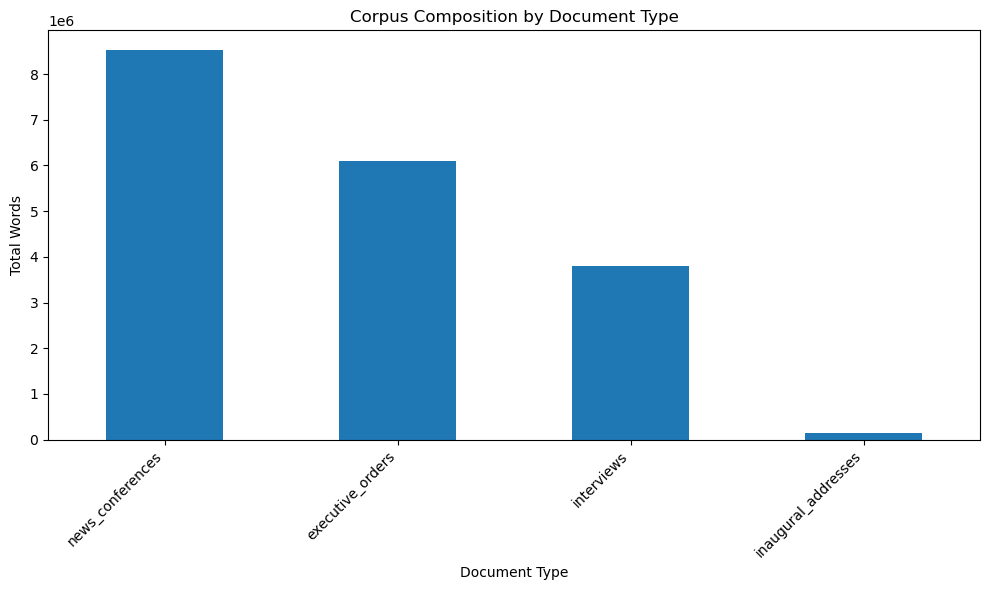

TOTAL WORDS BY DOCUMENT TYPE
document_type
news_conferences       8532571
executive_orders       6092542
interviews             3805892
inaugural_addresses     146021
Name: word_count, dtype: int64

Full corpus words: 18,577,026
Saved to: C:\Users\david\OneDrive\Desktop\DS-GA 1015 - Text As Data\DS-GA 1015 - Project\Final Deliverables\presidents_say_do_corpus_output\corpus_visualizations\01_corpus_composition_by_document_type_words.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "presidents_say_do_corpus_output"
VIZ_DIR = OUTPUT_DIR / "corpus_visualizations"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(OUTPUT_DIR / "full_say_do_document_corpus.csv")

summary = (
    df.groupby("document_type")["word_count"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
summary.plot(kind="bar")
plt.title("Corpus Composition by Document Type")
plt.xlabel("Document Type")
plt.ylabel("Total Words")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

out = VIZ_DIR / "01_corpus_composition_by_document_type_words.png"
plt.savefig(out, dpi=300)
plt.show()

print("TOTAL WORDS BY DOCUMENT TYPE")
print(summary)
print()
print("Full corpus words:", f"{summary.sum():,}")
print("Saved to:", out)

### Say vs Do - Total Words

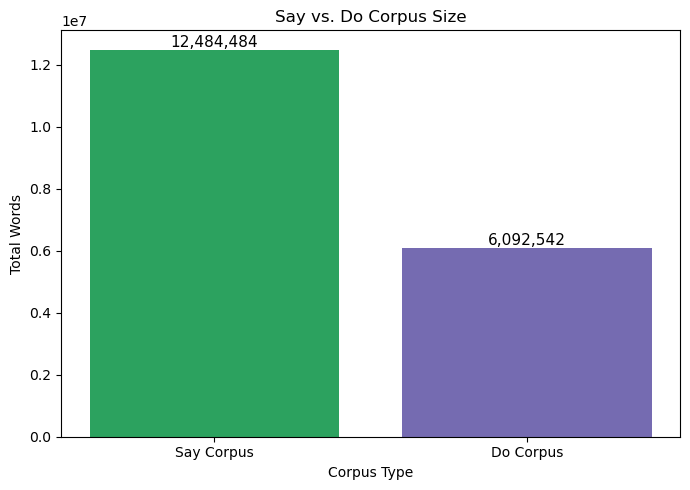

SAY VS. DO TOTAL WORDS
corpus_type
say    12484484
do      6092542
Name: word_count, dtype: int64

Full corpus words: 18,577,026
Saved to: C:\Users\david\OneDrive\Desktop\DS-GA 1015 - Text As Data\DS-GA 1015 - Project\Final Deliverables\presidents_say_do_corpus_output\corpus_visualizations\02_say_vs_do_total_words.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "presidents_say_do_corpus_output"
VIZ_DIR = OUTPUT_DIR / "corpus_visualizations"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(OUTPUT_DIR / "full_say_do_document_corpus.csv")

df["corpus_type"] = df["corpus_type"].str.lower().str.strip()

summary = (
    df.groupby("corpus_type")["word_count"]
    .sum()
    .reindex(["say", "do"])
)

labels = ["Say Corpus", "Do Corpus"]
colors = ["#2CA25F", "#756BB1"]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, summary.values, color=colors)

plt.title("Say vs. Do Corpus Size")
plt.xlabel("Corpus Type")
plt.ylabel("Total Words")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

out = VIZ_DIR / "02_say_vs_do_total_words.png"
plt.savefig(out, dpi=300)
plt.show()

print("SAY VS. DO TOTAL WORDS")
print(summary)
print()
print("Full corpus words:", f"{summary.sum():,}")
print("Saved to:", out)

### Words Per President by Corpus Type

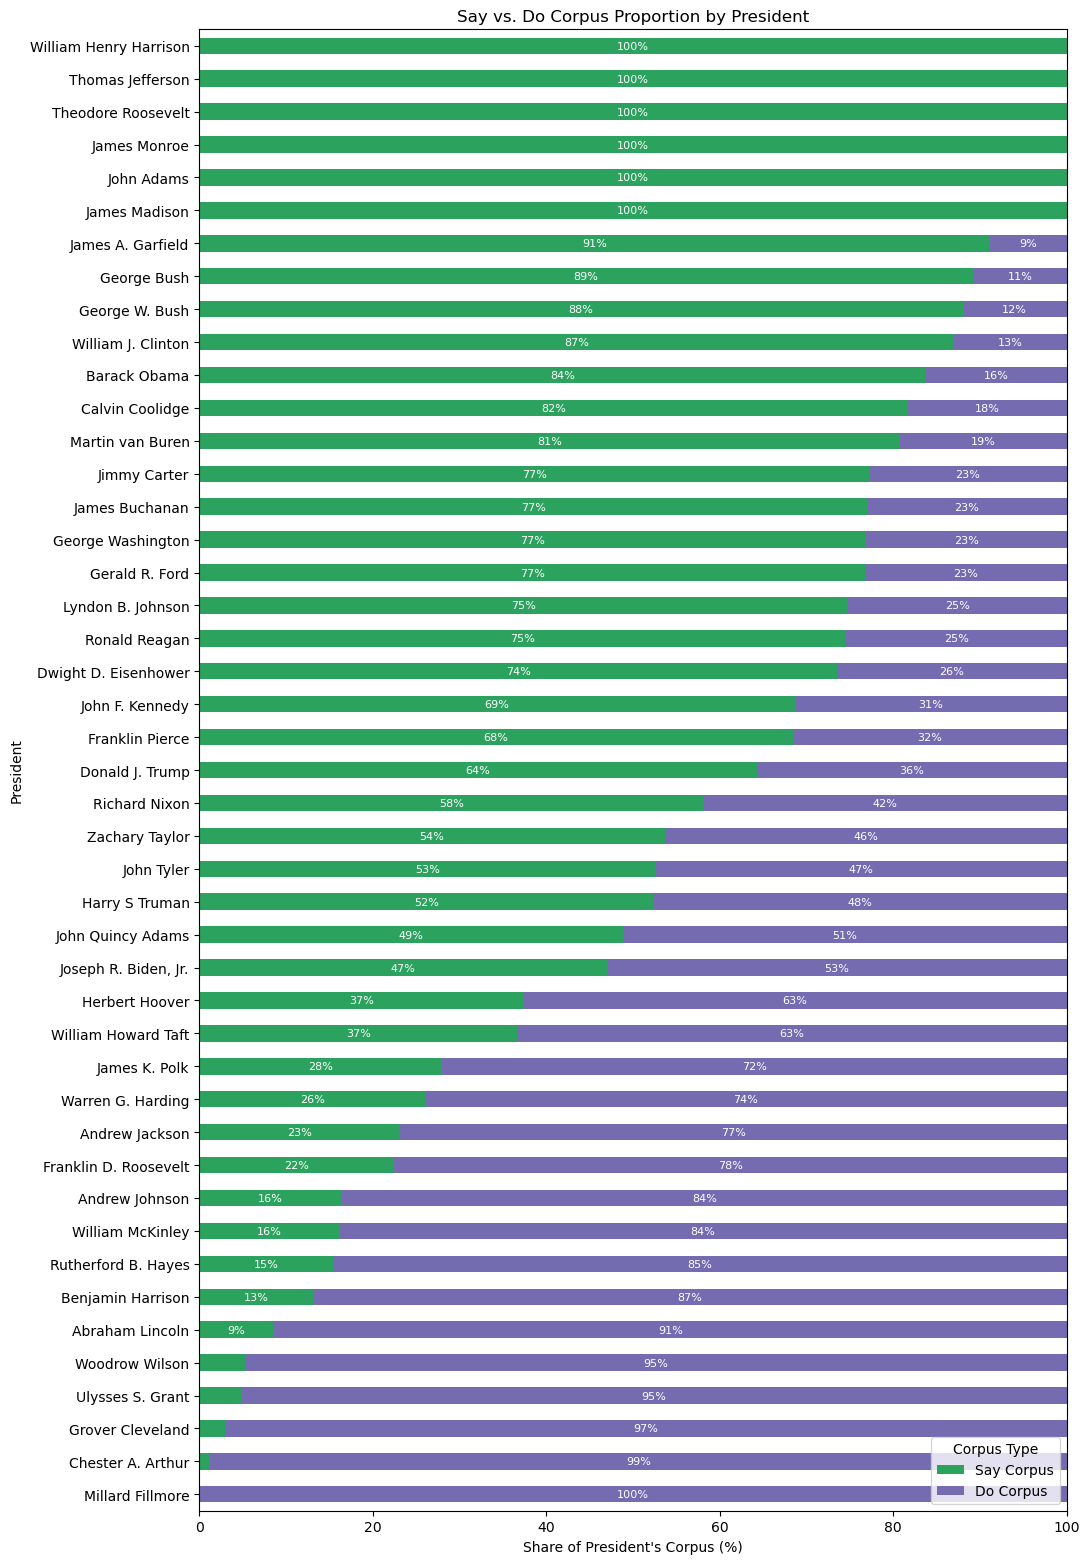

SAY VS. DO WORD PROPORTIONS BY PRESIDENT
corpus_type                   say         do  total_words     say_pct  \
president                                                               
Millard Fillmore              0.0     2472.0       2472.0    0.000000   
Chester A. Arthur           545.0    44784.0      45329.0    1.202321   
Grover Cleveland           3724.0   120708.0     124432.0    2.992799   
Ulysses S. Grant           2929.0    57138.0      60067.0    4.876222   
Woodrow Wilson             3288.0    58697.0      61985.0    5.304509   
Abraham Lincoln            5007.0    53316.0      58323.0    8.584949   
Benjamin Harrison          4402.0    29072.0      33474.0   13.150505   
Rutherford B. Hayes        2489.0    13646.0      16135.0   15.426092   
William McKinley           6206.0    32272.0      38478.0   16.128697   
Andrew Johnson             8027.0    40804.0      48831.0   16.438328   
Franklin D. Roosevelt    407393.0  1410783.0    1818176.0   22.406687   
Andrew Jac

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "presidents_say_do_corpus_output"
VIZ_DIR = OUTPUT_DIR / "corpus_visualizations"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(OUTPUT_DIR / "full_say_do_document_corpus.csv")

df["president"] = df["president"].astype(str).str.strip()
df["corpus_type"] = df["corpus_type"].astype(str).str.lower().str.strip()

summary = (
    df.groupby(["president", "corpus_type"])["word_count"]
    .sum()
    .reset_index()
)

pivot = (
    summary
    .pivot(index="president", columns="corpus_type", values="word_count")
    .fillna(0)
)

for col in ["say", "do"]:
    if col not in pivot.columns:
        pivot[col] = 0

pivot = pivot[["say", "do"]]
pivot["total_words"] = pivot["say"] + pivot["do"]
pivot = pivot[pivot["total_words"] > 0].copy()

pivot["say_pct"] = pivot["say"] / pivot["total_words"] * 100
pivot["do_pct"] = pivot["do"] / pivot["total_words"] * 100

pivot = pivot.sort_values("say_pct", ascending=True)

plot_df = pivot[["say_pct", "do_pct"]]

colors = ["#2CA25F", "#756BB1"]

fig_height = max(6, len(plot_df) * 0.35)

ax = plot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(11, fig_height),
    color=colors
)

plt.title("Say vs. Do Corpus Proportion by President")
plt.xlabel("Share of President's Corpus (%)")
plt.ylabel("President")
plt.xlim(0, 100)
plt.legend(["Say Corpus", "Do Corpus"], title="Corpus Type", loc="lower right")

for i, president in enumerate(plot_df.index):
    say_pct = pivot.loc[president, "say_pct"]
    do_pct = pivot.loc[president, "do_pct"]

    if say_pct >= 6:
        ax.text(
            say_pct / 2,
            i,
            f"{say_pct:.0f}%",
            va="center",
            ha="center",
            fontsize=8,
            color="white"
        )

    if do_pct >= 6:
        ax.text(
            say_pct + do_pct / 2,
            i,
            f"{do_pct:.0f}%",
            va="center",
            ha="center",
            fontsize=8,
            color="white"
        )

plt.tight_layout()

out = VIZ_DIR / "04_words_per_president_say_do_proportions.png"
plt.savefig(out, dpi=300)
plt.show()

print("SAY VS. DO WORD PROPORTIONS BY PRESIDENT")
print(pivot[["say", "do", "total_words", "say_pct", "do_pct"]])
print()
print("Saved to:", out)

### Timeline Coverage

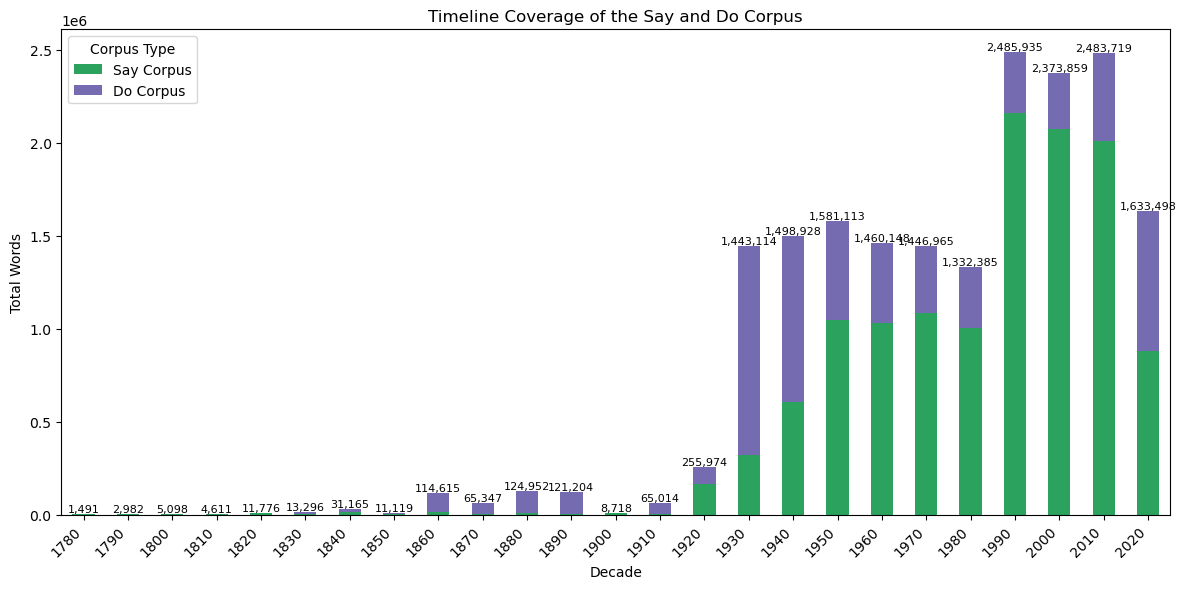

TIMELINE COVERAGE BY TOTAL WORDS
corpus_type        say         do  total_words
decade                                        
1780            1491.0        0.0       1491.0
1790            2488.0      494.0       2982.0
1800            5098.0        0.0       5098.0
1810            4611.0        0.0       4611.0
1820            8544.0     3232.0      11776.0
1830            5032.0     8264.0      13296.0
1840           16069.0    15096.0      31165.0
1850            6233.0     4886.0      11119.0
1860           14173.0   100442.0     114615.0
1870            4279.0    61068.0      65347.0
1880            9632.0   115320.0     124952.0
1890            6004.0   115200.0     121204.0
1900            8718.0        0.0       8718.0
1910            3288.0    61726.0      65014.0
1920          165008.0    90966.0     255974.0
1930          321585.0  1121529.0    1443114.0
1940          604477.0   894451.0    1498928.0
1950         1048464.0   532649.0    1581113.0
1960         1031050.0   42

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
import shutil
import tempfile

try:
    PROJECT_DIR = Path(__file__).resolve().parent
except NameError:
    PROJECT_DIR = Path.cwd()

OUTPUT_DIR = PROJECT_DIR / "presidents_say_do_corpus_output"
VIZ_DIR = OUTPUT_DIR / "corpus_visualizations"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

TIME_BIN = "decade"

DO_PATTERNS = [
    "us_presidents_executive_orders_*_chunked.xlsx",
    "us_presidents_written_presidential_orders*_chunked.xlsx",
    "us_presidents_presidential_orders*_chunked.xlsx"
]

SAY_PATTERNS = [
    "us_presidents_interviews_*_chunked.xlsx",
    "us_presidents_inaugural_addresses_chunked.xlsx",
    "us_presidents_farewell*_chunked.xlsx",
    "us_presidents_speeches*_chunked.xlsx",
    "us_presidents_news_conferences*_chunked.xlsx",
    "us_presidents_news_conferences_chunked.xlsx"
]

TEMP_DIR = Path(tempfile.gettempdir()) / "presidents_say_do_temp"
TEMP_DIR.mkdir(parents=True, exist_ok=True)

def clean_text(x):
    x = str(x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def find_files(project_dir, patterns):
    files = []

    for pattern in patterns:
        files.extend(list(project_dir.rglob(pattern)))

    files = [
        f for f in files
        if f.is_file()
        and f.suffix.lower() == ".xlsx"
        and not f.name.startswith("~$")
        and OUTPUT_DIR not in f.parents
    ]

    return sorted(set(files))

def make_local_copy(file_path):
    safe_name = re.sub(r"[^A-Za-z0-9_.-]", "_", file_path.name)
    local_path = TEMP_DIR / safe_name
    shutil.copy2(file_path, local_path)
    return local_path

def infer_document_type(file_name):
    name = file_name.lower()

    if "executive_order" in name:
        return "executive_orders"
    if "written_presidential_order" in name or "presidential_order" in name:
        return "written_presidential_orders"
    if "interview" in name:
        return "interviews"
    if "inaugural" in name:
        return "inaugural_addresses"
    if "farewell" in name:
        return "farewell_addresses"
    if "speech" in name:
        return "speeches"
    if "news_conference" in name:
        return "news_conferences"

    return "unknown"

def load_file_for_timeline(file_path, corpus_type):
    local_file = make_local_copy(file_path)

    xls = pd.ExcelFile(local_file, engine="openpyxl")

    if "interviews" not in xls.sheet_names:
        raise ValueError(f"{file_path.name} is missing sheet: interviews")

    if "transcript_chunks" not in xls.sheet_names:
        raise ValueError(f"{file_path.name} is missing sheet: transcript_chunks")

    meta = pd.read_excel(local_file, sheet_name="interviews", engine="openpyxl")
    chunks = pd.read_excel(local_file, sheet_name="transcript_chunks", engine="openpyxl")

    meta.columns = [str(c).strip() for c in meta.columns]
    chunks.columns = [str(c).strip() for c in chunks.columns]

    needed_meta = ["interview_id", "date"]
    needed_chunks = ["interview_id", "chunk_text"]

    for col in needed_meta:
        if col not in meta.columns:
            raise ValueError(f"{file_path.name} metadata sheet missing column: {col}")

    for col in needed_chunks:
        if col not in chunks.columns:
            raise ValueError(f"{file_path.name} transcript_chunks sheet missing column: {col}")

    meta = meta[["interview_id", "date"]].copy()
    chunks = chunks[["interview_id", "chunk_text"]].copy()

    meta["interview_id"] = meta["interview_id"].astype(str)
    chunks["interview_id"] = chunks["interview_id"].astype(str)

    df = chunks.merge(meta, on="interview_id", how="left")
    df = df.dropna(subset=["date", "chunk_text"]).copy()

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"]).copy()

    df["chunk_text"] = df["chunk_text"].map(clean_text)
    df["word_count"] = df["chunk_text"].apply(lambda x: len(x.split()))

    df = df[df["chunk_text"].ne("")]
    df = df[df["word_count"] > 0]

    df["year"] = df["date"].dt.year
    df["decade"] = (df["year"] // 10) * 10
    df["corpus_type"] = corpus_type
    df["document_type"] = infer_document_type(file_path.name)
    df["source_file"] = file_path.name

    return df

do_files = find_files(PROJECT_DIR, DO_PATTERNS)
say_files = find_files(PROJECT_DIR, SAY_PATTERNS)

if len(do_files) == 0:
    raise FileNotFoundError("No DO files found.")

if len(say_files) == 0:
    raise FileNotFoundError("No SAY files found.")

timeline_df = pd.concat(
    [load_file_for_timeline(file, "say") for file in say_files] +
    [load_file_for_timeline(file, "do") for file in do_files],
    ignore_index=True
)

if TIME_BIN == "year":
    time_col = "year"
    x_label = "Year"
    out_name = "05_timeline_coverage_total_words_by_year.png"
else:
    time_col = "decade"
    x_label = "Decade"
    out_name = "05_timeline_coverage_total_words_by_decade.png"

summary = (
    timeline_df.groupby([time_col, "corpus_type"])["word_count"]
    .sum()
    .reset_index()
)

pivot = (
    summary
    .pivot(index=time_col, columns="corpus_type", values="word_count")
    .fillna(0)
)

for col in ["say", "do"]:
    if col not in pivot.columns:
        pivot[col] = 0

pivot = pivot[["say", "do"]]
pivot["total_words"] = pivot["say"] + pivot["do"]
pivot = pivot.sort_index()

plot_df = pivot[["say", "do"]]

colors = ["#2CA25F", "#756BB1"]

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=colors
)

plt.title("Timeline Coverage of the Say and Do Corpus")
plt.xlabel(x_label)
plt.ylabel("Total Words")
plt.legend(["Say Corpus", "Do Corpus"], title="Corpus Type")
plt.xticks(rotation=45, ha="right")

for i, total in enumerate(pivot["total_words"]):
    ax.text(
        i,
        total,
        f"{int(total):,}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()

out = VIZ_DIR / out_name
plt.savefig(out, dpi=300)
plt.show()

print("TIMELINE COVERAGE BY TOTAL WORDS")
print(pivot)
print()
print("Full corpus words in timeline:", f'{pivot["total_words"].sum():,}')
print("Saved to:", out)

### Document Length Distribution by Document Type

C:\Users\david\AppData\Local\Temp\ipykernel_2064\957281107.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


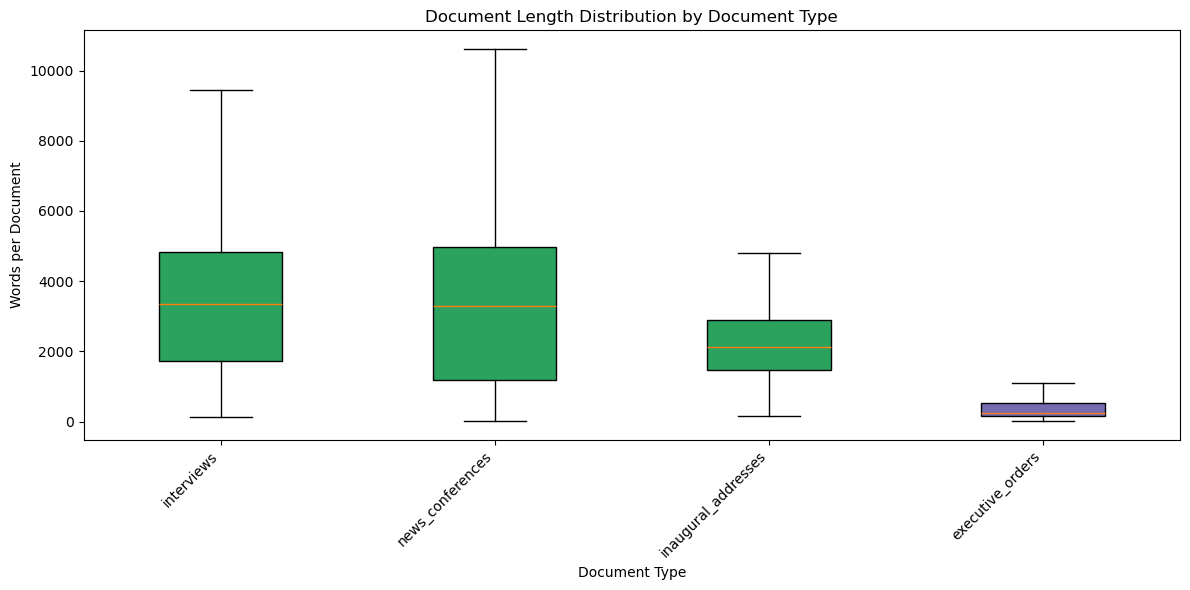

DOCUMENT LENGTH DISTRIBUTION BY DOCUMENT TYPE
                                   count         mean          std    min  \
document_type       corpus_type                                             
executive_orders    do           11328.0   537.830332  1138.578929   19.0   
inaugural_addresses say             63.0  2317.793651  1373.182378  152.0   
interviews          say           1029.0  3698.631681  2699.982621  138.0   
news_conferences    say           2527.0  3376.561535  2529.445444   17.0   

                                    25%     50%      75%      max  
document_type       corpus_type                                    
executive_orders    do            157.0   256.0   528.25  52136.0  
inaugural_addresses say          1469.0  2137.0  2881.00   8443.0  
interviews          say          1714.0  3335.0  4839.00  37533.0  
news_conferences    say          1184.0  3283.0  4985.50  17909.0  

Saved to: C:\Users\david\OneDrive\Desktop\DS-GA 1015 - Text As Data\DS-GA 1015 - P

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "presidents_say_do_corpus_output"
VIZ_DIR = OUTPUT_DIR / "corpus_visualizations"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(OUTPUT_DIR / "full_say_do_document_corpus.csv")

df["president"] = df["president"].astype(str).str.strip()
df["corpus_type"] = df["corpus_type"].astype(str).str.lower().str.strip()
df["document_type"] = df["document_type"].astype(str).str.strip()
df["source_file"] = df["source_file"].astype(str).str.strip()
df["document_id"] = df["document_id"].astype(str).str.strip()

df["doc_key"] = df["source_file"] + "__" + df["document_id"]

doc_lengths = (
    df.groupby(["doc_key", "corpus_type", "document_type"])["word_count"]
    .sum()
    .reset_index(name="document_word_count")
)

order = (
    doc_lengths.groupby("document_type")["document_word_count"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

data = [
    doc_lengths.loc[
        doc_lengths["document_type"] == doc_type,
        "document_word_count"
    ]
    for doc_type in order
]

corpus_lookup = (
    doc_lengths.groupby("document_type")["corpus_type"]
    .first()
    .to_dict()
)

colors = [
    "#2CA25F" if corpus_lookup[doc_type] == "say" else "#756BB1"
    for doc_type in order
]

plt.figure(figsize=(12, 6))

box = plt.boxplot(
    data,
    labels=order,
    patch_artist=True,
    showfliers=False
)

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

plt.title("Document Length Distribution by Document Type")
plt.xlabel("Document Type")
plt.ylabel("Words per Document")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

out = VIZ_DIR / "06_document_length_distribution_by_document_type.png"
plt.savefig(out, dpi=300)
plt.show()

print("DOCUMENT LENGTH DISTRIBUTION BY DOCUMENT TYPE")
print(
    doc_lengths
    .groupby(["document_type", "corpus_type"])["document_word_count"]
    .describe()
)

print()
print("Saved to:", out)

# Part 3 - Methodology

## Pre-Processing

### Basic Text Cleaning

Reading file from:
C:\Users\david\OneDrive\Desktop\DS-GA 1015 - Text As Data\DS-GA 1015 - Project\Final Deliverables\presidents_say_do_corpus_output\full_say_do_document_corpus.csv

BASIC TEXT CLEANING COMPLETE

INPUT AUDIT
Rows in CSV: 14947
Usable rows: 14947
Text column: text
President column: president
Document ID column: document_id
Document type column: document_type
Side column: corpus_type

NOISE TYPES REMOVED / STANDARDIZED
side                 noise_type  count_removed_or_standardized
  Do               urls_removed                          11022
 Say               urls_removed                           3310
  Do        line_breaks_removed                              0
 Say        line_breaks_removed                              0
  Do    repeated_spaces_removed                              0
 Say    repeated_spaces_removed                              0
  Do     html_artifacts_removed                             16
 Say     html_artifacts_removed                            

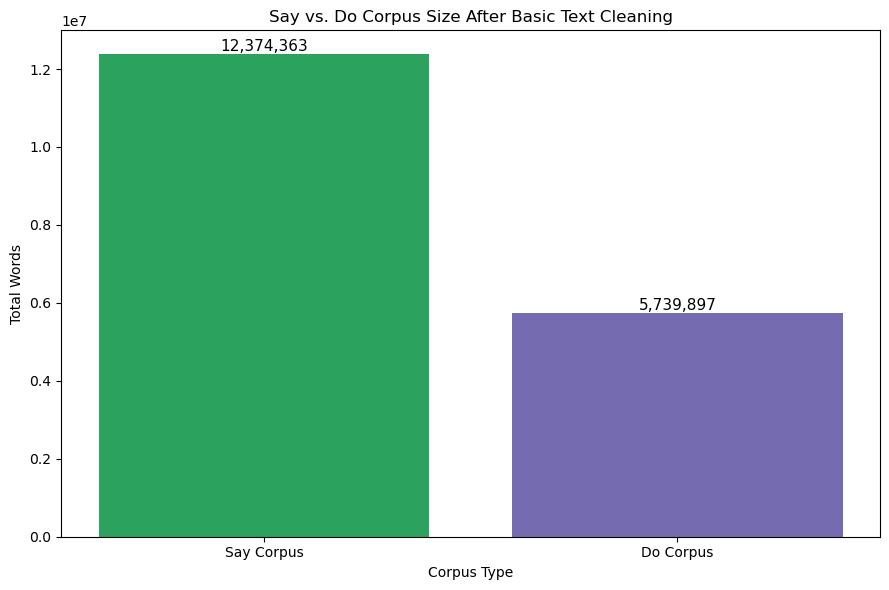

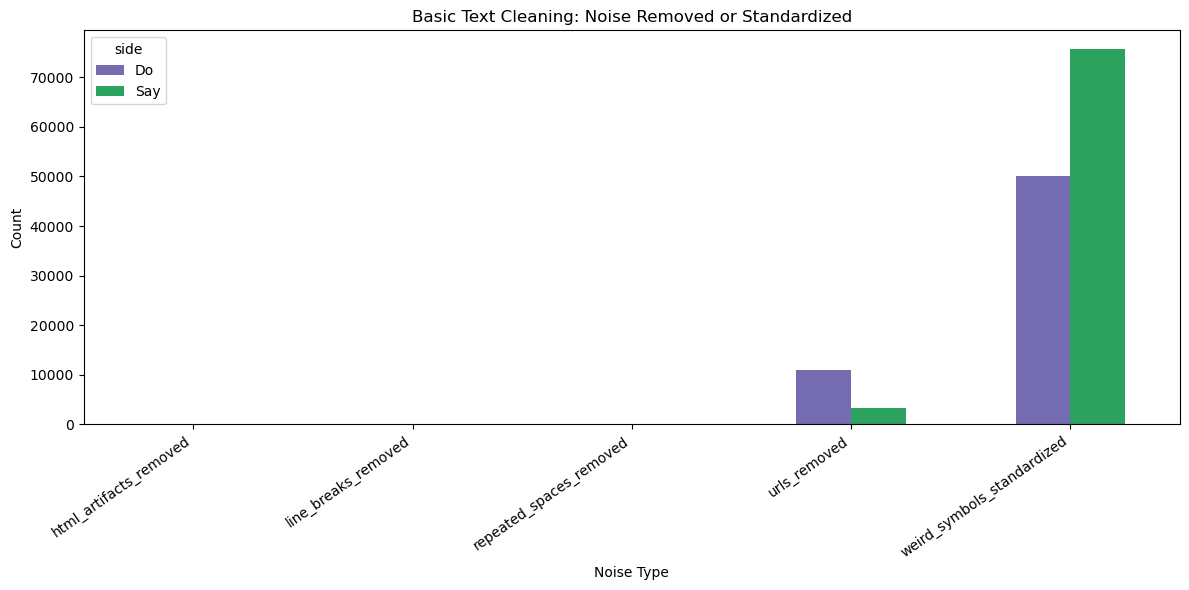

In [14]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "presidents_say_do_corpus_output"
INPUT_FILE = OUTPUT_DIR / "full_say_do_document_corpus.csv"

TEXT_CANDIDATES = [
    "full_document_text",
    "document_text",
    "text",
    "clean_text",
    "clean_text_basic",
    "chunk_text",
    "transcript",
    "content",
    "body",
    "full_text"
]

PRESIDENT_CANDIDATES = ["president", "speaker", "name"]

DOC_ID_CANDIDATES = [
    "document_id",
    "interview_id",
    "doc_id",
    "id"
]

DOC_TYPE_CANDIDATES = [
    "document_type",
    "doc_type",
    "type",
    "source_type",
    "collection"
]

SIDE_CANDIDATES = [
    "side",
    "corpus",
    "corpus_type",
    "say_do",
    "category",
    "group"
]


def clean_column_name(col):
    col = str(col).strip().lower()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col


def find_column(df, candidates):
    for candidate in candidates:
        if candidate in df.columns:
            return candidate
    return None


def find_text_column(df):
    exact = find_column(df, TEXT_CANDIDATES)

    if exact is not None:
        return exact

    for col in df.columns:
        col_lower = str(col).lower()

        if any(x in col_lower for x in ["text", "chunk", "transcript", "content", "body"]):
            if not any(x in col_lower for x in ["id", "url", "len", "count"]):
                return col

    return None


def classify_side(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    if "say" in value:
        return "Say"

    if "do" in value:
        return "Do"

    if any(x in value for x in ["speech", "interview", "inaugural", "farewell", "news conference", "remarks"]):
        return "Say"

    if any(x in value for x in ["executive", "written presidential", "order", "memorandum", "proclamation"]):
        return "Do"

    return np.nan


def count_words(text):
    return len(re.findall(r"\b[a-zA-Z][a-zA-Z'-]*\b", str(text)))


def count_urls(text):
    return len(re.findall(r"http\S+|www\S+", str(text)))


def count_line_breaks(text):
    return str(text).count("\n")


def count_repeated_spaces(text):
    return len(re.findall(r" {2,}", str(text)))


def count_html_artifacts(text):
    return len(re.findall(r"&[a-zA-Z]+;|<[^>]+>", str(text)))


def count_weird_symbols(text):
    return len(re.findall(r"[^\x00-\x7F]", str(text)))


def basic_clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    text = re.sub(r"http\S+|www\S+", " ", text)

    text = re.sub(r"&amp;", " and ", text)
    text = re.sub(r"&quot;", '"', text)
    text = re.sub(r"&apos;", "'", text)
    text = re.sub(r"&lt;", " ", text)
    text = re.sub(r"&gt;", " ", text)
    text = re.sub(r"&nbsp;", " ", text)

    text = re.sub(r"<[^>]+>", " ", text)

    text = text.replace("\r", " ")
    text = text.replace("\n", " ")

    text = text.replace("“", '"').replace("”", '"')
    text = text.replace("‘", "'").replace("’", "'")
    text = text.replace("—", "-").replace("–", "-")

    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text


print("Reading file from:")
print(INPUT_FILE)

if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Input file not found: {INPUT_FILE}")

df = pd.read_csv(INPUT_FILE)

if df.empty:
    raise ValueError("CSV file is empty.")

df.columns = [clean_column_name(c) for c in df.columns]

text_col = find_text_column(df)
president_col = find_column(df, PRESIDENT_CANDIDATES)
doc_id_col = find_column(df, DOC_ID_CANDIDATES)
doc_type_col = find_column(df, DOC_TYPE_CANDIDATES)
side_col = find_column(df, SIDE_CANDIDATES)

if text_col is None:
    raise ValueError(f"No text column found. Available columns: {list(df.columns)}")

if president_col is None:
    raise ValueError(f"No president column found. Available columns: {list(df.columns)}")

if doc_id_col is None:
    df["document_id"] = df.index.astype(str)
    doc_id_col = "document_id"

if doc_type_col is None:
    df["document_type"] = "Unknown"
    doc_type_col = "document_type"

if side_col is None:
    raise ValueError(f"No Say/Do side column found. Available columns: {list(df.columns)}")

corpus = pd.DataFrame()
corpus["source_file"] = df["source_file"].astype(str).str.strip() if "source_file" in df.columns else INPUT_FILE.name
corpus["side"] = df[side_col].apply(classify_side)
corpus["raw_text"] = df[text_col].fillna("").astype(str)
corpus["president"] = df[president_col].astype(str).str.strip()
corpus["document_id"] = df[doc_id_col].astype(str)
corpus["document_type"] = df[doc_type_col].astype(str).str.strip()

corpus = corpus[
    (corpus["side"].isin(["Say", "Do"])) &
    (corpus["raw_text"].str.len() > 0) &
    (corpus["president"].str.lower() != "unknown")
].copy()

if len(corpus) == 0:
    raise ValueError("No usable Say/Do rows found in the CSV.")

corpus["clean_text_basic"] = corpus["raw_text"].apply(basic_clean_text)

corpus["raw_word_count"] = corpus["raw_text"].apply(count_words)
corpus["clean_word_count"] = corpus["clean_text_basic"].apply(count_words)

corpus["raw_char_count"] = corpus["raw_text"].str.len()
corpus["clean_char_count"] = corpus["clean_text_basic"].str.len()

corpus["urls_removed"] = corpus["raw_text"].apply(count_urls)
corpus["line_breaks_removed"] = corpus["raw_text"].apply(count_line_breaks)
corpus["repeated_spaces_removed"] = corpus["raw_text"].apply(count_repeated_spaces)
corpus["html_artifacts_removed"] = corpus["raw_text"].apply(count_html_artifacts)
corpus["weird_symbols_standardized"] = corpus["raw_text"].apply(count_weird_symbols)

corpus["word_count_change"] = corpus["clean_word_count"] - corpus["raw_word_count"]
corpus["char_count_change"] = corpus["clean_char_count"] - corpus["raw_char_count"]

summary = (
    corpus
    .groupby("side", as_index=False)
    .agg(
        documents=("document_id", "count"),
        unique_presidents=("president", "nunique"),
        raw_words=("raw_word_count", "sum"),
        clean_words=("clean_word_count", "sum"),
        word_change=("word_count_change", "sum"),
        raw_chars=("raw_char_count", "sum"),
        clean_chars=("clean_char_count", "sum"),
        char_change=("char_count_change", "sum"),
        urls_removed=("urls_removed", "sum"),
        line_breaks_removed=("line_breaks_removed", "sum"),
        repeated_spaces_removed=("repeated_spaces_removed", "sum"),
        html_artifacts_removed=("html_artifacts_removed", "sum"),
        weird_symbols_standardized=("weird_symbols_standardized", "sum")
    )
)

summary["word_change_pct"] = np.where(
    summary["raw_words"] > 0,
    summary["word_change"] / summary["raw_words"] * 100,
    0
)

summary["char_change_pct"] = np.where(
    summary["raw_chars"] > 0,
    summary["char_change"] / summary["raw_chars"] * 100,
    0
)

noise_summary = summary[
    [
        "side",
        "urls_removed",
        "line_breaks_removed",
        "repeated_spaces_removed",
        "html_artifacts_removed",
        "weird_symbols_standardized"
    ]
].melt(
    id_vars="side",
    var_name="noise_type",
    value_name="count_removed_or_standardized"
)

noise_summary["count_removed_or_standardized"] = pd.to_numeric(
    noise_summary["count_removed_or_standardized"],
    errors="coerce"
).fillna(0)

print("\nBASIC TEXT CLEANING COMPLETE")

print("\nINPUT AUDIT")
print("Rows in CSV:", len(df))
print("Usable rows:", len(corpus))
print("Text column:", text_col)
print("President column:", president_col)
print("Document ID column:", doc_id_col)
print("Document type column:", doc_type_col)
print("Side column:", side_col)

print("\nNOISE TYPES REMOVED / STANDARDIZED")
print(noise_summary.to_string(index=False))

print("\nBEFORE / AFTER QUICK CHECK")
sample = corpus[
    [
        "side",
        "president",
        "document_id",
        "raw_word_count",
        "clean_word_count",
        "raw_text",
        "clean_text_basic"
    ]
].sample(min(3, len(corpus)), random_state=42)

for i, row in sample.iterrows():
    print("\n" + "=" * 100)
    print("SIDE:", row["side"])
    print("PRESIDENT:", row["president"])
    print("DOCUMENT ID:", row["document_id"])
    print("RAW WORDS:", row["raw_word_count"])
    print("CLEAN WORDS:", row["clean_word_count"])

    print("\nRAW TEXT PREVIEW:")
    print(row["raw_text"][:700])

    print("\nCLEAN TEXT PREVIEW:")
    print(row["clean_text_basic"][:700])

plot_df = summary.copy()
plot_df["corpus_label"] = plot_df["side"].map({
    "Say": "Say Corpus",
    "Do": "Do Corpus"
})

plot_df = plot_df.set_index("corpus_label").loc[["Say Corpus", "Do Corpus"]].reset_index()

colors = ["#2ca25f", "#756bb1"]

plt.figure(figsize=(9, 6))
bars = plt.bar(
    plot_df["corpus_label"],
    plot_df["clean_words"],
    color=colors
)

plt.title("Say vs. Do Corpus Size After Basic Text Cleaning")
plt.xlabel("Corpus Type")
plt.ylabel("Total Words")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

pivot_noise = noise_summary.pivot_table(
    index="noise_type",
    columns="side",
    values="count_removed_or_standardized",
    aggfunc="sum",
    fill_value=0
)

pivot_noise = pivot_noise.apply(pd.to_numeric, errors="coerce").fillna(0)

if pivot_noise.shape[0] > 0 and pivot_noise.to_numpy().sum() > 0:
    ax = pivot_noise.plot(
        kind="bar",
        figsize=(12, 6),
        color=["#756bb1" if col == "Do" else "#2ca25f" for col in pivot_noise.columns]
    )

    ax.set_title("Basic Text Cleaning: Noise Removed or Standardized")
    ax.set_xlabel("Noise Type")
    ax.set_ylabel("Count")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo removable technical noise found for noise plot.")

### Executive-Order Boilerplate Removal

Reading file from:
C:\Users\david\OneDrive\Desktop\DS-GA 1015 - Text As Data\DS-GA 1015 - Project\Final Deliverables\presidents_say_do_corpus_output\full_say_do_document_corpus.csv

EXECUTIVE-ORDER BOILERPLATE REMOVAL COMPLETE

Class connection: Preprocessing + measurement confounding.
Loaded from full_say_do_document_corpus.csv.

This step removes legal/executive-order boilerplate mainly from the Do corpus.

INPUT AUDIT
Rows in CSV: 14947
Usable rows: 14947
Text column: text
President column: president
Document ID column: document_id
Document type column: document_type
Side column: corpus_type

SUMMARY BY CORPUS
side  documents  unique_presidents  raw_words  words_after_basic_cleaning  words_after_boilerplate_removal  boilerplate_words_removed  boilerplate_hits  boilerplate_words_removed_pct_from_basic_cleaning
  Do      11328                 39    5809670                     5739897                          4973915                     765982             82915                         

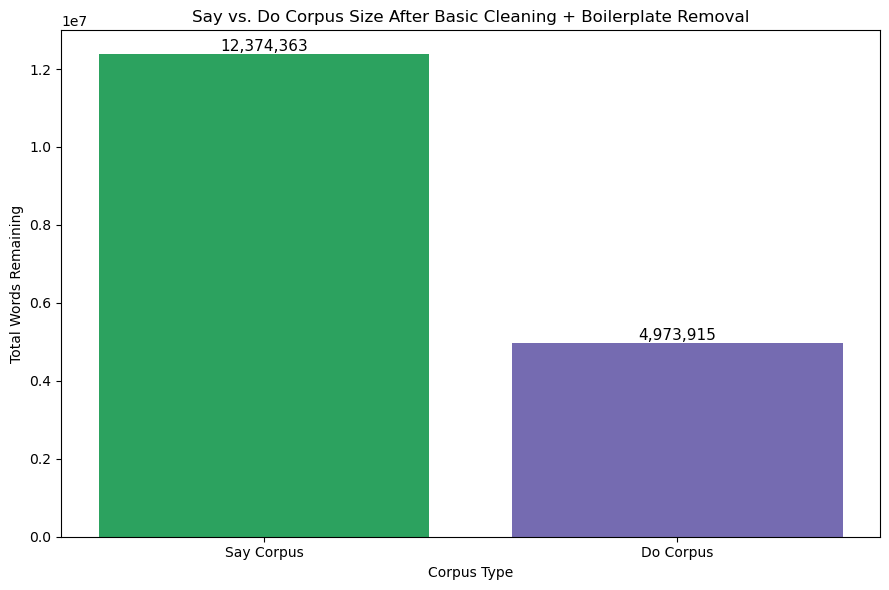

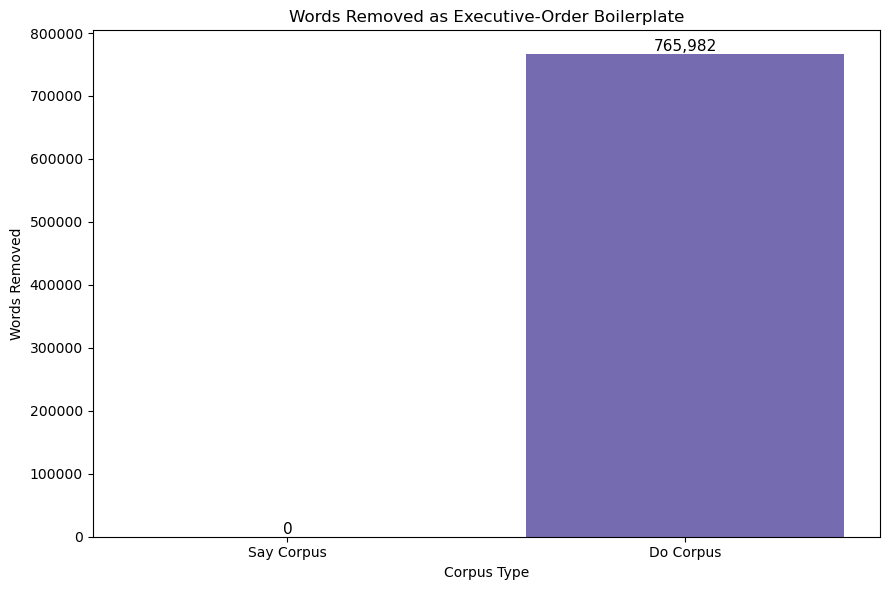

In [15]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "presidents_say_do_corpus_output"
INPUT_FILE = OUTPUT_DIR / "full_say_do_document_corpus.csv"

TEXT_CANDIDATES = [
    "full_document_text",
    "document_text",
    "text",
    "clean_text",
    "clean_text_basic",
    "chunk_text",
    "transcript",
    "content",
    "body",
    "full_text"
]

PRESIDENT_CANDIDATES = ["president", "speaker", "name"]

DOC_ID_CANDIDATES = [
    "document_id",
    "interview_id",
    "doc_id",
    "id"
]

DOC_TYPE_CANDIDATES = [
    "document_type",
    "doc_type",
    "type",
    "source_type",
    "collection"
]

SIDE_CANDIDATES = [
    "side",
    "corpus",
    "corpus_type",
    "say_do",
    "category",
    "group"
]

BOILERPLATE_PATTERNS = [
    ("authority vested clause", r"\bby (the )?(authority|virtue) vested in me\b.{0,180}?\bit is hereby ordered\b"),
    ("hereby ordered phrase", r"\bit is hereby ordered as follows\b"),
    ("pursuant to legal authority", r"\bpursuant to\b.{0,120}?\b(this order|this act|the act|section|statute|law)\b"),
    ("general provisions header", r"\bsec\.?\s*\d+\.?\s*general provisions\b"),
    ("nothing in this order clause", r"\bnothing in this order shall be construed to\b.{0,500}?(?=\b\([a-z0-9ivx]+\)|\bsec\.|\bsection\b|$)"),
    ("implemented consistent with law", r"\bthis order shall be implemented consistent with applicable law\b.{0,250}?(?=\b\([a-z0-9ivx]+\)|\bsec\.|\bsection\b|$)"),
    ("no right or benefit clause", r"\bthis order is not intended to\b.{0,500}?\bany other person\b\.?"),
    ("omb budgetary clause", r"\bfunctions of the director of the office of management and budget\b.{0,250}?(?=\b\([a-z0-9ivx]+\)|\bsec\.|\bsection\b|$)"),
    ("availability of appropriations", r"\bsubject to the availability of appropriations\b"),
    ("federal register note", r"\bnote:\s*this executive order was published in the federal register\b.{0,250}?(?=\b[A-Z][a-z]+ [A-Z][a-z]+,|\b[A-Z]{2,}|$)"),
    ("american presidency project footer", r"\bOnline by Gerhard Peters and John T\. Woolley\b.{0,300}$"),
    ("presidency project url", r"\bThe American Presidency Project\s+https?://\S+"),
    ("white house signature line", r"\bThe White House,\s+[A-Z][a-z]+ \d{1,2}, \d{4}\.?"),
    ("executive order citation footer", r"\b[A-Z][A-Za-z\.\s]+,\s+Executive Order\s+\d+[A-Za-z]?\b.{0,300}$"),
    ("secretary shall administrative instruction", r"\b(the )?secretar(y|ies) of\b.{0,160}?\bshall\b"),
    ("department shall administrative instruction", r"\b(the )?(department|agency|agencies|office|offices)\b.{0,120}?\bshall\b"),
    ("date of this order deadline", r"\bwithin \d+ days of the date of this order\b"),
    ("this order administrative reference", r"\b(this order|the order|such order)\b")
]


def clean_column_name(col):
    col = str(col).strip().lower()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col


def find_column(df, candidates):
    for candidate in candidates:
        if candidate in df.columns:
            return candidate
    return None


def find_text_column(df):
    exact = find_column(df, TEXT_CANDIDATES)

    if exact is not None:
        return exact

    for col in df.columns:
        col_lower = str(col).lower()

        if any(x in col_lower for x in ["text", "chunk", "transcript", "content", "body"]):
            if not any(x in col_lower for x in ["id", "url", "len", "count"]):
                return col

    return None


def classify_side(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    if "say" in value:
        return "Say"

    if "do" in value:
        return "Do"

    if any(x in value for x in ["speech", "interview", "inaugural", "farewell", "news conference", "remarks"]):
        return "Say"

    if any(x in value for x in ["executive", "written presidential", "order", "memorandum", "proclamation"]):
        return "Do"

    return np.nan


def count_words(text):
    return len(re.findall(r"\b[a-zA-Z][a-zA-Z'-]*\b", str(text)))


def basic_clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    text = re.sub(r"http\S+|www\S+", " ", text)

    text = re.sub(r"&amp;", " and ", text)
    text = re.sub(r"&quot;", '"', text)
    text = re.sub(r"&apos;", "'", text)
    text = re.sub(r"&lt;", " ", text)
    text = re.sub(r"&gt;", " ", text)
    text = re.sub(r"&nbsp;", " ", text)

    text = re.sub(r"<[^>]+>", " ", text)

    text = text.replace("\r", " ")
    text = text.replace("\n", " ")

    text = text.replace("“", '"').replace("”", '"')
    text = text.replace("‘", "'").replace("’", "'")
    text = text.replace("—", "-").replace("–", "-")

    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text


def remove_boilerplate_from_do_text(text):
    if pd.isna(text):
        return ""

    cleaned = str(text)

    for label, pattern in BOILERPLATE_PATTERNS:
        cleaned = re.sub(
            pattern,
            " ",
            cleaned,
            flags=re.IGNORECASE | re.DOTALL
        )

    cleaned = re.sub(r"\s+", " ", cleaned)
    cleaned = cleaned.strip()

    return cleaned


def remove_boilerplate_conditionally(row):
    if row["side"] == "Do":
        return remove_boilerplate_from_do_text(row["clean_text_basic"])
    return row["clean_text_basic"]


def count_boilerplate_hits(text):
    text = str(text)
    total = 0
    detail = {}

    for label, pattern in BOILERPLATE_PATTERNS:
        hits = len(re.findall(pattern, text, flags=re.IGNORECASE | re.DOTALL))
        detail[label] = hits
        total += hits

    return total, detail


def compact_boilerplate_detail(detail, n=8):
    keep = [(k, v) for k, v in detail.items() if v > 0]
    keep = sorted(keep, key=lambda x: x[1], reverse=True)

    if len(keep) == 0:
        return ""

    return ", ".join([f"{k} ({v})" for k, v in keep[:n]])


print("Reading file from:")
print(INPUT_FILE)

if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Input file not found: {INPUT_FILE}")

df = pd.read_csv(INPUT_FILE)

if df.empty:
    raise ValueError("CSV file is empty.")

df.columns = [clean_column_name(c) for c in df.columns]

text_col = find_text_column(df)
president_col = find_column(df, PRESIDENT_CANDIDATES)
doc_id_col = find_column(df, DOC_ID_CANDIDATES)
doc_type_col = find_column(df, DOC_TYPE_CANDIDATES)
side_col = find_column(df, SIDE_CANDIDATES)

if text_col is None:
    raise ValueError(f"No text column found. Available columns: {list(df.columns)}")

if president_col is None:
    raise ValueError(f"No president column found. Available columns: {list(df.columns)}")

if doc_id_col is None:
    df["document_id"] = df.index.astype(str)
    doc_id_col = "document_id"

if doc_type_col is None:
    df["document_type"] = "Unknown"
    doc_type_col = "document_type"

if side_col is None:
    raise ValueError(f"No Say/Do side column found. Available columns: {list(df.columns)}")

corpus = pd.DataFrame()
corpus["source_file"] = df["source_file"].astype(str).str.strip() if "source_file" in df.columns else INPUT_FILE.name
corpus["side"] = df[side_col].apply(classify_side)
corpus["raw_text"] = df[text_col].fillna("").astype(str)
corpus["president"] = df[president_col].astype(str).str.strip()
corpus["document_id"] = df[doc_id_col].astype(str)
corpus["document_type"] = df[doc_type_col].astype(str).str.strip()

corpus = corpus[
    (corpus["side"].isin(["Say", "Do"])) &
    (corpus["raw_text"].str.len() > 0) &
    (corpus["president"].str.lower() != "unknown")
].copy()

if len(corpus) == 0:
    raise ValueError("No usable Say/Do rows found in the CSV.")

corpus["clean_text_basic"] = corpus["raw_text"].apply(basic_clean_text)

boilerplate_results = corpus["clean_text_basic"].apply(count_boilerplate_hits)
corpus["boilerplate_hits"] = boilerplate_results.apply(lambda x: x[0])
corpus["boilerplate_hit_details"] = boilerplate_results.apply(lambda x: compact_boilerplate_detail(x[1]))

corpus["clean_text_no_boilerplate"] = corpus.apply(remove_boilerplate_conditionally, axis=1)

corpus["raw_word_count"] = corpus["raw_text"].apply(count_words)
corpus["basic_clean_word_count"] = corpus["clean_text_basic"].apply(count_words)
corpus["no_boilerplate_word_count"] = corpus["clean_text_no_boilerplate"].apply(count_words)

corpus["basic_to_no_boilerplate_word_change"] = (
    corpus["no_boilerplate_word_count"] - corpus["basic_clean_word_count"]
)

corpus["boilerplate_words_removed"] = (
    corpus["basic_clean_word_count"] - corpus["no_boilerplate_word_count"]
)

summary = (
    corpus
    .groupby("side", as_index=False)
    .agg(
        documents=("document_id", "count"),
        unique_presidents=("president", "nunique"),
        raw_words=("raw_word_count", "sum"),
        words_after_basic_cleaning=("basic_clean_word_count", "sum"),
        words_after_boilerplate_removal=("no_boilerplate_word_count", "sum"),
        boilerplate_words_removed=("boilerplate_words_removed", "sum"),
        boilerplate_hits=("boilerplate_hits", "sum")
    )
)

summary["boilerplate_words_removed_pct_from_basic_cleaning"] = np.where(
    summary["words_after_basic_cleaning"] > 0,
    summary["boilerplate_words_removed"] / summary["words_after_basic_cleaning"] * 100,
    0
)

print("\nEXECUTIVE-ORDER BOILERPLATE REMOVAL COMPLETE")
print("\nClass connection: Preprocessing + measurement confounding.")
print("Loaded from full_say_do_document_corpus.csv.")
print("\nThis step removes legal/executive-order boilerplate mainly from the Do corpus.")

print("\nINPUT AUDIT")
print("Rows in CSV:", len(df))
print("Usable rows:", len(corpus))
print("Text column:", text_col)
print("President column:", president_col)
print("Document ID column:", doc_id_col)
print("Document type column:", doc_type_col)
print("Side column:", side_col)

print("\nSUMMARY BY CORPUS")
print(summary.to_string(index=False))

print("\nTOP DO DOCUMENTS WITH MOST BOILERPLATE REMOVED")
top_removed = (
    corpus[corpus["side"] == "Do"]
    .sort_values("boilerplate_words_removed", ascending=False)
    [
        [
            "president",
            "document_id",
            "document_type",
            "basic_clean_word_count",
            "no_boilerplate_word_count",
            "boilerplate_words_removed",
            "boilerplate_hits",
            "boilerplate_hit_details"
        ]
    ]
    .head(10)
)

print(top_removed.to_string(index=False))

print("\nBEFORE / AFTER BOILERPLATE REMOVAL QUICK CHECK")
sample = (
    corpus[
        (corpus["side"] == "Do") &
        (corpus["boilerplate_words_removed"] > 0)
    ]
    [
        [
            "side",
            "president",
            "document_id",
            "basic_clean_word_count",
            "no_boilerplate_word_count",
            "boilerplate_words_removed",
            "clean_text_basic",
            "clean_text_no_boilerplate"
        ]
    ]
    .head(3)
)

if len(sample) == 0:
    print("No Do documents had boilerplate removed.")
else:
    for i, row in sample.iterrows():
        print("\n" + "=" * 100)
        print("SIDE:", row["side"])
        print("PRESIDENT:", row["president"])
        print("DOCUMENT ID:", row["document_id"])
        print("WORDS AFTER BASIC CLEANING:", row["basic_clean_word_count"])
        print("WORDS AFTER BOILERPLATE REMOVAL:", row["no_boilerplate_word_count"])
        print("WORDS REMOVED:", row["boilerplate_words_removed"])

        print("\nBEFORE BOILERPLATE REMOVAL PREVIEW:")
        print(row["clean_text_basic"][:900])

        print("\nAFTER BOILERPLATE REMOVAL PREVIEW:")
        print(row["clean_text_no_boilerplate"][:900])

plot_df = summary.copy()
plot_df["corpus_label"] = plot_df["side"].map({
    "Say": "Say Corpus",
    "Do": "Do Corpus"
})

plot_df = plot_df.set_index("corpus_label").loc[["Say Corpus", "Do Corpus"]].reset_index()

colors = ["#2ca25f", "#756bb1"]

plt.figure(figsize=(9, 6))
bars = plt.bar(
    plot_df["corpus_label"],
    plot_df["words_after_boilerplate_removal"],
    color=colors
)

plt.title("Say vs. Do Corpus Size After Basic Cleaning + Boilerplate Removal")
plt.xlabel("Corpus Type")
plt.ylabel("Total Words Remaining")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

removed_plot = summary.copy()
removed_plot["corpus_label"] = removed_plot["side"].map({
    "Say": "Say Corpus",
    "Do": "Do Corpus"
})

removed_plot = removed_plot.set_index("corpus_label").loc[["Say Corpus", "Do Corpus"]].reset_index()

plt.figure(figsize=(9, 6))
bars = plt.bar(
    removed_plot["corpus_label"],
    removed_plot["boilerplate_words_removed"],
    color=colors
)

plt.title("Words Removed as Executive-Order Boilerplate")
plt.xlabel("Corpus Type")
plt.ylabel("Words Removed")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

### Negation Standardization

Reading file from:
C:\Users\david\OneDrive\Desktop\DS-GA 1015 - Text As Data\DS-GA 1015 - Project\Final Deliverables\presidents_say_do_corpus_output\full_say_do_document_corpus.csv

PREPROCESSING PIPELINE COMPLETE

Steps completed:
1. Basic text cleaning
2. Executive-order boilerplate removal
3. Negation standardization

Loaded from full_say_do_document_corpus.csv.

INPUT AUDIT
Rows in CSV: 14947
Usable rows: 14947
Text column: text
President column: president
Document ID column: document_id
Document type column: document_type
Side column: corpus_type

WORDS REMAINING AFTER EACH PREPROCESSING STEP
side  documents  unique_presidents  raw_words  words_after_basic_cleaning  words_after_boilerplate_removal  words_after_negation_standardization  basic_cleaning_words_removed  boilerplate_words_removed  negation_word_change
  Do      11328                 39    5809670                     5739897                          4973915                               4973915                         69

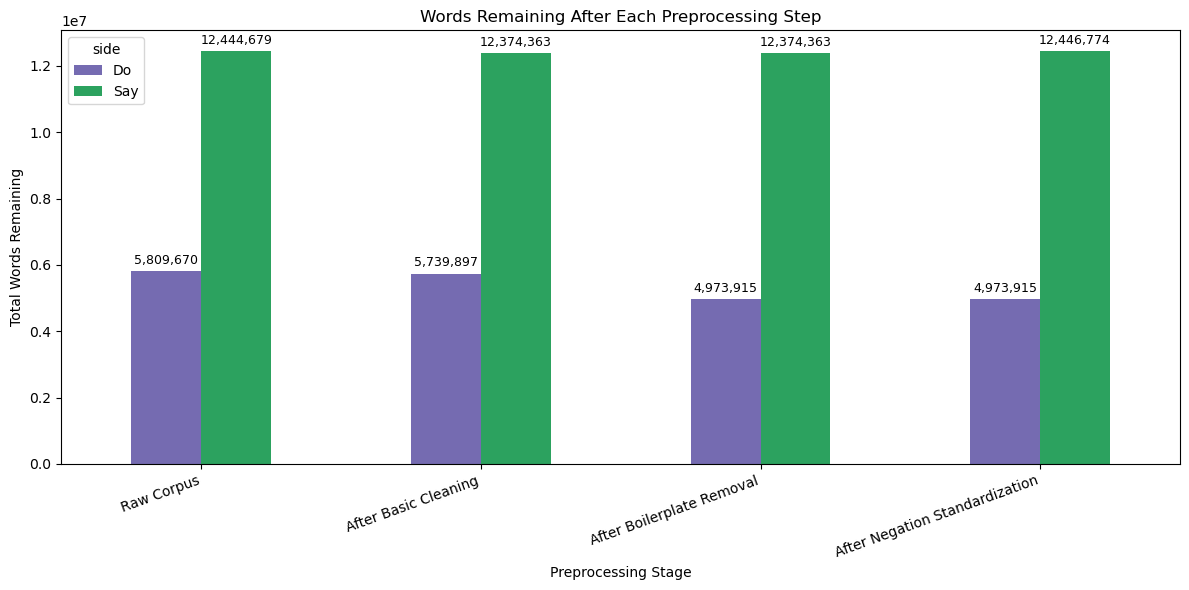

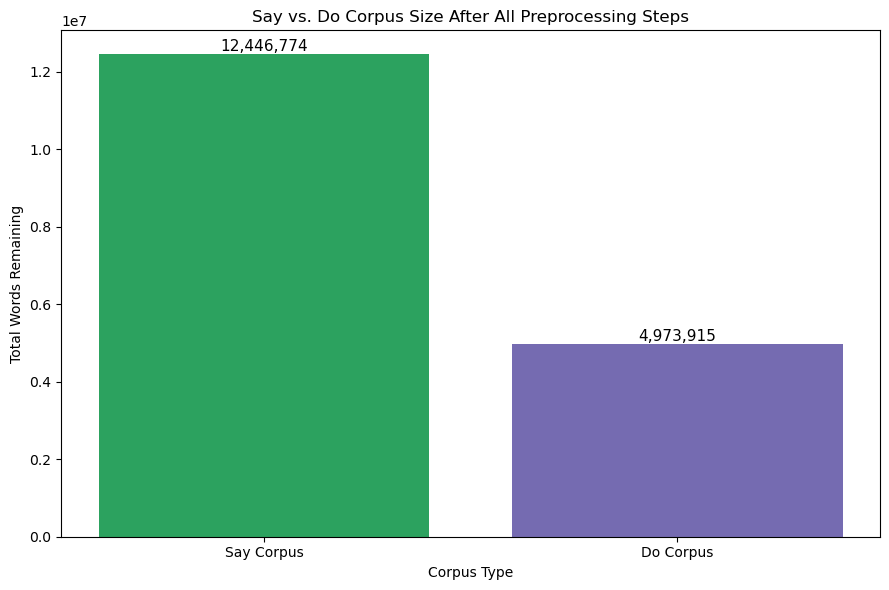

In [16]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "presidents_say_do_corpus_output"
INPUT_FILE = OUTPUT_DIR / "full_say_do_document_corpus.csv"

TEXT_CANDIDATES = [
    "full_document_text",
    "document_text",
    "text",
    "clean_text",
    "clean_text_basic",
    "chunk_text",
    "transcript",
    "content",
    "body",
    "full_text"
]

PRESIDENT_CANDIDATES = ["president", "speaker", "name"]

DOC_ID_CANDIDATES = [
    "document_id",
    "interview_id",
    "doc_id",
    "id"
]

DOC_TYPE_CANDIDATES = [
    "document_type",
    "doc_type",
    "type",
    "source_type",
    "collection"
]

SIDE_CANDIDATES = [
    "side",
    "corpus",
    "corpus_type",
    "say_do",
    "category",
    "group"
]

BOILERPLATE_PATTERNS = [
    ("authority vested clause", r"\bby (the )?(authority|virtue) vested in me\b.{0,180}?\bit is hereby ordered\b"),
    ("hereby ordered phrase", r"\bit is hereby ordered as follows\b"),
    ("pursuant to legal authority", r"\bpursuant to\b.{0,120}?\b(this order|this act|the act|section|statute|law)\b"),
    ("general provisions header", r"\bsec\.?\s*\d+\.?\s*general provisions\b"),
    ("nothing in this order clause", r"\bnothing in this order shall be construed to\b.{0,500}?(?=\b\([a-z0-9ivx]+\)|\bsec\.|\bsection\b|$)"),
    ("implemented consistent with law", r"\bthis order shall be implemented consistent with applicable law\b.{0,250}?(?=\b\([a-z0-9ivx]+\)|\bsec\.|\bsection\b|$)"),
    ("no right or benefit clause", r"\bthis order is not intended to\b.{0,500}?\bany other person\b\.?"),
    ("omb budgetary clause", r"\bfunctions of the director of the office of management and budget\b.{0,250}?(?=\b\([a-z0-9ivx]+\)|\bsec\.|\bsection\b|$)"),
    ("availability of appropriations", r"\bsubject to the availability of appropriations\b"),
    ("federal register note", r"\bnote:\s*this executive order was published in the federal register\b.{0,250}?(?=\b[A-Z][a-z]+ [A-Z][a-z]+,|\b[A-Z]{2,}|$)"),
    ("american presidency project footer", r"\bOnline by Gerhard Peters and John T\. Woolley\b.{0,300}$"),
    ("presidency project url", r"\bThe American Presidency Project\s+https?://\S+"),
    ("white house signature line", r"\bThe White House,\s+[A-Z][a-z]+ \d{1,2}, \d{4}\.?"),
    ("executive order citation footer", r"\b[A-Z][A-Za-z\.\s]+,\s+Executive Order\s+\d+[A-Za-z]?\b.{0,300}$"),
    ("secretary shall administrative instruction", r"\b(the )?secretar(y|ies) of\b.{0,160}?\bshall\b"),
    ("department shall administrative instruction", r"\b(the )?(department|agency|agencies|office|offices)\b.{0,120}?\bshall\b"),
    ("date of this order deadline", r"\bwithin \d+ days of the date of this order\b"),
    ("this order administrative reference", r"\b(this order|the order|such order)\b")
]

NEGATION_REPLACEMENTS = [
    (r"\bcan't\b", "cannot"),
    (r"\bwon't\b", "will not"),
    (r"\bdon't\b", "do not"),
    (r"\bdoesn't\b", "does not"),
    (r"\bdidn't\b", "did not"),
    (r"\bisn't\b", "is not"),
    (r"\baren't\b", "are not"),
    (r"\bwasn't\b", "was not"),
    (r"\bweren't\b", "were not"),
    (r"\bhaven't\b", "have not"),
    (r"\bhasn't\b", "has not"),
    (r"\bhadn't\b", "had not"),
    (r"\bshouldn't\b", "should not"),
    (r"\bwouldn't\b", "would not"),
    (r"\bcouldn't\b", "could not"),
    (r"\bmustn't\b", "must not"),
    (r"\bmightn't\b", "might not"),
    (r"\bneedn't\b", "need not"),
    (r"\bain't\b", "is not"),
    (r"\bthere's no\b", "there is no"),
    (r"\bthere's not\b", "there is not"),
    (r"\bthat's not\b", "that is not"),
    (r"\bit's not\b", "it is not"),
    (r"\bI'm not\b", "I am not"),
    (r"\byou're not\b", "you are not"),
    (r"\bwe're not\b", "we are not"),
    (r"\bthey're not\b", "they are not")
]


def clean_column_name(col):
    col = str(col).strip().lower()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col


def find_column(df, candidates):
    for candidate in candidates:
        if candidate in df.columns:
            return candidate
    return None


def find_text_column(df):
    exact = find_column(df, TEXT_CANDIDATES)

    if exact is not None:
        return exact

    for col in df.columns:
        col_lower = str(col).lower()

        if any(x in col_lower for x in ["text", "chunk", "transcript", "content", "body"]):
            if not any(x in col_lower for x in ["id", "url", "len", "count"]):
                return col

    return None


def classify_side(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    if "say" in value:
        return "Say"

    if "do" in value:
        return "Do"

    if any(x in value for x in ["speech", "interview", "inaugural", "farewell", "news conference", "remarks"]):
        return "Say"

    if any(x in value for x in ["executive", "written presidential", "order", "memorandum", "proclamation"]):
        return "Do"

    return np.nan


def count_words(text):
    return len(re.findall(r"\b[a-zA-Z][a-zA-Z'-]*\b", str(text)))


def basic_clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"&amp;", " and ", text)
    text = re.sub(r"&quot;", '"', text)
    text = re.sub(r"&apos;", "'", text)
    text = re.sub(r"&lt;", " ", text)
    text = re.sub(r"&gt;", " ", text)
    text = re.sub(r"&nbsp;", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)

    text = text.replace("\r", " ")
    text = text.replace("\n", " ")

    text = text.replace("“", '"').replace("”", '"')
    text = text.replace("‘", "'").replace("’", "'")
    text = text.replace("—", "-").replace("–", "-")

    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text


def remove_boilerplate_from_do_text(text):
    if pd.isna(text):
        return ""

    cleaned = str(text)

    for label, pattern in BOILERPLATE_PATTERNS:
        cleaned = re.sub(
            pattern,
            " ",
            cleaned,
            flags=re.IGNORECASE | re.DOTALL
        )

    cleaned = re.sub(r"\s+", " ", cleaned)
    cleaned = cleaned.strip()

    return cleaned


def standardize_negation(text):
    if pd.isna(text):
        return ""

    cleaned = str(text)

    for pattern, replacement in NEGATION_REPLACEMENTS:
        cleaned = re.sub(
            pattern,
            replacement,
            cleaned,
            flags=re.IGNORECASE
        )

    cleaned = re.sub(r"\s+", " ", cleaned)
    cleaned = cleaned.strip()

    return cleaned


print("Reading file from:")
print(INPUT_FILE)

if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Input file not found: {INPUT_FILE}")

df = pd.read_csv(INPUT_FILE)

if df.empty:
    raise ValueError("CSV file is empty.")

df.columns = [clean_column_name(c) for c in df.columns]

text_col = find_text_column(df)
president_col = find_column(df, PRESIDENT_CANDIDATES)
doc_id_col = find_column(df, DOC_ID_CANDIDATES)
doc_type_col = find_column(df, DOC_TYPE_CANDIDATES)
side_col = find_column(df, SIDE_CANDIDATES)

if text_col is None:
    raise ValueError(f"No text column found. Available columns: {list(df.columns)}")

if president_col is None:
    raise ValueError(f"No president column found. Available columns: {list(df.columns)}")

if doc_id_col is None:
    df["document_id"] = df.index.astype(str)
    doc_id_col = "document_id"

if doc_type_col is None:
    df["document_type"] = "Unknown"
    doc_type_col = "document_type"

if side_col is None:
    raise ValueError(f"No Say/Do side column found. Available columns: {list(df.columns)}")

corpus = pd.DataFrame()
corpus["source_file"] = df["source_file"].astype(str).str.strip() if "source_file" in df.columns else INPUT_FILE.name
corpus["side"] = df[side_col].apply(classify_side)
corpus["raw_text"] = df[text_col].fillna("").astype(str)
corpus["president"] = df[president_col].astype(str).str.strip()
corpus["document_id"] = df[doc_id_col].astype(str)
corpus["document_type"] = df[doc_type_col].astype(str).str.strip()

corpus = corpus[
    (corpus["side"].isin(["Say", "Do"])) &
    (corpus["raw_text"].str.len() > 0) &
    (corpus["president"].str.lower() != "unknown")
].copy()

if len(corpus) == 0:
    raise ValueError("No usable Say/Do rows found in the CSV.")

corpus["clean_text_basic"] = corpus["raw_text"].apply(basic_clean_text)

corpus["clean_text_no_boilerplate"] = np.where(
    corpus["side"] == "Do",
    corpus["clean_text_basic"].apply(remove_boilerplate_from_do_text),
    corpus["clean_text_basic"]
)

corpus["clean_text_negation_standardized"] = corpus["clean_text_no_boilerplate"].apply(standardize_negation)

corpus["raw_words"] = corpus["raw_text"].apply(count_words)
corpus["words_after_basic_cleaning"] = corpus["clean_text_basic"].apply(count_words)
corpus["words_after_boilerplate_removal"] = corpus["clean_text_no_boilerplate"].apply(count_words)
corpus["words_after_negation_standardization"] = corpus["clean_text_negation_standardized"].apply(count_words)

summary = (
    corpus
    .groupby("side", as_index=False)
    .agg(
        documents=("document_id", "count"),
        unique_presidents=("president", "nunique"),
        raw_words=("raw_words", "sum"),
        words_after_basic_cleaning=("words_after_basic_cleaning", "sum"),
        words_after_boilerplate_removal=("words_after_boilerplate_removal", "sum"),
        words_after_negation_standardization=("words_after_negation_standardization", "sum")
    )
)

summary["basic_cleaning_words_removed"] = summary["raw_words"] - summary["words_after_basic_cleaning"]
summary["boilerplate_words_removed"] = summary["words_after_basic_cleaning"] - summary["words_after_boilerplate_removal"]
summary["negation_word_change"] = summary["words_after_negation_standardization"] - summary["words_after_boilerplate_removal"]

print("\nPREPROCESSING PIPELINE COMPLETE")
print("\nSteps completed:")
print("1. Basic text cleaning")
print("2. Executive-order boilerplate removal")
print("3. Negation standardization")
print("\nLoaded from full_say_do_document_corpus.csv.")

print("\nINPUT AUDIT")
print("Rows in CSV:", len(df))
print("Usable rows:", len(corpus))
print("Text column:", text_col)
print("President column:", president_col)
print("Document ID column:", doc_id_col)
print("Document type column:", doc_type_col)
print("Side column:", side_col)

print("\nWORDS REMAINING AFTER EACH PREPROCESSING STEP")
print(summary.to_string(index=False))

plot_long = summary[
    [
        "side",
        "raw_words",
        "words_after_basic_cleaning",
        "words_after_boilerplate_removal",
        "words_after_negation_standardization"
    ]
].melt(
    id_vars="side",
    var_name="preprocessing_stage",
    value_name="words_remaining"
)

stage_labels = {
    "raw_words": "Raw Corpus",
    "words_after_basic_cleaning": "After Basic Cleaning",
    "words_after_boilerplate_removal": "After Boilerplate Removal",
    "words_after_negation_standardization": "After Negation Standardization"
}

plot_long["preprocessing_stage"] = plot_long["preprocessing_stage"].map(stage_labels)

stage_order = [
    "Raw Corpus",
    "After Basic Cleaning",
    "After Boilerplate Removal",
    "After Negation Standardization"
]

plot_long["preprocessing_stage"] = pd.Categorical(
    plot_long["preprocessing_stage"],
    categories=stage_order,
    ordered=True
)

plot_long = plot_long.sort_values(["preprocessing_stage", "side"])

plot_wide = plot_long.pivot(
    index="preprocessing_stage",
    columns="side",
    values="words_remaining"
).loc[stage_order]

colors = {
    "Say": "#2ca25f",
    "Do": "#756bb1"
}

ax = plot_wide.plot(
    kind="bar",
    figsize=(12, 6),
    color=[colors[col] for col in plot_wide.columns]
)

ax.set_title("Words Remaining After Each Preprocessing Step")
ax.set_xlabel("Preprocessing Stage")
ax.set_ylabel("Total Words Remaining")

plt.xticks(rotation=20, ha="right")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{int(v):,}" for v in container.datavalues],
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

final_plot = summary.copy()
final_plot["corpus_label"] = final_plot["side"].map({
    "Say": "Say Corpus",
    "Do": "Do Corpus"
})

final_plot = final_plot.set_index("corpus_label").loc[["Say Corpus", "Do Corpus"]].reset_index()

plt.figure(figsize=(9, 6))
bars = plt.bar(
    final_plot["corpus_label"],
    final_plot["words_after_negation_standardization"],
    color=["#2ca25f", "#756bb1"]
)

plt.title("Say vs. Do Corpus Size After All Preprocessing Steps")
plt.xlabel("Corpus Type")
plt.ylabel("Total Words Remaining")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

### Compiling


NORMALIZE + CONFIDENCE FILTER COMPLETE
Saved:
process_outputs\say_document_corpus.csv
process_outputs\do_document_corpus.csv
process_outputs\president_evidence_filter_table.csv

Kept presidents: 21
['Abraham Lincoln', 'Andrew Johnson', 'Barack Obama', 'Calvin Coolidge', 'Donald J. Trump', 'Dwight D. Eisenhower', 'Franklin D. Roosevelt', 'George Bush', 'George W. Bush', 'Gerald R. Ford', 'Harry S Truman', 'Herbert Hoover', 'Jimmy Carter', 'John F. Kennedy', 'Joseph R. Biden, Jr.', 'Lyndon B. Johnson', 'Richard Nixon', 'Ronald Reagan', 'William Howard Taft', 'William J. Clinton', 'William McKinley']

COVERAGE WIDE


corpus_type,president,do_words_after_preprocessing,say_words_after_preprocessing,total_words_after_preprocessing,passes_confidence_filter,exclusion_reason
41,William J. Clinton,241111,1929810,2170921,True,included
3,Barack Obama,287190,1824068,2111258,True,included
12,George W. Bush,169260,1582086,1751346,True,included
7,Donald J. Trump,507459,1146034,1653493,True,included
9,Franklin D. Roosevelt,1096149,410585,1506734,True,included
16,Harry S Truman,527132,682241,1209373,True,included
8,Dwight D. Eisenhower,243386,836652,1080038,True,included
23,Jimmy Carter,188403,761140,949543,True,included
33,Ronald Reagan,192351,684007,876358,True,included
11,George Bush,74750,765157,839907,True,included


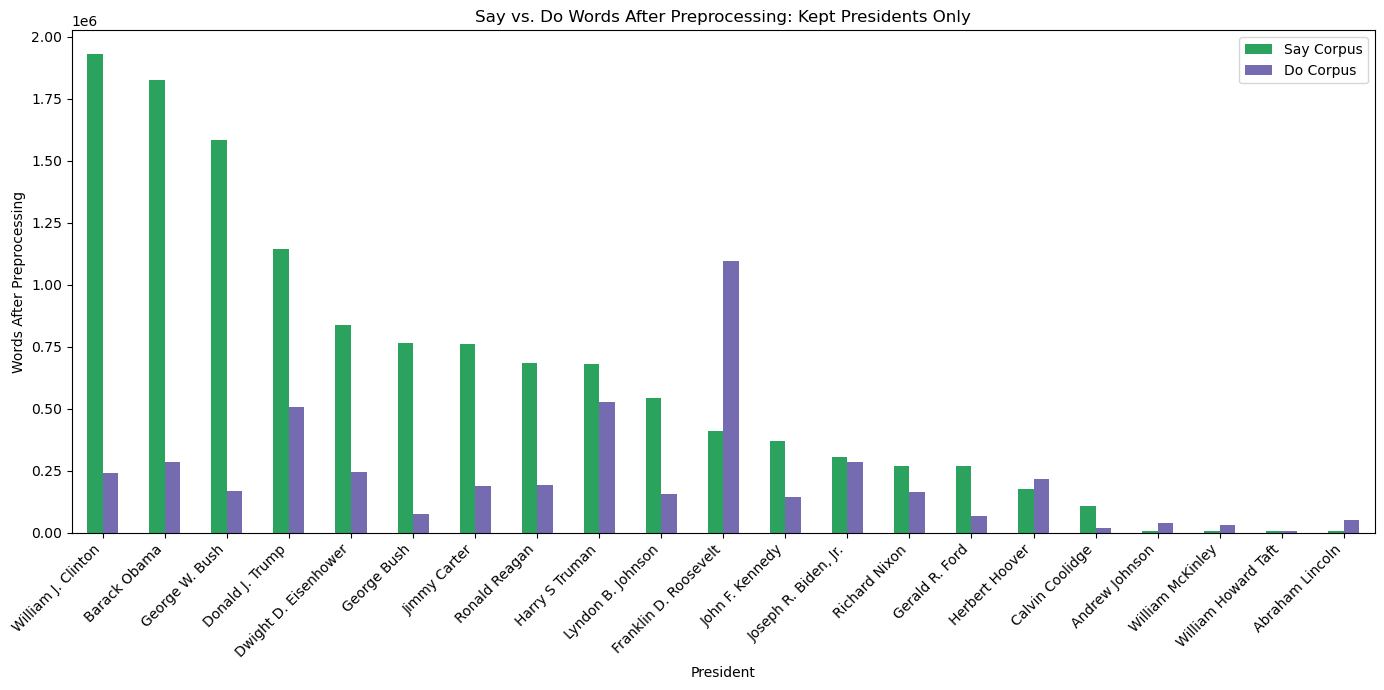


EXCLUDED PRESIDENTS AND WHY
             president  say_words_after_preprocessing  do_words_after_preprocessing  total_words_after_preprocessing                  exclusion_reason
William Henry Harrison                           8486                             0                             8486         excluded: low Do evidence
          James Monroe                           7877                             0                             7877         excluded: low Do evidence
     John Quincy Adams                           2934                          3024                             5958 excluded: low Say and Do evidence
       Franklin Pierce                           3409                          1510                             4919 excluded: low Say and Do evidence
      Martin van Buren                           3863                           888                             4751 excluded: low Say and Do evidence
      Thomas Jefferson                           3932            

In [17]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

OUTPUT_DIR = Path("process_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

MIN_SAY_WORDS = 5000
MIN_DO_WORDS = 5000

if "corpus" not in globals():
    raise ValueError("corpus not found. Run the negation standardization step first.")

required_cols = [
    "president",
    "side",
    "document_id",
    "document_type",
    "raw_text",
    "clean_text_basic",
    "clean_text_no_boilerplate",
    "clean_text_negation_standardized"
]

for col in required_cols:
    if col not in corpus.columns:
        raise ValueError(f"Missing required column in corpus: {col}")

def count_words(text):
    return len(re.findall(r"\b[a-zA-Z][a-zA-Z'-]*\b", str(text)))

def normalize_final_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

final_corpus = corpus.copy()

final_corpus["corpus_type"] = final_corpus["side"].astype(str).str.lower().str.strip()

final_corpus["corpus_type"] = final_corpus["corpus_type"].replace({
    "say": "say",
    "do": "do",
    "say corpus": "say",
    "do corpus": "do"
})

final_corpus["final_preprocessed_text"] = (
    final_corpus["clean_text_negation_standardized"]
    .fillna("")
    .astype(str)
    .apply(normalize_final_text)
)

final_corpus["words_after_preprocessing"] = final_corpus["final_preprocessed_text"].apply(count_words)

final_corpus = final_corpus[
    final_corpus["corpus_type"].isin(["say", "do"]) &
    (final_corpus["words_after_preprocessing"] > 0)
].copy()

coverage_wide = (
    final_corpus
    .groupby(["president", "corpus_type"], as_index=False)
    .agg(words_after_preprocessing=("words_after_preprocessing", "sum"))
    .pivot_table(
        index="president",
        columns="corpus_type",
        values="words_after_preprocessing",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

if "say" not in coverage_wide.columns:
    coverage_wide["say"] = 0

if "do" not in coverage_wide.columns:
    coverage_wide["do"] = 0

coverage_wide = coverage_wide.rename(
    columns={
        "say": "say_words_after_preprocessing",
        "do": "do_words_after_preprocessing"
    }
)

coverage_wide["total_words_after_preprocessing"] = (
    coverage_wide["say_words_after_preprocessing"] +
    coverage_wide["do_words_after_preprocessing"]
)

coverage_wide["passes_confidence_filter"] = (
    (coverage_wide["say_words_after_preprocessing"] >= MIN_SAY_WORDS) &
    (coverage_wide["do_words_after_preprocessing"] >= MIN_DO_WORDS)
)

coverage_wide["exclusion_reason"] = np.select(
    [
        coverage_wide["passes_confidence_filter"],
        (coverage_wide["say_words_after_preprocessing"] < MIN_SAY_WORDS) &
        (coverage_wide["do_words_after_preprocessing"] < MIN_DO_WORDS),
        coverage_wide["say_words_after_preprocessing"] < MIN_SAY_WORDS,
        coverage_wide["do_words_after_preprocessing"] < MIN_DO_WORDS
    ],
    [
        "included",
        "excluded: low Say and Do evidence",
        "excluded: low Say evidence",
        "excluded: low Do evidence"
    ],
    default="excluded"
)

kept_presidents = (
    coverage_wide[coverage_wide["passes_confidence_filter"]]["president"]
    .astype(str)
    .str.strip()
    .tolist()
)

say_document_corpus = final_corpus[
    final_corpus["corpus_type"] == "say"
].copy()

do_document_corpus = final_corpus[
    final_corpus["corpus_type"] == "do"
].copy()

say_document_corpus.to_csv(
    OUTPUT_DIR / "say_document_corpus.csv",
    index=False,
    encoding="utf-8-sig"
)

do_document_corpus.to_csv(
    OUTPUT_DIR / "do_document_corpus.csv",
    index=False,
    encoding="utf-8-sig"
)

coverage_wide.to_csv(
    OUTPUT_DIR / "president_evidence_filter_table.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nNORMALIZE + CONFIDENCE FILTER COMPLETE")
print("Saved:")
print(OUTPUT_DIR / "say_document_corpus.csv")
print(OUTPUT_DIR / "do_document_corpus.csv")
print(OUTPUT_DIR / "president_evidence_filter_table.csv")

print("\nKept presidents:", len(kept_presidents))
print(kept_presidents)

print("\nCOVERAGE WIDE")
display(coverage_wide.sort_values(
    ["passes_confidence_filter", "total_words_after_preprocessing"],
    ascending=[False, False]
))

kept_presidents_plot = coverage_wide[
    coverage_wide["passes_confidence_filter"]
].copy()

excluded_presidents_table = coverage_wide[
    ~coverage_wide["passes_confidence_filter"]
].copy()

kept_presidents_plot = kept_presidents_plot.sort_values(
    "say_words_after_preprocessing",
    ascending=False
)

excluded_presidents_table = excluded_presidents_table[
    [
        "president",
        "say_words_after_preprocessing",
        "do_words_after_preprocessing",
        "total_words_after_preprocessing",
        "exclusion_reason"
    ]
].sort_values(
    ["exclusion_reason", "total_words_after_preprocessing"],
    ascending=[True, False]
)

plot_df = kept_presidents_plot[
    [
        "president",
        "say_words_after_preprocessing",
        "do_words_after_preprocessing"
    ]
].set_index("president")

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 7),
    color=["#2ca25f", "#756bb1"]
)

ax.set_title("Say vs. Do Words After Preprocessing: Kept Presidents Only")
ax.set_xlabel("President")
ax.set_ylabel("Words After Preprocessing")
ax.legend(["Say Corpus", "Do Corpus"])

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nEXCLUDED PRESIDENTS AND WHY")
print(excluded_presidents_table.to_string(index=False))

## Process

### Corpus-Guided N-Gram Discovery

Kept presidents for n-gram discovery: 21
['Abraham Lincoln', 'Andrew Johnson', 'Barack Obama', 'Calvin Coolidge', 'Donald J. Trump', 'Dwight D. Eisenhower', 'Franklin D. Roosevelt', 'George Bush', 'George W. Bush', 'Gerald R. Ford', 'Harry S Truman', 'Herbert Hoover', 'Jimmy Carter', 'John F. Kennedy', 'Joseph R. Biden, Jr.', 'Lyndon B. Johnson', 'Richard Nixon', 'Ronald Reagan', 'William Howard Taft', 'William J. Clinton', 'William McKinley']

Candidate corpus dataframes found:
('full_chunked_audit', 31140, 13)
('say_chunks', 16106, 13)
('do_chunks', 15034, 13)
('final_corpus', 14937, 16)
('do_document_corpus', 11318, 16)
('say_document_corpus', 3619, 16)

Using corpus dataframe: full_chunked_audit
Text column: chunk_text
Corpus column: corpus_type

Rows before n-gram quality-control cleaning: 29730

N-gram quality-control word impact:


,corpus_type,words_before_ngram_qc,words_after_ngram_qc,words_removed_by_ngram_qc,pct_words_removed_by_ngram_qc
0,do,5447983,5230696,217287,3.988394
1,say,12696301,12668486,27815,0.219080



Rows after aggregation to president × corpus:
(42, 4)

Total words by corpus after n-gram QC:
corpus_type  total_words
         do      5230696
        say     12668486


corpus_type,president,do,say
0,Abraham Lincoln,50824,4999
1,Andrew Johnson,39336,8052
2,Barack Obama,325719,1822034
3,Calvin Coolidge,21461,106481
4,Donald J. Trump,581298,1145344
5,Dwight D. Eisenhower,267610,835336
6,Franklin D. Roosevelt,1240344,408887
7,George Bush,83196,764254
8,George W. Bush,192370,1579511
9,Gerald R. Ford,73669,269344



TOP CANDIDATE COMBINED 2-GRAMS PER 1,000 TOTAL WORDS


...

corpus_type,ngram_n,phrase,count_do,count_say,total_words_say,total_words_do,combined_total_words,count_per_1000_words_say,count_per_1000_words_do,total_count,combined_count_per_1000_words,say_minus_do_per_1000_words,absolute_gap_per_1000_words,say_share_of_count,do_share_of_count,candidate_filter_reason,is_candidate_phrase
276240,3,of the united,16457,4821,12668486,5230696,17899182,0.380551,3.146235,21278,1.188769,-2.765685,2.765685,0.226572,0.773428,keep,True
276241,3,the white house,10101,5033,12668486,5230696,17899182,0.397285,1.931101,15134,0.845513,-1.533816,1.533816,0.332562,0.667438,keep,True
276242,3,online by woolley,10147,3258,12668486,5230696,17899182,0.257174,1.939895,13405,0.748917,-1.682721,1.682721,0.243044,0.756956,keep,True
276243,3,the president well,0,12460,12668486,5230696,17899182,0.983543,0.000000,12460,0.696121,0.983543,0.983543,1.000000,0.000000,keep,True
276244,3,of this order,10849,5,12668486,5230696,17899182,0.000395,2.074103,10854,0.606396,-2.073708,2.073708,0.000461,0.999539,keep,True
276245,3,section of the,9141,94,12668486,5230696,17899182,0.007420,1.747569,9235,0.515945,-1.740149,1.740149,0.010179,0.989821,keep,True
276246,3,going to be,0,7834,12668486,5230696,17899182,0.618385,0.000000,7834,0.437674,0.618385,0.618385,1.000000,0.000000,keep,True
276247,3,re going to,0,6888,12668486,5230696,17899182,0.543711,0.000000,6888,0.384822,0.543711,0.543711,1.000000,0.000000,keep,True
276248,3,the president no,216,6210,12668486,5230696,17899182,0.490193,0.041295,6426,0.359011,0.448898,0.448898,0.966387,0.033613,keep,True
276249,3,the provisions of,5921,77,12668486,5230696,17899182,0.006078,1.131972,5998,0.335099,-1.125894,1.125894,0.012838,0.987162,keep,True



TOP CANDIDATE COMBINED 4-GRAMS PER 1,000 TOTAL WORDS


,ngram_n,corpus_type,phrase,count,total_words,count_per_1000_words,candidate_filter_reason,is_candidate_phrase
1431308,4,combined,the secretary of the,4906,17899182,0.274091,keep,True
1431309,4,combined,president of the united,4629,17899182,0.258615,keep,True
1431310,4,combined,we re going to,4557,17899182,0.254593,keep,True
1431311,4,combined,the united states of,4409,17899182,0.246324,keep,True
1431312,4,combined,united states of america,4069,17899182,0.227329,keep,True
1431313,4,combined,the secretary of state,3574,17899182,0.199674,keep,True
1431314,4,combined,the director of the,3563,17899182,0.199059,keep,True
1431315,4,combined,online by woolley by,3438,17899182,0.192076,keep,True
1431316,4,combined,by section of the,3421,17899182,0.191126,keep,True
1431317,4,combined,by woolley by virtue,3370,17899182,0.188277,keep,True



TOP CANDIDATE SAY VS DO 4-GRAMS PER 1,000 TOTAL WORDS


corpus_type,ngram_n,phrase,count_do,count_say,total_words_say,total_words_do,combined_total_words,count_per_1000_words_say,count_per_1000_words_do,total_count,combined_count_per_1000_words,say_minus_do_per_1000_words,absolute_gap_per_1000_words,say_share_of_count,do_share_of_count,candidate_filter_reason,is_candidate_phrase
670101,4,the secretary of the,4656,250,12668486,5230696,17899182,0.019734,0.890130,4906,0.274091,-0.870396,0.870396,0.050958,0.949042,keep,True
670102,4,president of the united,3457,1172,12668486,5230696,17899182,0.092513,0.660906,4629,0.258615,-0.568393,0.568393,0.253186,0.746814,keep,True
670103,4,we re going to,0,4557,12668486,5230696,17899182,0.359711,0.000000,4557,0.254593,0.359711,0.359711,1.000000,0.000000,keep,True
670104,4,the united states of,3660,749,12668486,5230696,17899182,0.059123,0.699716,4409,0.246324,-0.640593,0.640593,0.169880,0.830120,keep,True
670105,4,united states of america,3380,689,12668486,5230696,17899182,0.054387,0.646186,4069,0.227329,-0.591799,0.591799,0.169329,0.830671,keep,True
670106,4,the secretary of state,2889,685,12668486,5230696,17899182,0.054071,0.552317,3574,0.199674,-0.498245,0.498245,0.191662,0.808338,keep,True
670107,4,the director of the,3448,115,12668486,5230696,17899182,0.009078,0.659186,3563,0.199059,-0.650108,0.650108,0.032276,0.967724,keep,True
670108,4,online by woolley by,3438,0,12668486,5230696,17899182,0.000000,0.657274,3438,0.192076,-0.657274,0.657274,0.000000,1.000000,keep,True
670109,4,by section of the,3420,0,12668486,5230696,17899182,0.000000,0.653833,3420,0.191070,-0.653833,0.653833,0.000000,1.000000,keep,True
670110,4,by woolley by virtue,3370,0,12668486,5230696,17899182,0.000000,0.644274,3370,0.188277,-0.644274,0.644274,0.000000,1.000000,keep,True


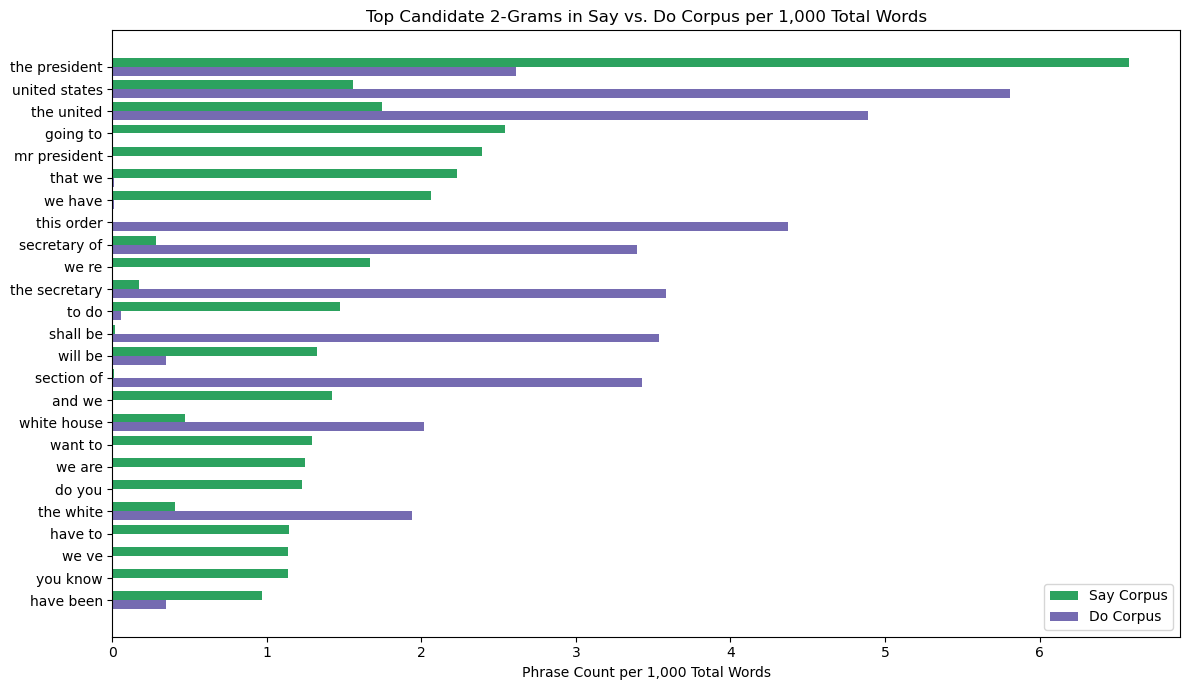

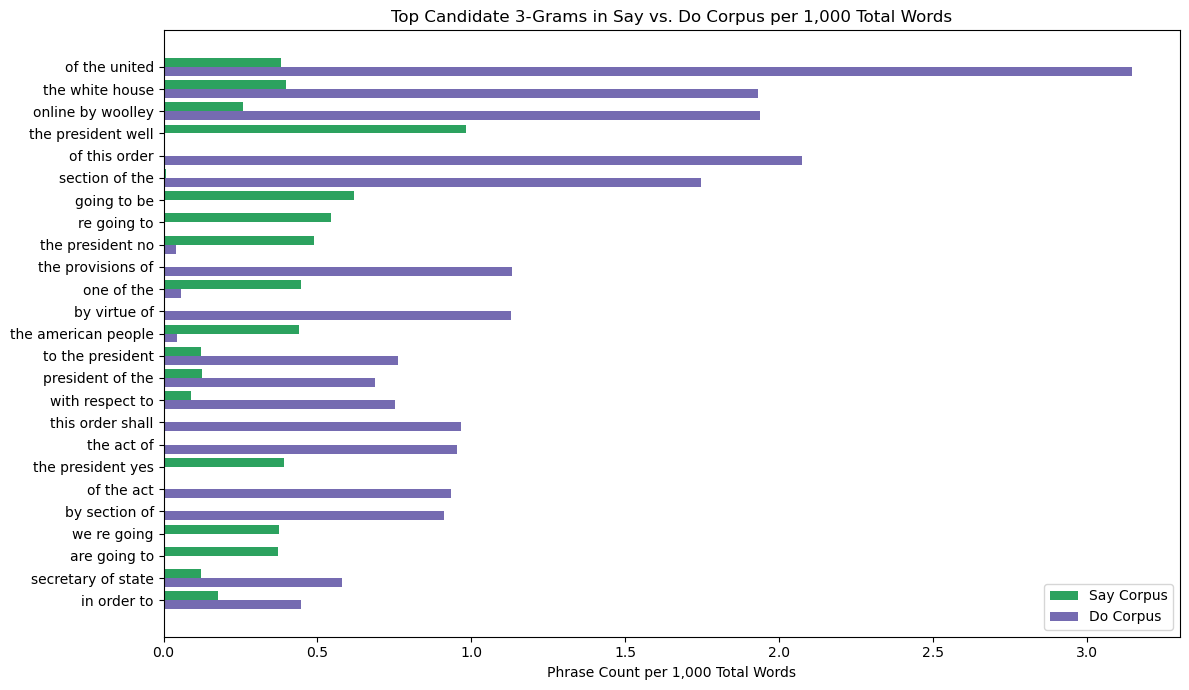

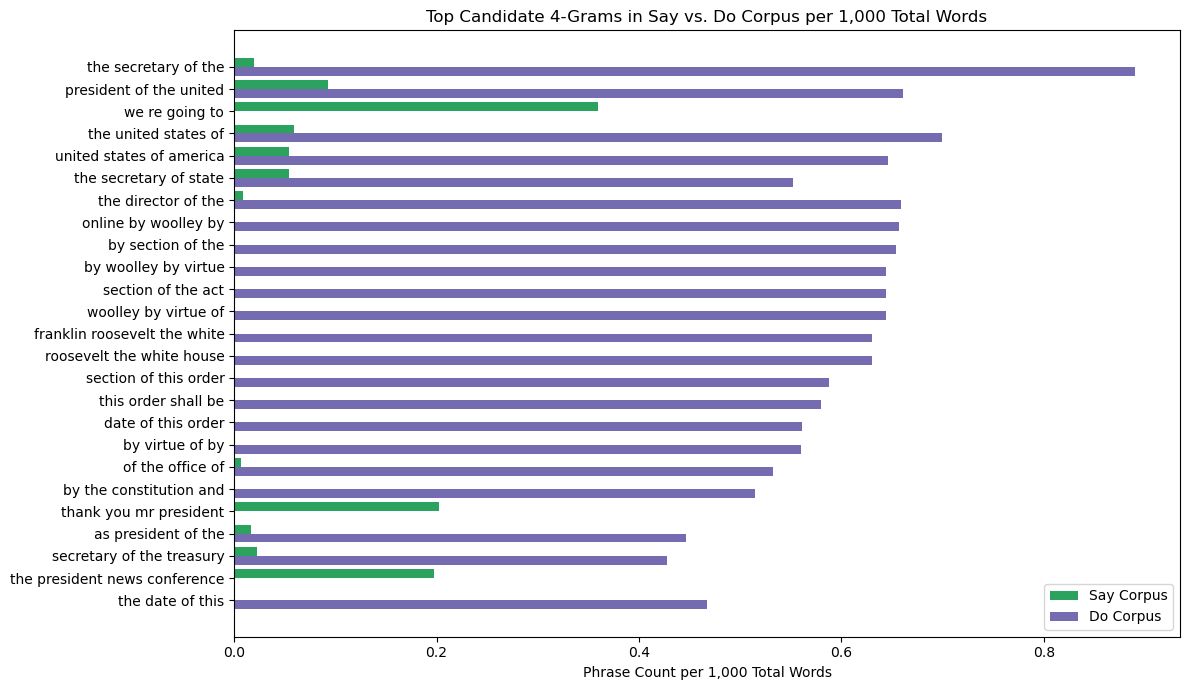


Saved files:
process_outputs\FULL_ngram_discovery_2_3_4_QC_per_1000_total_words.csv
process_outputs\CANDIDATE_ngram_discovery_2_3_4_QC_per_1000_total_words.csv
process_outputs\FULL_say_do_ngram_comparison_2_3_4_QC_per_1000_total_words.csv
process_outputs\CANDIDATE_say_do_ngram_comparison_2_3_4_QC_per_1000_total_words.csv
process_outputs\REVIEW_ngram_discovery_2_3_4_QC_per_1000_total_words.xlsx


In [18]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 400)
pd.set_option("display.max_rows", 100)

OUTPUT_DIR = Path("process_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

TOP_N = 50
MIN_COUNT = 5
NGRAMS_TO_RUN = [2, 3, 4]
EXCEL_REVIEW_ROWS_PER_GROUP = 500

if "coverage_wide" not in globals():
    raise ValueError("coverage_wide not found. Run the normalization + confidence filter step first.")

required_coverage_cols = [
    "president",
    "say_words_after_preprocessing",
    "do_words_after_preprocessing",
    "passes_confidence_filter",
    "exclusion_reason"
]

for col in required_coverage_cols:
    if col not in coverage_wide.columns:
        raise ValueError(f"Missing required column in coverage_wide: {col}")

kept_presidents = (
    coverage_wide[coverage_wide["passes_confidence_filter"]]["president"]
    .astype(str)
    .str.strip()
    .tolist()
)

print("Kept presidents for n-gram discovery:", len(kept_presidents))
print(kept_presidents)

possible_text_cols = [
    "final_preprocessed_text",
    "final_text",
    "text_after_preprocessing",
    "clean_text",
    "normalized_text",
    "full_text",
    "chunk_text"
]

possible_corpus_cols = [
    "corpus_type",
    "corpus",
    "type",
    "source_type"
]

skip_dfs = [
    "coverage_wide",
    "kept_presidents_plot",
    "excluded_presidents_table",
    "plot_df",
    "ngram_results",
    "say_do",
    "president_corpus_text",
    "ngram_review",
    "say_do_review",
    "candidate_say_do_review",
    "candidate_ngram_results"
]

candidate_dfs = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame) and name not in skip_dfs:
        cols_lower = [str(c).lower().strip() for c in obj.columns]

        has_text = any(col in cols_lower for col in possible_text_cols)
        has_corpus = any(col in cols_lower for col in possible_corpus_cols)
        has_president = "president" in cols_lower

        if has_text and has_corpus and has_president:
            candidate_dfs.append((name, len(obj), obj.shape[1]))

if len(candidate_dfs) == 0:
    raise ValueError("No corpus dataframe found. Expected president, corpus_type, and final text column.")

candidate_dfs = sorted(candidate_dfs, key=lambda x: x[1], reverse=True)

print("\nCandidate corpus dataframes found:")
for item in candidate_dfs:
    print(item)

corpus_df_name = candidate_dfs[0][0]
df = globals()[corpus_df_name].copy()

print("\nUsing corpus dataframe:", corpus_df_name)

df.columns = df.columns.str.strip().str.lower()

text_col = None
for col in possible_text_cols:
    if col in df.columns:
        text_col = col
        break

corpus_col = None
for col in possible_corpus_cols:
    if col in df.columns:
        corpus_col = col
        break

president_col = "president"

if text_col is None:
    raise ValueError(f"No text column found. Tried: {possible_text_cols}")

if corpus_col is None:
    raise ValueError(f"No corpus column found. Tried: {possible_corpus_cols}")

print("Text column:", text_col)
print("Corpus column:", corpus_col)

df = df.dropna(subset=[president_col, corpus_col, text_col]).copy()

df[president_col] = df[president_col].astype(str).str.strip()
df[corpus_col] = df[corpus_col].astype(str).str.lower().str.strip()
df[text_col] = df[text_col].astype(str)

df[corpus_col] = df[corpus_col].replace({
    "say corpus": "say",
    "do corpus": "do",
    "words": "say",
    "actions": "do"
})

df = df[df[president_col].isin(kept_presidents)].copy()
df = df[df[corpus_col].isin(["say", "do"])].copy()
df = df[df[text_col].str.split().str.len() > 0].copy()

print("\nRows before n-gram quality-control cleaning:", len(df))

source_artifact_patterns = [
    r"\bhttps www presidency ucsb edu\b",
    r"\bwww presidency ucsb edu\b",
    r"\bpresidency ucsb edu node\b",
    r"\bpresidency ucsb edu\b",
    r"\bucsb edu node by\b",
    r"\bucsb edu\b",
    r"\bthe american presidency project\b",
    r"\bamerican presidency project\b",
    r"\bgerhard peters and john woolley\b",
    r"\bgerhard peters and john\b",
    r"\band john woolley\b",
    r"\bjohn woolley\b",
    r"\bgerhard peters\b",
    r"\bonline by gerhard peters\b",
    r"\bwoolley the american presidency\b",
    r"\bpeters and john woolley\b",
    r"\bproject https www presidency\b",
    r"\bpresidency project https www\b"
]

boilerplate_patterns = [
    r"\bby the authority vested in me\b",
    r"\bthe authority vested in me\b",
    r"\bauthority vested in me\b",
    r"\bvested in me by\b",
    r"\bit is hereby ordered\b",
    r"\bhereby ordered\b",
    r"\bpursuant to\b",
    r"\bin witness whereof\b",
    r"\btherefore i\b",
    r"\bnow therefore i\b",
    r"\bexecutive order\b",
    r"\bfederal register\b",
    r"\bcode of federal regulations\b",
    r"\bsection one\b",
    r"\bsection two\b",
    r"\bsection three\b"
]

candidate_noise_patterns = source_artifact_patterns + boilerplate_patterns

generic_exact_phrases = {
    "of the united states",
    "the united states",
    "united states of",
    "united states and",
    "the united states and",
    "in the united states",
    "of america and",
    "states of america",
    "the secretary of",
    "secretary of the",
    "the department of",
    "department of the",
    "of the department",
    "and the secretary",
    "to the secretary",
    "by the secretary",
    "the director of",
    "director of the",
    "the head of",
    "head of the",
    "the office of",
    "office of the"
}

basic_stopwords = {
    "the", "of", "and", "to", "in", "a", "an", "for", "on", "by", "with",
    "from", "as", "at", "is", "are", "was", "were", "be", "been", "being",
    "this", "that", "these", "those", "it", "its", "or"
}

def normalize_to_alpha(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def remove_patterns(text, patterns):
    out = str(text)
    for pattern in patterns:
        out = re.sub(pattern, " ", out)
    out = re.sub(r"\s+", " ", out).strip()
    return out

def word_count(text):
    return len(str(text).split())

df["ngram_text_before_qc"] = df[text_col].apply(normalize_to_alpha)
df["words_before_ngram_qc"] = df["ngram_text_before_qc"].apply(word_count)

df["ngram_text"] = df["ngram_text_before_qc"].apply(
    lambda x: remove_patterns(x, source_artifact_patterns + boilerplate_patterns)
)

df["words_after_ngram_qc"] = df["ngram_text"].apply(word_count)
df["words_removed_by_ngram_qc"] = df["words_before_ngram_qc"] - df["words_after_ngram_qc"]

qc_summary = (
    df.groupby(corpus_col, as_index=False)
    .agg(
        words_before_ngram_qc=("words_before_ngram_qc", "sum"),
        words_after_ngram_qc=("words_after_ngram_qc", "sum"),
        words_removed_by_ngram_qc=("words_removed_by_ngram_qc", "sum")
    )
)

qc_summary["pct_words_removed_by_ngram_qc"] = (
    qc_summary["words_removed_by_ngram_qc"] /
    qc_summary["words_before_ngram_qc"]
) * 100

print("\nN-gram quality-control word impact:")
display(qc_summary)

df = df[df["words_after_ngram_qc"] > 0].copy()

president_corpus_text = (
    df.groupby([president_col, corpus_col], as_index=False)
    .agg(ngram_text=("ngram_text", " ".join))
)

president_corpus_text["total_words"] = president_corpus_text["ngram_text"].str.split().str.len()

print("\nRows after aggregation to president × corpus:")
print(president_corpus_text.shape)

corpus_word_totals = (
    president_corpus_text
    .groupby(corpus_col)["total_words"]
    .sum()
    .rename("total_words")
    .reset_index()
)

print("\nTotal words by corpus after n-gram QC:")
print(corpus_word_totals.to_string(index=False))

word_total_map = dict(zip(corpus_word_totals[corpus_col], corpus_word_totals["total_words"]))
say_total_words = word_total_map.get("say", 0)
do_total_words = word_total_map.get("do", 0)
combined_total_words = say_total_words + do_total_words

display(
    president_corpus_text
    .pivot_table(
        index=president_col,
        columns=corpus_col,
        values="total_words",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

def get_ngrams(data, n, label):
    total_words = data["total_words"].sum()

    empty_cols = [
        "ngram_n",
        "corpus_type",
        "phrase",
        "count",
        "total_words",
        "count_per_1000_words"
    ]

    if len(data) == 0 or total_words == 0:
        return pd.DataFrame(columns=empty_cols)

    vectorizer = CountVectorizer(
        ngram_range=(n, n),
        lowercase=False,
        token_pattern=r"(?u)\b[a-z][a-z]+\b",
        min_df=1
    )

    try:
        matrix = vectorizer.fit_transform(data["ngram_text"])
    except ValueError:
        return pd.DataFrame(columns=empty_cols)

    phrases = vectorizer.get_feature_names_out()
    counts = np.asarray(matrix.sum(axis=0)).ravel()

    out = pd.DataFrame({
        "ngram_n": n,
        "corpus_type": label,
        "phrase": phrases,
        "count": counts,
        "total_words": total_words
    })

    out = out[out["count"] >= MIN_COUNT].copy()
    out["count_per_1000_words"] = (out["count"] / out["total_words"]) * 1000

    out = out.sort_values(
        ["count_per_1000_words", "count"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return out

def candidate_filter_reason(phrase):
    phrase = str(phrase).strip()

    for pattern in candidate_noise_patterns:
        if re.search(pattern, phrase):
            return "source_or_boilerplate_noise"

    if phrase in generic_exact_phrases:
        return "generic_government_phrase"

    tokens = phrase.split()

    if len(tokens) == 0:
        return "empty"

    if all(token in basic_stopwords for token in tokens):
        return "all_stopwords"

    if len(tokens) >= 3 and sum(token in basic_stopwords for token in tokens) / len(tokens) >= 0.80:
        return "mostly_stopwords"

    if len(set(tokens)) == 1:
        return "repeated_token"

    return "keep"

all_ngram_results = []

for n in NGRAMS_TO_RUN:
    combined = get_ngrams(president_corpus_text, n, "combined")
    all_ngram_results.append(combined)

    for corpus_type in ["say", "do"]:
        temp = president_corpus_text[president_corpus_text[corpus_col] == corpus_type].copy()

        if len(temp) > 0:
            corpus_grams = get_ngrams(temp, n, corpus_type)
            all_ngram_results.append(corpus_grams)

ngram_results = pd.concat(all_ngram_results, ignore_index=True)

ngram_results["candidate_filter_reason"] = ngram_results["phrase"].apply(candidate_filter_reason)
ngram_results["is_candidate_phrase"] = ngram_results["candidate_filter_reason"].eq("keep")

ngram_results = ngram_results.sort_values(
    ["ngram_n", "corpus_type", "is_candidate_phrase", "count_per_1000_words", "count"],
    ascending=[True, True, False, False, False]
).reset_index(drop=True)

ngram_results.to_csv(
    OUTPUT_DIR / "FULL_ngram_discovery_2_3_4_QC_per_1000_total_words.csv",
    index=False,
    encoding="utf-8-sig"
)

candidate_ngram_results = ngram_results[ngram_results["is_candidate_phrase"]].copy()

candidate_ngram_results.to_csv(
    OUTPUT_DIR / "CANDIDATE_ngram_discovery_2_3_4_QC_per_1000_total_words.csv",
    index=False,
    encoding="utf-8-sig"
)

counts_only = (
    ngram_results[ngram_results["corpus_type"].isin(["say", "do"])]
    .pivot_table(
        index=["ngram_n", "phrase"],
        columns="corpus_type",
        values="count",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

if "say" not in counts_only.columns:
    counts_only["say"] = 0

if "do" not in counts_only.columns:
    counts_only["do"] = 0

say_do = counts_only.rename(columns={
    "say": "count_say",
    "do": "count_do"
})

say_do["total_words_say"] = say_total_words
say_do["total_words_do"] = do_total_words
say_do["combined_total_words"] = combined_total_words

say_do["count_per_1000_words_say"] = np.where(
    say_do["total_words_say"] > 0,
    (say_do["count_say"] / say_do["total_words_say"]) * 1000,
    0
)

say_do["count_per_1000_words_do"] = np.where(
    say_do["total_words_do"] > 0,
    (say_do["count_do"] / say_do["total_words_do"]) * 1000,
    0
)

say_do["total_count"] = say_do["count_say"] + say_do["count_do"]

say_do = say_do[say_do["total_count"] >= MIN_COUNT].copy()

say_do["combined_count_per_1000_words"] = np.where(
    say_do["combined_total_words"] > 0,
    (say_do["total_count"] / say_do["combined_total_words"]) * 1000,
    0
)

say_do["say_minus_do_per_1000_words"] = (
    say_do["count_per_1000_words_say"] -
    say_do["count_per_1000_words_do"]
)

say_do["absolute_gap_per_1000_words"] = say_do["say_minus_do_per_1000_words"].abs()
say_do["say_share_of_count"] = say_do["count_say"] / say_do["total_count"]
say_do["do_share_of_count"] = say_do["count_do"] / say_do["total_count"]

say_do["candidate_filter_reason"] = say_do["phrase"].apply(candidate_filter_reason)
say_do["is_candidate_phrase"] = say_do["candidate_filter_reason"].eq("keep")

say_do = say_do.sort_values(
    ["ngram_n", "is_candidate_phrase", "combined_count_per_1000_words", "total_count"],
    ascending=[True, False, False, False]
).reset_index(drop=True)

say_do.to_csv(
    OUTPUT_DIR / "FULL_say_do_ngram_comparison_2_3_4_QC_per_1000_total_words.csv",
    index=False,
    encoding="utf-8-sig"
)

candidate_say_do = say_do[say_do["is_candidate_phrase"]].copy()

candidate_say_do.to_csv(
    OUTPUT_DIR / "CANDIDATE_say_do_ngram_comparison_2_3_4_QC_per_1000_total_words.csv",
    index=False,
    encoding="utf-8-sig"
)

ngram_review = (
    ngram_results
    .groupby(["ngram_n", "corpus_type"], group_keys=False)
    .head(EXCEL_REVIEW_ROWS_PER_GROUP)
    .reset_index(drop=True)
)

candidate_ngram_review = (
    candidate_ngram_results
    .groupby(["ngram_n", "corpus_type"], group_keys=False)
    .head(EXCEL_REVIEW_ROWS_PER_GROUP)
    .reset_index(drop=True)
)

say_do_review = (
    say_do
    .groupby("ngram_n", group_keys=False)
    .head(EXCEL_REVIEW_ROWS_PER_GROUP)
    .reset_index(drop=True)
)

candidate_say_do_review = (
    candidate_say_do
    .groupby("ngram_n", group_keys=False)
    .head(EXCEL_REVIEW_ROWS_PER_GROUP)
    .reset_index(drop=True)
)

with pd.ExcelWriter(OUTPUT_DIR / "REVIEW_ngram_discovery_2_3_4_QC_per_1000_total_words.xlsx") as writer:
    candidate_ngram_review.to_excel(writer, sheet_name="candidate_ngrams", index=False)
    candidate_say_do_review.to_excel(writer, sheet_name="candidate_say_do", index=False)
    ngram_review.to_excel(writer, sheet_name="full_ngrams_with_flags", index=False)
    say_do_review.to_excel(writer, sheet_name="full_say_do_with_flags", index=False)
    qc_summary.to_excel(writer, sheet_name="qc_word_impact", index=False)
    corpus_word_totals.to_excel(writer, sheet_name="word_totals", index=False)

for n in NGRAMS_TO_RUN:
    print(f"\nTOP CANDIDATE COMBINED {n}-GRAMS PER 1,000 TOTAL WORDS")
    display(
        candidate_ngram_results[
            (candidate_ngram_results["ngram_n"] == n) &
            (candidate_ngram_results["corpus_type"] == "combined")
        ].head(TOP_N)
    )

    print(f"\nTOP CANDIDATE SAY VS DO {n}-GRAMS PER 1,000 TOTAL WORDS")
    display(
        candidate_say_do[candidate_say_do["ngram_n"] == n]
        .sort_values("combined_count_per_1000_words", ascending=False)
        .head(TOP_N)
    )

for n in NGRAMS_TO_RUN:
    temp = (
        candidate_say_do[candidate_say_do["ngram_n"] == n]
        .sort_values("combined_count_per_1000_words", ascending=False)
        .head(25)
        .copy()
    )

    plt.figure(figsize=(12, 7))
    x = np.arange(len(temp))

    plt.barh(
        x - 0.2,
        temp["count_per_1000_words_say"],
        height=0.4,
        label="Say Corpus",
        color="#2ca25f"
    )

    plt.barh(
        x + 0.2,
        temp["count_per_1000_words_do"],
        height=0.4,
        label="Do Corpus",
        color="#756bb1"
    )

    plt.yticks(x, temp["phrase"])
    plt.xlabel("Phrase Count per 1,000 Total Words")
    plt.title(f"Top Candidate {n}-Grams in Say vs. Do Corpus per 1,000 Total Words")
    plt.gca().invert_yaxis()
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\nSaved files:")
print(OUTPUT_DIR / "FULL_ngram_discovery_2_3_4_QC_per_1000_total_words.csv")
print(OUTPUT_DIR / "CANDIDATE_ngram_discovery_2_3_4_QC_per_1000_total_words.csv")
print(OUTPUT_DIR / "FULL_say_do_ngram_comparison_2_3_4_QC_per_1000_total_words.csv")
print(OUTPUT_DIR / "CANDIDATE_say_do_ngram_comparison_2_3_4_QC_per_1000_total_words.csv")
print(OUTPUT_DIR / "REVIEW_ngram_discovery_2_3_4_QC_per_1000_total_words.xlsx")

### Build Dictionary

In [19]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 400)
pd.set_option("display.max_rows", 500)

OUTPUT_DIR = Path("process_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def direction_sign(axis, direction):
    if axis == "left_right" and direction == "left":
        return -1
    if axis == "left_right" and direction == "right":
        return 1
    if axis == "libertarian_authoritarian" and direction == "libertarian":
        return -1
    if axis == "libertarian_authoritarian" and direction == "authoritarian":
        return 1
    return 0

def d(family, axis, direction, intensity, theme, variants):
    return {
        "family": family,
        "axis": axis,
        "direction": direction,
        "intensity_0_to_5": intensity,
        "theme": theme,
        "variants": variants
    }

raw_dictionary = [
    d("local_public_goods", "left_right", "left", 1, "weak_public_investment", [
        "public service", "public services", "community services", "local services",
        "public facilities", "public resource", "public resources", "common good"
    ]),
    d("basic_worker_support", "left_right", "left", 1, "weak_worker_support", [
        "working families", "working people", "ordinary workers", "protect workers",
        "dignity of work", "worker support", "workers rights", "middle class families"
    ]),
    d("basic_consumer_protection", "left_right", "left", 1, "weak_market_regulation", [
        "protect consumers", "consumer protection", "fair prices", "fair competition",
        "market fairness", "consumer rights", "consumer safety", "fair marketplace"
    ]),
    d("public_investment", "left_right", "left", 2, "state_investment", [
        "public investment", "infrastructure investment", "federal investment",
        "public works", "community development", "invest in communities",
        "national investment", "public infrastructure"
    ]),
    d("education_public_spending", "left_right", "left", 2, "public_education", [
        "public education", "school funding", "student aid", "pell grants",
        "universal pre k", "public schools", "education funding", "federal education aid"
    ]),
    d("public_health_state_capacity", "left_right", "left", 2, "public_health", [
        "public health", "disease prevention", "health care access",
        "community health centers", "rural healthcare", "health care services",
        "health access", "preventive care"
    ]),
    d("housing_tenant_support", "left_right", "left", 2, "housing_affordability", [
        "affordable housing", "rental assistance", "tenant protections",
        "housing vouchers", "fair housing", "housing assistance", "public housing",
        "tenant rights"
    ]),
    d("care_economy_public_support", "left_right", "left", 2, "care_state_support", [
        "child care assistance", "affordable child care", "elder care support",
        "paid sick leave", "care economy", "family care support",
        "caregiving support", "public child care"
    ]),
    d("social_safety_net", "left_right", "left", 3, "welfare_state", [
        "social safety net", "protect social security", "food assistance",
        "unemployment insurance", "protect medicare", "medicaid", "welfare benefits",
        "public assistance"
    ]),
    d("labor_union_power", "left_right", "left", 3, "labor_power", [
        "collective bargaining", "right to organize", "union rights",
        "workplace protections", "union jobs", "organized labor",
        "labor unions", "protect collective bargaining"
    ]),
    d("living_wage", "left_right", "left", 3, "labor_income", [
        "living wage", "minimum wage", "paid family leave", "equal pay",
        "good paying union jobs", "raise wages", "fair wages", "workers pay"
    ]),
    d("economic_inequality", "left_right", "left", 3, "economic_equality", [
        "income inequality", "wealth inequality", "economic justice",
        "working class", "new deal", "economic fairness", "fair shot",
        "shared prosperity"
    ]),
    d("anti_poverty_policy", "left_right", "left", 3, "anti_poverty", [
        "war on poverty", "reduce poverty", "economic opportunity",
        "head start", "low income assistance", "anti poverty", "poverty reduction",
        "opportunity programs"
    ]),
    d("market_regulation", "left_right", "left", 3, "economic_regulation", [
        "regulate corporations", "antitrust enforcement", "monopoly power",
        "wall street reform", "big pharma", "corporate accountability",
        "market regulation", "consumer financial protection"
    ]),
    d("climate_intervention", "left_right", "left", 3, "climate_state_action", [
        "climate action", "clean energy", "renewable energy", "reduce emissions",
        "environmental protection", "green jobs", "climate change", "carbon pollution"
    ]),
    d("redistribution_tax_wealth", "left_right", "left", 4, "economic_redistribution", [
        "tax the wealthy", "wealth tax", "pay their fair share",
        "progressive taxation", "corporate minimum tax", "tax millionaires",
        "tax billionaires", "redistribution"
    ]),
    d("universal_healthcare", "left_right", "left", 4, "healthcare_state_role", [
        "universal healthcare", "medicare for all", "public option",
        "health care as a right", "public health insurance", "single payer",
        "universal coverage", "government health insurance"
    ]),
    d("democratic_socialism", "left_right", "left", 4, "democratic_socialist_policy", [
        "democratic socialism", "social democracy", "worker ownership",
        "public banking", "guaranteed income", "social democratic",
        "economic democracy", "universal basic income"
    ]),
    d("public_ownership", "left_right", "left", 5, "state_ownership", [
        "nationalize", "public ownership", "state owned enterprise",
        "nationalize energy", "nationalize health care", "state ownership",
        "publicly owned", "government ownership"
    ]),
    d("revolutionary_left", "left_right", "left", 5, "revolutionary_socialism", [
        "abolish capitalism", "class struggle", "workers revolution",
        "seize the means of production", "collectivization", "proletarian revolution",
        "socialist revolution", "revolutionary socialism"
    ]),

    d("support_local_enterprise", "left_right", "right", 1, "weak_small_business_market", [
        "support small business", "small business owners", "local business",
        "entrepreneurship", "family owned business", "small businesses",
        "main street business", "local enterprise"
    ]),
    d("business_confidence", "left_right", "right", 1, "weak_business_support", [
        "business confidence", "business community", "job creators",
        "support employers", "competition and innovation", "private employers",
        "business climate", "encourage investment"
    ]),
    d("free_trade_globalization", "left_right", "right", 2, "market_opening", [
        "free trade", "open markets", "trade liberalization", "expand trade",
        "free trade agreement", "global markets", "trade expansion", "international commerce"
    ]),
    d("economic_nationalism", "left_right", "right", 2, "economic_nationalism", [
        "protect american jobs", "tariffs", "made in america", "buy american",
        "domestic production", "american industry", "reshoring", "protect domestic industry"
    ]),
    d("energy_independence_fossil", "left_right", "right", 2, "energy_market_right", [
        "energy independence", "oil and gas", "coal industry", "fossil fuels",
        "pipeline construction", "drilling", "domestic energy production", "natural gas"
    ]),
    d("welfare_reform_work_requirements", "left_right", "right", 2, "market_workfare", [
        "welfare reform", "work requirements", "personal responsibility",
        "reduce dependency", "self sufficiency", "welfare dependency",
        "workfare", "able bodied adults"
    ]),
    d("school_choice_market_education", "left_right", "right", 2, "market_education", [
        "school choice", "charter schools", "education vouchers", "parental choice",
        "education savings accounts", "voucher program", "private school choice",
        "choice in education"
    ]),
    d("faith_based_private_delivery", "left_right", "right", 2, "private_social_services", [
        "faith based organizations", "charitable choice", "private charities",
        "voluntary organizations", "church based", "faith based initiative",
        "religious charities", "community volunteers"
    ]),
    d("rugged_individualism_voluntaryism", "left_right", "right", 2, "voluntary_market_conservatism", [
        "rugged individualism", "self reliance", "voluntary action",
        "private charity", "local responsibility", "individual responsibility",
        "personal initiative", "voluntary cooperation"
    ]),
    d("tax_reduction", "left_right", "right", 3, "tax_market_right", [
        "tax cuts", "lower taxes", "tax relief", "capital gains tax cut",
        "lower tax rates", "cut taxes", "tax reduction", "reduce taxes"
    ]),
    d("supply_side_growth", "left_right", "right", 3, "supply_side", [
        "supply side economics", "pro growth policies", "capital formation",
        "business investment", "investment tax credit", "economic growth",
        "growth incentives", "increase investment"
    ]),
    d("deregulation", "left_right", "right", 3, "market_freedom", [
        "deregulation", "cut red tape", "regulatory burden", "regulatory relief",
        "excessive regulation", "reduce regulation", "remove regulations",
        "burdensome regulations"
    ]),
    d("free_market", "left_right", "right", 3, "market_liberalism", [
        "free market", "free enterprise", "economic freedom", "private sector",
        "market incentives", "market forces", "competitive markets",
        "enterprise system"
    ]),
    d("small_government", "left_right", "right", 3, "limited_government", [
        "limited government", "smaller government", "federal overreach",
        "government interference", "reduce bureaucracy", "big government",
        "less government", "government intrusion"
    ]),
    d("fiscal_austerity", "left_right", "right", 3, "fiscal_conservatism", [
        "balanced budget", "reduce spending", "spending cuts", "fiscal discipline",
        "reduce the deficit", "budget restraint", "deficit reduction",
        "fiscal responsibility"
    ]),
    d("property_rights", "left_right", "right", 3, "property_market_right", [
        "property rights", "private property", "property owners", "home ownership",
        "ownership society", "protect property", "landowners", "private ownership"
    ]),
    d("privatization", "left_right", "right", 4, "privatization", [
        "privatize", "privatization", "private sector solution",
        "market based solution", "contracting out", "private contractors",
        "outsourcing government", "private delivery"
    ]),
    d("radical_laissez_faire", "left_right", "right", 4, "minimal_state_market", [
        "laissez faire", "minimal state", "abolish welfare", "abolish regulation",
        "flat tax", "night watchman state", "radical free market",
        "minimal government"
    ]),
    d("anarcho_capitalist_market_extreme", "left_right", "right", 5, "market_extreme", [
        "abolish the state", "privatize everything", "private police",
        "taxation is theft", "stateless capitalism", "anarcho capitalism",
        "abolish government", "private courts"
    ]),
    d("oligarchic_corporate_rule", "left_right", "right", 5, "corporate_extreme", [
        "corporate rule", "rule by corporations", "corporate sovereignty",
        "corporate state", "market rule over democracy", "corporate control",
        "corporate power over government", "government by corporations"
    ]),

    d("individual_liberty_basic", "libertarian_authoritarian", "libertarian", 1, "weak_individual_liberty", [
        "individual liberty", "personal freedom", "individual rights", "personal liberty",
        "basic freedoms", "free citizens", "individual choice", "freedom of conscience"
    ]),
    d("voluntary_civil_society", "libertarian_authoritarian", "libertarian", 1, "voluntary_society", [
        "voluntary association", "voluntary civic cooperation", "civil society", "private association",
        "voluntary action", "mutual aid", "free association", "community voluntary action"
    ]),
    d("local_self_government", "libertarian_authoritarian", "libertarian", 1, "local_autonomy", [
        "local control", "local self government", "local decision making", "community self rule",
        "local autonomy", "self governing communities", "local democratic control", "decentralized authority"
    ]),
    d("government_restraint", "libertarian_authoritarian", "libertarian", 2, "limited_state_power", [
        "restrain government", "limit government power", "government restraint", "checks on power",
        "limited state power", "constitutional limits", "government by consent", "restraints on government"
    ]),
    d("privacy_from_state", "libertarian_authoritarian", "libertarian", 2, "privacy_rights", [
        "privacy rights", "personal privacy", "protect privacy", "privacy protections",
        "privacy from government", "right to privacy", "private life", "digital privacy"
    ]),
    d("due_process_protections", "libertarian_authoritarian", "libertarian", 2, "legal_liberty", [
        "due process", "legal protections", "constitutional protections", "fair trial",
        "probable cause", "warrant requirement", "habeas corpus", "rights of the accused"
    ]),
    d("free_speech_press", "libertarian_authoritarian", "libertarian", 3, "speech_expression", [
        "freedom of speech", "free speech", "free press", "freedom of expression",
        "freedom of the press", "open debate", "free expression", "right to criticize government"
    ]),
    d("religious_conscience_liberty", "libertarian_authoritarian", "libertarian", 3, "conscience_liberty", [
        "religious liberty", "freedom of religion", "liberty of conscience", "conscience rights",
        "free exercise of religion", "religious freedom", "freedom of belief", "freedom of worship"
    ]),
    d("assembly_protest_rights", "libertarian_authoritarian", "libertarian", 3, "assembly_and_protest", [
        "right to protest", "freedom of assembly", "peaceful assembly", "right of assembly",
        "right to petition", "peaceful protest", "public dissent", "right to dissent"
    ]),
    d("property_contract_liberty", "libertarian_authoritarian", "libertarian", 3, "property_contract_freedom", [
        "secure property rights", "freedom of contract", "contract rights", "economic liberty",
        "right to own property", "property freedom", "protect property from government", "private ownership rights"
    ]),
    d("anti_surveillance_state", "libertarian_authoritarian", "libertarian", 4, "anti_surveillance", [
        "limit surveillance", "end mass surveillance", "oppose government surveillance", "domestic surveillance abuse",
        "warrantless surveillance", "protect against surveillance", "mass surveillance", "surveillance reform"
    ]),
    d("anti_police_state", "libertarian_authoritarian", "libertarian", 4, "anti_coercive_policing", [
        "police state", "limit police powers", "police abuse", "militarized police",
        "civil asset forfeiture", "no knock raids", "coercive policing", "abusive policing"
    ]),
    d("anti_executive_overreach", "libertarian_authoritarian", "libertarian", 4, "anti_executive_power", [
        "executive overreach", "restrain executive power", "limit executive power", "check executive authority",
        "limit emergency powers", "oppose unilateral power", "presidential overreach", "abuse of executive power"
    ]),
    d("anti_war_anti_militarism", "libertarian_authoritarian", "libertarian", 4, "anti_militarism", [
        "anti war", "end foreign wars", "bring troops home", "military restraint",
        "non intervention", "end endless wars", "oppose militarism", "peaceful foreign policy"
    ]),
    d("personal_autonomy", "libertarian_authoritarian", "libertarian", 4, "personal_choice", [
        "personal autonomy", "bodily autonomy", "individual lifestyle choices", "victimless crimes",
        "drug decriminalization", "legalize marijuana", "end the drug war", "decriminalize drugs"
    ]),
    d("radical_decentralization", "libertarian_authoritarian", "libertarian", 5, "radical_localism", [
        "radical decentralization", "decentralize power", "abolish federal control", "local sovereignty",
        "nullification", "state sovereignty", "community autonomy", "decentralized society"
    ]),
    d("abolish_coercive_state", "libertarian_authoritarian", "libertarian", 5, "anti_state_coercion", [
        "abolish coercive government", "abolish state authority", "abolish state power", "end state coercion",
        "abolish police", "abolish prisons", "abolish compulsory authority", "anti state"
    ]),
    d("anarchism", "libertarian_authoritarian", "libertarian", 5, "anarchy", [
        "anarchy", "anarchism", "anarchist society", "stateless society",
        "no rulers", "voluntary society", "self organized society", "society without government"
    ]),
    d("libertarian_market_anarchy", "libertarian_authoritarian", "libertarian", 5, "anarcho_capitalism", [
        "anarcho capitalism", "stateless capitalism", "private law", "private courts",
        "private police", "market anarchy", "voluntary market order", "privatize all government"
    ]),
    d("libertarian_communal_anarchy", "libertarian_authoritarian", "libertarian", 5, "anarcho_communalism", [
        "anarcho communism", "libertarian socialism", "stateless communism", "communal self management",
        "workers self management", "abolish hierarchy", "horizontal organization", "voluntary communes"
    ]),

    d("coercive_public_order_substantive", "libertarian_authoritarian", "authoritarian", 3, "coercive_order_language", [
        "forced compliance", "compulsory obedience", "enforce obedience", "coercive enforcement",
        "public order crackdown", "state control", "suppress disorder", "coercive public order"
    ]),
    d("emergency_rule_expansion", "libertarian_authoritarian", "authoritarian", 4, "emergency_rule_expansion", [
        "rule by emergency", "emergency rule", "permanent emergency", "extraordinary emergency powers",
        "bypass normal procedures", "suspend normal procedures", "emergency decree", "extraordinary authority"
    ]),
    d("border_enforcement_basic", "libertarian_authoritarian", "authoritarian", 3, "coercive_border_control", [
        "militarize the border", "border militarization", "border troops", "armed border enforcement",
        "border crackdown", "detention of migrants", "immigration raids", "deportation raids"
    ]),
    d("security_state_expansion", "libertarian_authoritarian", "authoritarian", 4, "security_state_expansion", [
        "national security state", "internal security apparatus", "expand security powers",
        "domestic intelligence powers", "state security apparatus", "internal enemies",
        "secret police", "security state expansion"
    ]),
    d("traditional_morality", "libertarian_authoritarian", "authoritarian", 2, "traditionalism", [
        "family values", "traditional values", "sanctity of life", "pro life",
        "moral order", "religious values", "traditional family",
        "protect the unborn"
    ]),
    d("law_and_order", "libertarian_authoritarian", "authoritarian", 3, "punitive_order", [
        "law and order", "tough on crime", "zero tolerance", "restore law and order",
        "crime crackdown", "aggressive policing", "punitive policing", "expanded police powers"
    ]),
    d("nationalist_sovereignty", "libertarian_authoritarian", "authoritarian", 3, "nationalism", [
        "america first", "national sovereignty", "protect our sovereignty",
        "national greatness", "defend our borders", "sovereign nation",
        "american sovereignty", "national renewal"
    ]),
    d("military_strength", "libertarian_authoritarian", "authoritarian", 3, "militarism_security", [
        "military strength", "peace through strength", "war on terror",
        "military superiority", "overwhelming force", "strong military",
        "armed forces strength", "military power"
    ]),
    d("surveillance_security", "libertarian_authoritarian", "authoritarian", 4, "coercive_surveillance_state", [
        "warrantless wiretapping", "domestic spying", "mass data collection",
        "monitor citizens", "monitor political opponents", "surveillance of citizens",
        "security files on citizens", "political surveillance"
    ]),
    d("anti_protest_order", "libertarian_authoritarian", "authoritarian", 3, "anti_protest", [
        "suppress protests", "crack down on protesters", "punish protesters",
        "criminalize protest", "anti protest crackdown", "protest crackdown",
        "arrest protesters", "silence protesters"
    ]),
    d("death_penalty_punitive", "libertarian_authoritarian", "authoritarian", 4, "punitive_justice", [
        "death penalty", "capital punishment", "execute criminals",
        "maximum penalty", "harsh punishment", "mandatory minimums",
        "severe punishment", "ultimate punishment"
    ]),
    d("executive_power", "libertarian_authoritarian", "authoritarian", 4, "executive_dominance", [
        "unilateral executive action", "strong executive", "without congress",
        "suspend civil liberties", "rule by decree", "govern by decree",
        "unchecked executive power", "concentrate executive power"
    ]),
    d("military_rule_emergency", "libertarian_authoritarian", "authoritarian", 4, "coercive_emergency_rule", [
        "martial law", "military rule", "suspend habeas corpus",
        "insurrection act", "suppress rebellion", "troops in the streets",
        "troops against civilians", "domestic military rule"
    ]),
    d("anti_institutional_populism", "libertarian_authoritarian", "authoritarian", 4, "anti_institutionalism", [
        "deep state", "fake news", "enemy of the people", "rigged system",
        "corrupt elites", "corrupt establishment", "globalist elites",
        "unelected bureaucrats"
    ]),
    d("mass_deportation", "libertarian_authoritarian", "authoritarian", 4, "coercive_border_control", [
        "mass deportation", "deportation force", "remove illegal aliens",
        "deport millions", "round up immigrants", "mass removal",
        "deport all illegal immigrants", "immigration raids"
    ]),
    d("dictatorial_rule", "libertarian_authoritarian", "authoritarian", 5, "dictatorship", [
        "dictatorship", "authoritarian rule", "one party rule", "absolute power",
        "rule without opposition", "dictatorial power", "personal rule",
        "autocratic rule"
    ]),
    d("suspension_of_democracy", "libertarian_authoritarian", "authoritarian", 5, "democratic_breakdown", [
        "suspend the constitution", "cancel elections", "overturn the election",
        "seize power", "abolish elections", "suspend elections",
        "end democracy", "nullify the election"
    ]),
    d("political_repression", "libertarian_authoritarian", "authoritarian", 5, "state_repression", [
        "political prisoners", "silence dissent", "ban opposition",
        "censor the press", "outlaw opposition", "repress dissent",
        "criminalize dissent", "jail opponents"
    ]),
    d("extraordinary_domestic_force", "libertarian_authoritarian", "authoritarian", 5, "coercive_state_power", [
        "deploy troops against citizens", "shoot protesters",
        "domestic military crackdown", "violent suppression",
        "use force against citizens", "military crackdown",
        "armed suppression", "state violence"
    ]),
    d("ethnonationalist_authoritarianism", "libertarian_authoritarian", "authoritarian", 5, "ethnonationalist_extreme", [
        "racial purity", "blood and soil", "white nation", "ethno state",
        "ethnostate", "national cleansing", "enemy race", "racial enemy"
    ])
]

expanded_rows = []

for entry in raw_dictionary:
    for variant in entry["variants"]:
        expanded_rows.append({
            "family": entry["family"],
            "axis": entry["axis"],
            "direction": entry["direction"],
            "intensity_0_to_5": entry["intensity_0_to_5"],
            "theme": entry["theme"],
            "variant": variant
        })

dictionary_raw_expanded = pd.DataFrame(expanded_rows)

dictionary_raw_expanded["variant"] = dictionary_raw_expanded["variant"].astype(str).str.strip()
dictionary_raw_expanded["variant_clean"] = dictionary_raw_expanded["variant"].apply(normalize_text)
dictionary_raw_expanded["direction_sign"] = dictionary_raw_expanded.apply(
    lambda row: direction_sign(row["axis"], row["direction"]),
    axis=1
)

dictionary_raw_expanded["intensity_0_to_5"] = pd.to_numeric(
    dictionary_raw_expanded["intensity_0_to_5"],
    errors="coerce"
)

dictionary_raw_expanded["variant_word_count"] = dictionary_raw_expanded["variant_clean"].str.split().str.len()
dictionary_raw_expanded["variant_char_count"] = dictionary_raw_expanded["variant_clean"].str.len()

dictionary_raw_expanded = dictionary_raw_expanded.dropna(
    subset=[
        "family",
        "axis",
        "direction",
        "intensity_0_to_5",
        "theme",
        "variant",
        "variant_clean",
        "direction_sign"
    ]
).copy()

dictionary_raw_expanded = dictionary_raw_expanded[
    dictionary_raw_expanded["variant_clean"].str.split().str.len() > 0
].copy()

bad_direction_rows = dictionary_raw_expanded[dictionary_raw_expanded["direction_sign"].eq(0)]

if len(bad_direction_rows) > 0:
    display(bad_direction_rows)
    raise ValueError("Some rows have invalid axis/direction combinations.")

dictionary_final = dictionary_raw_expanded.drop_duplicates(
    subset=[
        "family",
        "axis",
        "direction",
        "intensity_0_to_5",
        "theme",
        "variant_clean"
    ]
).copy()

dictionary_final = dictionary_final.sort_values(
    [
        "axis",
        "direction",
        "intensity_0_to_5",
        "family",
        "variant_word_count",
        "variant_char_count",
        "variant_clean"
    ],
    ascending=[True, True, True, True, False, False, True]
).reset_index(drop=True)

dictionary_final = dictionary_final[
    [
        "family",
        "axis",
        "direction",
        "intensity_0_to_5",
        "theme",
        "variant",
        "variant_clean",
        "direction_sign"
    ]
].copy()

dictionary_lookup = dictionary_raw_expanded.sort_values(
    ["variant_word_count", "variant_char_count", "variant_clean"],
    ascending=[False, False, True]
).reset_index(drop=True)

dictionary_lookup = dictionary_lookup[
    [
        "family",
        "axis",
        "direction",
        "intensity_0_to_5",
        "theme",
        "variant",
        "variant_clean",
        "direction_sign",
        "variant_word_count",
        "variant_char_count"
    ]
].copy()

axis_audit = (
    dictionary_final
    .groupby(["axis", "direction"], as_index=False)
    .agg(
        families=("family", "nunique"),
        unique_variants=("variant_clean", "nunique"),
        rows=("variant_clean", "size")
    )
    .sort_values(["axis", "direction"])
)

family_audit = (
    dictionary_final
    .groupby(["axis", "direction", "intensity_0_to_5", "family", "theme"], as_index=False)
    .agg(
        unique_variants=("variant_clean", "nunique"),
        rows=("variant_clean", "size")
    )
    .sort_values(["axis", "direction", "intensity_0_to_5", "family"])
)

raw_family_audit = (
    dictionary_raw_expanded
    .groupby(["axis", "direction", "intensity_0_to_5", "family", "theme"], as_index=False)
    .agg(
        raw_variants=("variant", "size"),
        unique_clean_variants=("variant_clean", "nunique")
    )
    .sort_values(["axis", "direction", "intensity_0_to_5", "family"])
)

expected_axis_direction_counts = {
    ("left_right", "left"): 20,
    ("left_right", "right"): 20,
    ("libertarian_authoritarian", "libertarian"): 20,
    ("libertarian_authoritarian", "authoritarian"): 20
}

for (axis, direction), expected_families in expected_axis_direction_counts.items():
    actual = dictionary_final[
        (dictionary_final["axis"] == axis) &
        (dictionary_final["direction"] == direction)
    ]["family"].nunique()

    if actual != expected_families:
        raise ValueError(
            f"Expected {expected_families} families for {axis}/{direction}, found {actual}."
        )

family_variant_warning = family_audit[family_audit["unique_variants"] != 8].copy()

duplicate_variant_audit = (
    dictionary_final
    .groupby("variant_clean", as_index=False)
    .agg(
        appearances=("variant_clean", "size"),
        axes=("axis", lambda x: " | ".join(sorted(set(x)))),
        directions=("direction", lambda x: " | ".join(sorted(set(x)))),
        families=("family", lambda x: " | ".join(sorted(set(x))))
    )
    .query("appearances > 1")
    .sort_values(["appearances", "variant_clean"], ascending=[False, True])
)

dictionary_final.to_csv(
    OUTPUT_DIR / "ideological_phrase_dictionary_FINAL.csv",
    index=False,
    encoding="utf-8-sig"
)

dictionary_final.to_excel(
    OUTPUT_DIR / "ideological_phrase_dictionary_FINAL.xlsx",
    index=False
)

dictionary_lookup.to_csv(
    OUTPUT_DIR / "ideological_phrase_dictionary_LOOKUP_SORTED.csv",
    index=False,
    encoding="utf-8-sig"
)

family_audit.to_csv(
    OUTPUT_DIR / "ideological_phrase_dictionary_family_audit.csv",
    index=False,
    encoding="utf-8-sig"
)

raw_family_audit.to_csv(
    OUTPUT_DIR / "ideological_phrase_dictionary_raw_family_audit.csv",
    index=False,
    encoding="utf-8-sig"
)

axis_audit.to_csv(
    OUTPUT_DIR / "ideological_phrase_dictionary_axis_audit.csv",
    index=False,
    encoding="utf-8-sig"
)

family_variant_warning.to_csv(
    OUTPUT_DIR / "ideological_phrase_dictionary_family_variant_warning.csv",
    index=False,
    encoding="utf-8-sig"
)

duplicate_variant_audit.to_csv(
    OUTPUT_DIR / "ideological_phrase_dictionary_duplicate_variant_audit.csv",
    index=False,
    encoding="utf-8-sig"
)

variant_list = (
    dictionary_lookup
    .sort_values(["variant_word_count", "variant_char_count"], ascending=[False, False])
    ["variant_clean"]
    .drop_duplicates()
    .tolist()
)

compiled_dictionary_regex = re.compile(
    r"(?<![a-z])(" + "|".join(re.escape(v) for v in variant_list) + r")(?![a-z])"
)

test_text = normalize_text(
    "We support public service, collective bargaining, tax cuts, free market, "
    "individual liberty, privacy rights, free speech, anarchy, law and order, "
    "national security, martial law, and political repression."
)

boilerplate_test_text = normalize_text(
    "By the authority vested in me as President, this executive order declares a national emergency "
    "and directs agencies to improve public safety, law enforcement, national security, homeland security, "
    "security procedures, emergency measures, border security, and immigration enforcement."
)

strong_authoritarian_test_text = normalize_text(
    "The president declared martial law, suspended habeas corpus, censored the press, jailed opponents, "
    "used troops against civilians, created a national security state, expanded domestic spying, "
    "criminalized protest, and tried to cancel elections."
)

test_hits = pd.Series(
    [m.group(1) for m in compiled_dictionary_regex.finditer(test_text)]
).value_counts().reset_index()

boilerplate_test_hits = pd.Series(
    [m.group(1) for m in compiled_dictionary_regex.finditer(boilerplate_test_text)]
).value_counts().reset_index()

strong_authoritarian_test_hits = pd.Series(
    [m.group(1) for m in compiled_dictionary_regex.finditer(strong_authoritarian_test_text)]
).value_counts().reset_index()

if len(test_hits) > 0:
    test_hits.columns = ["variant_clean", "test_count"]
    test_hits = test_hits.merge(dictionary_final, on="variant_clean", how="left")
else:
    test_hits = pd.DataFrame(columns=["variant_clean", "test_count"])

if len(boilerplate_test_hits) > 0:
    boilerplate_test_hits.columns = ["variant_clean", "test_count"]
    boilerplate_test_hits = boilerplate_test_hits.merge(dictionary_final, on="variant_clean", how="left")
else:
    boilerplate_test_hits = pd.DataFrame(columns=["variant_clean", "test_count"])

if len(strong_authoritarian_test_hits) > 0:
    strong_authoritarian_test_hits.columns = ["variant_clean", "test_count"]
    strong_authoritarian_test_hits = strong_authoritarian_test_hits.merge(dictionary_final, on="variant_clean", how="left")
else:
    strong_authoritarian_test_hits = pd.DataFrame(columns=["variant_clean", "test_count"])

boilerplate_test_hits.to_csv(
    OUTPUT_DIR / "ideological_phrase_dictionary_boilerplate_test_hits.csv",
    index=False,
    encoding="utf-8-sig"
)

strong_authoritarian_test_hits.to_csv(
    OUTPUT_DIR / "ideological_phrase_dictionary_strong_authoritarian_test_hits.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nFULL FOUR-POLE DO-SAFE DICTIONARY BUILD COMPLETE")
print("Saved:")
print(OUTPUT_DIR / "ideological_phrase_dictionary_FINAL.csv")
print(OUTPUT_DIR / "ideological_phrase_dictionary_FINAL.xlsx")
print(OUTPUT_DIR / "ideological_phrase_dictionary_LOOKUP_SORTED.csv")
print(OUTPUT_DIR / "ideological_phrase_dictionary_family_audit.csv")
print(OUTPUT_DIR / "ideological_phrase_dictionary_raw_family_audit.csv")
print(OUTPUT_DIR / "ideological_phrase_dictionary_axis_audit.csv")
print(OUTPUT_DIR / "ideological_phrase_dictionary_family_variant_warning.csv")
print(OUTPUT_DIR / "ideological_phrase_dictionary_duplicate_variant_audit.csv")
print(OUTPUT_DIR / "ideological_phrase_dictionary_boilerplate_test_hits.csv")
print(OUTPUT_DIR / "ideological_phrase_dictionary_strong_authoritarian_test_hits.csv")

print("\nFamilies:", dictionary_final["family"].nunique())
print("Expanded clean rows:", len(dictionary_final))
print("Unique clean variants:", dictionary_final["variant_clean"].nunique())

print("\nAXIS AUDIT")
display(axis_audit)

print("\nFAMILY AUDIT")
display(family_audit)

print("\nFAMILIES WITH FEWER OR MORE THAN 8 UNIQUE CLEAN VARIANTS")
display(family_variant_warning)

print("\nDUPLICATE VARIANT AUDIT")
display(duplicate_variant_audit)

print("\nREGEX TEST HITS")
display(test_hits)

print("\nBOILERPLATE TEST HITS - SHOULD BE EMPTY OR VERY SMALL")
display(boilerplate_test_hits)

print("\nSTRONG AUTHORITARIAN TEST HITS - SHOULD HAVE HITS")
display(strong_authoritarian_test_hits)

dictionary_df = dictionary_final.copy()


FULL FOUR-POLE DO-SAFE DICTIONARY BUILD COMPLETE
Saved:
process_outputs\ideological_phrase_dictionary_FINAL.csv
process_outputs\ideological_phrase_dictionary_FINAL.xlsx
process_outputs\ideological_phrase_dictionary_LOOKUP_SORTED.csv
process_outputs\ideological_phrase_dictionary_family_audit.csv
process_outputs\ideological_phrase_dictionary_raw_family_audit.csv
process_outputs\ideological_phrase_dictionary_axis_audit.csv
process_outputs\ideological_phrase_dictionary_family_variant_warning.csv
process_outputs\ideological_phrase_dictionary_duplicate_variant_audit.csv
process_outputs\ideological_phrase_dictionary_boilerplate_test_hits.csv
process_outputs\ideological_phrase_dictionary_strong_authoritarian_test_hits.csv

Families: 80
Expanded clean rows: 640
Unique clean variants: 634

AXIS AUDIT


,axis,direction,families,unique_variants,rows
0,left_right,left,20,160,160
1,left_right,right,20,160,160
2,libertarian_authoritarian,authoritarian,20,159,160
3,libertarian_authoritarian,libertarian,20,160,160



FAMILY AUDIT


,axis,direction,intensity_0_to_5,family,theme,unique_variants,rows
0,left_right,left,1,basic_consumer_protection,weak_market_regulation,8,8
1,left_right,left,1,basic_worker_support,weak_worker_support,8,8
2,left_right,left,1,local_public_goods,weak_public_investment,8,8
3,left_right,left,2,care_economy_public_support,care_state_support,8,8
4,left_right,left,2,education_public_spending,public_education,8,8
5,left_right,left,2,housing_tenant_support,housing_affordability,8,8
6,left_right,left,2,public_health_state_capacity,public_health,8,8
7,left_right,left,2,public_investment,state_investment,8,8
8,left_right,left,3,anti_poverty_policy,anti_poverty,8,8
9,left_right,left,3,climate_intervention,climate_state_action,8,8



FAMILIES WITH FEWER OR MORE THAN 8 UNIQUE CLEAN VARIANTS


...

,variant_clean,test_count,family,axis,direction,intensity_0_to_5,theme,variant,direction_sign
0,public service,1,local_public_goods,left_right,left,1,weak_public_investment,public service,-1
1,collective bargaining,1,labor_union_power,left_right,left,3,labor_power,collective bargaining,-1
2,tax cuts,1,tax_reduction,left_right,right,3,tax_market_right,tax cuts,1
3,free market,1,free_market,left_right,right,3,market_liberalism,free market,1
4,individual liberty,1,individual_liberty_basic,libertarian_authoritarian,libertarian,1,weak_individual_liberty,individual liberty,-1
5,privacy rights,1,privacy_from_state,libertarian_authoritarian,libertarian,2,privacy_rights,privacy rights,-1
6,free speech,1,free_speech_press,libertarian_authoritarian,libertarian,3,speech_expression,free speech,-1
7,anarchy,1,anarchism,libertarian_authoritarian,libertarian,5,anarchy,anarchy,-1
8,law and order,1,law_and_order,libertarian_authoritarian,authoritarian,3,punitive_order,law and order,1
9,martial law,1,military_rule_emergency,libertarian_authoritarian,authoritarian,4,coercive_emergency_rule,martial law,1



BOILERPLATE TEST HITS - SHOULD BE EMPTY OR VERY SMALL


,variant_clean,test_count



STRONG AUTHORITARIAN TEST HITS - SHOULD HAVE HITS


,variant_clean,test_count,family,axis,direction,intensity_0_to_5,theme,variant,direction_sign
0,martial law,1,military_rule_emergency,libertarian_authoritarian,authoritarian,4,coercive_emergency_rule,martial law,1
1,habeas corpus,1,due_process_protections,libertarian_authoritarian,libertarian,2,legal_liberty,habeas corpus,-1
2,troops against civilians,1,military_rule_emergency,libertarian_authoritarian,authoritarian,4,coercive_emergency_rule,troops against civilians,1
3,national security state,1,security_state_expansion,libertarian_authoritarian,authoritarian,4,security_state_expansion,national security state,1
4,domestic spying,1,surveillance_security,libertarian_authoritarian,authoritarian,4,coercive_surveillance_state,domestic spying,1
5,cancel elections,1,suspension_of_democracy,libertarian_authoritarian,authoritarian,5,democratic_breakdown,cancel elections,1


### President-Level Dictionary Based Say-Do

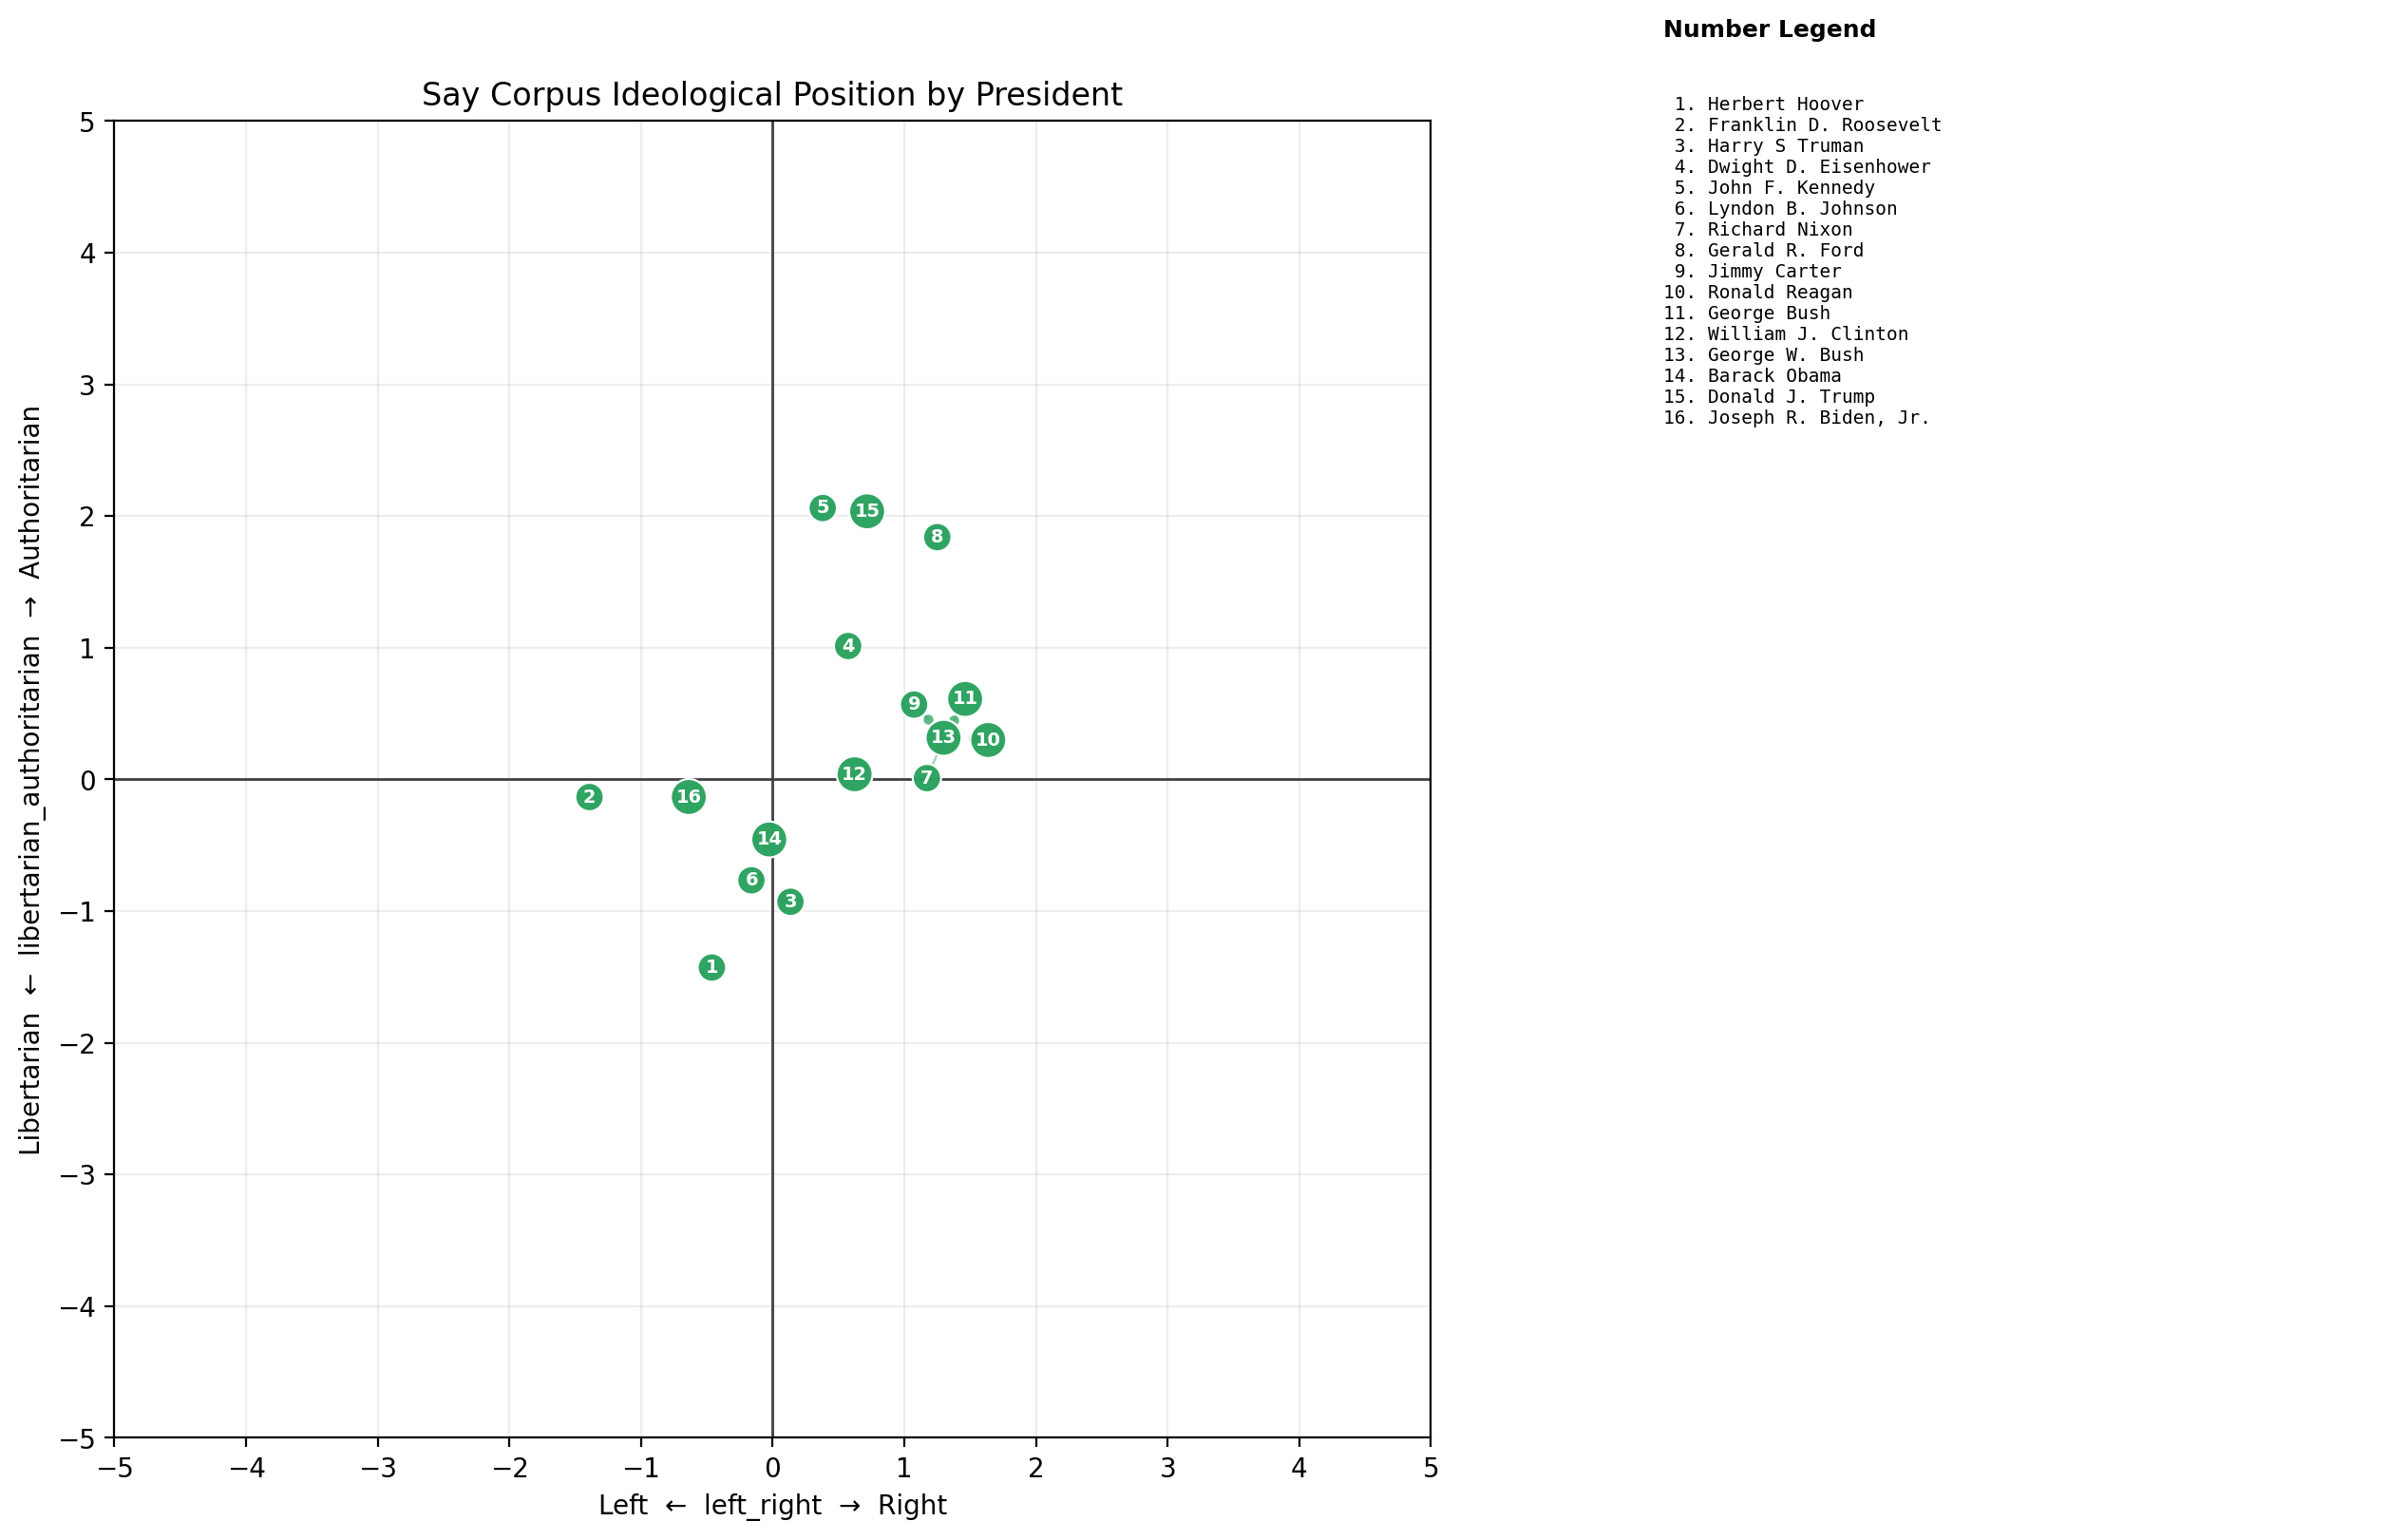

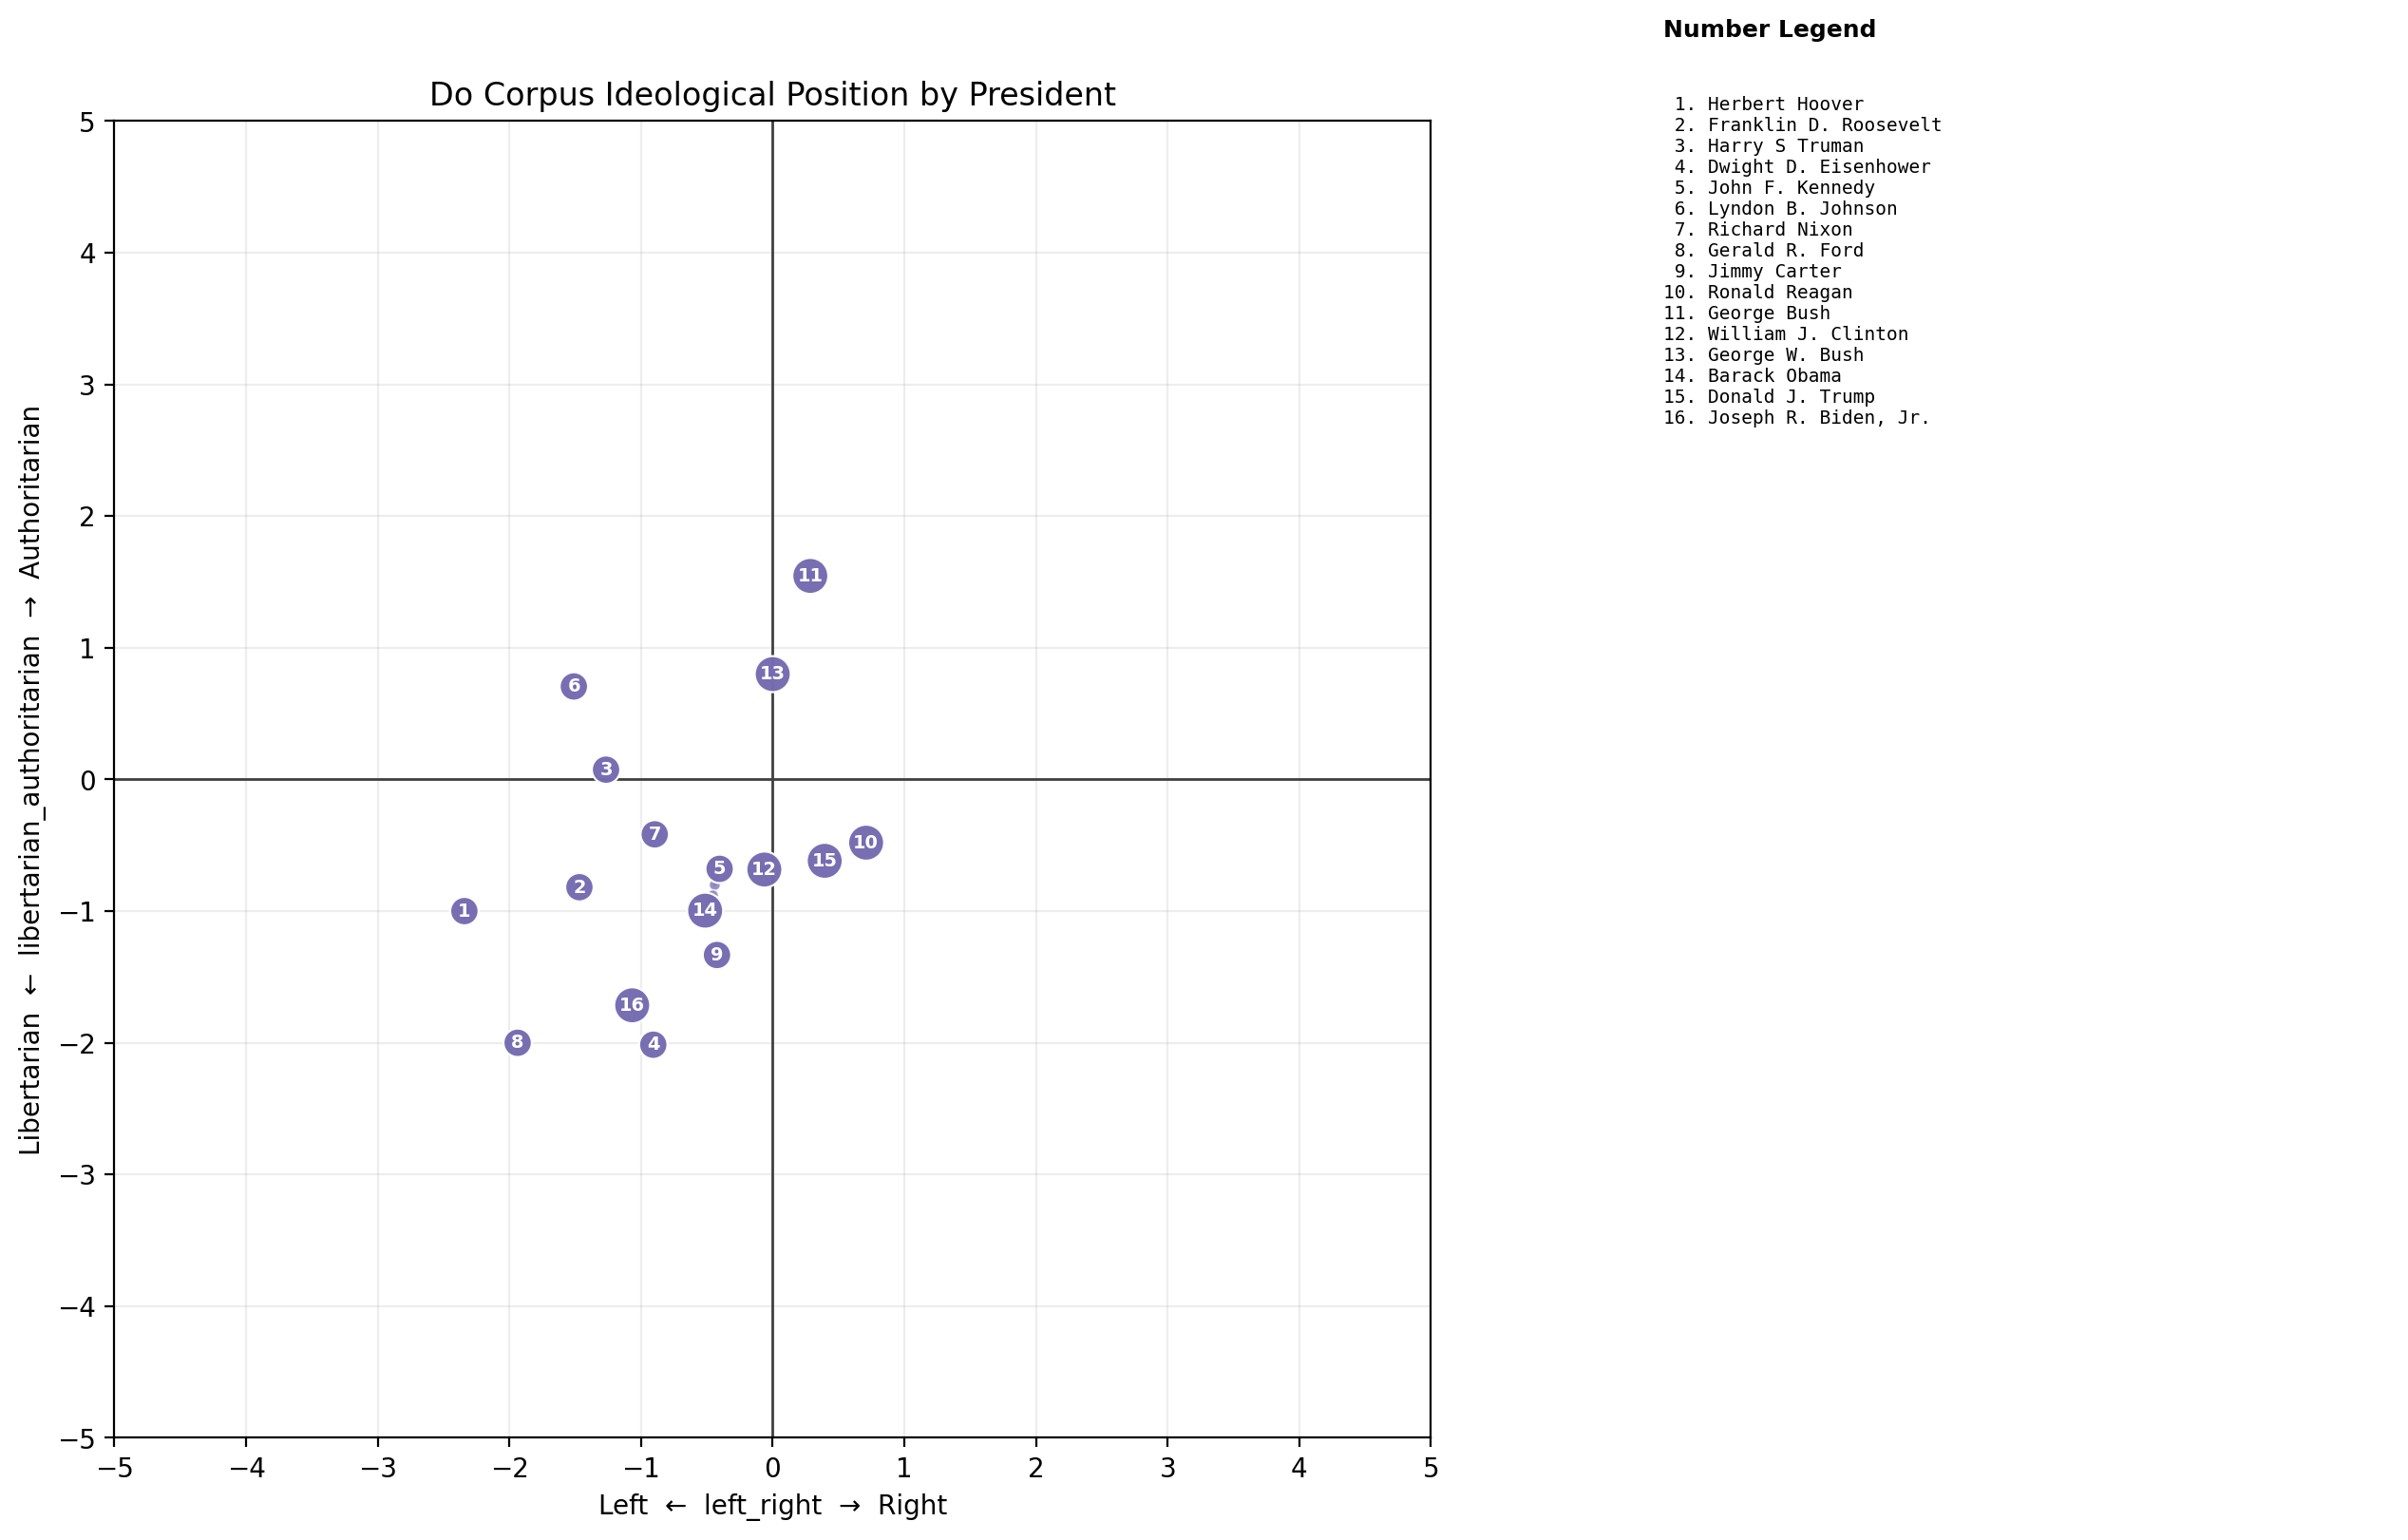

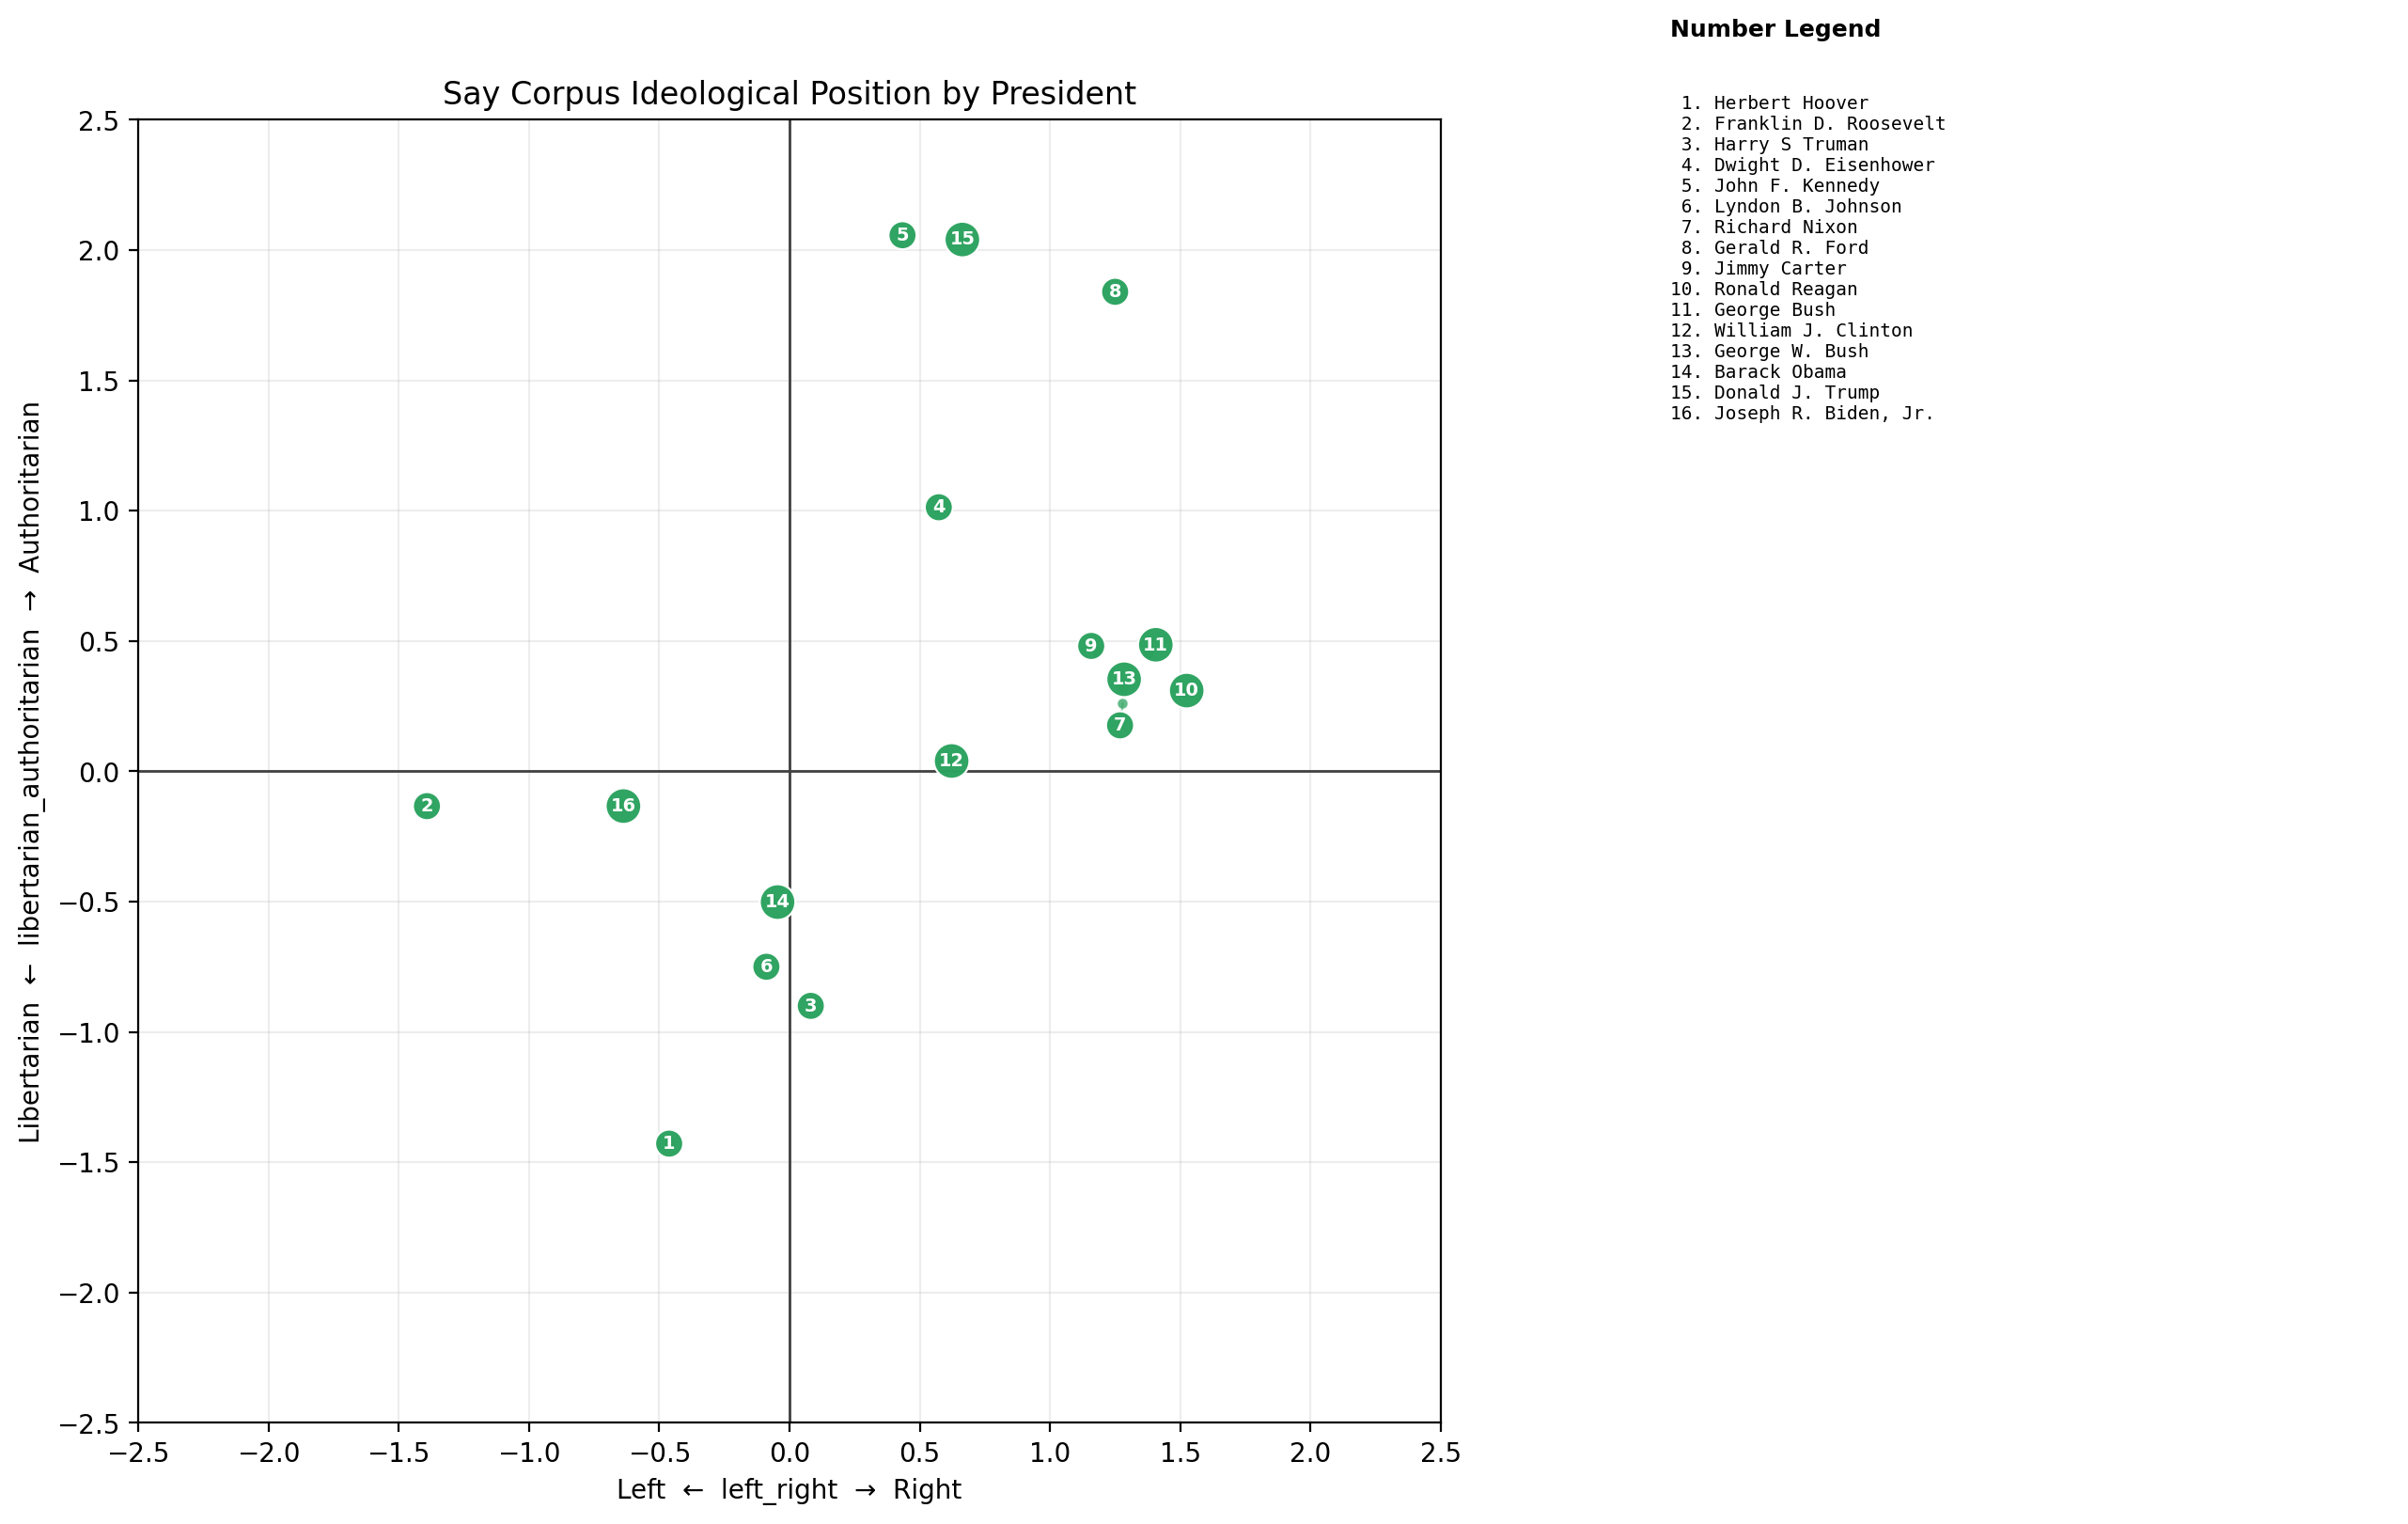

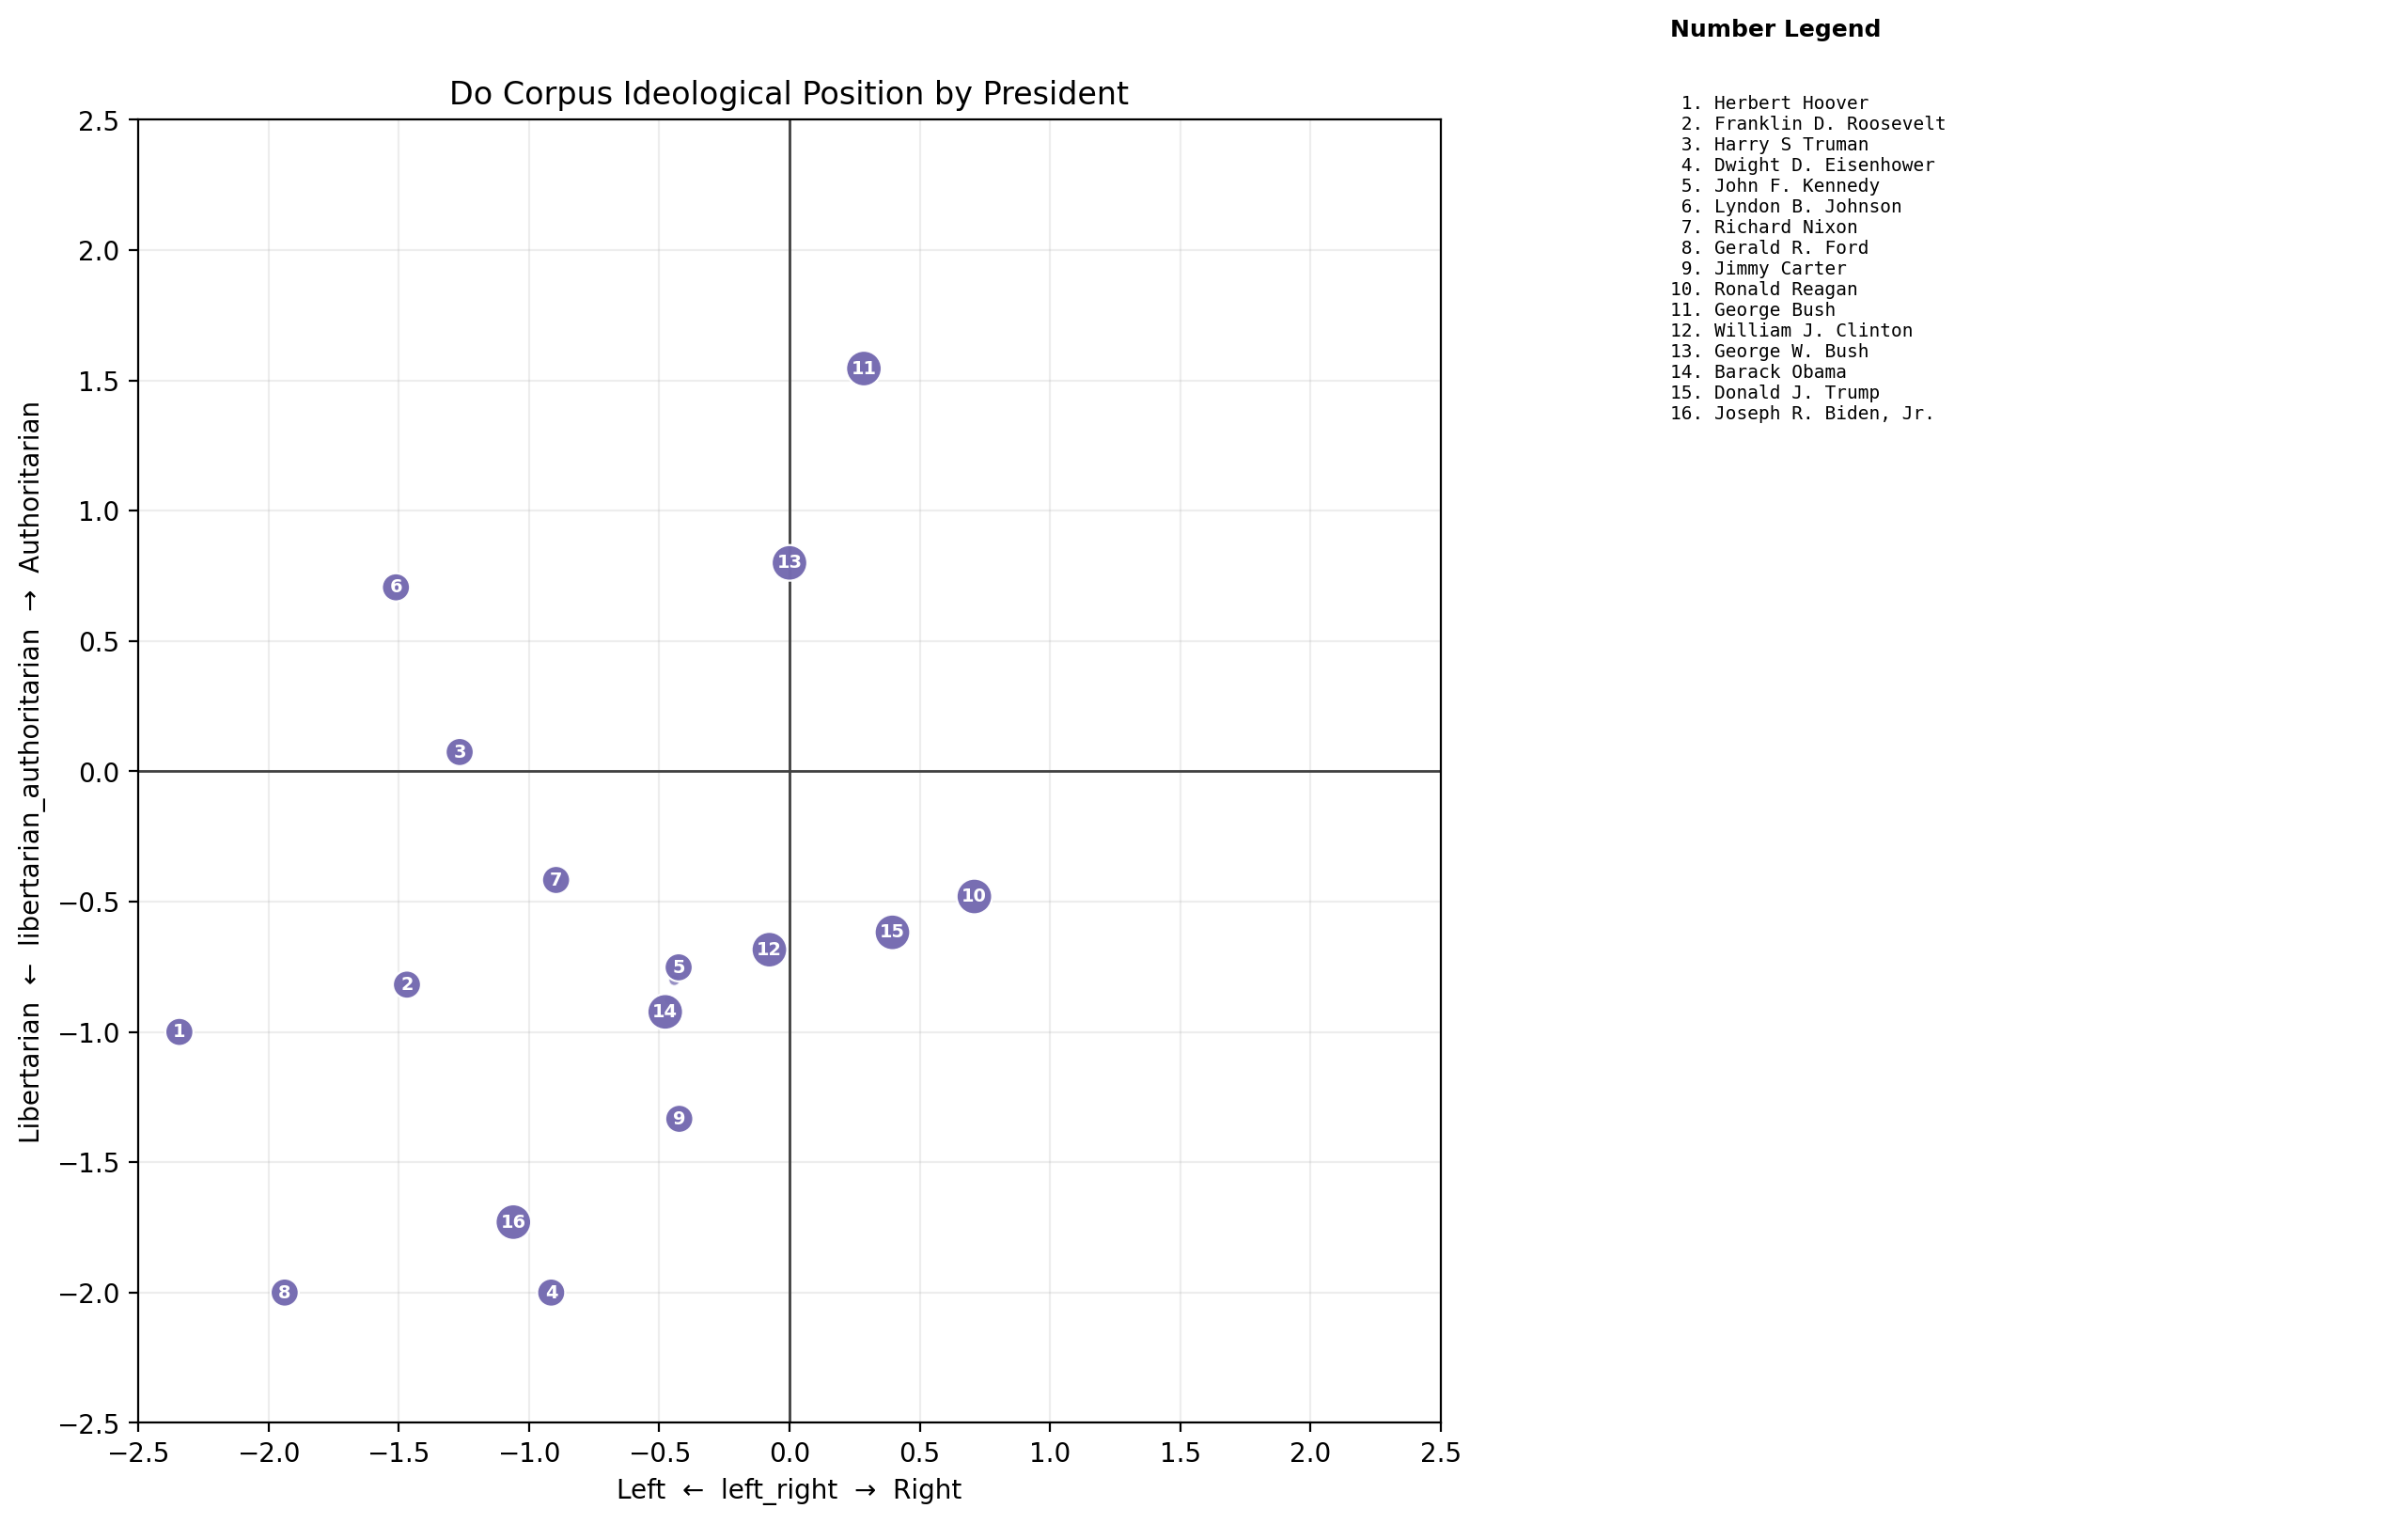

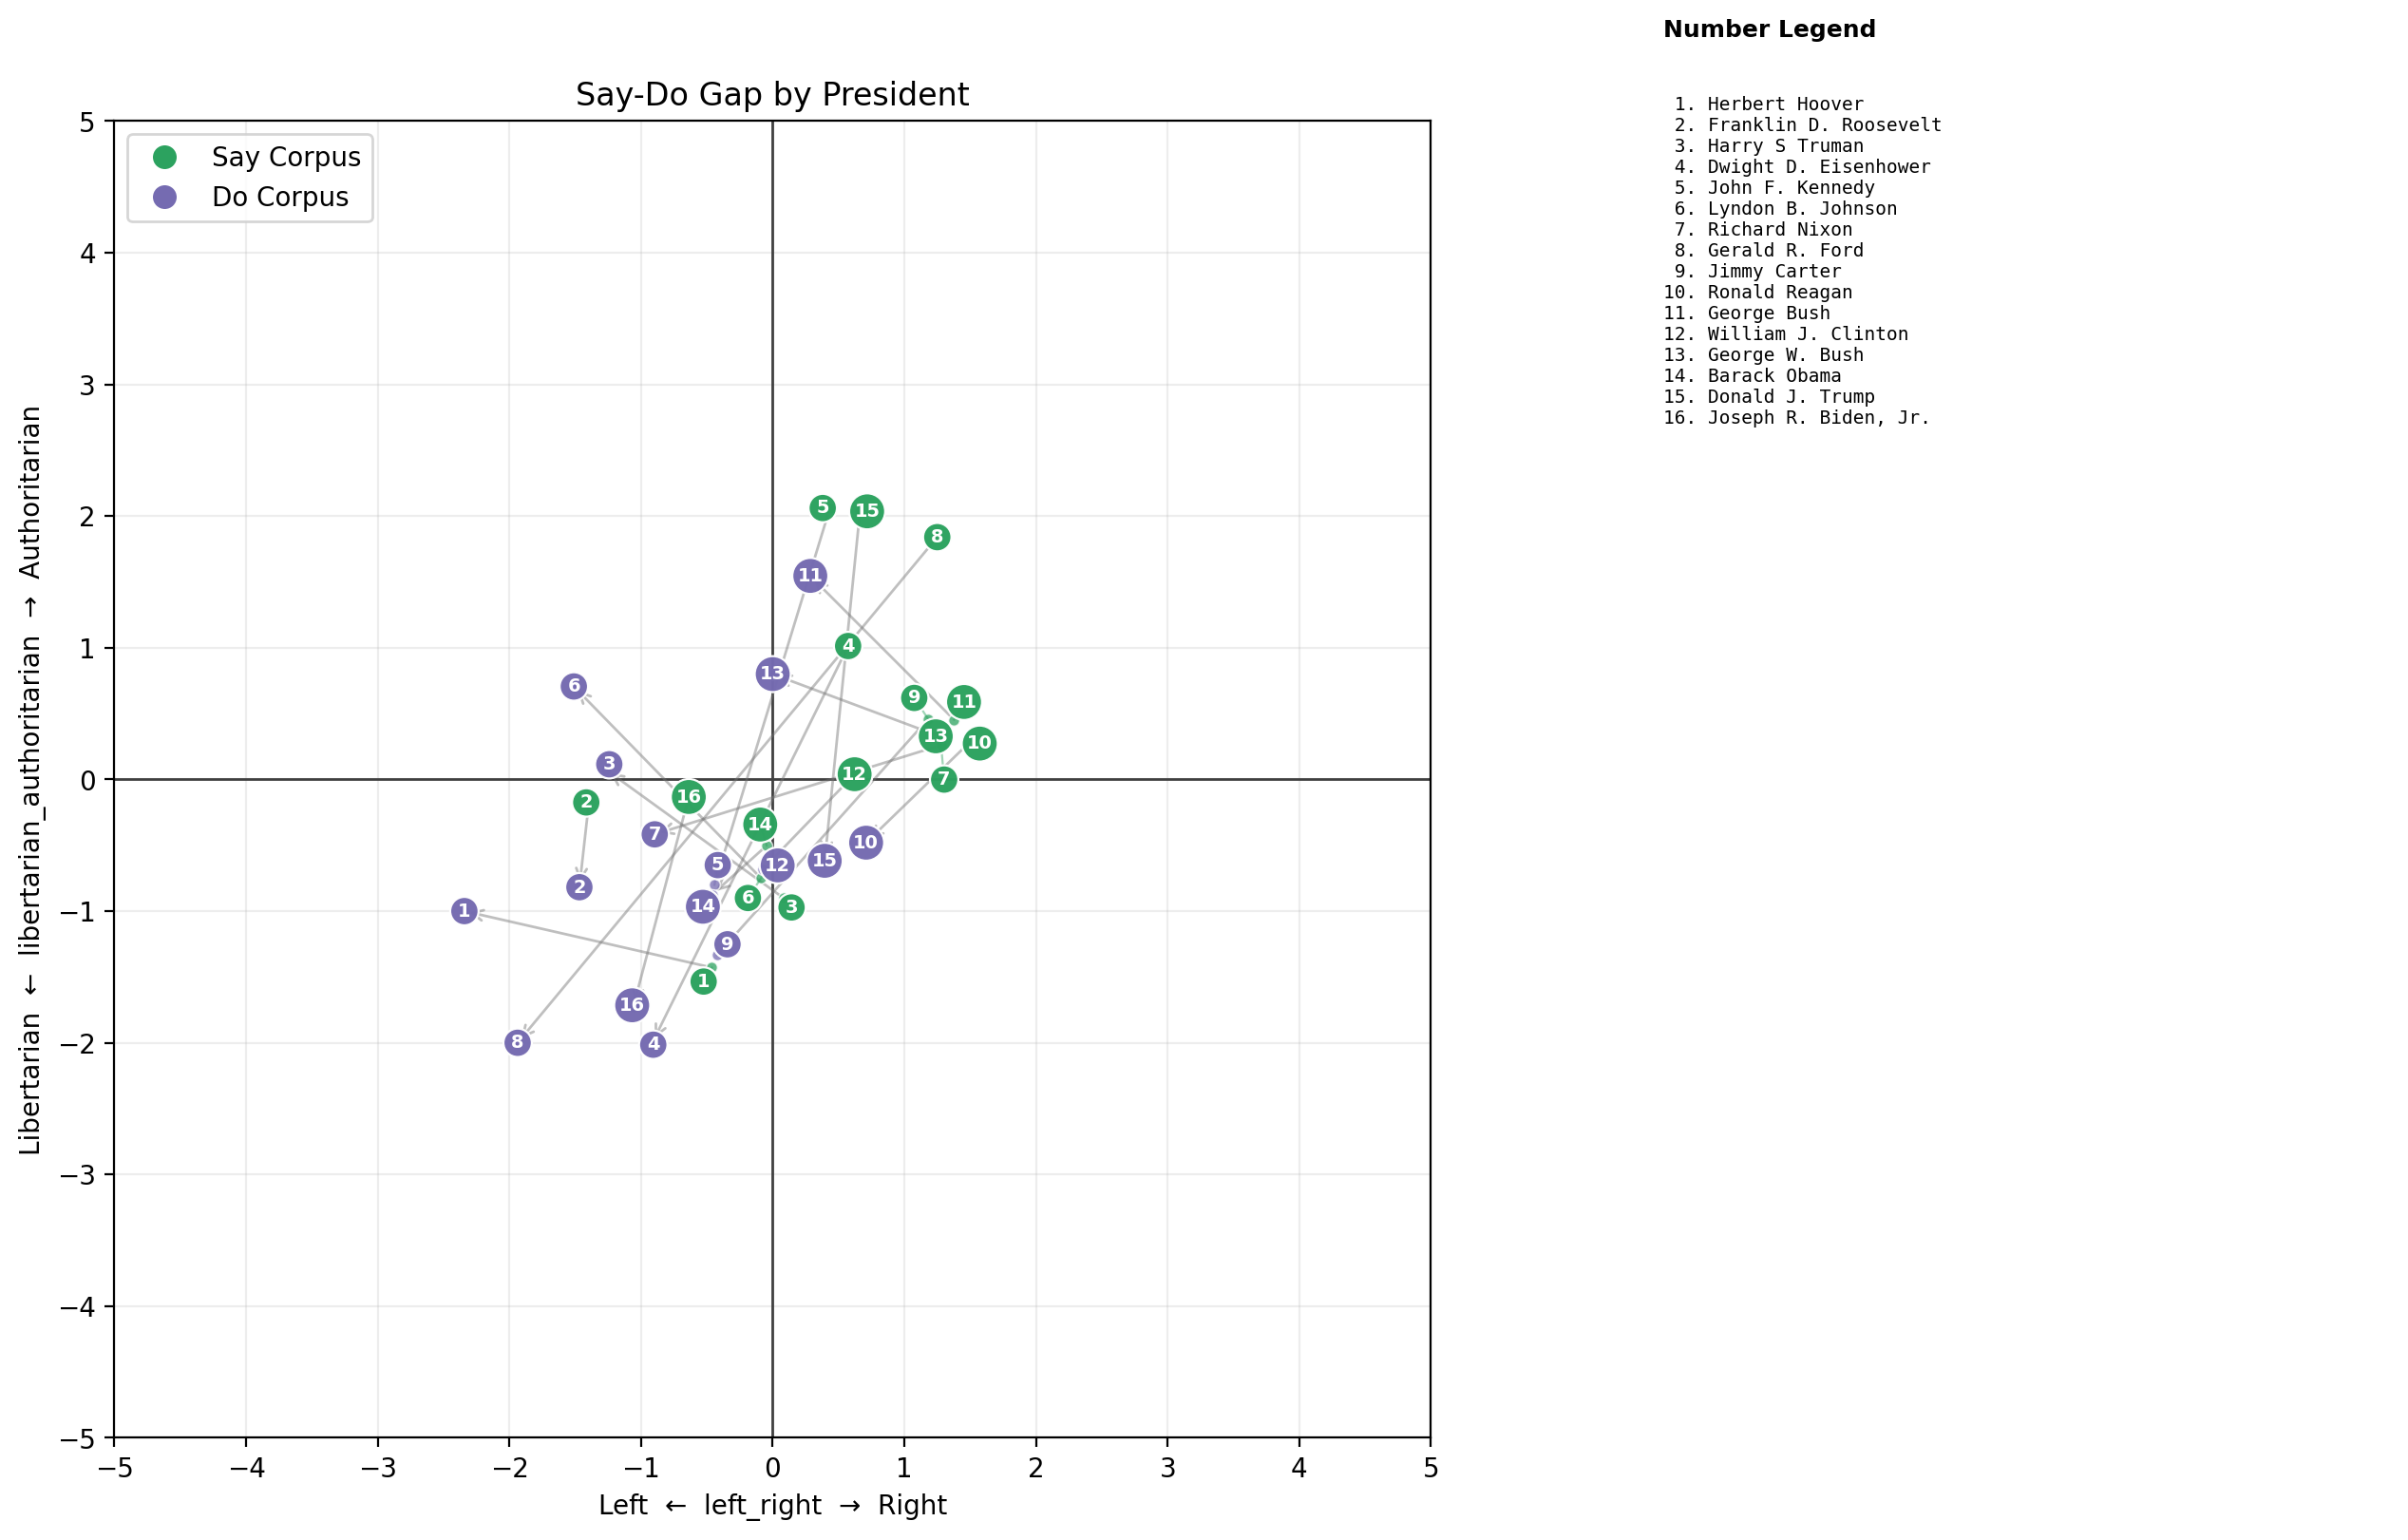

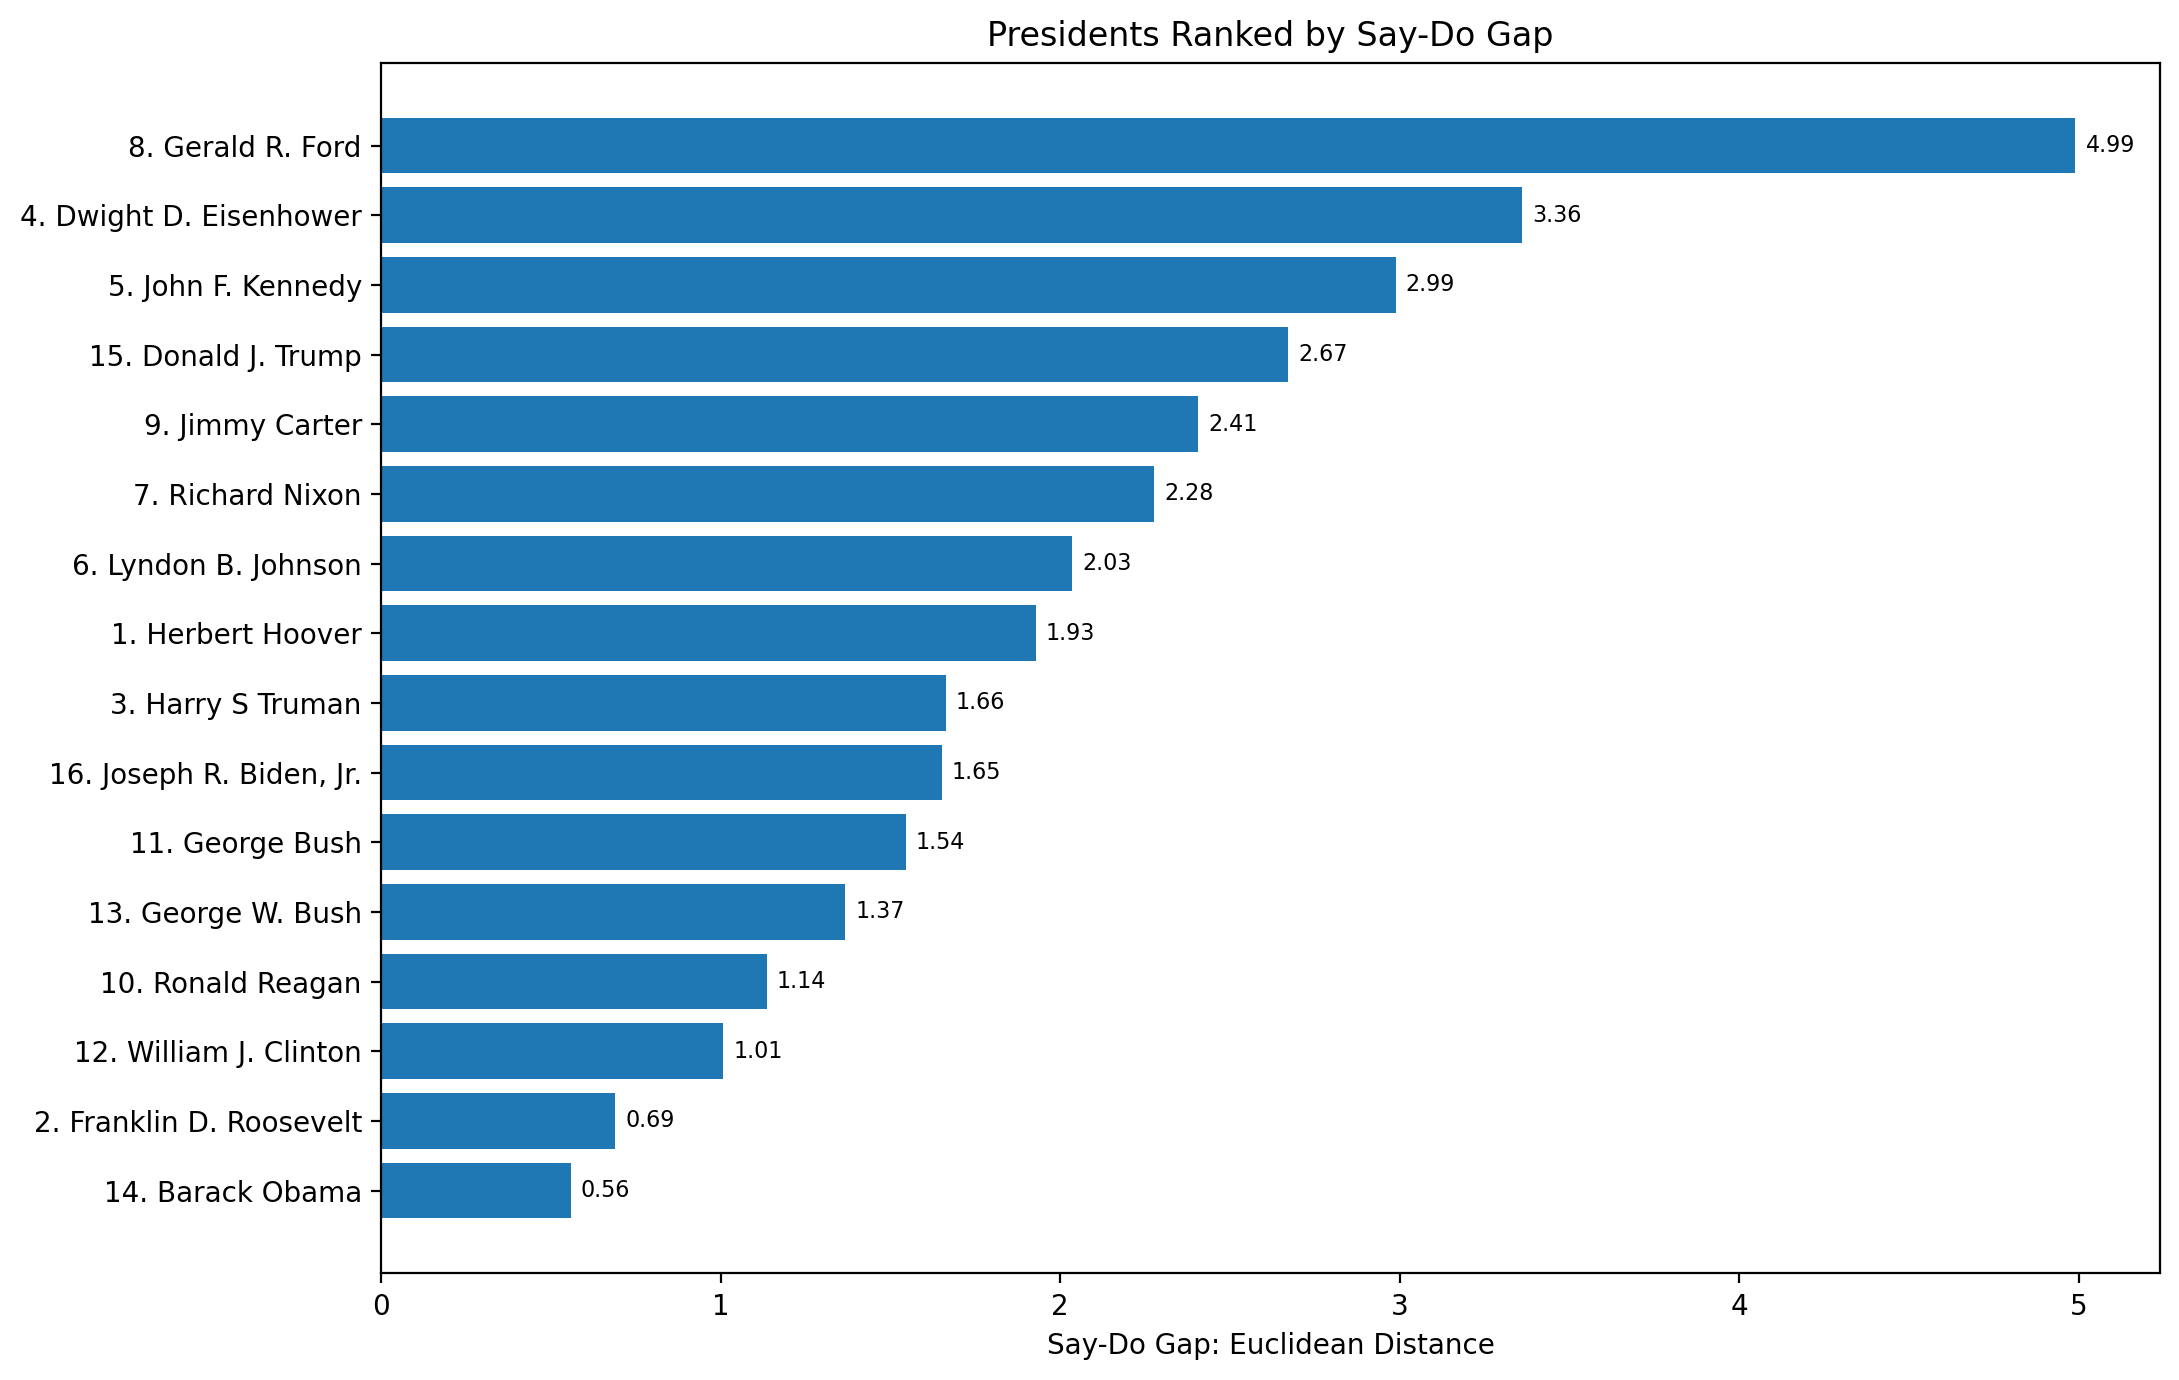

Done.
Scoring mode: document_presence_with_variant_and_family_caps
Minimum raw document-level hits required per corpus: 25
Variant document-hit cap: 25
Family hit cap: 100
Additional low-evidence manual exclusions: ['Andrew Johnson', 'William Howard Taft', 'Calvin Coolidge']
Chronology rule: Gerald Ford = 1974, George Bush = George H. W. Bush = 1989, George W. Bush = 2001.
Plot rule: true point stays fixed; number label is repelled only for readability.
Manual exclusions requested: 28
Manual exclusions found in evidence table: 28
Manual exclusions removed after confidence filter: 4
Presidents after manual exclusions: 17
Presidents removed for insufficient data: 1
Final kept presidents after all filters: 16
Dictionary rows used: 640
Unique dictionary variants used: 634
Final president-corpus rows scored: 32
Final president gaps computed: 16

Saved files:
process_outputs\dictionary_loaded_corpus_coverage_KEPT_ONLY.csv
process_outputs\dictionary_variant_hits_FINAL.csv
process_outputs\dict

,president_number,president,chronology_order
0,1,Herbert Hoover,1929
1,2,Franklin D. Roosevelt,1933
2,3,Harry S Truman,1945
3,4,Dwight D. Eisenhower,1953
4,5,John F. Kennedy,1961
5,6,Lyndon B. Johnson,1963
6,7,Richard Nixon,1969
7,8,Gerald R. Ford,1974
8,9,Jimmy Carter,1977
9,10,Ronald Reagan,1981



MANUAL EXCLUSION AUDIT


,excluded_president,exclusion_type,excluded_president_key,president,president_key,passes_confidence_filter_bool,found_in_evidence_filter,excluded_after_confidence_filter
0,George Washington,base_manual_exclusion,george washington,George Washington,george washington,False,True,False
1,John Adams,base_manual_exclusion,john adams,John Adams,john adams,False,True,False
2,Thomas Jefferson,base_manual_exclusion,thomas jefferson,Thomas Jefferson,thomas jefferson,False,True,False
3,James Madison,base_manual_exclusion,james madison,James Madison,james madison,False,True,False
4,James Monroe,base_manual_exclusion,james monroe,James Monroe,james monroe,False,True,False
5,John Quincy Adams,base_manual_exclusion,john quincy adams,John Quincy Adams,john quincy adams,False,True,False
6,Andrew Jackson,base_manual_exclusion,andrew jackson,Andrew Jackson,andrew jackson,False,True,False
7,Martin Van Buren,base_manual_exclusion,martin van buren,Martin van Buren,martin van buren,False,True,False
8,William Henry Harrison,base_manual_exclusion,william henry harrison,William Henry Harrison,william henry harrison,False,True,False
9,John Tyler,base_manual_exclusion,john tyler,John Tyler,john tyler,False,True,False



INSUFFICIENT DATA EXCLUSIONS


corpus_type,president,do_raw_document_hits,say_raw_document_hits,do_used_hits_after_caps,say_used_hits_after_caps,passes_minimum_hit_filter,insufficient_data_reason
0,William McKinley,10,6,10,6,False,say_and_do_below_minimum_raw_document_hits



TOP SAY-DO GAPS - FINAL FILTERED SAMPLE


,gap_rank_largest_gap_1,alignment_rank_smallest_gap_1,president_number,president,say_x_left_right,say_y_libertarian_authoritarian,do_x_left_right,do_y_libertarian_authoritarian,say_total_dictionary_hits_raw_document,do_total_dictionary_hits_raw_document,say_total_dictionary_hits,do_total_dictionary_hits,say_do_gap
0,1,16,8,Gerald R. Ford,1.250000,1.840000,-1.937500,-2.000000,165,35,165,35,4.990567
1,2,15,4,Dwight D. Eisenhower,0.573394,1.013333,-0.914286,-2.000000,293,41,293,41,3.360561
2,3,14,5,John F. Kennedy,0.433824,2.057143,-0.441860,-0.800000,171,53,171,53,2.988325
3,4,13,15,Donald J. Trump,0.663768,2.040816,0.395349,-0.617647,566,617,492,532,2.671980
4,5,12,9,Jimmy Carter,1.180873,0.459184,-0.422680,-1.333333,658,109,579,109,2.405099
5,6,11,7,Richard Nixon,1.279070,0.260870,-0.895652,-0.416667,66,127,66,127,2.277822
6,7,10,6,Lyndon B. Johnson,-0.088435,-0.750000,-1.510204,0.705882,195,66,195,66,2.034950
7,8,9,1,Herbert Hoover,-0.461538,-1.428571,-2.341463,-1.000000,106,42,98,42,1.928157
8,9,8,3,Harry S Truman,0.081818,-0.900000,-1.265823,0.074074,160,123,160,106,1.662816
9,10,7,16,"Joseph R. Biden, Jr.",-0.637255,-0.133333,-1.059701,-1.729730,234,400,234,372,1.651346


In [20]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 400)
pd.set_option("display.max_rows", 150)

OUTPUT_DIR = Path("process_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

dictionary_path = OUTPUT_DIR / "ideological_phrase_dictionary_FINAL.csv"
say_documents_csv = OUTPUT_DIR / "say_document_corpus.csv"
do_documents_csv = OUTPUT_DIR / "do_document_corpus.csv"
evidence_filter_csv = OUTPUT_DIR / "president_evidence_filter_table.csv"

coverage_output = OUTPUT_DIR / "dictionary_loaded_corpus_coverage_KEPT_ONLY.csv"
variant_hits_output = OUTPUT_DIR / "dictionary_variant_hits_FINAL.csv"
family_hits_output = OUTPUT_DIR / "dictionary_family_hits_FINAL.csv"
axis_scores_output = OUTPUT_DIR / "axis_scores_FINAL_long.csv"
president_scores_output = OUTPUT_DIR / "dictionary_president_corpus_scores_FINAL.csv"
gap_scores_output = OUTPUT_DIR / "dictionary_say_do_gap_scores_FINAL.csv"
legend_output = OUTPUT_DIR / "president_number_legend_mapping_FINAL.csv"
manual_exclusions_output = OUTPUT_DIR / "manual_president_exclusions_FINAL.csv"
insufficient_data_output = OUTPUT_DIR / "insufficient_data_president_exclusions_FINAL.csv"
document_variant_hits_output = OUTPUT_DIR / "dictionary_document_variant_hits_FINAL.csv"
all_president_scores_output = OUTPUT_DIR / "dictionary_president_corpus_scores_ALL_WITH_FLAGS.csv"
all_gap_scores_output = OUTPUT_DIR / "dictionary_say_do_gap_scores_ALL_WITH_FLAGS.csv"
scoring_settings_output = OUTPUT_DIR / "dictionary_scoring_settings_FINAL.csv"
excel_output = OUTPUT_DIR / "dictionary_based_full_outputs_FINAL.xlsx"

say_full_plot = OUTPUT_DIR / "say_corpus_numbered_markers_FINAL_full.png"
do_full_plot = OUTPUT_DIR / "do_corpus_numbered_markers_FINAL_full.png"
say_zoom_plot = OUTPUT_DIR / "say_corpus_numbered_markers_FINAL_zoom_2_5.png"
do_zoom_plot = OUTPUT_DIR / "do_corpus_numbered_markers_FINAL_zoom_2_5.png"
gap_plot = OUTPUT_DIR / "say_do_gap_FINAL.png"
gap_rank_plot = OUTPUT_DIR / "say_do_gap_ranked_FINAL.png"

party_corpus_output = OUTPUT_DIR / "dictionary_party_corpus_scores_FINAL.csv"
party_gap_output = OUTPUT_DIR / "dictionary_party_say_do_gap_scores_FINAL.csv"

SAY_COLOR = "#2CA25F"
DO_COLOR = "#756BB1"

REQUIRED_AXES = ["left_right", "libertarian_authoritarian"]

MIN_DICTIONARY_HITS_PER_CORPUS = 25
VARIANT_DOCUMENT_HIT_CAP = 25
FAMILY_HIT_CAP = 100

SCORING_MODE = "document_presence_with_variant_and_family_caps"

BASE_EXCLUDED_PRESIDENTS = [
    "George Washington",
    "John Adams",
    "Thomas Jefferson",
    "James Madison",
    "James Monroe",
    "John Quincy Adams",
    "Andrew Jackson",
    "Martin Van Buren",
    "William Henry Harrison",
    "John Tyler",
    "James K. Polk",
    "Zachary Taylor",
    "Millard Fillmore",
    "Franklin Pierce",
    "James Buchanan",
    "Abraham Lincoln",
    "Ulysses S. Grant",
    "Rutherford B. Hayes",
    "James A. Garfield",
    "Chester A. Arthur",
    "Grover Cleveland",
    "Benjamin Harrison",
    "Theodore Roosevelt",
    "Woodrow Wilson",
    "Warren G. Harding",
]

ADDITIONAL_LOW_EVIDENCE_EXCLUSIONS = [
    "Andrew Johnson",
    "William Howard Taft",
    "Calvin Coolidge",
]

EXCLUDED_PRESIDENTS = BASE_EXCLUDED_PRESIDENTS + ADDITIONAL_LOW_EVIDENCE_EXCLUSIONS

DIRECTION_SIGN = {
    "left": -1,
    "right": 1,
    "libertarian": -1,
    "authoritarian": 1,
}

PRESIDENT_CHRONOLOGY = {
    "george washington": 1789,
    "john adams": 1797,
    "thomas jefferson": 1801,
    "james madison": 1809,
    "james monroe": 1817,
    "john quincy adams": 1825,
    "andrew jackson": 1829,
    "martin van buren": 1837,
    "william henry harrison": 1841,
    "john tyler": 1841.3,
    "james k polk": 1845,
    "zachary taylor": 1849,
    "millard fillmore": 1850,
    "franklin pierce": 1853,
    "james buchanan": 1857,
    "abraham lincoln": 1861,
    "andrew johnson": 1865,
    "ulysses s grant": 1869,
    "rutherford b hayes": 1877,
    "james a garfield": 1881,
    "chester a arthur": 1881.5,
    "grover cleveland": 1885,
    "benjamin harrison": 1889,
    "william mckinley": 1897,
    "theodore roosevelt": 1901,
    "william howard taft": 1909,
    "woodrow wilson": 1913,
    "warren g harding": 1921,
    "calvin coolidge": 1923,
    "herbert hoover": 1929,
    "franklin d roosevelt": 1933,
    "harry s truman": 1945,
    "dwight d eisenhower": 1953,
    "john f kennedy": 1961,
    "lyndon b johnson": 1963,
    "richard nixon": 1969,
    "gerald ford": 1974,
    "gerald r ford": 1974,
    "jimmy carter": 1977,
    "ronald reagan": 1981,
    "george bush": 1989,
    "george h w bush": 1989,
    "george hw bush": 1989,
    "george herbert walker bush": 1989,
    "william j clinton": 1993,
    "bill clinton": 1993,
    "george w bush": 2001,
    "george walker bush": 2001,
    "barack obama": 2009,
    "donald j trump": 2017,
    "donald trump": 2017,
    "joseph r biden jr": 2021,
    "joe biden": 2021,
    "joseph biden": 2021,
}

WORD_RE = re.compile(r"\b[a-zA-Z0-9]+\b")

def read_csv_safe(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path, encoding="utf-8-sig")

def canonical_name(x):
    x = "" if pd.isna(x) else str(x)
    x = x.lower()
    x = x.replace("&", " and ")
    x = re.sub(r"[^a-z0-9]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def chronology_order(name):
    key = canonical_name(name)

    if key in PRESIDENT_CHRONOLOGY:
        return PRESIDENT_CHRONOLOGY[key]

    if "trump" in key and any(token in key for token in ["47", "second", "2nd", "2025"]):
        return 2025

    for candidate, year in PRESIDENT_CHRONOLOGY.items():
        if key == candidate or key.startswith(candidate) or candidate in key:
            return year

    return 9999

def normalize_dictionary_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def count_words(x):
    return len(WORD_RE.findall("" if pd.isna(x) else str(x)))

def find_col(df, candidates, required=True, label="column"):
    direct = {str(c).lower(): c for c in df.columns}
    compact = {re.sub(r"[^a-z0-9]", "", str(c).lower()): c for c in df.columns}

    for candidate in candidates:
        candidate_lower = candidate.lower()
        candidate_compact = re.sub(r"[^a-z0-9]", "", candidate_lower)

        if candidate_lower in direct:
            return direct[candidate_lower]

        if candidate_compact in compact:
            return compact[candidate_compact]

    if required:
        raise ValueError(f"Could not find {label}. Available columns: {list(df.columns)}")

    return None

def find_text_col(df):
    candidates = [
        "final_text",
        "text_final",
        "normalized_text",
        "standardized_text",
        "preprocessed_text",
        "processed_text",
        "clean_text",
        "cleaned_text",
        "document_text",
        "chunk_text",
        "transcript_text",
        "transcript",
        "body",
        "text",
    ]

    present = []
    for candidate in candidates:
        col = find_col(df, [candidate], required=False)
        if col is not None and col not in present:
            present.append(col)

    if present:
        return max(present, key=lambda c: df[c].fillna("").astype(str).str.len().mean())

    object_cols = [
        c for c in df.columns
        if df[c].dtype == "object"
        and canonical_name(c) not in {"president", "title", "url", "date", "source", "corpus type"}
    ]

    if not object_cols:
        raise ValueError(f"Could not identify text column. Available columns: {list(df.columns)}")

    return max(object_cols, key=lambda c: df[c].fillna("").astype(str).str.len().mean())

def truthy(x):
    if pd.isna(x):
        return False
    if isinstance(x, (bool, np.bool_)):
        return bool(x)
    return str(x).strip().lower() in {"true", "1", "yes", "y", "pass", "passed", "keep", "kept"}

def variant_to_regex(variant):
    pieces = [re.escape(piece) for piece in str(variant).split()]
    return r"\s+".join(pieces)

def load_corpus(path, corpus_type):
    df = read_csv_safe(path)

    president_col = find_col(df, ["president", "president_name", "name"], label="president column")
    text_col = find_text_col(df)
    doc_col = find_col(df, ["document_id", "doc_id", "source_id", "interview_id", "speech_id", "order_id", "id"], required=False)
    date_col = find_col(df, ["date", "document_date", "speech_date", "order_date", "year"], required=False)
    party_col = find_col(df, ["party", "political_party", "president_party"], required=False)

    out = pd.DataFrame()
    out["president"] = df[president_col].fillna("").astype(str).str.strip()
    out["president_key"] = out["president"].map(canonical_name)
    out["corpus_type"] = corpus_type
    out["text"] = df[text_col].fillna("").astype(str)

    if doc_col is not None:
        out["document_id"] = df[doc_col].fillna("").astype(str)
    else:
        out["document_id"] = [f"{corpus_type}_{i}" for i in range(len(df))]

    if date_col is not None:
        out["date_raw"] = df[date_col]
    else:
        out["date_raw"] = np.nan

    if party_col is not None:
        out["party"] = df[party_col]
    else:
        out["party"] = np.nan

    out = out[(out["president_key"] != "") & (out["text"].str.strip() != "")].copy()
    out["word_count"] = out["text"].map(count_words)

    return out

def build_legend_df(presidents):
    base = pd.DataFrame({"president": sorted(pd.Series(presidents).dropna().unique())})
    base["president_key"] = base["president"].map(canonical_name)
    base["chronology_order"] = base["president"].map(chronology_order)
    base = base.sort_values(["chronology_order", "president"]).reset_index(drop=True)
    base["president_number"] = np.arange(1, len(base) + 1)
    return base[["president_number", "president", "chronology_order"]].copy()

def add_number(df, legend):
    if df.empty or "president" not in df.columns:
        return df
    return df.merge(legend[["president", "president_number"]], on="president", how="left")

excluded_presidents_df = pd.DataFrame({
    "excluded_president": EXCLUDED_PRESIDENTS,
    "exclusion_type": (
        ["base_manual_exclusion"] * len(BASE_EXCLUDED_PRESIDENTS)
        + ["additional_low_evidence_manual_exclusion"] * len(ADDITIONAL_LOW_EVIDENCE_EXCLUSIONS)
    )
})
excluded_presidents_df["excluded_president_key"] = excluded_presidents_df["excluded_president"].map(canonical_name)
excluded_keys = set(excluded_presidents_df["excluded_president_key"])

dictionary_raw = read_csv_safe(dictionary_path)

variant_col = find_col(dictionary_raw, ["variant", "phrase_variant", "dictionary_variant", "phrase", "term", "pattern"], label="dictionary variant column")
variant_clean_col = find_col(dictionary_raw, ["variant_clean", "clean_variant", "normalized_variant"], required=False)
family_col = find_col(dictionary_raw, ["family", "phrase_family", "dictionary_family"], label="dictionary family column")
axis_col = find_col(dictionary_raw, ["axis", "ideological_axis"], label="dictionary axis column")
direction_col = find_col(dictionary_raw, ["direction", "pole", "ideological_direction"], label="dictionary direction column")
intensity_col = find_col(dictionary_raw, ["intensity_0_to_5", "intensity", "weight", "level"], label="dictionary intensity column")
theme_col = find_col(dictionary_raw, ["theme", "category", "dictionary_theme"], required=False)
direction_sign_col = find_col(dictionary_raw, ["direction_sign", "sign"], required=False)

dictionary = pd.DataFrame()
dictionary["variant"] = dictionary_raw[variant_col].fillna("").astype(str)
dictionary["family"] = dictionary_raw[family_col].fillna("").astype(str)
dictionary["axis"] = dictionary_raw[axis_col].fillna("").astype(str).str.strip().str.lower().str.replace("-", "_").str.replace(" ", "_")
dictionary["direction"] = dictionary_raw[direction_col].fillna("").astype(str).str.strip().str.lower().str.replace("-", "_").str.replace(" ", "_")
dictionary["intensity_0_to_5"] = pd.to_numeric(dictionary_raw[intensity_col], errors="coerce").fillna(1).clip(0, 5)

if variant_clean_col is not None:
    dictionary["variant_clean"] = dictionary_raw[variant_clean_col].fillna("").astype(str).map(normalize_dictionary_text)
else:
    dictionary["variant_clean"] = dictionary["variant"].map(normalize_dictionary_text)

if theme_col is not None:
    dictionary["theme"] = dictionary_raw[theme_col].fillna("").astype(str)
else:
    dictionary["theme"] = ""

dictionary = dictionary[dictionary["variant_clean"] != ""].copy()

if (dictionary["axis"] == "libdem_authoritarian").any():
    raise ValueError("The dictionary still contains libdem_authoritarian. Rebuild the dictionary using libertarian_authoritarian.")

dictionary = dictionary[dictionary["axis"].isin(REQUIRED_AXES)].copy()

missing_axes = sorted(set(REQUIRED_AXES) - set(dictionary["axis"]))
if missing_axes:
    raise ValueError(f"Missing required dictionary axes: {missing_axes}")

bad_directions = sorted(set(dictionary["direction"]) - set(DIRECTION_SIGN))
if bad_directions:
    raise ValueError(f"Unexpected dictionary directions: {bad_directions}")

if direction_sign_col is not None:
    dictionary["direction_sign"] = pd.to_numeric(dictionary_raw[direction_sign_col], errors="coerce")
    dictionary["direction_sign"] = dictionary["direction_sign"].fillna(dictionary["direction"].map(DIRECTION_SIGN))
else:
    dictionary["direction_sign"] = dictionary["direction"].map(DIRECTION_SIGN)

dictionary["variant_word_count"] = dictionary["variant_clean"].str.split().str.len()
dictionary["variant_char_count"] = dictionary["variant_clean"].str.len()

dictionary = dictionary.drop_duplicates(
    subset=["variant_clean", "family", "axis", "direction", "intensity_0_to_5", "theme"]
).copy()

unique_variants = (
    dictionary
    .sort_values(["variant_word_count", "variant_char_count", "variant_clean"], ascending=[False, False, True])
    ["variant_clean"]
    .drop_duplicates()
    .tolist()
)

if len(unique_variants) == 0:
    raise ValueError("No usable dictionary variants were found.")

dictionary_pattern = r"(?<![a-z])(?:" + "|".join(variant_to_regex(v) for v in unique_variants) + r")(?![a-z])"
dictionary_regex = re.compile(dictionary_pattern)

evidence_raw = read_csv_safe(evidence_filter_csv)
evidence_president_col = find_col(evidence_raw, ["president", "president_name", "name"], label="evidence president column")
evidence_pass_col = find_col(evidence_raw, ["passes_confidence_filter", "pass_confidence_filter", "confidence_filter", "kept"], label="passes_confidence_filter column")
evidence_party_col = find_col(evidence_raw, ["party", "political_party", "president_party"], required=False)

evidence = evidence_raw.copy()
evidence["president"] = evidence[evidence_president_col].fillna("").astype(str).str.strip()
evidence["president_key"] = evidence["president"].map(canonical_name)
evidence["passes_confidence_filter_bool"] = evidence[evidence_pass_col].map(truthy)

if evidence_party_col is not None:
    evidence["party"] = evidence[evidence_party_col].fillna("").astype(str).str.strip()
    evidence.loc[evidence["party"] == "", "party"] = np.nan
else:
    evidence["party"] = np.nan

evidence_keep_before_manual_exclusions = evidence[evidence["passes_confidence_filter_bool"]].copy()
manual_excluded_from_kept = evidence_keep_before_manual_exclusions[
    evidence_keep_before_manual_exclusions["president_key"].isin(excluded_keys)
].copy()

evidence_keep = evidence_keep_before_manual_exclusions[
    ~evidence_keep_before_manual_exclusions["president_key"].isin(excluded_keys)
].copy()

if evidence_keep.empty:
    raise ValueError("No presidents remain after confidence filter and manual exclusions.")

say_docs = load_corpus(say_documents_csv, "say")
do_docs = load_corpus(do_documents_csv, "do")

corpus_docs = pd.concat([say_docs, do_docs], ignore_index=True)
corpus_docs["date_parsed"] = pd.to_datetime(corpus_docs["date_raw"], errors="coerce")

kept_keys = set(evidence_keep["president_key"])
corpus_docs = corpus_docs[corpus_docs["president_key"].isin(kept_keys)].copy()
corpus_docs = corpus_docs[~corpus_docs["president_key"].isin(excluded_keys)].copy()

if corpus_docs.empty:
    raise ValueError("After applying the confidence filter and manual exclusions, no corpus rows remain.")

name_map = (
    evidence_keep.drop_duplicates("president_key")
    .set_index("president_key")["president"]
    .to_dict()
)

party_map = (
    evidence_keep.dropna(subset=["party"])
    .drop_duplicates("president_key")
    .set_index("president_key")["party"]
    .to_dict()
)

corpus_docs["president"] = corpus_docs["president_key"].map(name_map).fillna(corpus_docs["president"])
corpus_docs["party"] = corpus_docs["president_key"].map(party_map).fillna(corpus_docs["party"])

doc_stats = (
    corpus_docs
    .groupby(["president", "corpus_type"], as_index=False)
    .agg(
        document_count=("document_id", "nunique"),
        row_count=("text", "size"),
        total_words=("word_count", "sum"),
        first_date=("date_parsed", "min"),
    )
)

document_level = (
    corpus_docs
    .assign(text_for_matching=corpus_docs["text"].map(normalize_dictionary_text))
    .groupby(["president", "president_key", "corpus_type", "document_id"], as_index=False)
    .agg(
        text=("text_for_matching", " ".join),
        document_words=("word_count", "sum"),
        first_date=("date_parsed", "min"),
        party=("party", "first"),
    )
)

combined_text = (
    document_level
    .groupby(["president", "corpus_type"], as_index=False)
    .agg(text=("text", " ".join))
)

combined = doc_stats.merge(combined_text, on=["president", "corpus_type"], how="left")

document_hit_rows = []

for row in document_level.itertuples(index=False):
    found_variants = sorted(set(
        normalize_dictionary_text(match.group(0))
        for match in dictionary_regex.finditer(row.text)
    ))

    for variant_clean in found_variants:
        document_hit_rows.append({
            "president": row.president,
            "corpus_type": row.corpus_type,
            "document_id": row.document_id,
            "variant_clean": variant_clean,
            "document_presence_hit": 1,
        })

dictionary_meta_cols = [
    "variant_clean",
    "variant",
    "family",
    "theme",
    "axis",
    "direction",
    "direction_sign",
    "intensity_0_to_5",
]

dictionary_meta = dictionary[dictionary_meta_cols].drop_duplicates().copy()

document_variant_hits_cols = [
    "president",
    "corpus_type",
    "document_id",
    "variant_clean",
    "variant",
    "family",
    "theme",
    "axis",
    "direction",
    "direction_sign",
    "intensity_0_to_5",
    "document_presence_hit",
]

if document_hit_rows:
    document_variant_hits = pd.DataFrame(document_hit_rows)
    document_variant_hits = document_variant_hits.merge(dictionary_meta, on="variant_clean", how="left")

    unmatched = document_variant_hits[document_variant_hits["axis"].isna()]["variant_clean"].drop_duplicates().tolist()
    if unmatched:
        raise ValueError(f"Matched variants were not found in dictionary metadata: {unmatched[:20]}")

    document_variant_hits = document_variant_hits[document_variant_hits_cols].copy()
else:
    document_variant_hits = pd.DataFrame(columns=document_variant_hits_cols)

variant_hits_cols = [
    "president",
    "corpus_type",
    "variant_clean",
    "variant",
    "family",
    "theme",
    "axis",
    "direction",
    "direction_sign",
    "intensity_0_to_5",
    "raw_document_hits",
    "variant_hit_cap",
    "hits",
    "weighted_hits",
    "signed_weighted_hits",
    "total_words",
    "hits_per_10k_words",
]

if not document_variant_hits.empty:
    group_cols = [
        "president",
        "corpus_type",
        "variant_clean",
        "variant",
        "family",
        "theme",
        "axis",
        "direction",
        "direction_sign",
        "intensity_0_to_5",
    ]

    variant_hits = (
        document_variant_hits
        .groupby(group_cols, as_index=False, dropna=False)
        .agg(raw_document_hits=("document_presence_hit", "sum"))
    )

    variant_hits["variant_hit_cap"] = VARIANT_DOCUMENT_HIT_CAP
    variant_hits["hits"] = variant_hits["raw_document_hits"].clip(upper=VARIANT_DOCUMENT_HIT_CAP)
    variant_hits["weighted_hits"] = variant_hits["hits"] * variant_hits["intensity_0_to_5"]
    variant_hits["signed_weighted_hits"] = variant_hits["hits"] * variant_hits["intensity_0_to_5"] * variant_hits["direction_sign"]

    word_lookup = combined[["president", "corpus_type", "total_words"]].copy()
    variant_hits = variant_hits.merge(word_lookup, on=["president", "corpus_type"], how="left")
    variant_hits["hits_per_10k_words"] = np.where(
        variant_hits["total_words"] > 0,
        variant_hits["hits"] / variant_hits["total_words"] * 10000,
        0,
    )

    variant_hits = variant_hits[variant_hits_cols].copy()
else:
    variant_hits = pd.DataFrame(columns=variant_hits_cols)

family_hits_cols = [
    "president",
    "corpus_type",
    "axis",
    "direction",
    "direction_sign",
    "family",
    "theme",
    "intensity_0_to_5",
    "raw_document_hits",
    "hits_after_variant_cap",
    "family_hit_cap",
    "hits",
    "weighted_hits",
    "signed_weighted_hits",
    "unique_variants_hit",
    "total_words",
    "hits_per_10k_words",
]

if not variant_hits.empty:
    family_hits = (
        variant_hits
        .groupby(
            ["president", "corpus_type", "axis", "direction", "direction_sign", "family", "theme", "intensity_0_to_5"],
            as_index=False,
            dropna=False,
        )
        .agg(
            raw_document_hits=("raw_document_hits", "sum"),
            hits_after_variant_cap=("hits", "sum"),
            unique_variants_hit=("variant_clean", "nunique"),
        )
    )

    family_hits["family_hit_cap"] = FAMILY_HIT_CAP
    family_hits["hits"] = family_hits["hits_after_variant_cap"].clip(upper=FAMILY_HIT_CAP)
    family_hits["weighted_hits"] = family_hits["hits"] * family_hits["intensity_0_to_5"]
    family_hits["signed_weighted_hits"] = family_hits["hits"] * family_hits["intensity_0_to_5"] * family_hits["direction_sign"]

    family_hits = family_hits.merge(
        combined[["president", "corpus_type", "total_words"]],
        on=["president", "corpus_type"],
        how="left",
    )

    family_hits["hits_per_10k_words"] = np.where(
        family_hits["total_words"] > 0,
        family_hits["hits"] / family_hits["total_words"] * 10000,
        0,
    )

    family_hits = family_hits[family_hits_cols].copy()
else:
    family_hits = pd.DataFrame(columns=family_hits_cols)

axis_base = combined[["president", "corpus_type", "document_count", "row_count", "total_words"]].copy()
axis_base["_key"] = 1
axes_df = pd.DataFrame({"axis": REQUIRED_AXES})
axes_df["_key"] = 1
axis_base = axis_base.merge(axes_df, on="_key", how="outer").drop(columns="_key")

axis_agg_cols = [
    "president",
    "corpus_type",
    "axis",
    "total_axis_hits_raw_document",
    "total_axis_hits_after_variant_cap",
    "total_axis_hits",
    "signed_weighted_hits",
    "weighted_hits",
    "unique_variants_hit",
    "unique_families_hit",
]

if not family_hits.empty:
    axis_aggs = (
        family_hits
        .groupby(["president", "corpus_type", "axis"], as_index=False)
        .agg(
            total_axis_hits_raw_document=("raw_document_hits", "sum"),
            total_axis_hits_after_variant_cap=("hits_after_variant_cap", "sum"),
            total_axis_hits=("hits", "sum"),
            signed_weighted_hits=("signed_weighted_hits", "sum"),
            weighted_hits=("weighted_hits", "sum"),
            unique_variants_hit=("unique_variants_hit", "sum"),
            unique_families_hit=("family", "nunique"),
        )
    )
else:
    axis_aggs = pd.DataFrame(columns=axis_agg_cols)

axis_scores_long_all = axis_base.merge(axis_aggs, on=["president", "corpus_type", "axis"], how="left")

for col in [
    "total_axis_hits_raw_document",
    "total_axis_hits_after_variant_cap",
    "total_axis_hits",
    "signed_weighted_hits",
    "weighted_hits",
    "unique_variants_hit",
    "unique_families_hit",
]:
    axis_scores_long_all[col] = axis_scores_long_all[col].fillna(0)

axis_scores_long_all["axis_score"] = np.where(
    axis_scores_long_all["total_axis_hits"] > 0,
    axis_scores_long_all["signed_weighted_hits"] / axis_scores_long_all["total_axis_hits"],
    0,
)

axis_scores_long_all["score_missing_from_no_hits"] = axis_scores_long_all["total_axis_hits"].eq(0)

if not family_hits.empty:
    direction_hits = (
        family_hits
        .pivot_table(
            index=["president", "corpus_type", "axis"],
            columns="direction",
            values="hits",
            aggfunc="sum",
            fill_value=0,
        )
        .reset_index()
    )
else:
    direction_hits = pd.DataFrame(columns=["president", "corpus_type", "axis"])

for direction in ["left", "right", "libertarian", "authoritarian"]:
    if direction not in direction_hits.columns:
        direction_hits[direction] = 0

axis_scores_long_all = axis_scores_long_all.merge(
    direction_hits[["president", "corpus_type", "axis", "left", "right", "libertarian", "authoritarian"]],
    on=["president", "corpus_type", "axis"],
    how="left",
)

for direction in ["left", "right", "libertarian", "authoritarian"]:
    axis_scores_long_all[direction] = axis_scores_long_all[direction].fillna(0).astype(int)

coverage_all = combined[["president", "corpus_type", "document_count", "row_count", "total_words", "first_date"]].copy()

if not variant_hits.empty:
    variant_coverage_hits = (
        variant_hits
        .groupby(["president", "corpus_type"], as_index=False)
        .agg(
            total_dictionary_hits_raw_document=("raw_document_hits", "sum"),
            total_dictionary_hits_after_variant_cap=("hits", "sum"),
            unique_variants_hit=("variant_clean", "nunique"),
        )
    )
else:
    variant_coverage_hits = pd.DataFrame(columns=[
        "president",
        "corpus_type",
        "total_dictionary_hits_raw_document",
        "total_dictionary_hits_after_variant_cap",
        "unique_variants_hit",
    ])

if not family_hits.empty:
    family_coverage_hits = (
        family_hits
        .groupby(["president", "corpus_type"], as_index=False)
        .agg(
            total_dictionary_hits=("hits", "sum"),
            unique_families_hit=("family", "nunique"),
        )
    )
else:
    family_coverage_hits = pd.DataFrame(columns=[
        "president",
        "corpus_type",
        "total_dictionary_hits",
        "unique_families_hit",
    ])

coverage_all = coverage_all.merge(variant_coverage_hits, on=["president", "corpus_type"], how="left")
coverage_all = coverage_all.merge(family_coverage_hits, on=["president", "corpus_type"], how="left")

for col in [
    "total_dictionary_hits_raw_document",
    "total_dictionary_hits_after_variant_cap",
    "total_dictionary_hits",
    "unique_variants_hit",
    "unique_families_hit",
]:
    coverage_all[col] = coverage_all[col].fillna(0).astype(int)

coverage_all["dictionary_hits_per_10k_words"] = np.where(
    coverage_all["total_words"] > 0,
    coverage_all["total_dictionary_hits"] / coverage_all["total_words"] * 10000,
    0,
)

coverage_all["raw_document_hits_per_10k_words"] = np.where(
    coverage_all["total_words"] > 0,
    coverage_all["total_dictionary_hits_raw_document"] / coverage_all["total_words"] * 10000,
    0,
)

coverage_all["passes_confidence_filter"] = True
coverage_all["scoring_mode"] = SCORING_MODE
coverage_all["minimum_required_raw_document_hits_per_corpus"] = MIN_DICTIONARY_HITS_PER_CORPUS
coverage_all["variant_document_hit_cap"] = VARIANT_DOCUMENT_HIT_CAP
coverage_all["family_hit_cap"] = FAMILY_HIT_CAP

party_by_president = (
    corpus_docs.dropna(subset=["party"])
    .drop_duplicates("president")
    [["president", "party"]]
    .copy()
)

if not party_by_president.empty:
    coverage_all = coverage_all.merge(party_by_president, on="president", how="left")
    axis_scores_long_all = axis_scores_long_all.merge(party_by_president, on="president", how="left")
else:
    coverage_all["party"] = np.nan
    axis_scores_long_all["party"] = np.nan

score_pivot = (
    axis_scores_long_all
    .pivot_table(
        index=["president", "corpus_type"],
        columns="axis",
        values="axis_score",
        aggfunc="first",
    )
    .reset_index()
)

hit_pivot = (
    axis_scores_long_all
    .pivot_table(
        index=["president", "corpus_type"],
        columns="axis",
        values="total_axis_hits",
        aggfunc="first",
    )
    .reset_index()
)

hit_pivot = hit_pivot.rename(columns={axis: f"{axis}_hit_count" for axis in REQUIRED_AXES})

score_wide_all = coverage_all.merge(score_pivot, on=["president", "corpus_type"], how="left")
score_wide_all = score_wide_all.merge(hit_pivot, on=["president", "corpus_type"], how="left")

for axis in REQUIRED_AXES:
    if axis not in score_wide_all.columns:
        score_wide_all[axis] = 0
    if f"{axis}_hit_count" not in score_wide_all.columns:
        score_wide_all[f"{axis}_hit_count"] = 0

score_wide_all["x_left_right"] = score_wide_all["left_right"].fillna(0)
score_wide_all["y_libertarian_authoritarian"] = score_wide_all["libertarian_authoritarian"].fillna(0)

raw_hit_pair = (
    score_wide_all
    .pivot_table(
        index="president",
        columns="corpus_type",
        values="total_dictionary_hits_raw_document",
        aggfunc="first",
        fill_value=0,
    )
    .reset_index()
)

if "say" not in raw_hit_pair.columns:
    raw_hit_pair["say"] = 0
if "do" not in raw_hit_pair.columns:
    raw_hit_pair["do"] = 0

raw_hit_pair = raw_hit_pair.rename(columns={
    "say": "say_raw_document_hits",
    "do": "do_raw_document_hits",
})

used_hit_pair = (
    score_wide_all
    .pivot_table(
        index="president",
        columns="corpus_type",
        values="total_dictionary_hits",
        aggfunc="first",
        fill_value=0,
    )
    .reset_index()
)

if "say" not in used_hit_pair.columns:
    used_hit_pair["say"] = 0
if "do" not in used_hit_pair.columns:
    used_hit_pair["do"] = 0

used_hit_pair = used_hit_pair.rename(columns={
    "say": "say_used_hits_after_caps",
    "do": "do_used_hits_after_caps",
})

insufficient_data_audit = raw_hit_pair.merge(used_hit_pair, on="president", how="outer")
insufficient_data_audit["passes_minimum_hit_filter"] = (
    insufficient_data_audit["say_raw_document_hits"].ge(MIN_DICTIONARY_HITS_PER_CORPUS)
    & insufficient_data_audit["do_raw_document_hits"].ge(MIN_DICTIONARY_HITS_PER_CORPUS)
)

insufficient_data_audit["insufficient_data_reason"] = np.select(
    [
        insufficient_data_audit["say_raw_document_hits"].lt(MIN_DICTIONARY_HITS_PER_CORPUS)
        & insufficient_data_audit["do_raw_document_hits"].lt(MIN_DICTIONARY_HITS_PER_CORPUS),
        insufficient_data_audit["say_raw_document_hits"].lt(MIN_DICTIONARY_HITS_PER_CORPUS),
        insufficient_data_audit["do_raw_document_hits"].lt(MIN_DICTIONARY_HITS_PER_CORPUS),
    ],
    [
        "say_and_do_below_minimum_raw_document_hits",
        "say_below_minimum_raw_document_hits",
        "do_below_minimum_raw_document_hits",
    ],
    default="ok",
)

valid_presidents = set(
    insufficient_data_audit[
        insufficient_data_audit["passes_minimum_hit_filter"]
    ]["president"]
)

score_wide_all = score_wide_all.merge(
    insufficient_data_audit[["president", "say_raw_document_hits", "do_raw_document_hits", "passes_minimum_hit_filter", "insufficient_data_reason"]],
    on="president",
    how="left",
)

coverage_all = coverage_all.merge(
    insufficient_data_audit[["president", "say_raw_document_hits", "do_raw_document_hits", "passes_minimum_hit_filter", "insufficient_data_reason"]],
    on="president",
    how="left",
)

score_wide = score_wide_all[score_wide_all["president"].isin(valid_presidents)].copy()
coverage = coverage_all[coverage_all["president"].isin(valid_presidents)].copy()
axis_scores_long = axis_scores_long_all[axis_scores_long_all["president"].isin(valid_presidents)].copy()
variant_hits = variant_hits[variant_hits["president"].isin(valid_presidents)].copy()
family_hits = family_hits[family_hits["president"].isin(valid_presidents)].copy()
document_variant_hits = document_variant_hits[document_variant_hits["president"].isin(valid_presidents)].copy()

if score_wide.empty:
    raise ValueError("No presidents remain after the minimum dictionary-hit filter. Lower MIN_DICTIONARY_HITS_PER_CORPUS.")

legend_df = build_legend_df(score_wide["president"].unique())

coverage = add_number(coverage, legend_df)
variant_hits = add_number(variant_hits, legend_df)
family_hits = add_number(family_hits, legend_df)
axis_scores_long = add_number(axis_scores_long, legend_df)
score_wide = add_number(score_wide, legend_df)
document_variant_hits = add_number(document_variant_hits, legend_df)

sort_cols_common = ["president_number", "president", "corpus_type"]

coverage = coverage.sort_values(sort_cols_common).reset_index(drop=True)
score_wide = score_wide.sort_values(sort_cols_common).reset_index(drop=True)
axis_scores_long = axis_scores_long.sort_values(sort_cols_common + ["axis"]).reset_index(drop=True)

if not variant_hits.empty:
    variant_hits = variant_hits.sort_values(
        sort_cols_common + ["axis", "direction", "family", "variant"]
    ).reset_index(drop=True)

if not family_hits.empty:
    family_hits = family_hits.sort_values(
        sort_cols_common + ["axis", "direction", "family"]
    ).reset_index(drop=True)

if not document_variant_hits.empty:
    document_variant_hits = document_variant_hits.sort_values(
        ["president_number", "president", "corpus_type", "document_id", "axis", "direction", "family", "variant"]
    ).reset_index(drop=True)

gap_base_cols = [
    "president",
    "president_number",
    "corpus_type",
    "party",
    "x_left_right",
    "y_libertarian_authoritarian",
    "total_dictionary_hits",
    "total_dictionary_hits_raw_document",
    "total_dictionary_hits_after_variant_cap",
    "total_words",
]

gap_base_cols = [c for c in gap_base_cols if c in score_wide.columns]

say_scores = (
    score_wide[score_wide["corpus_type"] == "say"][gap_base_cols]
    .rename(columns={
        "x_left_right": "say_x_left_right",
        "y_libertarian_authoritarian": "say_y_libertarian_authoritarian",
        "total_dictionary_hits": "say_total_dictionary_hits",
        "total_dictionary_hits_raw_document": "say_total_dictionary_hits_raw_document",
        "total_dictionary_hits_after_variant_cap": "say_total_dictionary_hits_after_variant_cap",
        "total_words": "say_total_words",
        "party": "party_say",
    })
    .drop(columns=["corpus_type"])
)

do_scores = (
    score_wide[score_wide["corpus_type"] == "do"][gap_base_cols]
    .rename(columns={
        "x_left_right": "do_x_left_right",
        "y_libertarian_authoritarian": "do_y_libertarian_authoritarian",
        "total_dictionary_hits": "do_total_dictionary_hits",
        "total_dictionary_hits_raw_document": "do_total_dictionary_hits_raw_document",
        "total_dictionary_hits_after_variant_cap": "do_total_dictionary_hits_after_variant_cap",
        "total_words": "do_total_words",
        "party": "party_do",
    })
    .drop(columns=["corpus_type"])
)

merge_cols = ["president", "president_number"]
gap_scores = say_scores.merge(do_scores, on=merge_cols, how="inner")

if "party_say" in gap_scores.columns and "party_do" in gap_scores.columns:
    gap_scores["party"] = gap_scores["party_say"].fillna(gap_scores["party_do"])
    gap_scores = gap_scores.drop(columns=["party_say", "party_do"])

gap_scores["say_do_gap"] = np.sqrt(
    (gap_scores["say_x_left_right"] - gap_scores["do_x_left_right"]) ** 2
    + (gap_scores["say_y_libertarian_authoritarian"] - gap_scores["do_y_libertarian_authoritarian"]) ** 2
)

gap_scores["alignment_rank_smallest_gap_1"] = gap_scores["say_do_gap"].rank(method="dense", ascending=True).astype(int)
gap_scores["gap_rank_largest_gap_1"] = gap_scores["say_do_gap"].rank(method="dense", ascending=False).astype(int)
gap_scores = gap_scores.sort_values(["gap_rank_largest_gap_1", "president_number"]).reset_index(drop=True)

gap_base_all_cols = [
    "president",
    "corpus_type",
    "party",
    "x_left_right",
    "y_libertarian_authoritarian",
    "total_dictionary_hits",
    "total_dictionary_hits_raw_document",
    "total_words",
    "passes_minimum_hit_filter",
    "insufficient_data_reason",
]

gap_base_all_cols = [c for c in gap_base_all_cols if c in score_wide_all.columns]

say_all = (
    score_wide_all[score_wide_all["corpus_type"] == "say"][gap_base_all_cols]
    .rename(columns={
        "x_left_right": "say_x_left_right",
        "y_libertarian_authoritarian": "say_y_libertarian_authoritarian",
        "total_dictionary_hits": "say_total_dictionary_hits",
        "total_dictionary_hits_raw_document": "say_total_dictionary_hits_raw_document",
        "total_words": "say_total_words",
        "party": "party_say",
    })
    .drop(columns=["corpus_type"])
)

do_all = (
    score_wide_all[score_wide_all["corpus_type"] == "do"][gap_base_all_cols]
    .rename(columns={
        "x_left_right": "do_x_left_right",
        "y_libertarian_authoritarian": "do_y_libertarian_authoritarian",
        "total_dictionary_hits": "do_total_dictionary_hits",
        "total_dictionary_hits_raw_document": "do_total_dictionary_hits_raw_document",
        "total_words": "do_total_words",
        "party": "party_do",
    })
    .drop(columns=["corpus_type"])
)

gap_scores_all = say_all.merge(do_all, on="president", how="outer", suffixes=("_sayflag", "_doflag"))

if "party_say" in gap_scores_all.columns and "party_do" in gap_scores_all.columns:
    gap_scores_all["party"] = gap_scores_all["party_say"].fillna(gap_scores_all["party_do"])
    gap_scores_all = gap_scores_all.drop(columns=["party_say", "party_do"])

gap_scores_all["say_do_gap"] = np.sqrt(
    (gap_scores_all["say_x_left_right"] - gap_scores_all["do_x_left_right"]) ** 2
    + (gap_scores_all["say_y_libertarian_authoritarian"] - gap_scores_all["do_y_libertarian_authoritarian"]) ** 2
)

party_corpus_scores = pd.DataFrame()
party_gap_scores = pd.DataFrame()

if "party" in score_wide.columns and score_wide["party"].notna().any():
    party_corpus_scores = (
        score_wide.dropna(subset=["party"])
        .groupby(["party", "corpus_type"], as_index=False)
        .agg(
            president_count=("president", "nunique"),
            x_left_right=("x_left_right", "mean"),
            y_libertarian_authoritarian=("y_libertarian_authoritarian", "mean"),
            total_dictionary_hits=("total_dictionary_hits", "sum"),
            total_dictionary_hits_raw_document=("total_dictionary_hits_raw_document", "sum"),
            total_words=("total_words", "sum"),
        )
    )

    party_say = (
        party_corpus_scores[party_corpus_scores["corpus_type"] == "say"]
        .drop(columns=["corpus_type"])
        .rename(columns={
            "president_count": "say_president_count",
            "x_left_right": "say_x_left_right",
            "y_libertarian_authoritarian": "say_y_libertarian_authoritarian",
            "total_dictionary_hits": "say_total_dictionary_hits",
            "total_dictionary_hits_raw_document": "say_total_dictionary_hits_raw_document",
            "total_words": "say_total_words",
        })
    )

    party_do = (
        party_corpus_scores[party_corpus_scores["corpus_type"] == "do"]
        .drop(columns=["corpus_type"])
        .rename(columns={
            "president_count": "do_president_count",
            "x_left_right": "do_x_left_right",
            "y_libertarian_authoritarian": "do_y_libertarian_authoritarian",
            "total_dictionary_hits": "do_total_dictionary_hits",
            "total_dictionary_hits_raw_document": "do_total_dictionary_hits_raw_document",
            "total_words": "do_total_words",
        })
    )

    party_gap_scores = party_say.merge(party_do, on="party", how="inner")
    party_gap_scores["party_say_do_gap"] = np.sqrt(
        (party_gap_scores["say_x_left_right"] - party_gap_scores["do_x_left_right"]) ** 2
        + (party_gap_scores["say_y_libertarian_authoritarian"] - party_gap_scores["do_y_libertarian_authoritarian"]) ** 2
    )
    party_gap_scores["party_gap_rank_largest_gap_1"] = party_gap_scores["party_say_do_gap"].rank(method="dense", ascending=False).astype(int)
    party_gap_scores = party_gap_scores.sort_values("party_gap_rank_largest_gap_1").reset_index(drop=True)

manual_exclusion_audit = excluded_presidents_df.merge(
    evidence[["president", "president_key", "passes_confidence_filter_bool"]],
    left_on="excluded_president_key",
    right_on="president_key",
    how="left",
)

manual_exclusion_audit["found_in_evidence_filter"] = manual_exclusion_audit["president"].notna()
manual_exclusion_audit["excluded_after_confidence_filter"] = manual_exclusion_audit["passes_confidence_filter_bool"].fillna(False)

insufficient_data_audit = insufficient_data_audit.sort_values(
    ["passes_minimum_hit_filter", "president"],
    ascending=[True, True]
).reset_index(drop=True)

scoring_settings = pd.DataFrame([
    {"setting": "scoring_mode", "value": SCORING_MODE},
    {"setting": "minimum_required_raw_document_hits_per_corpus", "value": MIN_DICTIONARY_HITS_PER_CORPUS},
    {"setting": "variant_document_hit_cap", "value": VARIANT_DOCUMENT_HIT_CAP},
    {"setting": "family_hit_cap", "value": FAMILY_HIT_CAP},
    {"setting": "base_manual_exclusions_count", "value": len(BASE_EXCLUDED_PRESIDENTS)},
    {"setting": "additional_low_evidence_manual_exclusions_count", "value": len(ADDITIONAL_LOW_EVIDENCE_EXCLUSIONS)},
    {"setting": "chronology_note", "value": "Legend numbering uses explicit presidential chronology. Gerald Ford=1974. George Bush=George H. W. Bush=1989. George W. Bush=2001."},
    {"setting": "plot_note", "value": "Markers use repelled labels. True point remains at original coordinate; number label is slightly moved only for readability."},
])

coverage.to_csv(coverage_output, index=False, encoding="utf-8-sig")
variant_hits.to_csv(variant_hits_output, index=False, encoding="utf-8-sig")
family_hits.to_csv(family_hits_output, index=False, encoding="utf-8-sig")
axis_scores_long.to_csv(axis_scores_output, index=False, encoding="utf-8-sig")
score_wide.to_csv(president_scores_output, index=False, encoding="utf-8-sig")
gap_scores.to_csv(gap_scores_output, index=False, encoding="utf-8-sig")
legend_df.to_csv(legend_output, index=False, encoding="utf-8-sig")
manual_exclusion_audit.to_csv(manual_exclusions_output, index=False, encoding="utf-8-sig")
insufficient_data_audit.to_csv(insufficient_data_output, index=False, encoding="utf-8-sig")
document_variant_hits.to_csv(document_variant_hits_output, index=False, encoding="utf-8-sig")
score_wide_all.to_csv(all_president_scores_output, index=False, encoding="utf-8-sig")
gap_scores_all.to_csv(all_gap_scores_output, index=False, encoding="utf-8-sig")
scoring_settings.to_csv(scoring_settings_output, index=False, encoding="utf-8-sig")

if not party_corpus_scores.empty:
    party_corpus_scores.to_csv(party_corpus_output, index=False, encoding="utf-8-sig")

if not party_gap_scores.empty:
    party_gap_scores.to_csv(party_gap_output, index=False, encoding="utf-8-sig")

def repel_label_positions(points_df, limit, min_sep=None, iterations=300):
    df = points_df.copy().reset_index(drop=True)

    if min_sep is None:
        min_sep = 0.34 if limit == 5 else 0.18

    margin = 0.15 if limit == 5 else 0.08

    x = df["x"].astype(float).to_numpy()
    y = df["y"].astype(float).to_numpy()

    lx = x.copy()
    ly = y.copy()

    numbers = df["number"].astype(float).to_numpy()

    for i in range(len(df)):
        angle = np.deg2rad((numbers[i] * 137.5) % 360)
        lx[i] += np.cos(angle) * min_sep * 0.08
        ly[i] += np.sin(angle) * min_sep * 0.08

    for _ in range(iterations):
        for i in range(len(df)):
            for j in range(i + 1, len(df)):
                dx = lx[j] - lx[i]
                dy = ly[j] - ly[i]
                dist = np.sqrt(dx ** 2 + dy ** 2)

                if dist < 1e-9:
                    angle = np.deg2rad(((i + 1) * 137.5) % 360)
                    dx = np.cos(angle) * 1e-4
                    dy = np.sin(angle) * 1e-4
                    dist = np.sqrt(dx ** 2 + dy ** 2)

                if dist < min_sep:
                    push = (min_sep - dist) / 2
                    ux = dx / dist
                    uy = dy / dist

                    lx[i] -= ux * push
                    ly[i] -= uy * push
                    lx[j] += ux * push
                    ly[j] += uy * push

        lx += (x - lx) * 0.015
        ly += (y - ly) * 0.015

        lx = np.clip(lx, -limit + margin, limit - margin)
        ly = np.clip(ly, -limit + margin, limit - margin)

    df["label_x"] = lx
    df["label_y"] = ly
    df["label_distance"] = np.sqrt((df["label_x"] - df["x"]) ** 2 + (df["label_y"] - df["y"]) ** 2)

    return df

def setup_matrix_axes(ax, limit):
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.axhline(0, color="0.25", linewidth=1)
    ax.axvline(0, color="0.25", linewidth=1)
    ax.grid(True, alpha=0.22)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Left  ←  left_right  →  Right")
    ax.set_ylabel("Libertarian  ←  libertarian_authoritarian  →  Authoritarian")

    if limit == 5:
        ticks = np.arange(-5, 6, 1)
    else:
        ticks = np.arange(-2.5, 2.51, 0.5)

    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

def add_number_legend(fig, legend):
    legend_ax = fig.add_axes([0.735, 0.08, 0.255, 0.84])
    legend_ax.axis("off")
    legend_ax.set_title("Number Legend", fontsize=9, fontweight="bold", loc="left")

    lines = [
        f"{int(row.president_number):>2}. {row.president}"
        for row in legend.sort_values("president_number").itertuples(index=False)
    ]

    fontsize = 7.0 if len(lines) <= 20 else 6.0

    legend_ax.text(
        0,
        0.97,
        "\n".join(lines),
        ha="left",
        va="top",
        fontsize=fontsize,
        family="monospace",
    )

def draw_repelled_markers(ax, point_df, limit):
    df = repel_label_positions(point_df, limit)

    for row in df.itertuples(index=False):
        ax.scatter(
            row.x,
            row.y,
            s=18,
            color=row.color,
            edgecolor="white",
            linewidth=0.6,
            alpha=0.75,
            zorder=3,
        )

        if row.label_distance > 0.08:
            ax.plot(
                [row.x, row.label_x],
                [row.y, row.label_y],
                color=row.color,
                linewidth=0.8,
                alpha=0.45,
                zorder=4,
            )

        ax.text(
            row.label_x,
            row.label_y,
            str(int(row.number)),
            ha="center",
            va="center",
            fontsize=7,
            color="white",
            fontweight="bold",
            bbox=dict(
                boxstyle="circle,pad=0.28",
                facecolor=row.color,
                edgecolor="white",
                linewidth=0.8,
                alpha=0.98,
            ),
            zorder=5,
        )

def plot_corpus_points(plot_df, corpus_type, limit, color, output_path):
    df = plot_df[plot_df["corpus_type"] == corpus_type].copy()

    point_df = pd.DataFrame({
        "x": df["x_left_right"],
        "y": df["y_libertarian_authoritarian"],
        "number": df["president_number"],
        "color": color,
    })

    fig, ax = plt.subplots(figsize=(15, 9), dpi=200)
    fig.subplots_adjust(right=0.72)

    setup_matrix_axes(ax, limit)

    title_corpus = "Say Corpus" if corpus_type == "say" else "Do Corpus"
    ax.set_title(f"{title_corpus} Ideological Position by President")

    draw_repelled_markers(ax, point_df, limit)
    add_number_legend(fig, legend_df)

    fig.savefig(output_path, bbox_inches="tight")
    plt.show()

def plot_say_do_gap(gap_df, output_path, limit=5):
    fig, ax = plt.subplots(figsize=(15, 9), dpi=200)
    fig.subplots_adjust(right=0.72)

    setup_matrix_axes(ax, limit)
    ax.set_title("Say-Do Gap by President")

    for row in gap_df.sort_values("say_do_gap").itertuples(index=False):
        ax.annotate(
            "",
            xy=(row.do_x_left_right, row.do_y_libertarian_authoritarian),
            xytext=(row.say_x_left_right, row.say_y_libertarian_authoritarian),
            arrowprops=dict(
                arrowstyle="->",
                color="0.45",
                linewidth=1,
                alpha=0.45,
            ),
            zorder=2,
        )

    say_points = pd.DataFrame({
        "x": gap_df["say_x_left_right"],
        "y": gap_df["say_y_libertarian_authoritarian"],
        "number": gap_df["president_number"],
        "color": SAY_COLOR,
    })

    do_points = pd.DataFrame({
        "x": gap_df["do_x_left_right"],
        "y": gap_df["do_y_libertarian_authoritarian"],
        "number": gap_df["president_number"],
        "color": DO_COLOR,
    })

    point_df = pd.concat([say_points, do_points], ignore_index=True)

    draw_repelled_markers(ax, point_df, limit)

    handles = [
        Line2D([0], [0], marker="o", color="white", label="Say Corpus", markerfacecolor=SAY_COLOR, markeredgecolor="white", markersize=10),
        Line2D([0], [0], marker="o", color="white", label="Do Corpus", markerfacecolor=DO_COLOR, markeredgecolor="white", markersize=10),
    ]

    ax.legend(handles=handles, loc="upper left", frameon=True)
    add_number_legend(fig, legend_df)

    fig.savefig(output_path, bbox_inches="tight")
    plt.show()

def plot_gap_rank(gap_df, output_path):
    df = gap_df.sort_values("say_do_gap", ascending=True).copy()
    df["label"] = df["president_number"].astype(int).astype(str) + ". " + df["president"]

    plt.figure(figsize=(11, 7), dpi=200)
    plt.barh(df["label"], df["say_do_gap"])
    plt.xlabel("Say-Do Gap: Euclidean Distance")
    plt.title("Presidents Ranked by Say-Do Gap")

    for i, value in enumerate(df["say_do_gap"]):
        plt.text(value + 0.03, i, f"{value:.2f}", va="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight")
    plt.show()

plot_corpus_points(score_wide, "say", 5, SAY_COLOR, say_full_plot)
plot_corpus_points(score_wide, "do", 5, DO_COLOR, do_full_plot)
plot_corpus_points(score_wide, "say", 2.5, SAY_COLOR, say_zoom_plot)
plot_corpus_points(score_wide, "do", 2.5, DO_COLOR, do_zoom_plot)
plot_say_do_gap(gap_scores, gap_plot, limit=5)
plot_gap_rank(gap_scores, gap_rank_plot)

with pd.ExcelWriter(excel_output, engine="openpyxl") as writer:
    dictionary.to_excel(writer, sheet_name="dictionary_loaded", index=False)
    scoring_settings.to_excel(writer, sheet_name="scoring_settings", index=False)
    coverage.to_excel(writer, sheet_name="corpus_coverage_final", index=False)
    variant_hits.to_excel(writer, sheet_name="variant_hits_final", index=False)
    family_hits.to_excel(writer, sheet_name="family_hits_final", index=False)
    axis_scores_long.to_excel(writer, sheet_name="axis_scores_final", index=False)
    score_wide.to_excel(writer, sheet_name="president_scores_final", index=False)
    gap_scores.to_excel(writer, sheet_name="president_gaps_final", index=False)
    legend_df.to_excel(writer, sheet_name="president_legend_final", index=False)
    manual_exclusion_audit.to_excel(writer, sheet_name="manual_exclusions", index=False)
    insufficient_data_audit.to_excel(writer, sheet_name="insufficient_data_audit", index=False)
    score_wide_all.to_excel(writer, sheet_name="all_scores_with_flags", index=False)
    gap_scores_all.to_excel(writer, sheet_name="all_gaps_with_flags", index=False)

    if not document_variant_hits.empty:
        document_variant_hits.to_excel(writer, sheet_name="document_variant_hits", index=False)

    if not party_corpus_scores.empty:
        party_corpus_scores.to_excel(writer, sheet_name="party_corpus_scores", index=False)

    if not party_gap_scores.empty:
        party_gap_scores.to_excel(writer, sheet_name="party_gap_scores", index=False)

print("Done.")
print("Scoring mode:", SCORING_MODE)
print("Minimum raw document-level hits required per corpus:", MIN_DICTIONARY_HITS_PER_CORPUS)
print("Variant document-hit cap:", VARIANT_DOCUMENT_HIT_CAP)
print("Family hit cap:", FAMILY_HIT_CAP)
print("Additional low-evidence manual exclusions:", ADDITIONAL_LOW_EVIDENCE_EXCLUSIONS)
print("Chronology rule: Gerald Ford = 1974, George Bush = George H. W. Bush = 1989, George W. Bush = 2001.")
print("Plot rule: true point stays fixed; number label is repelled only for readability.")
print("Manual exclusions requested:", len(EXCLUDED_PRESIDENTS))
print("Manual exclusions found in evidence table:", manual_exclusion_audit["found_in_evidence_filter"].sum())
print("Manual exclusions removed after confidence filter:", manual_exclusion_audit["excluded_after_confidence_filter"].sum())
print("Presidents after manual exclusions:", score_wide_all["president"].nunique())
print("Presidents removed for insufficient data:", insufficient_data_audit["passes_minimum_hit_filter"].eq(False).sum())
print("Final kept presidents after all filters:", legend_df["president"].nunique())
print("Dictionary rows used:", len(dictionary))
print("Unique dictionary variants used:", dictionary["variant_clean"].nunique())
print("Final president-corpus rows scored:", len(score_wide))
print("Final president gaps computed:", len(gap_scores))

print("\nSaved files:")
for path in [
    coverage_output,
    variant_hits_output,
    family_hits_output,
    axis_scores_output,
    president_scores_output,
    gap_scores_output,
    legend_output,
    manual_exclusions_output,
    insufficient_data_output,
    document_variant_hits_output,
    all_president_scores_output,
    all_gap_scores_output,
    scoring_settings_output,
    excel_output,
    say_full_plot,
    do_full_plot,
    say_zoom_plot,
    do_zoom_plot,
    gap_plot,
    gap_rank_plot,
]:
    print(path)

if not party_corpus_scores.empty:
    print(party_corpus_output)

if not party_gap_scores.empty:
    print(party_gap_output)

print("\nPRESIDENT NUMBER LEGEND - FINAL FILTERED SAMPLE")
display(legend_df)

print("\nMANUAL EXCLUSION AUDIT")
display(manual_exclusion_audit)

print("\nINSUFFICIENT DATA EXCLUSIONS")
display(
    insufficient_data_audit[
        insufficient_data_audit["passes_minimum_hit_filter"].eq(False)
    ].sort_values("president")
)

print("\nTOP SAY-DO GAPS - FINAL FILTERED SAMPLE")
display(
    gap_scores[
        [
            "gap_rank_largest_gap_1",
            "alignment_rank_smallest_gap_1",
            "president_number",
            "president",
            "say_x_left_right",
            "say_y_libertarian_authoritarian",
            "do_x_left_right",
            "do_y_libertarian_authoritarian",
            "say_total_dictionary_hits_raw_document",
            "do_total_dictionary_hits_raw_document",
            "say_total_dictionary_hits",
            "do_total_dictionary_hits",
            "say_do_gap",
        ]
    ].sort_values("gap_rank_largest_gap_1").head(25)
)

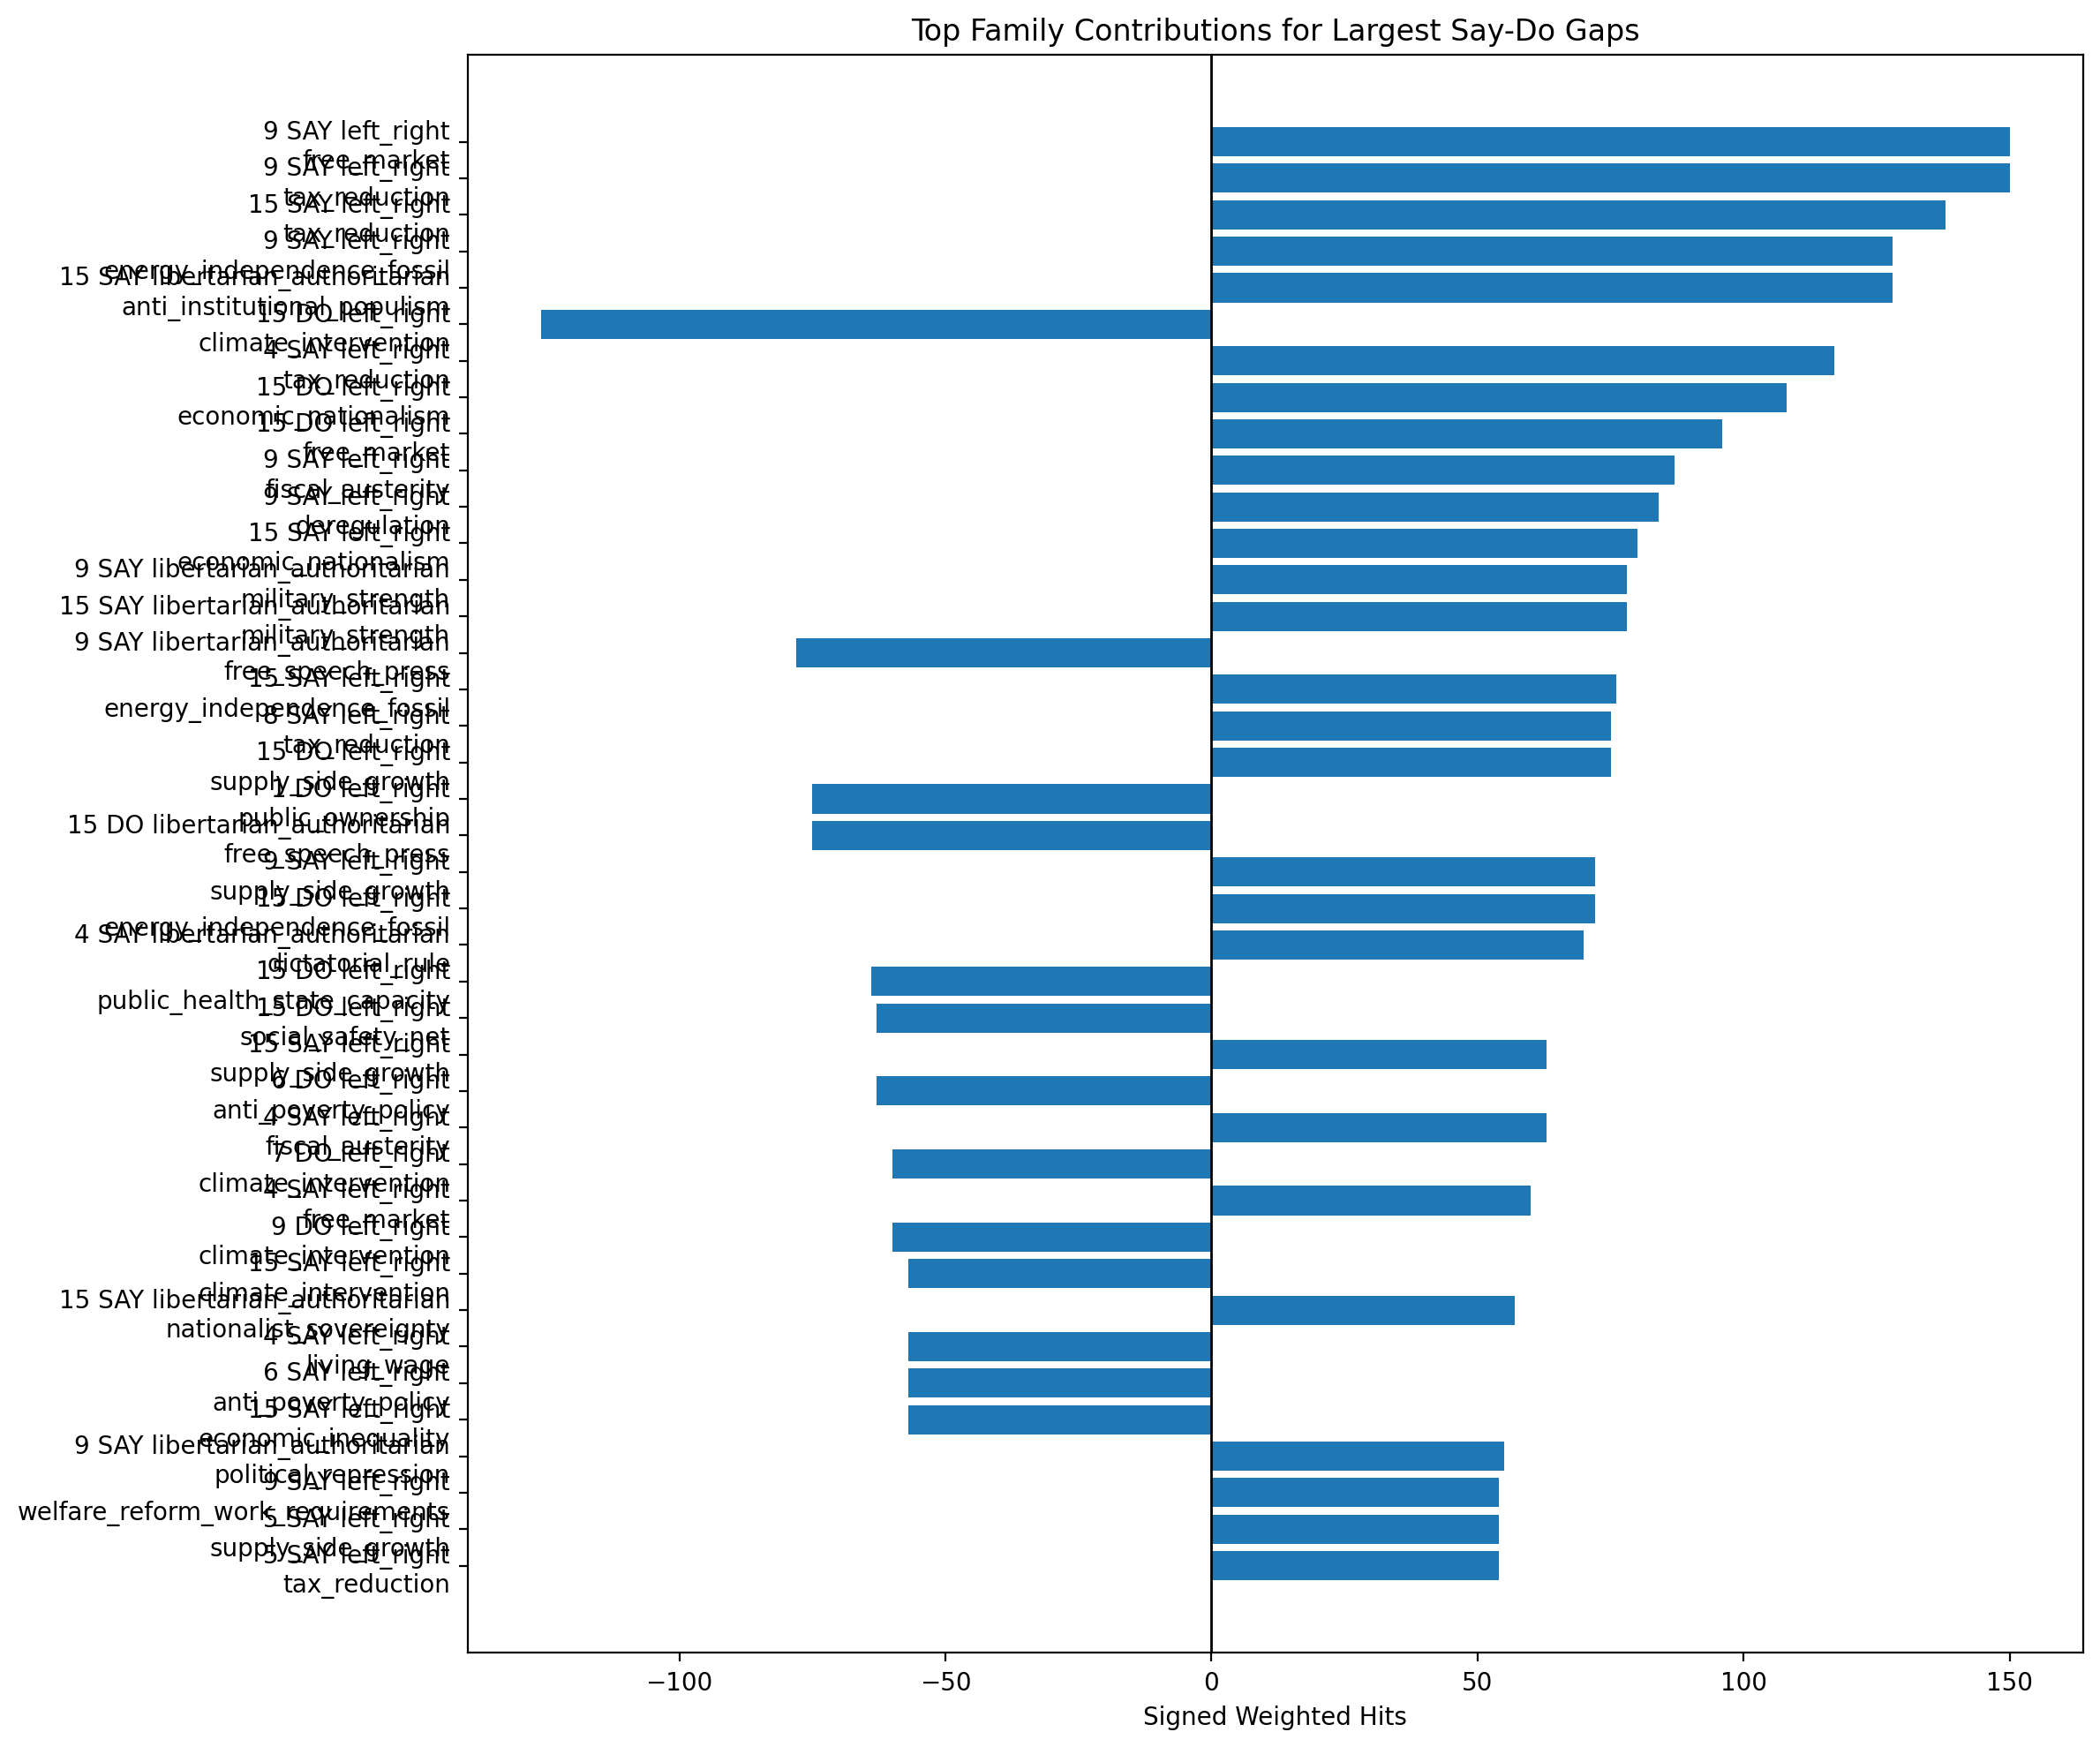

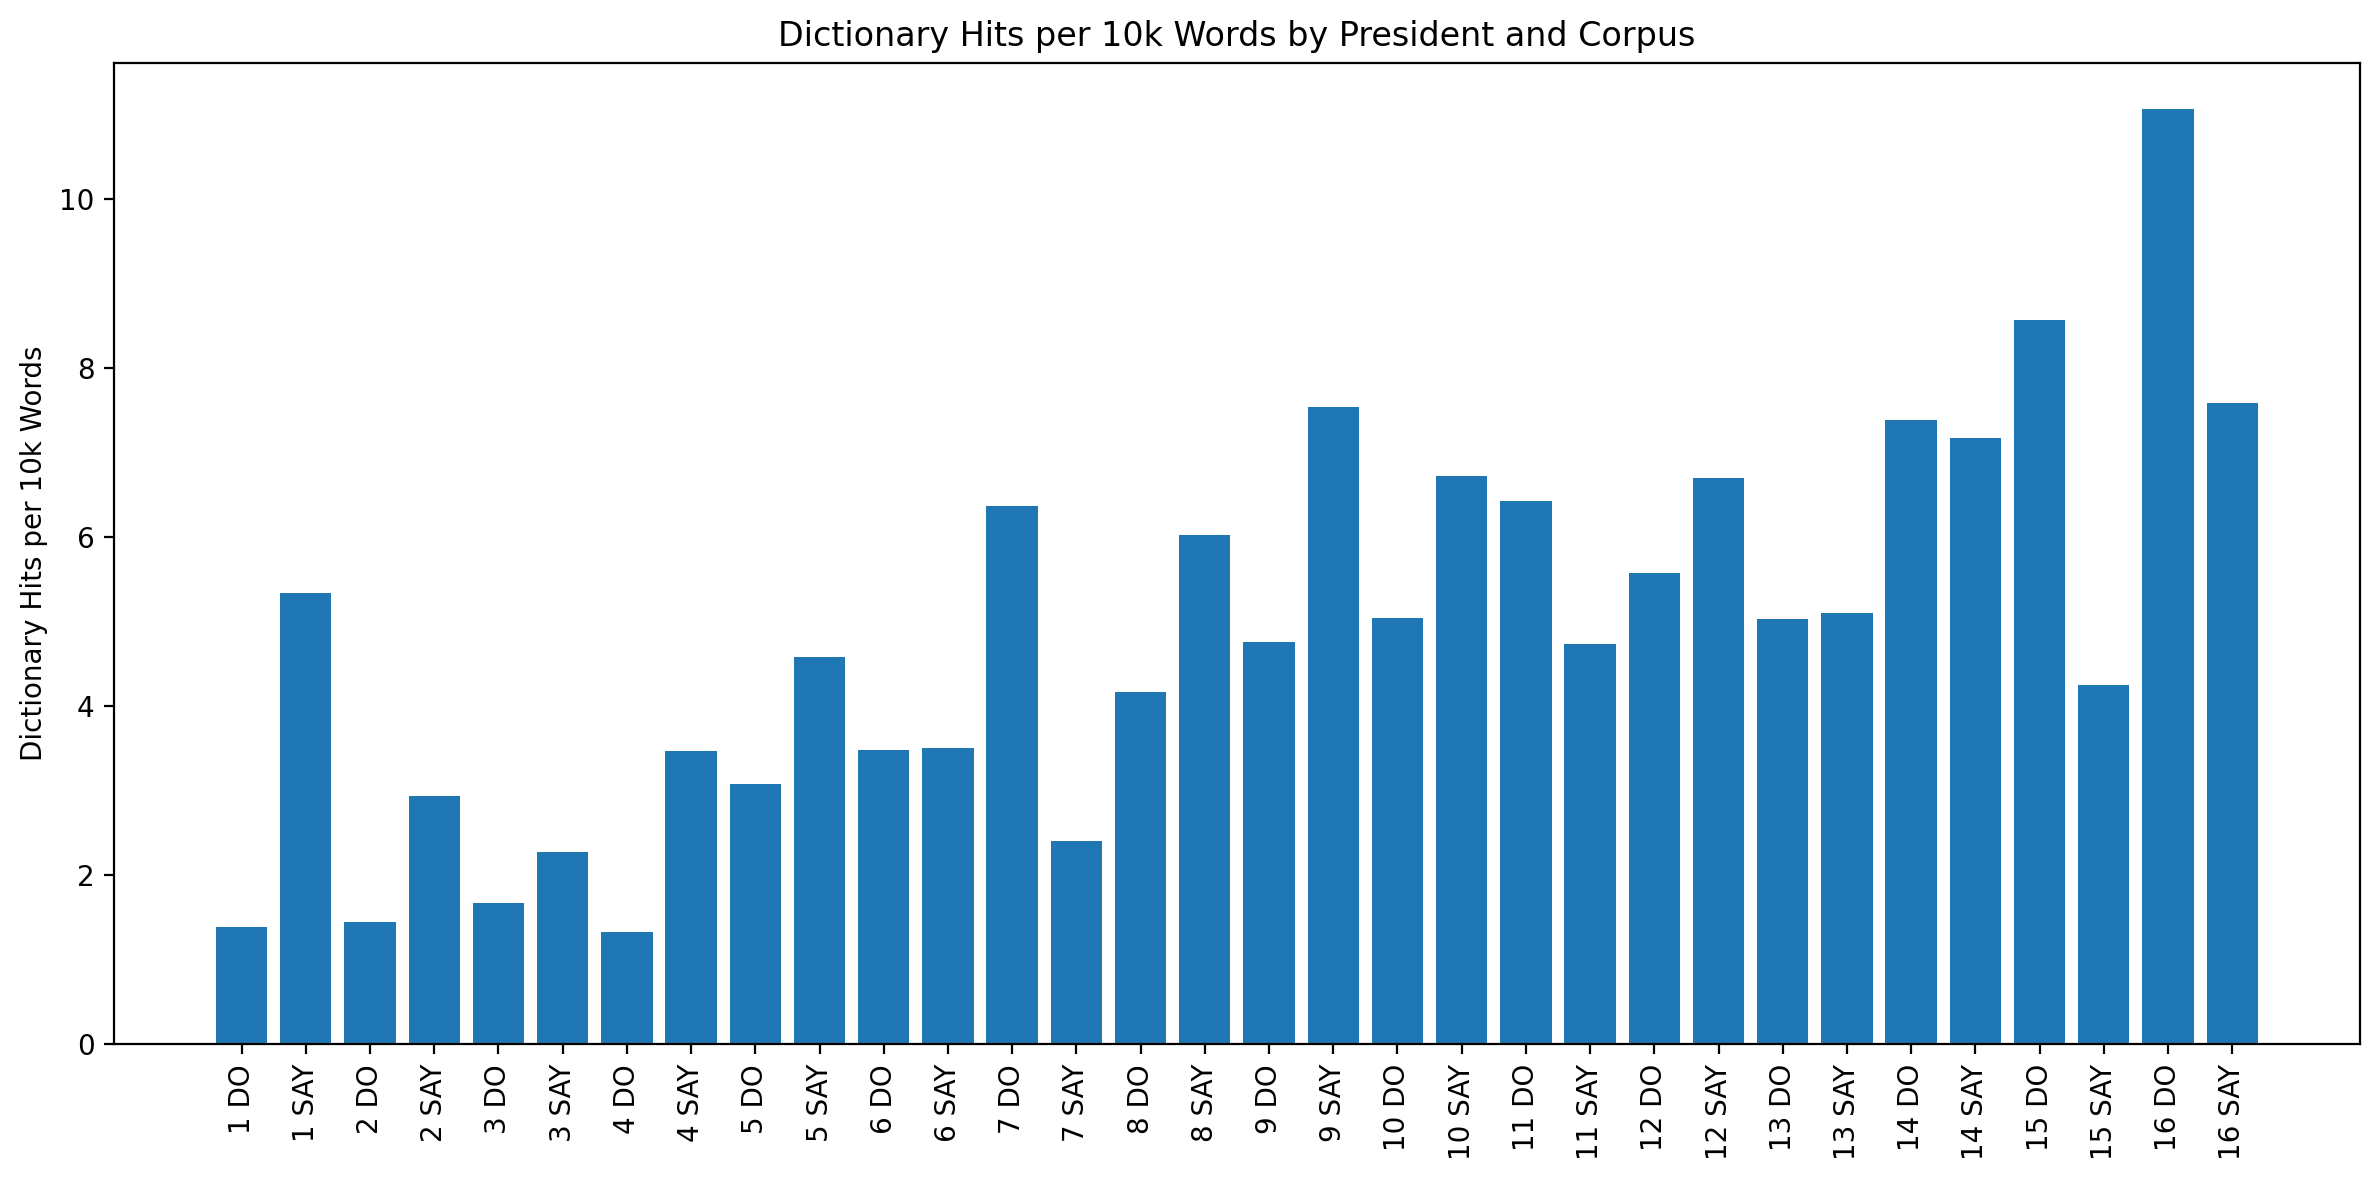

Validation audit complete.
process_outputs\validation_outputs\top_phrase_families_by_president_corpus_axis.csv
process_outputs\validation_outputs\top_variants_by_president_corpus_axis.csv
process_outputs\validation_outputs\axis_direction_balance_audit.csv
process_outputs\validation_outputs\low_dictionary_coverage_risk_audit.csv
process_outputs\validation_outputs\president_validation_summary.csv
process_outputs\validation_outputs\dictionary_validation_audit_workbook.xlsx
process_outputs\validation_outputs\top_family_contributions_largest_gaps.png
process_outputs\validation_outputs\dictionary_coverage_by_president_corpus.png

Largest gaps needing phrase audit:


,gap_rank_largest_gap_1,president_number,president,say_do_gap,say_dictionary_hits,do_dictionary_hits,say_hits_per_10k,do_hits_per_10k,validation_risk
0,1,8,Gerald R. Ford,4.990567,165,35,6.019020,4.170291,large_gap_needs_phrase_audit
1,2,4,Dwight D. Eisenhower,3.360561,293,41,3.474837,1.332406,large_gap_needs_phrase_audit
2,3,5,John F. Kennedy,2.988325,171,53,4.577382,3.084013,large_gap_needs_phrase_audit
3,4,15,Donald J. Trump,2.671980,492,532,4.255209,8.566372,ok
4,5,9,Jimmy Carter,2.405099,579,109,7.531413,4.760345,ok
5,6,7,Richard Nixon,2.277822,66,127,2.400017,6.368692,ok
6,7,6,Lyndon B. Johnson,2.034950,195,66,3.502143,3.480462,ok
7,8,1,Herbert Hoover,1.928157,98,42,5.334524,1.384795,ok
8,9,3,Harry S Truman,1.662816,160,106,2.279111,1.669907,ok
9,10,16,"Joseph R. Biden, Jr.",1.651346,234,372,7.583123,11.055142,ok



Top phrase families:


,president_number,president,corpus_type,axis,direction,family,theme,hits,weighted_hits,signed_weighted_hits
3,1,Herbert Hoover,do,left_right,left,public_ownership,state_ownership,15,75,-75
1,1,Herbert Hoover,do,left_right,left,public_health_state_capacity,public_health,9,18,-18
0,1,Herbert Hoover,do,left_right,left,local_public_goods,weak_public_investment,9,9,-9
2,1,Herbert Hoover,do,left_right,left,public_investment,state_investment,3,6,-6
5,1,Herbert Hoover,do,left_right,right,energy_independence_fossil,energy_market_right,3,6,6
6,1,Herbert Hoover,do,left_right,right,privatization,privatization,1,4,4
4,1,Herbert Hoover,do,left_right,right,economic_nationalism,economic_nationalism,1,2,2
7,1,Herbert Hoover,do,libertarian_authoritarian,libertarian,local_self_government,local_autonomy,1,1,-1
13,1,Herbert Hoover,say,left_right,left,public_investment,state_investment,25,50,-50
12,1,Herbert Hoover,say,left_right,left,public_health_state_capacity,public_health,10,20,-20



Top phrase variants:


,president_number,president,corpus_type,axis,direction,family,variant,hits,weighted_hits,signed_weighted_hits
4,1,Herbert Hoover,do,left_right,left,public_ownership,publicly owned,14,70,-70
1,1,Herbert Hoover,do,left_right,left,public_health_state_capacity,public health,9,18,-18
0,1,Herbert Hoover,do,left_right,left,local_public_goods,public service,9,9,-9
2,1,Herbert Hoover,do,left_right,left,public_investment,public works,3,6,-6
3,1,Herbert Hoover,do,left_right,left,public_ownership,government ownership,1,5,-5
7,1,Herbert Hoover,do,left_right,right,energy_independence_fossil,oil and gas,2,4,4
8,1,Herbert Hoover,do,left_right,right,privatization,private contractors,1,4,4
5,1,Herbert Hoover,do,left_right,right,economic_nationalism,american industry,1,2,2
6,1,Herbert Hoover,do,left_right,right,energy_independence_fossil,natural gas,1,2,2
9,1,Herbert Hoover,do,libertarian_authoritarian,libertarian,local_self_government,local self government,1,1,-1


In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 400)
pd.set_option("display.max_rows", 200)

OUTPUT_DIR = Path("process_outputs")
VALIDATION_DIR = OUTPUT_DIR / "validation_outputs"
VALIDATION_DIR.mkdir(parents=True, exist_ok=True)

family_hits_path = OUTPUT_DIR / "dictionary_family_hits_FINAL.csv"
variant_hits_path = OUTPUT_DIR / "dictionary_variant_hits_FINAL.csv"
scores_path = OUTPUT_DIR / "dictionary_president_corpus_scores_FINAL.csv"
gap_path = OUTPUT_DIR / "dictionary_say_do_gap_scores_FINAL.csv"
legend_path = OUTPUT_DIR / "president_number_legend_mapping_FINAL.csv"

top_family_output = VALIDATION_DIR / "top_phrase_families_by_president_corpus_axis.csv"
top_variant_output = VALIDATION_DIR / "top_variants_by_president_corpus_axis.csv"
axis_direction_output = VALIDATION_DIR / "axis_direction_balance_audit.csv"
coverage_risk_output = VALIDATION_DIR / "low_dictionary_coverage_risk_audit.csv"
president_summary_output = VALIDATION_DIR / "president_validation_summary.csv"
excel_output = VALIDATION_DIR / "dictionary_validation_audit_workbook.xlsx"

top_family_plot = VALIDATION_DIR / "top_family_contributions_largest_gaps.png"
coverage_plot = VALIDATION_DIR / "dictionary_coverage_by_president_corpus.png"

family_hits = pd.read_csv(family_hits_path, encoding="utf-8-sig")
variant_hits = pd.read_csv(variant_hits_path, encoding="utf-8-sig")
scores = pd.read_csv(scores_path, encoding="utf-8-sig")
gap_scores = pd.read_csv(gap_path, encoding="utf-8-sig")
legend = pd.read_csv(legend_path, encoding="utf-8-sig")

for df in [family_hits, variant_hits, scores, gap_scores]:
    if "president_number" not in df.columns:
        df.merge(legend[["president", "president_number"]], on="president", how="left")

family_hits["abs_signed_weighted_hits"] = family_hits["signed_weighted_hits"].abs()
variant_hits["abs_signed_weighted_hits"] = variant_hits["signed_weighted_hits"].abs()

top_families = (
    family_hits
    .sort_values(
        ["president_number", "president", "corpus_type", "axis", "abs_signed_weighted_hits", "hits"],
        ascending=[True, True, True, True, False, False]
    )
    .groupby(["president_number", "president", "corpus_type", "axis"], as_index=False)
    .head(8)
    .copy()
)

top_families["contribution_direction"] = np.where(
    top_families["signed_weighted_hits"] < 0,
    "negative_pole",
    "positive_pole"
)

top_variants = (
    variant_hits
    .sort_values(
        ["president_number", "president", "corpus_type", "axis", "abs_signed_weighted_hits", "hits"],
        ascending=[True, True, True, True, False, False]
    )
    .groupby(["president_number", "president", "corpus_type", "axis"], as_index=False)
    .head(15)
    .copy()
)

direction_balance = (
    family_hits
    .groupby(["president_number", "president", "corpus_type", "axis", "direction"], as_index=False)
    .agg(
        hits=("hits", "sum"),
        weighted_hits=("weighted_hits", "sum"),
        signed_weighted_hits=("signed_weighted_hits", "sum"),
        unique_families_hit=("family", "nunique")
    )
)

direction_pivot = (
    direction_balance
    .pivot_table(
        index=["president_number", "president", "corpus_type", "axis"],
        columns="direction",
        values=["hits", "weighted_hits", "unique_families_hit"],
        aggfunc="sum",
        fill_value=0
    )
)

direction_pivot.columns = [
    "_".join([str(x) for x in col if str(x) != ""])
    for col in direction_pivot.columns
]

direction_pivot = direction_pivot.reset_index()

for col in [
    "hits_left", "hits_right", "hits_libertarian", "hits_authoritarian",
    "weighted_hits_left", "weighted_hits_right", "weighted_hits_libertarian", "weighted_hits_authoritarian"
]:
    if col not in direction_pivot.columns:
        direction_pivot[col] = 0

direction_pivot["left_right_hit_margin"] = direction_pivot["hits_right"] - direction_pivot["hits_left"]
direction_pivot["lib_auth_hit_margin"] = direction_pivot["hits_authoritarian"] - direction_pivot["hits_libertarian"]
direction_pivot["left_right_weighted_margin"] = direction_pivot["weighted_hits_right"] - direction_pivot["weighted_hits_left"]
direction_pivot["lib_auth_weighted_margin"] = direction_pivot["weighted_hits_authoritarian"] - direction_pivot["weighted_hits_libertarian"]

coverage_risk = scores.copy()
coverage_risk["dictionary_hits_per_10k_words"] = np.where(
    coverage_risk["total_words"] > 0,
    coverage_risk["total_dictionary_hits"] / coverage_risk["total_words"] * 10000,
    0
)

coverage_risk["coverage_flag"] = np.select(
    [
        coverage_risk["total_dictionary_hits"].lt(25),
        coverage_risk["dictionary_hits_per_10k_words"].lt(1),
        coverage_risk["total_words"].lt(10000)
    ],
    [
        "very_few_dictionary_hits",
        "low_hits_per_10k_words",
        "low_total_words"
    ],
    default="ok"
)

coverage_risk = coverage_risk.sort_values(
    ["coverage_flag", "president_number", "corpus_type"]
).reset_index(drop=True)

president_summary = gap_scores.merge(
    scores[scores["corpus_type"].eq("say")][
        [
            "president",
            "total_dictionary_hits",
            "dictionary_hits_per_10k_words",
            "left_right_hit_count",
            "libertarian_authoritarian_hit_count"
        ]
    ].rename(columns={
        "total_dictionary_hits": "say_dictionary_hits",
        "dictionary_hits_per_10k_words": "say_hits_per_10k",
        "left_right_hit_count": "say_left_right_hits",
        "libertarian_authoritarian_hit_count": "say_lib_auth_hits"
    }),
    on="president",
    how="left"
)

president_summary = president_summary.merge(
    scores[scores["corpus_type"].eq("do")][
        [
            "president",
            "total_dictionary_hits",
            "dictionary_hits_per_10k_words",
            "left_right_hit_count",
            "libertarian_authoritarian_hit_count"
        ]
    ].rename(columns={
        "total_dictionary_hits": "do_dictionary_hits",
        "dictionary_hits_per_10k_words": "do_hits_per_10k",
        "left_right_hit_count": "do_left_right_hits",
        "libertarian_authoritarian_hit_count": "do_lib_auth_hits"
    }),
    on="president",
    how="left"
)

president_summary["validation_risk"] = np.select(
    [
        president_summary["say_dictionary_hits"].lt(25) | president_summary["do_dictionary_hits"].lt(25),
        president_summary["say_hits_per_10k"].lt(1) | president_summary["do_hits_per_10k"].lt(1),
        president_summary["say_do_gap"].gt(president_summary["say_do_gap"].quantile(0.80))
    ],
    [
        "low_hit_count",
        "low_hit_density",
        "large_gap_needs_phrase_audit"
    ],
    default="ok"
)

top_families.to_csv(top_family_output, index=False, encoding="utf-8-sig")
top_variants.to_csv(top_variant_output, index=False, encoding="utf-8-sig")
direction_pivot.to_csv(axis_direction_output, index=False, encoding="utf-8-sig")
coverage_risk.to_csv(coverage_risk_output, index=False, encoding="utf-8-sig")
president_summary.to_csv(president_summary_output, index=False, encoding="utf-8-sig")

largest_gap_presidents = (
    gap_scores
    .sort_values("say_do_gap", ascending=False)
    .head(8)["president"]
    .tolist()
)

plot_df = top_families[
    top_families["president"].isin(largest_gap_presidents)
].copy()

plot_df["label"] = (
    plot_df["president_number"].astype(int).astype(str)
    + " "
    + plot_df["corpus_type"].str.upper()
    + " "
    + plot_df["axis"]
    + "\n"
    + plot_df["family"]
)

plot_df = plot_df.sort_values("abs_signed_weighted_hits", ascending=True).tail(40)

plt.figure(figsize=(12, 10), dpi=200)
plt.barh(plot_df["label"], plot_df["signed_weighted_hits"])
plt.axvline(0, color="black", linewidth=1)
plt.title("Top Family Contributions for Largest Say-Do Gaps")
plt.xlabel("Signed Weighted Hits")
plt.tight_layout()
plt.savefig(top_family_plot, bbox_inches="tight")
plt.show()

coverage_plot_df = scores.sort_values(["president_number", "corpus_type"]).copy()
coverage_plot_df["label"] = coverage_plot_df["president_number"].astype(int).astype(str) + " " + coverage_plot_df["corpus_type"].str.upper()

plt.figure(figsize=(12, 6), dpi=200)
plt.bar(coverage_plot_df["label"], coverage_plot_df["dictionary_hits_per_10k_words"])
plt.xticks(rotation=90)
plt.title("Dictionary Hits per 10k Words by President and Corpus")
plt.ylabel("Dictionary Hits per 10k Words")
plt.tight_layout()
plt.savefig(coverage_plot, bbox_inches="tight")
plt.show()

with pd.ExcelWriter(excel_output, engine="openpyxl") as writer:
    president_summary.to_excel(writer, sheet_name="president_summary", index=False)
    top_families.to_excel(writer, sheet_name="top_families", index=False)
    top_variants.to_excel(writer, sheet_name="top_variants", index=False)
    direction_pivot.to_excel(writer, sheet_name="axis_direction_balance", index=False)
    coverage_risk.to_excel(writer, sheet_name="coverage_risk", index=False)
    gap_scores.to_excel(writer, sheet_name="gap_scores", index=False)
    scores.to_excel(writer, sheet_name="scores", index=False)

print("Validation audit complete.")
print(top_family_output)
print(top_variant_output)
print(axis_direction_output)
print(coverage_risk_output)
print(president_summary_output)
print(excel_output)
print(top_family_plot)
print(coverage_plot)

print("\nLargest gaps needing phrase audit:")
display(
    president_summary[
        [
            "gap_rank_largest_gap_1",
            "president_number",
            "president",
            "say_do_gap",
            "say_dictionary_hits",
            "do_dictionary_hits",
            "say_hits_per_10k",
            "do_hits_per_10k",
            "validation_risk"
        ]
    ].sort_values("gap_rank_largest_gap_1").head(15)
)

print("\nTop phrase families:")
display(
    top_families[
        [
            "president_number",
            "president",
            "corpus_type",
            "axis",
            "direction",
            "family",
            "theme",
            "hits",
            "weighted_hits",
            "signed_weighted_hits"
        ]
    ].head(80)
)

print("\nTop phrase variants:")
display(
    top_variants[
        [
            "president_number",
            "president",
            "corpus_type",
            "axis",
            "direction",
            "family",
            "variant",
            "hits",
            "weighted_hits",
            "signed_weighted_hits"
        ]
    ].head(80)
)

### Party-Level Dictionary-Based Say–Do Aggregation

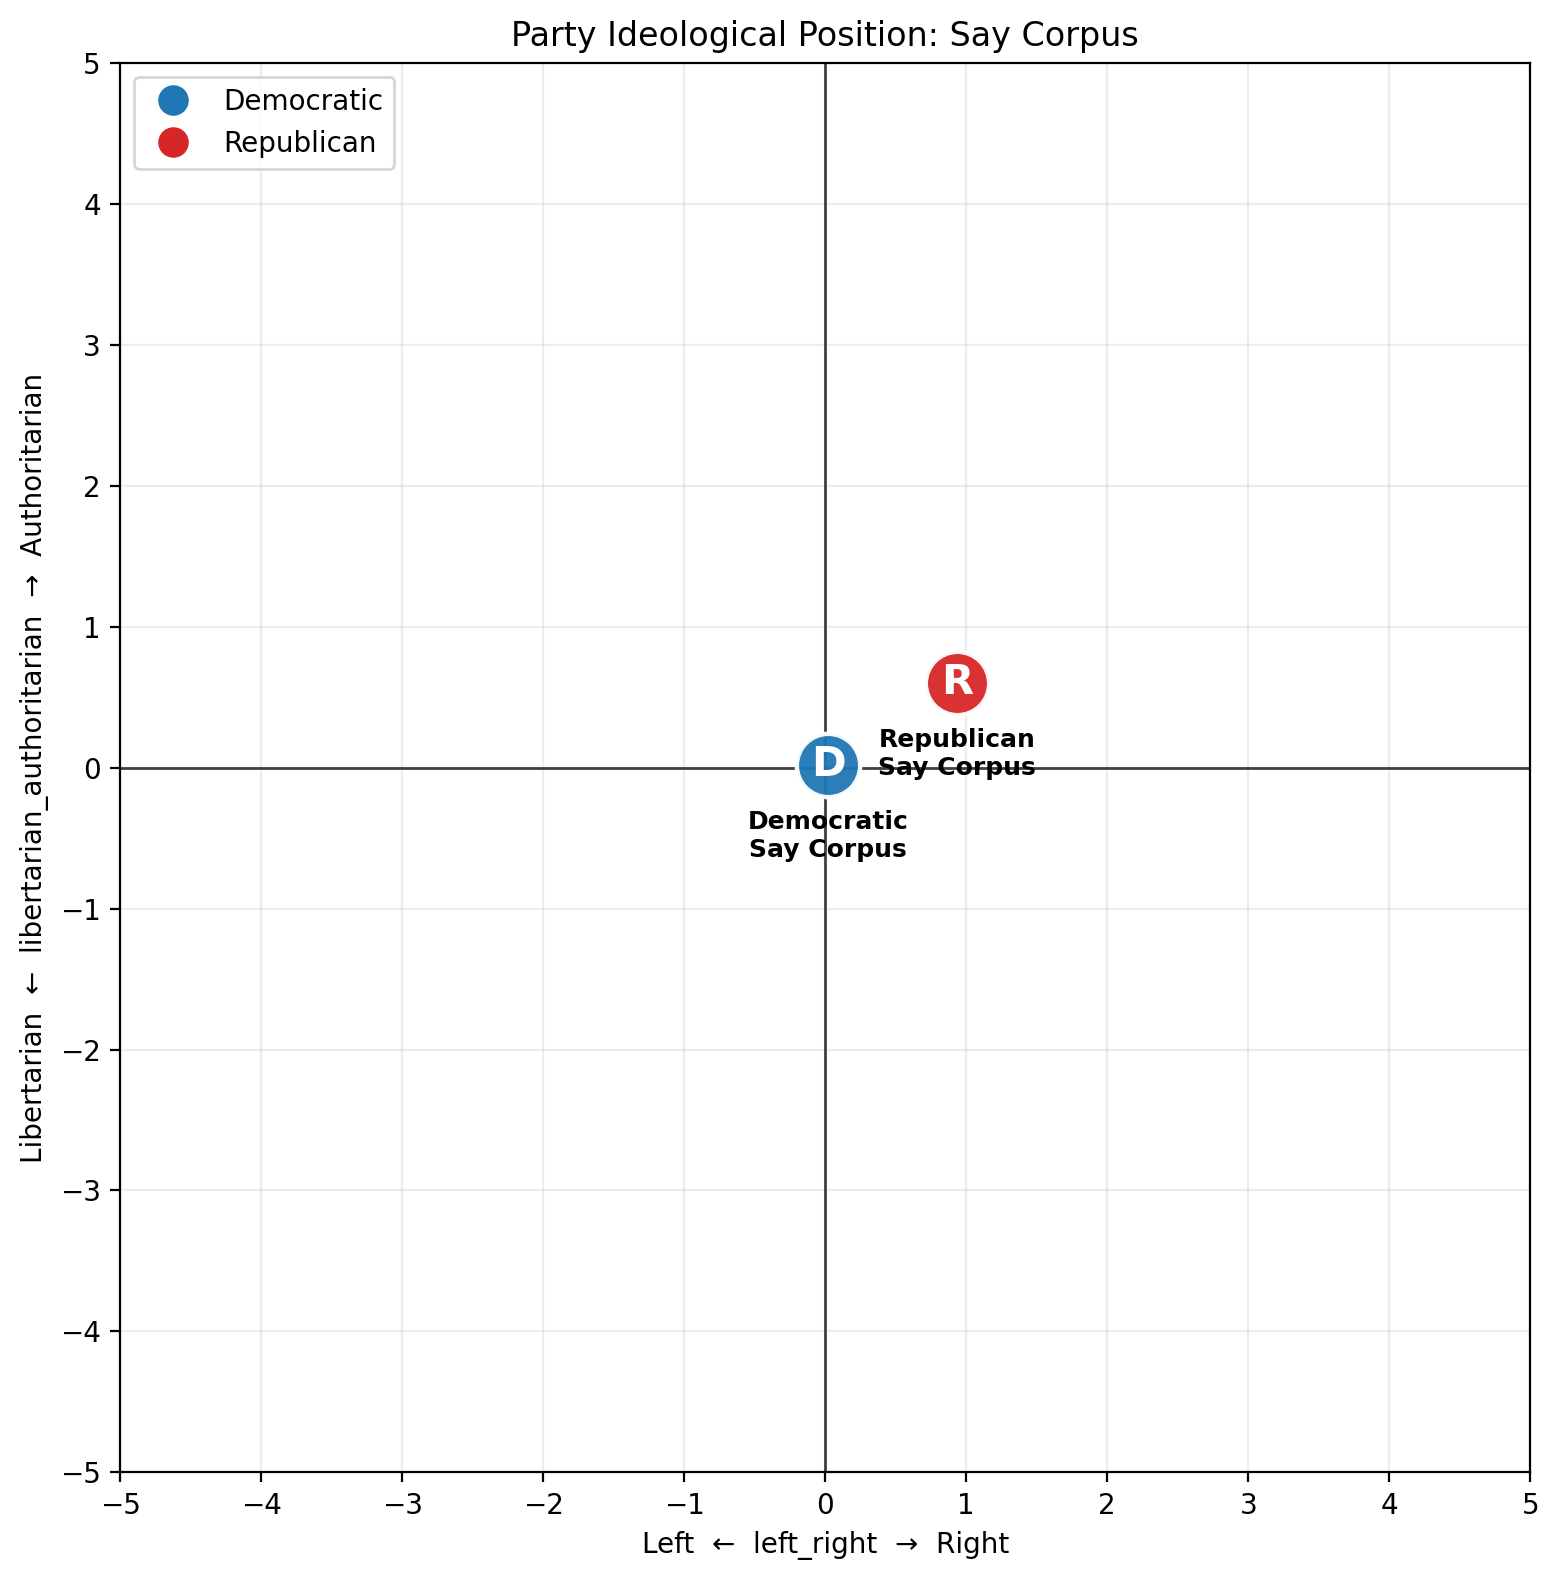

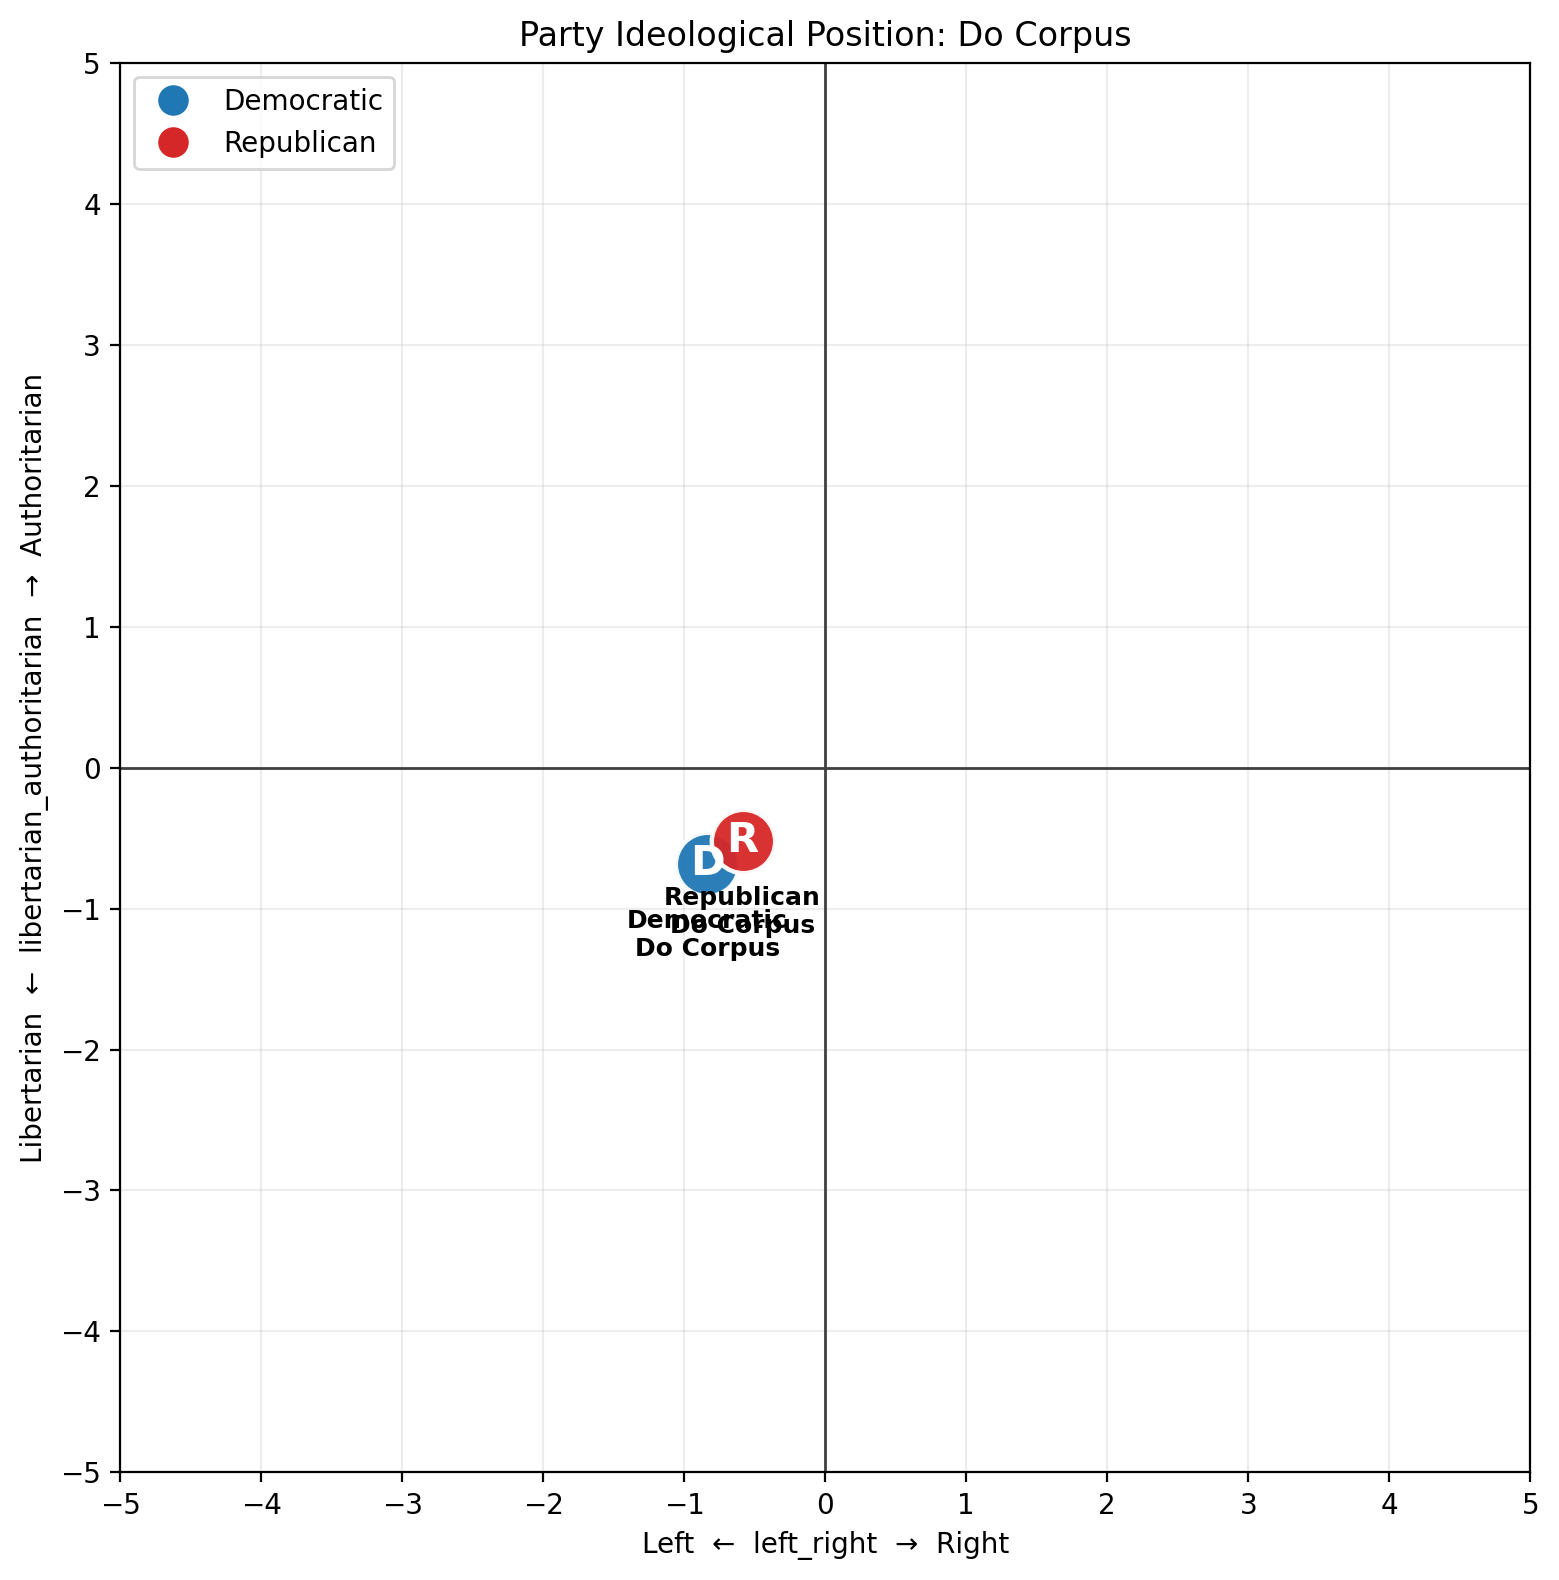

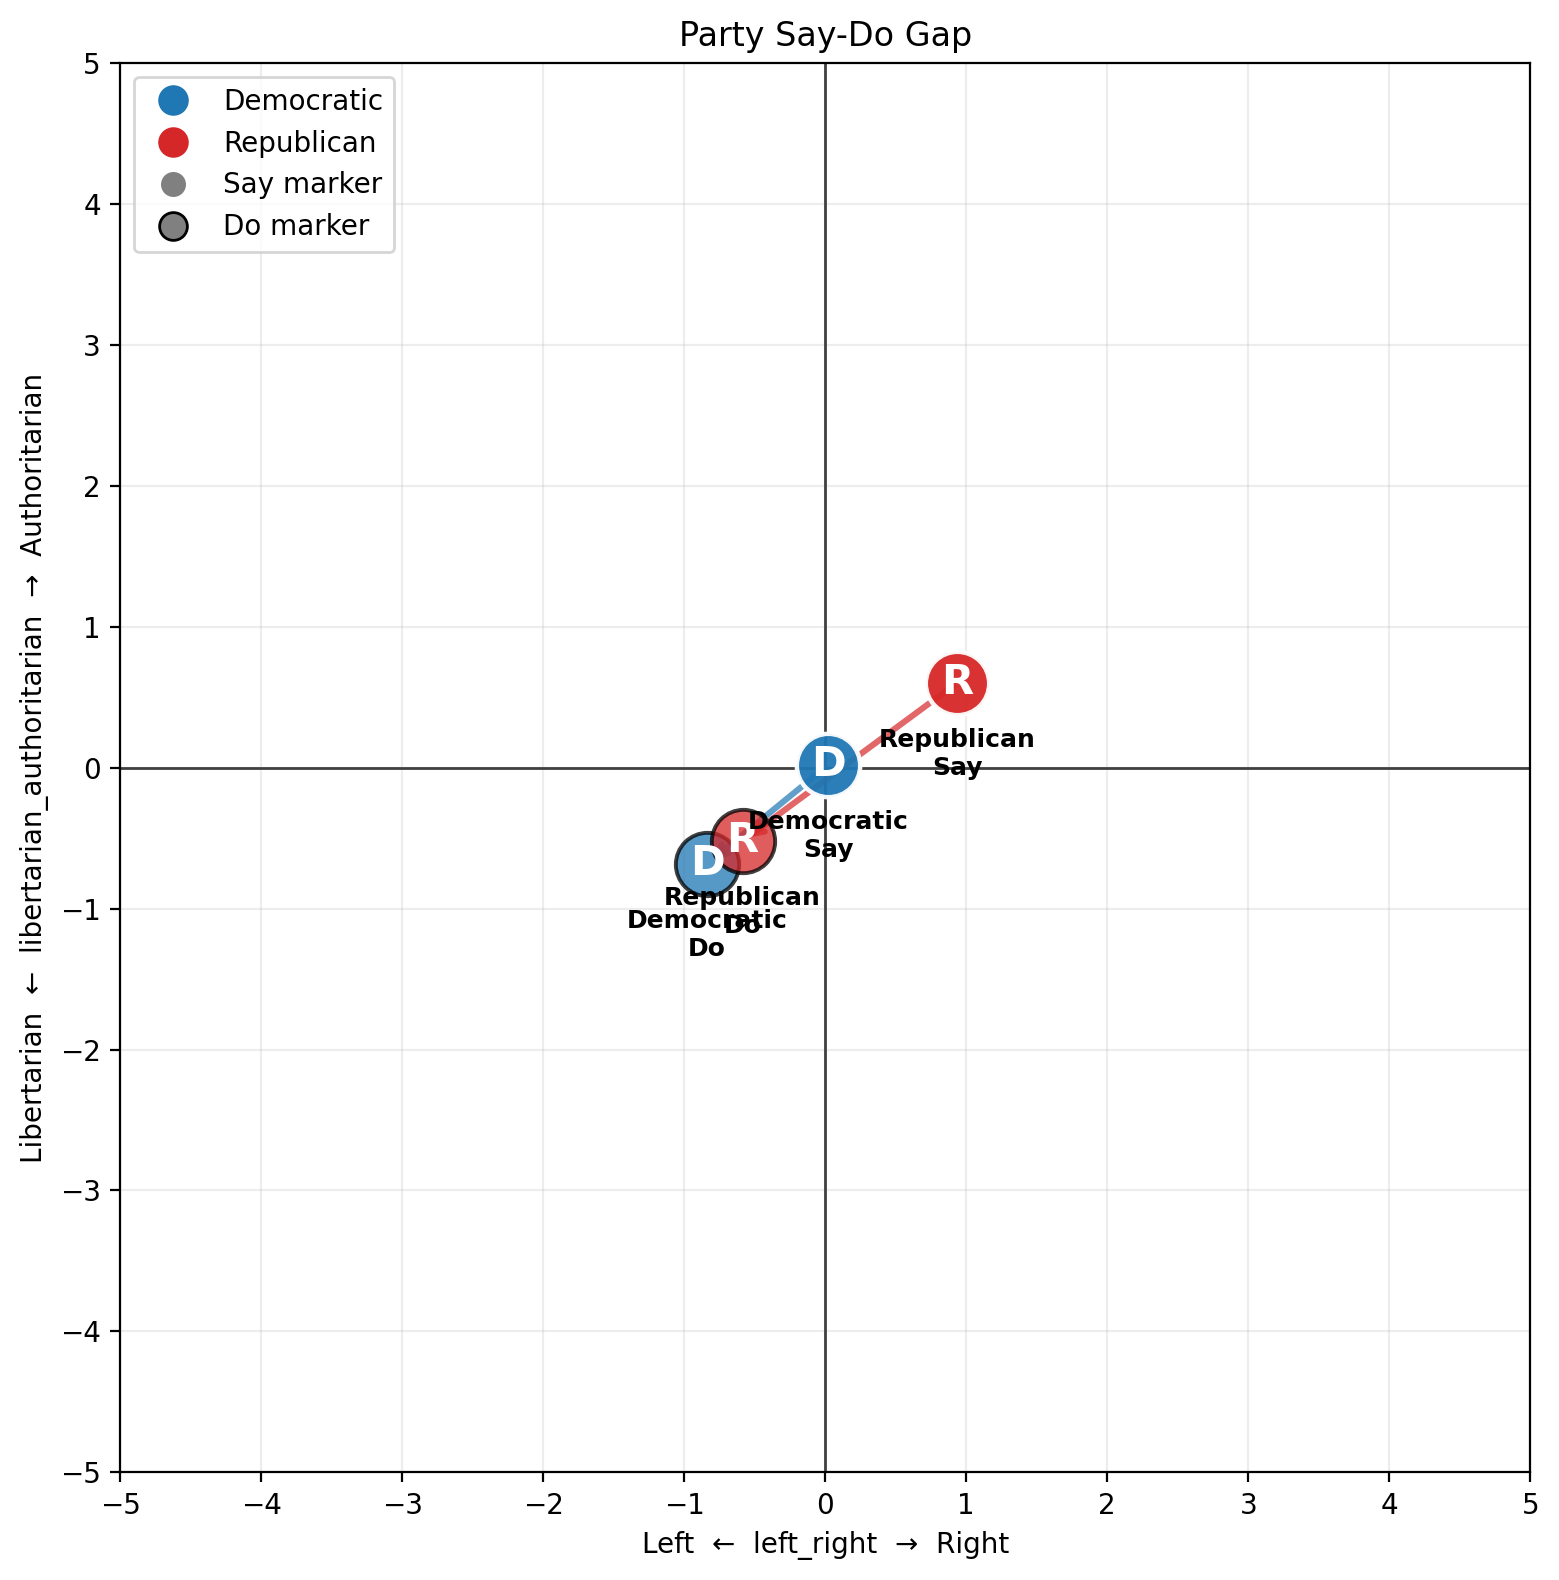

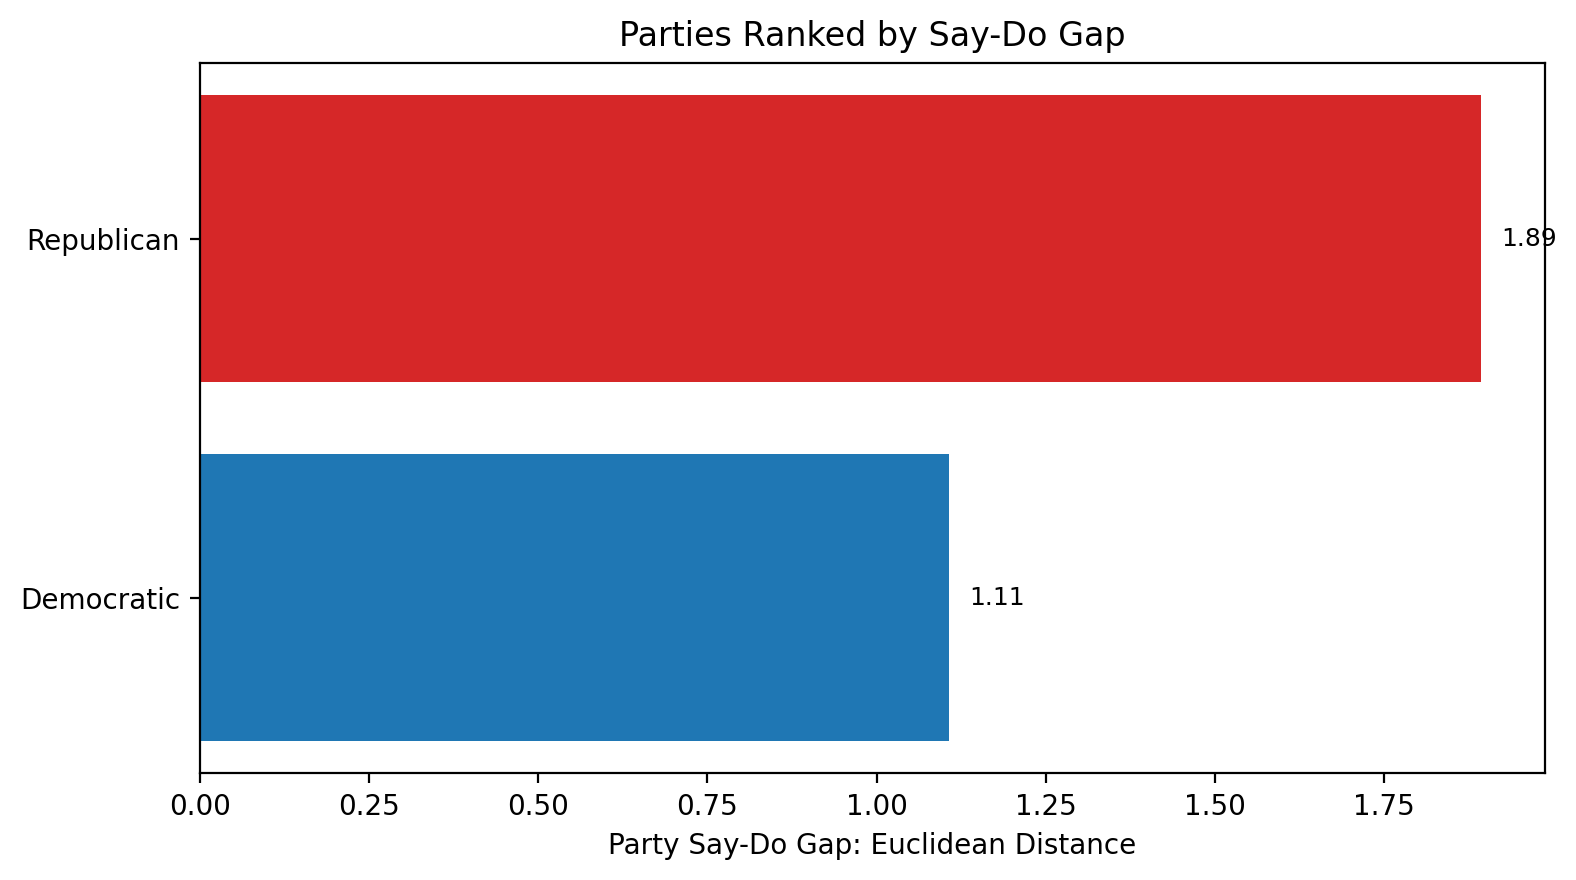

Done.
Presidents used: 16
Parties used: 2

Saved files:
process_outputs\party_dictionary_corpus_scores_FINAL.csv
process_outputs\party_say_do_gap_scores_FINAL.csv
process_outputs\party_president_mapping_FINAL.csv
process_outputs\party_based_full_outputs_FINAL.xlsx
process_outputs\party_say_corpus_markers_FINAL.png
process_outputs\party_do_corpus_markers_FINAL.png
process_outputs\party_say_do_gap_FINAL.png
process_outputs\party_say_do_gap_ranked_FINAL.png

PRESIDENTS USED


,president_number,president,party,intended_order
0,1,Herbert Hoover,Republican,1
1,2,Franklin D. Roosevelt,Democratic,2
2,3,Harry S Truman,Democratic,3
3,4,Dwight D. Eisenhower,Republican,4
4,5,John F. Kennedy,Democratic,5
5,6,Lyndon B. Johnson,Democratic,6
6,7,Richard Nixon,Republican,7
7,8,Gerald R. Ford,Republican,8
8,9,Jimmy Carter,Democratic,9
9,10,Ronald Reagan,Republican,10



PARTY CORPUS SCORES


,party,corpus_type,president_count,x_left_right,y_libertarian_authoritarian,x_left_right_weighted,y_libertarian_authoritarian_weighted,total_dictionary_hits,total_words
0,Democratic,do,8,-0.838182,-0.682562,-0.851074,-0.961948,1336,3648092
1,Democratic,say,8,0.019587,0.017215,0.290696,-0.080548,4079,6905933
2,Republican,do,8,-0.587270,-0.521107,-0.005811,-0.426169,1063,2057114
3,Republican,say,8,0.935953,0.601641,1.085238,0.745515,2754,5783158



PARTY SAY-DO GAP


,gap_rank_largest_gap_1,alignment_rank_smallest_gap_1,party,say_x_left_right,say_y_libertarian_authoritarian,do_x_left_right,do_y_libertarian_authoritarian,party_say_do_gap,party_say_do_gap_weighted,say_president_count,do_president_count
0,1,2,Republican,0.935953,0.601641,-0.587270,-0.521107,1.892293,1.601010,8,8
1,2,1,Democratic,0.019587,0.017215,-0.838182,-0.682562,1.107003,1.442396,8,8


In [22]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 400)
pd.set_option("display.max_rows", 150)

OUTPUT_DIR = Path("process_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

president_scores_path = OUTPUT_DIR / "dictionary_president_corpus_scores_FINAL.csv"
gap_scores_path = OUTPUT_DIR / "dictionary_say_do_gap_scores_FINAL.csv"
legend_path = OUTPUT_DIR / "president_number_legend_mapping_FINAL.csv"

party_scores_output = OUTPUT_DIR / "party_dictionary_corpus_scores_FINAL.csv"
party_gap_output = OUTPUT_DIR / "party_say_do_gap_scores_FINAL.csv"
party_president_mapping_output = OUTPUT_DIR / "party_president_mapping_FINAL.csv"
party_excel_output = OUTPUT_DIR / "party_based_full_outputs_FINAL.xlsx"

party_say_plot = OUTPUT_DIR / "party_say_corpus_markers_FINAL.png"
party_do_plot = OUTPUT_DIR / "party_do_corpus_markers_FINAL.png"
party_gap_plot = OUTPUT_DIR / "party_say_do_gap_FINAL.png"
party_gap_rank_plot = OUTPUT_DIR / "party_say_do_gap_ranked_FINAL.png"

REPUBLICAN_COLOR = "#D62728"
DEMOCRATIC_COLOR = "#1F77B4"

PRESIDENT_PARTY_MAP = {
    "Herbert Hoover": "Republican",
    "Franklin D. Roosevelt": "Democratic",
    "Harry S Truman": "Democratic",
    "Dwight D. Eisenhower": "Republican",
    "John F. Kennedy": "Democratic",
    "Lyndon B. Johnson": "Democratic",
    "Richard Nixon": "Republican",
    "Gerald R. Ford": "Republican",
    "Jimmy Carter": "Democratic",
    "Ronald Reagan": "Republican",
    "George Bush": "Republican",
    "William J. Clinton": "Democratic",
    "George W. Bush": "Republican",
    "Barack Obama": "Democratic",
    "Donald J. Trump": "Republican",
    "Joseph R. Biden, Jr.": "Democratic",
}

PRESIDENT_ORDER = [
    "Herbert Hoover",
    "Franklin D. Roosevelt",
    "Harry S Truman",
    "Dwight D. Eisenhower",
    "John F. Kennedy",
    "Lyndon B. Johnson",
    "Richard Nixon",
    "Gerald R. Ford",
    "Jimmy Carter",
    "Ronald Reagan",
    "George Bush",
    "William J. Clinton",
    "George W. Bush",
    "Barack Obama",
    "Donald J. Trump",
    "Joseph R. Biden, Jr.",
]

PARTY_ORDER = ["Democratic", "Republican"]

PARTY_COLOR = {
    "Republican": REPUBLICAN_COLOR,
    "Democratic": DEMOCRATIC_COLOR,
}

def canonical_name(x):
    x = "" if pd.isna(x) else str(x)
    x = x.lower()
    x = x.replace("&", " and ")
    x = re.sub(r"[^a-z0-9]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def read_csv_safe(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path, encoding="utf-8-sig")

def setup_matrix_axes(ax, limit=5):
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.axhline(0, color="0.25", linewidth=1)
    ax.axvline(0, color="0.25", linewidth=1)
    ax.grid(True, alpha=0.22)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Left  ←  left_right  →  Right")
    ax.set_ylabel("Libertarian  ←  libertarian_authoritarian  →  Authoritarian")
    ax.set_xticks(np.arange(-limit, limit + 1, 1))
    ax.set_yticks(np.arange(-limit, limit + 1, 1))

def draw_party_marker(ax, x, y, party, corpus_label, color):
    ax.scatter(
        x,
        y,
        s=520,
        color=color,
        edgecolor="white",
        linewidth=1.6,
        alpha=0.95,
        zorder=4,
    )

    ax.text(
        x,
        y,
        party[0],
        ha="center",
        va="center",
        fontsize=15,
        color="white",
        fontweight="bold",
        zorder=5,
    )

    ax.text(
        x,
        y - 0.32,
        f"{party}\n{corpus_label}",
        ha="center",
        va="top",
        fontsize=9,
        color="black",
        fontweight="bold",
        zorder=6,
    )

def weighted_average(group, value_col, weight_col):
    values = pd.to_numeric(group[value_col], errors="coerce")
    weights = pd.to_numeric(group[weight_col], errors="coerce").fillna(0)

    if weights.sum() <= 0:
        return values.mean()

    return np.average(values, weights=weights)

scores = read_csv_safe(president_scores_path)
gap_scores = read_csv_safe(gap_scores_path)

if legend_path.exists():
    legend = read_csv_safe(legend_path)
else:
    legend = pd.DataFrame({
        "president": PRESIDENT_ORDER,
        "president_number": np.arange(1, len(PRESIDENT_ORDER) + 1),
    })

party_map_df = pd.DataFrame({
    "president": PRESIDENT_ORDER,
    "party": [PRESIDENT_PARTY_MAP[p] for p in PRESIDENT_ORDER],
    "intended_order": np.arange(1, len(PRESIDENT_ORDER) + 1),
})

party_map_df["president_key"] = party_map_df["president"].map(canonical_name)
scores["president_key"] = scores["president"].map(canonical_name)
gap_scores["president_key"] = gap_scores["president"].map(canonical_name)

scores = scores[scores["president_key"].isin(set(party_map_df["president_key"]))].copy()
gap_scores = gap_scores[gap_scores["president_key"].isin(set(party_map_df["president_key"]))].copy()

scores = scores.drop(columns=["party"], errors="ignore")
gap_scores = gap_scores.drop(columns=["party"], errors="ignore")

scores = scores.merge(
    party_map_df[["president_key", "party", "intended_order"]],
    on="president_key",
    how="left",
)

gap_scores = gap_scores.merge(
    party_map_df[["president_key", "party", "intended_order"]],
    on="president_key",
    how="left",
)

if "total_dictionary_hits" not in scores.columns:
    raise ValueError("Missing total_dictionary_hits in president scores.")

if "x_left_right" not in scores.columns or "y_libertarian_authoritarian" not in scores.columns:
    raise ValueError("Missing x_left_right or y_libertarian_authoritarian in president scores.")

scores["party_color"] = scores["party"].map(PARTY_COLOR)

party_rows = []

for (party, corpus_type), group in scores.groupby(["party", "corpus_type"]):
    party_rows.append({
        "party": party,
        "corpus_type": corpus_type,
        "party_color": PARTY_COLOR[party],
        "president_count": group["president"].nunique(),
        "total_dictionary_hits": group["total_dictionary_hits"].sum(),
        "total_words": group["total_words"].sum() if "total_words" in group.columns else np.nan,
        "x_left_right_unweighted": group["x_left_right"].mean(),
        "y_libertarian_authoritarian_unweighted": group["y_libertarian_authoritarian"].mean(),
        "x_left_right_weighted": weighted_average(group, "x_left_right", "total_dictionary_hits"),
        "y_libertarian_authoritarian_weighted": weighted_average(group, "y_libertarian_authoritarian", "total_dictionary_hits"),
    })

party_scores = pd.DataFrame(party_rows)

party_scores["x_left_right"] = party_scores["x_left_right_unweighted"]
party_scores["y_libertarian_authoritarian"] = party_scores["y_libertarian_authoritarian_unweighted"]

party_scores["party_sort"] = party_scores["party"].map({party: i for i, party in enumerate(PARTY_ORDER, start=1)})
party_scores = party_scores.sort_values(["party_sort", "corpus_type"]).reset_index(drop=True)

party_say = (
    party_scores[party_scores["corpus_type"].eq("say")]
    .drop(columns=["corpus_type"])
    .rename(columns={
        "x_left_right": "say_x_left_right",
        "y_libertarian_authoritarian": "say_y_libertarian_authoritarian",
        "x_left_right_unweighted": "say_x_left_right_unweighted",
        "y_libertarian_authoritarian_unweighted": "say_y_libertarian_authoritarian_unweighted",
        "x_left_right_weighted": "say_x_left_right_weighted",
        "y_libertarian_authoritarian_weighted": "say_y_libertarian_authoritarian_weighted",
        "total_dictionary_hits": "say_total_dictionary_hits",
        "total_words": "say_total_words",
        "president_count": "say_president_count",
    })
)

party_do = (
    party_scores[party_scores["corpus_type"].eq("do")]
    .drop(columns=["corpus_type"])
    .rename(columns={
        "x_left_right": "do_x_left_right",
        "y_libertarian_authoritarian": "do_y_libertarian_authoritarian",
        "x_left_right_unweighted": "do_x_left_right_unweighted",
        "y_libertarian_authoritarian_unweighted": "do_y_libertarian_authoritarian_unweighted",
        "x_left_right_weighted": "do_x_left_right_weighted",
        "y_libertarian_authoritarian_weighted": "do_y_libertarian_authoritarian_weighted",
        "total_dictionary_hits": "do_total_dictionary_hits",
        "total_words": "do_total_words",
        "president_count": "do_president_count",
    })
)

party_gap = party_say.merge(
    party_do,
    on=["party", "party_color", "party_sort"],
    how="inner",
)

party_gap["party_say_do_gap"] = np.sqrt(
    (party_gap["say_x_left_right"] - party_gap["do_x_left_right"]) ** 2
    + (party_gap["say_y_libertarian_authoritarian"] - party_gap["do_y_libertarian_authoritarian"]) ** 2
)

party_gap["party_say_do_gap_weighted"] = np.sqrt(
    (party_gap["say_x_left_right_weighted"] - party_gap["do_x_left_right_weighted"]) ** 2
    + (party_gap["say_y_libertarian_authoritarian_weighted"] - party_gap["do_y_libertarian_authoritarian_weighted"]) ** 2
)

party_gap["gap_rank_largest_gap_1"] = party_gap["party_say_do_gap"].rank(method="dense", ascending=False).astype(int)
party_gap["alignment_rank_smallest_gap_1"] = party_gap["party_say_do_gap"].rank(method="dense", ascending=True).astype(int)
party_gap = party_gap.sort_values("gap_rank_largest_gap_1").reset_index(drop=True)

party_map_df = party_map_df.merge(
    legend[["president", "president_number"]],
    on="president",
    how="left",
)

party_map_df["president_number"] = party_map_df["president_number"].fillna(party_map_df["intended_order"]).astype(int)
party_map_df = party_map_df.sort_values("intended_order").reset_index(drop=True)

party_scores.to_csv(party_scores_output, index=False, encoding="utf-8-sig")
party_gap.to_csv(party_gap_output, index=False, encoding="utf-8-sig")
party_map_df.to_csv(party_president_mapping_output, index=False, encoding="utf-8-sig")

def plot_party_corpus(party_scores_df, corpus_type, output_path):
    df = party_scores_df[party_scores_df["corpus_type"].eq(corpus_type)].copy()

    fig, ax = plt.subplots(figsize=(10, 8), dpi=200)
    setup_matrix_axes(ax, limit=5)

    title_corpus = "Say Corpus" if corpus_type == "say" else "Do Corpus"
    ax.set_title(f"Party Ideological Position: {title_corpus}")

    for row in df.sort_values("party_sort").itertuples(index=False):
        draw_party_marker(
            ax,
            row.x_left_right,
            row.y_libertarian_authoritarian,
            row.party,
            title_corpus,
            row.party_color,
        )

    handles = [
        Line2D([0], [0], marker="o", color="white", label="Democratic", markerfacecolor=DEMOCRATIC_COLOR, markeredgecolor="white", markersize=12),
        Line2D([0], [0], marker="o", color="white", label="Republican", markerfacecolor=REPUBLICAN_COLOR, markeredgecolor="white", markersize=12),
    ]

    ax.legend(handles=handles, loc="upper left", frameon=True)
    plt.tight_layout()
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()

def plot_party_gap(party_gap_df, output_path):
    fig, ax = plt.subplots(figsize=(10, 8), dpi=200)
    setup_matrix_axes(ax, limit=5)
    ax.set_title("Party Say-Do Gap")

    for row in party_gap_df.sort_values("party_sort").itertuples(index=False):
        ax.annotate(
            "",
            xy=(row.do_x_left_right, row.do_y_libertarian_authoritarian),
            xytext=(row.say_x_left_right, row.say_y_libertarian_authoritarian),
            arrowprops=dict(
                arrowstyle="->",
                color=row.party_color,
                linewidth=2.2,
                alpha=0.70,
            ),
            zorder=2,
        )

        draw_party_marker(
            ax,
            row.say_x_left_right,
            row.say_y_libertarian_authoritarian,
            row.party,
            "Say",
            row.party_color,
        )

        ax.scatter(
            row.do_x_left_right,
            row.do_y_libertarian_authoritarian,
            s=520,
            color=row.party_color,
            edgecolor="black",
            linewidth=1.4,
            alpha=0.75,
            zorder=4,
        )

        ax.text(
            row.do_x_left_right,
            row.do_y_libertarian_authoritarian,
            row.party[0],
            ha="center",
            va="center",
            fontsize=15,
            color="white",
            fontweight="bold",
            zorder=5,
        )

        ax.text(
            row.do_x_left_right,
            row.do_y_libertarian_authoritarian - 0.32,
            f"{row.party}\nDo",
            ha="center",
            va="top",
            fontsize=9,
            color="black",
            fontweight="bold",
            zorder=6,
        )

    handles = [
        Line2D([0], [0], marker="o", color="white", label="Democratic", markerfacecolor=DEMOCRATIC_COLOR, markeredgecolor="white", markersize=12),
        Line2D([0], [0], marker="o", color="white", label="Republican", markerfacecolor=REPUBLICAN_COLOR, markeredgecolor="white", markersize=12),
        Line2D([0], [0], marker="o", color="white", label="Say marker", markerfacecolor="gray", markeredgecolor="white", markersize=10),
        Line2D([0], [0], marker="o", color="white", label="Do marker", markerfacecolor="gray", markeredgecolor="black", markersize=10),
    ]

    ax.legend(handles=handles, loc="upper left", frameon=True)
    plt.tight_layout()
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()

def plot_party_gap_rank(party_gap_df, output_path):
    df = party_gap_df.sort_values("party_say_do_gap", ascending=True).copy()

    plt.figure(figsize=(8, 4.5), dpi=200)
    bars = plt.barh(df["party"], df["party_say_do_gap"], color=df["party_color"])
    plt.xlabel("Party Say-Do Gap: Euclidean Distance")
    plt.title("Parties Ranked by Say-Do Gap")

    for bar, value in zip(bars, df["party_say_do_gap"]):
        plt.text(value + 0.03, bar.get_y() + bar.get_height() / 2, f"{value:.2f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight")
    plt.show()

plot_party_corpus(party_scores, "say", party_say_plot)
plot_party_corpus(party_scores, "do", party_do_plot)
plot_party_gap(party_gap, party_gap_plot)
plot_party_gap_rank(party_gap, party_gap_rank_plot)

with pd.ExcelWriter(party_excel_output, engine="openpyxl") as writer:
    party_scores.to_excel(writer, sheet_name="party_corpus_scores", index=False)
    party_gap.to_excel(writer, sheet_name="party_gap_scores", index=False)
    party_map_df.to_excel(writer, sheet_name="president_party_mapping", index=False)
    scores.sort_values(["intended_order", "corpus_type"]).to_excel(writer, sheet_name="president_scores_used", index=False)
    gap_scores.sort_values("intended_order").to_excel(writer, sheet_name="president_gaps_used", index=False)

print("Done.")
print("Presidents used:", scores["president"].nunique())
print("Parties used:", party_scores["party"].nunique())

print("\nSaved files:")
for path in [
    party_scores_output,
    party_gap_output,
    party_president_mapping_output,
    party_excel_output,
    party_say_plot,
    party_do_plot,
    party_gap_plot,
    party_gap_rank_plot,
]:
    print(path)

print("\nPRESIDENTS USED")
display(
    party_map_df[
        [
            "president_number",
            "president",
            "party",
            "intended_order",
        ]
    ]
)

print("\nPARTY CORPUS SCORES")
display(
    party_scores[
        [
            "party",
            "corpus_type",
            "president_count",
            "x_left_right",
            "y_libertarian_authoritarian",
            "x_left_right_weighted",
            "y_libertarian_authoritarian_weighted",
            "total_dictionary_hits",
            "total_words",
        ]
    ]
)

print("\nPARTY SAY-DO GAP")
display(
    party_gap[
        [
            "gap_rank_largest_gap_1",
            "alignment_rank_smallest_gap_1",
            "party",
            "say_x_left_right",
            "say_y_libertarian_authoritarian",
            "do_x_left_right",
            "do_y_libertarian_authoritarian",
            "party_say_do_gap",
            "party_say_do_gap_weighted",
            "say_president_count",
            "do_president_count",
        ]
    ]
)

### Difference Interpretation

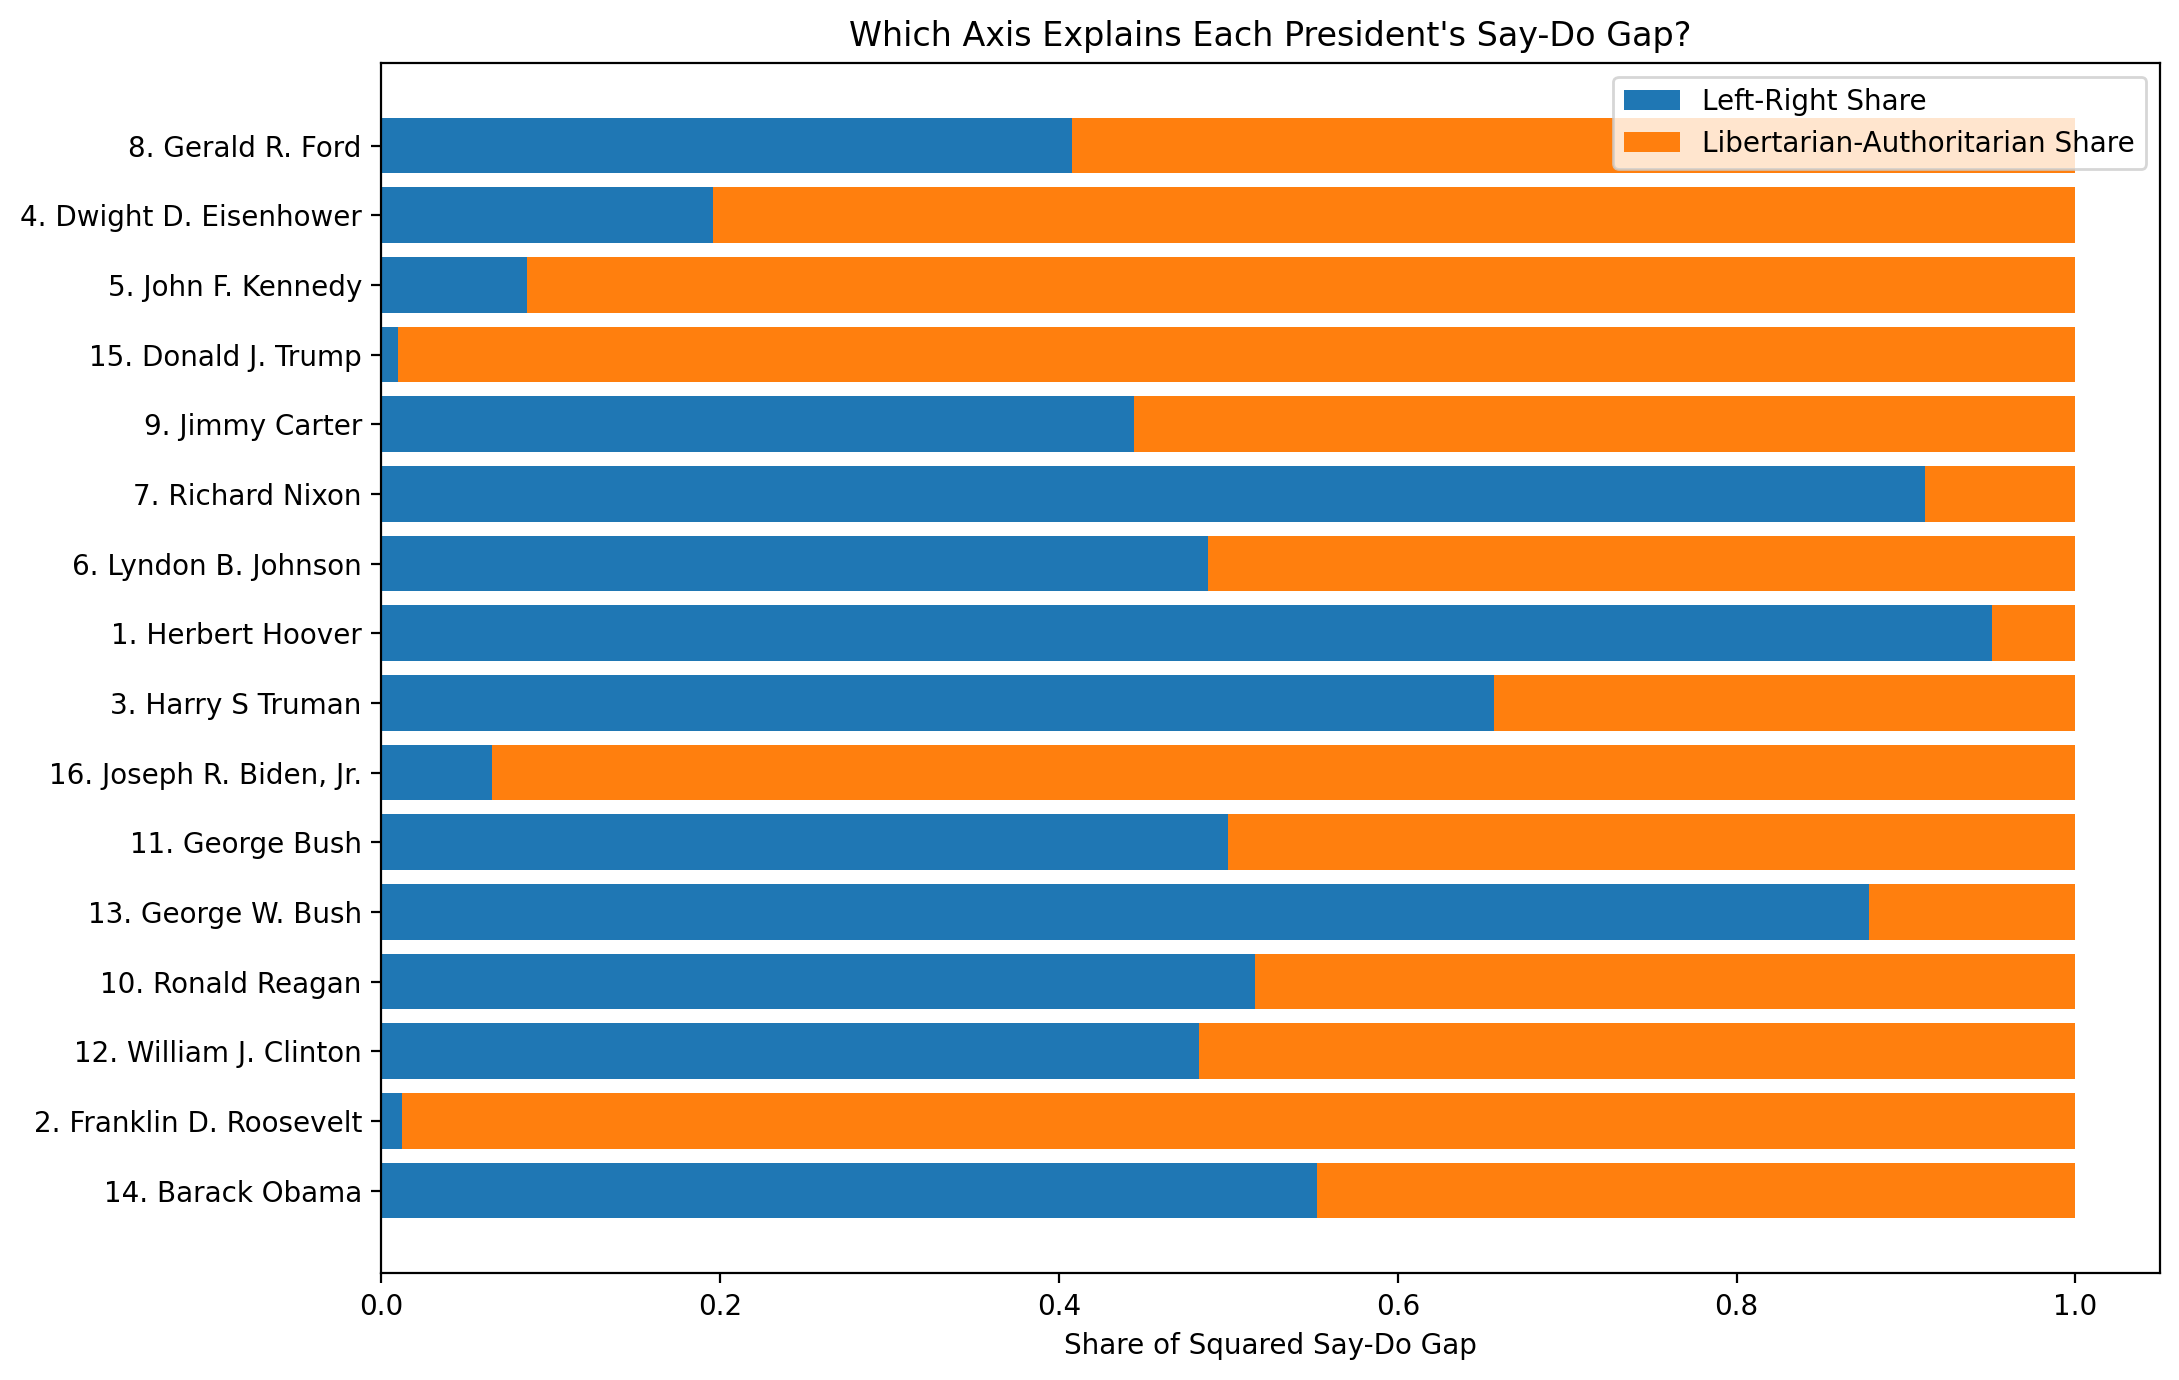

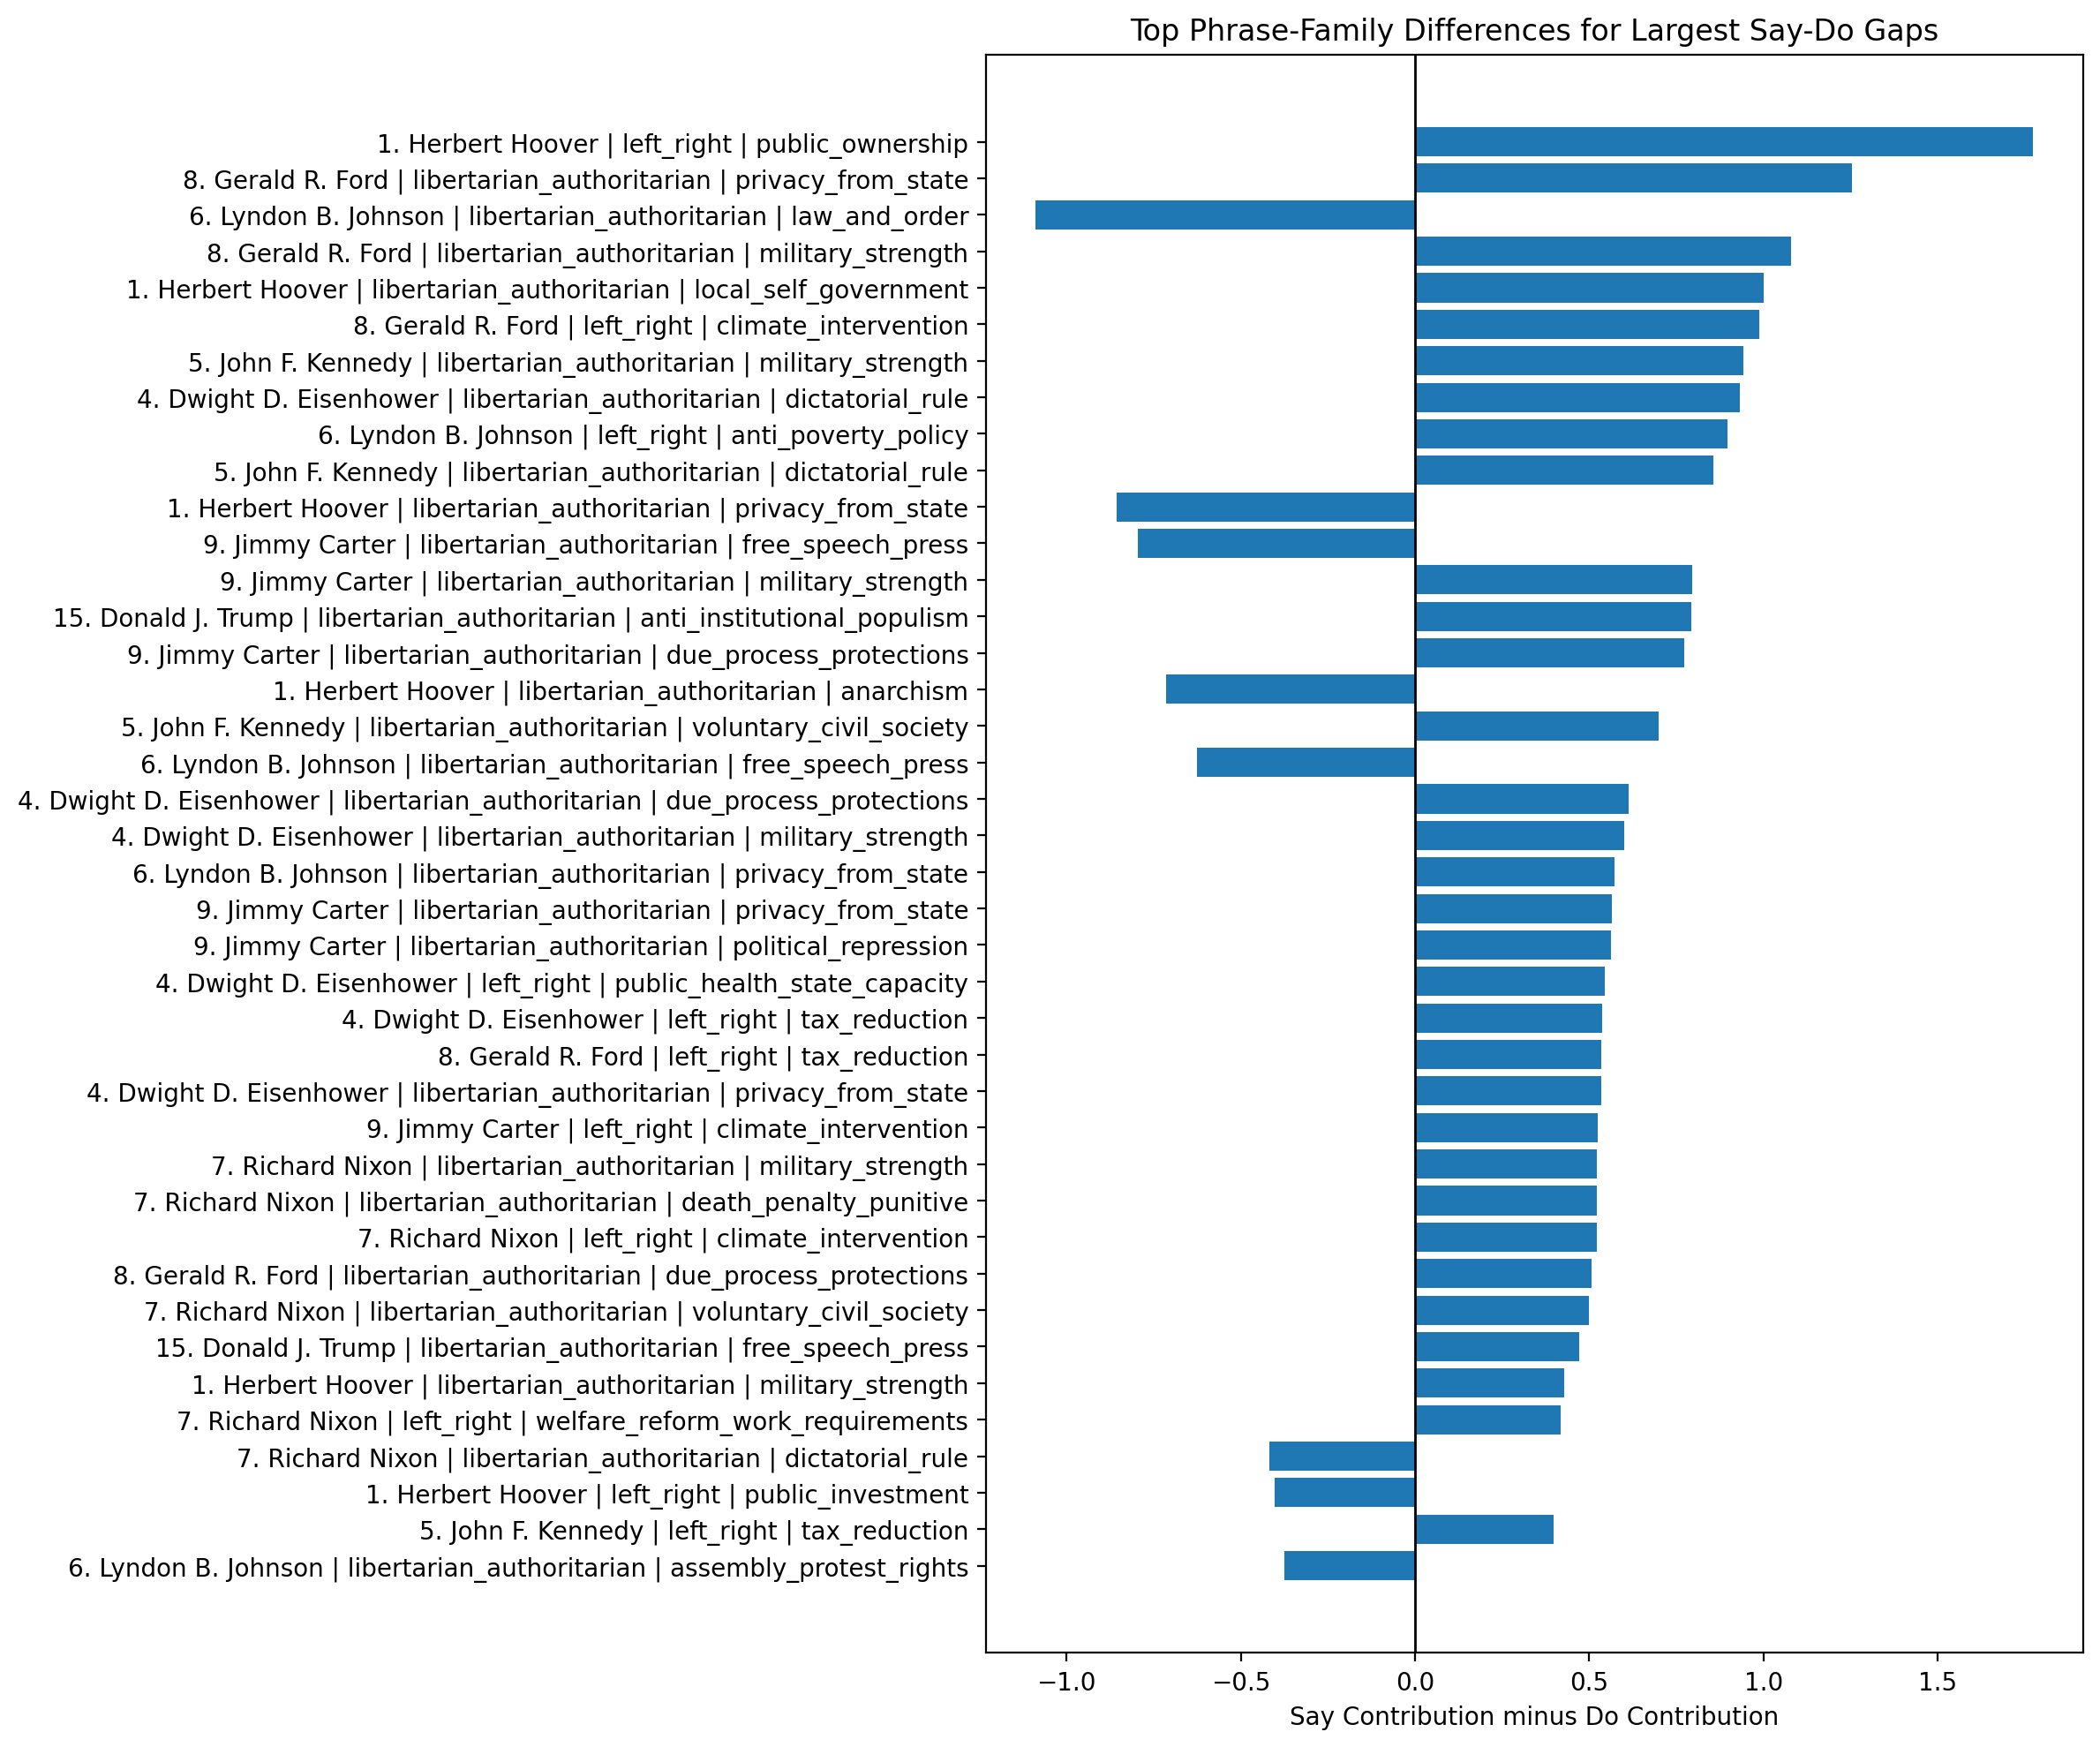

Gap explanation audit complete.

Saved files:
process_outputs\gap_explanation_outputs\president_gap_axis_decomposition.csv
process_outputs\gap_explanation_outputs\president_family_axis_contribution.csv
process_outputs\gap_explanation_outputs\president_say_do_family_delta_explanation.csv
process_outputs\gap_explanation_outputs\top_president_gap_explanations.csv
process_outputs\gap_explanation_outputs\say_do_gap_explanation_workbook.xlsx
process_outputs\gap_explanation_outputs\gap_axis_decomposition_ranked.png
process_outputs\gap_explanation_outputs\top_family_deltas_largest_gaps.png

AXIS-LEVEL GAP DECOMPOSITION


,gap_rank_largest_gap_1,alignment_rank_smallest_gap_1,president_number,president,say_x_left_right,do_x_left_right,left_right_difference,left_right_gap_share,say_y_libertarian_authoritarian,do_y_libertarian_authoritarian,lib_auth_difference,lib_auth_gap_share,main_gap_axis,say_do_gap
0,1,16,8,Gerald R. Ford,1.250000,-1.937500,3.187500,0.407944,1.840000,-2.000000,3.840000,0.592056,libertarian_authoritarian,4.990567
1,2,15,4,Dwight D. Eisenhower,0.573394,-0.914286,1.487680,0.195973,1.013333,-2.000000,3.013333,0.804027,libertarian_authoritarian,3.360561
2,3,14,5,John F. Kennedy,0.433824,-0.441860,0.875684,0.085870,2.057143,-0.800000,2.857143,0.914130,libertarian_authoritarian,2.988325
3,4,13,15,Donald J. Trump,0.663768,0.395349,0.268419,0.010092,2.040816,-0.617647,2.658463,0.989908,libertarian_authoritarian,2.671980
4,5,12,9,Jimmy Carter,1.180873,-0.422680,1.603554,0.444530,0.459184,-1.333333,1.792517,0.555470,libertarian_authoritarian,2.405099
5,6,11,7,Richard Nixon,1.279070,-0.895652,2.174722,0.911524,0.260870,-0.416667,0.677536,0.088476,left_right,2.277822
6,7,10,6,Lyndon B. Johnson,-0.088435,-1.510204,1.421769,0.488147,-0.750000,0.705882,-1.455882,0.511853,libertarian_authoritarian,2.034950
7,8,9,1,Herbert Hoover,-0.461538,-2.341463,1.879925,0.950596,-1.428571,-1.000000,-0.428571,0.049404,left_right,1.928157
8,9,8,3,Harry S Truman,0.081818,-1.265823,1.347641,0.656841,-0.900000,0.074074,-0.974074,0.343159,left_right,1.662816
9,10,7,16,"Joseph R. Biden, Jr.",-0.637255,-1.059701,0.422447,0.065444,-0.133333,-1.729730,1.596396,0.934556,libertarian_authoritarian,1.651346



TOP FAMILY EXPLANATIONS FOR LARGEST GAPS


,gap_rank_largest_gap_1,president_number,president,axis,direction,family,theme,say_axis_score_contribution,do_axis_score_contribution,say_minus_do_contribution,abs_say_do_contribution_delta,say_hits,do_hits,say_do_gap,main_gap_axis
0,1,8,Gerald R. Ford,left_right,left,climate_intervention,climate_state_action,-0.042857,-1.031250,0.988393,0.988393,2.0,11.0,4.990567,libertarian_authoritarian
1,1,8,Gerald R. Ford,left_right,right,tax_reduction,tax_market_right,0.535714,0.000000,0.535714,0.535714,25.0,0.0,4.990567,libertarian_authoritarian
2,1,8,Gerald R. Ford,left_right,right,free_market,market_liberalism,0.342857,0.000000,0.342857,0.342857,16.0,0.0,4.990567,libertarian_authoritarian
3,1,8,Gerald R. Ford,left_right,left,labor_union_power,labor_power,-0.064286,-0.375000,0.310714,0.310714,3.0,4.0,4.990567,libertarian_authoritarian
4,1,8,Gerald R. Ford,left_right,right,energy_independence_fossil,energy_market_right,0.314286,0.062500,0.251786,0.251786,22.0,1.0,4.990567,libertarian_authoritarian
5,1,8,Gerald R. Ford,left_right,left,public_health_state_capacity,public_health,-0.014286,-0.250000,0.235714,0.235714,1.0,4.0,4.990567,libertarian_authoritarian
6,1,8,Gerald R. Ford,left_right,right,fiscal_austerity,fiscal_conservatism,0.235714,0.000000,0.235714,0.235714,11.0,0.0,4.990567,libertarian_authoritarian
7,1,8,Gerald R. Ford,left_right,left,anti_poverty_policy,anti_poverty,-0.085714,-0.281250,0.195536,0.195536,4.0,3.0,4.990567,libertarian_authoritarian
8,1,8,Gerald R. Ford,libertarian_authoritarian,libertarian,privacy_from_state,privacy_rights,-0.080000,-1.333333,1.253333,1.253333,1.0,2.0,4.990567,libertarian_authoritarian
9,1,8,Gerald R. Ford,libertarian_authoritarian,authoritarian,military_strength,militarism_security,1.080000,0.000000,1.080000,1.080000,9.0,0.0,4.990567,libertarian_authoritarian


In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 400)
pd.set_option("display.max_rows", 200)

OUTPUT_DIR = Path("process_outputs")
EXPLAIN_DIR = OUTPUT_DIR / "gap_explanation_outputs"
EXPLAIN_DIR.mkdir(parents=True, exist_ok=True)

family_hits_path = OUTPUT_DIR / "dictionary_family_hits_FINAL.csv"
gap_scores_path = OUTPUT_DIR / "dictionary_say_do_gap_scores_FINAL.csv"
scores_path = OUTPUT_DIR / "dictionary_president_corpus_scores_FINAL.csv"

axis_decomp_output = EXPLAIN_DIR / "president_gap_axis_decomposition.csv"
family_contribution_output = EXPLAIN_DIR / "president_family_axis_contribution.csv"
family_delta_output = EXPLAIN_DIR / "president_say_do_family_delta_explanation.csv"
top_explanation_output = EXPLAIN_DIR / "top_president_gap_explanations.csv"
excel_output = EXPLAIN_DIR / "say_do_gap_explanation_workbook.xlsx"

axis_plot_output = EXPLAIN_DIR / "gap_axis_decomposition_ranked.png"
top_family_plot_output = EXPLAIN_DIR / "top_family_deltas_largest_gaps.png"

family_hits = pd.read_csv(family_hits_path, encoding="utf-8-sig")
gap_scores = pd.read_csv(gap_scores_path, encoding="utf-8-sig")
scores = pd.read_csv(scores_path, encoding="utf-8-sig")

gap_scores["left_right_difference"] = gap_scores["say_x_left_right"] - gap_scores["do_x_left_right"]
gap_scores["lib_auth_difference"] = gap_scores["say_y_libertarian_authoritarian"] - gap_scores["do_y_libertarian_authoritarian"]

gap_scores["left_right_squared_contribution"] = gap_scores["left_right_difference"] ** 2
gap_scores["lib_auth_squared_contribution"] = gap_scores["lib_auth_difference"] ** 2
gap_scores["total_squared_gap"] = gap_scores["left_right_squared_contribution"] + gap_scores["lib_auth_squared_contribution"]

gap_scores["left_right_gap_share"] = np.where(
    gap_scores["total_squared_gap"] > 0,
    gap_scores["left_right_squared_contribution"] / gap_scores["total_squared_gap"],
    0
)

gap_scores["lib_auth_gap_share"] = np.where(
    gap_scores["total_squared_gap"] > 0,
    gap_scores["lib_auth_squared_contribution"] / gap_scores["total_squared_gap"],
    0
)

gap_scores["main_gap_axis"] = np.where(
    gap_scores["left_right_gap_share"] >= gap_scores["lib_auth_gap_share"],
    "left_right",
    "libertarian_authoritarian"
)

axis_decomp = gap_scores[
    [
        "gap_rank_largest_gap_1",
        "alignment_rank_smallest_gap_1",
        "president_number",
        "president",
        "say_x_left_right",
        "do_x_left_right",
        "left_right_difference",
        "left_right_gap_share",
        "say_y_libertarian_authoritarian",
        "do_y_libertarian_authoritarian",
        "lib_auth_difference",
        "lib_auth_gap_share",
        "main_gap_axis",
        "say_do_gap",
    ]
].sort_values("gap_rank_largest_gap_1").reset_index(drop=True)

axis_totals = (
    family_hits
    .groupby(["president", "corpus_type", "axis"], as_index=False)
    .agg(total_axis_hits=("hits", "sum"))
)

family_contrib = family_hits.merge(
    axis_totals,
    on=["president", "corpus_type", "axis"],
    how="left"
)

family_contrib["axis_score_contribution"] = np.where(
    family_contrib["total_axis_hits"] > 0,
    family_contrib["signed_weighted_hits"] / family_contrib["total_axis_hits"],
    0
)

family_contrib["abs_axis_score_contribution"] = family_contrib["axis_score_contribution"].abs()

family_contrib = family_contrib[
    [
        "president_number",
        "president",
        "corpus_type",
        "axis",
        "direction",
        "family",
        "theme",
        "hits",
        "weighted_hits",
        "signed_weighted_hits",
        "total_axis_hits",
        "axis_score_contribution",
        "abs_axis_score_contribution",
    ]
].copy()

say_contrib = (
    family_contrib[family_contrib["corpus_type"].eq("say")]
    .rename(columns={
        "hits": "say_hits",
        "weighted_hits": "say_weighted_hits",
        "signed_weighted_hits": "say_signed_weighted_hits",
        "axis_score_contribution": "say_axis_score_contribution",
        "abs_axis_score_contribution": "say_abs_axis_score_contribution",
    })
    .drop(columns=["corpus_type"])
)

do_contrib = (
    family_contrib[family_contrib["corpus_type"].eq("do")]
    .rename(columns={
        "hits": "do_hits",
        "weighted_hits": "do_weighted_hits",
        "signed_weighted_hits": "do_signed_weighted_hits",
        "axis_score_contribution": "do_axis_score_contribution",
        "abs_axis_score_contribution": "do_abs_axis_score_contribution",
    })
    .drop(columns=["corpus_type"])
)

merge_cols = [
    "president_number",
    "president",
    "axis",
    "direction",
    "family",
    "theme",
]

family_delta = say_contrib.merge(
    do_contrib,
    on=merge_cols,
    how="outer"
)

fill_cols = [
    "say_hits",
    "say_weighted_hits",
    "say_signed_weighted_hits",
    "say_axis_score_contribution",
    "say_abs_axis_score_contribution",
    "do_hits",
    "do_weighted_hits",
    "do_signed_weighted_hits",
    "do_axis_score_contribution",
    "do_abs_axis_score_contribution",
]

for col in fill_cols:
    family_delta[col] = family_delta[col].fillna(0)

family_delta["say_minus_do_contribution"] = (
    family_delta["say_axis_score_contribution"]
    - family_delta["do_axis_score_contribution"]
)

family_delta["abs_say_do_contribution_delta"] = family_delta["say_minus_do_contribution"].abs()

family_delta = family_delta.merge(
    axis_decomp[
        [
            "president",
            "gap_rank_largest_gap_1",
            "say_do_gap",
            "main_gap_axis",
            "left_right_gap_share",
            "lib_auth_gap_share",
        ]
    ],
    on="president",
    how="left"
)

family_delta = family_delta.sort_values(
    [
        "gap_rank_largest_gap_1",
        "president_number",
        "axis",
        "abs_say_do_contribution_delta",
    ],
    ascending=[True, True, True, False]
).reset_index(drop=True)

top_gap_presidents = (
    axis_decomp
    .sort_values("say_do_gap", ascending=False)
    .head(8)["president"]
    .tolist()
)

top_explanations = (
    family_delta[
        family_delta["president"].isin(top_gap_presidents)
    ]
    .sort_values(
        [
            "gap_rank_largest_gap_1",
            "axis",
            "abs_say_do_contribution_delta",
        ],
        ascending=[True, True, False]
    )
    .groupby(["president", "axis"], as_index=False)
    .head(8)
    .reset_index(drop=True)
)

axis_decomp.to_csv(axis_decomp_output, index=False, encoding="utf-8-sig")
family_contrib.to_csv(family_contribution_output, index=False, encoding="utf-8-sig")
family_delta.to_csv(family_delta_output, index=False, encoding="utf-8-sig")
top_explanations.to_csv(top_explanation_output, index=False, encoding="utf-8-sig")

plot_axis = axis_decomp.sort_values("say_do_gap", ascending=True).copy()
plot_axis["label"] = plot_axis["president_number"].astype(int).astype(str) + ". " + plot_axis["president"]

plt.figure(figsize=(11, 7), dpi=200)
plt.barh(plot_axis["label"], plot_axis["left_right_gap_share"], label="Left-Right Share")
plt.barh(
    plot_axis["label"],
    plot_axis["lib_auth_gap_share"],
    left=plot_axis["left_right_gap_share"],
    label="Libertarian-Authoritarian Share"
)
plt.xlabel("Share of Squared Say-Do Gap")
plt.title("Which Axis Explains Each President's Say-Do Gap?")
plt.legend()
plt.tight_layout()
plt.savefig(axis_plot_output, bbox_inches="tight")
plt.show()

plot_family = top_explanations.copy()
plot_family["label"] = (
    plot_family["president_number"].astype(int).astype(str)
    + ". "
    + plot_family["president"]
    + " | "
    + plot_family["axis"]
    + " | "
    + plot_family["family"]
)

plot_family = plot_family.sort_values("abs_say_do_contribution_delta", ascending=True).tail(40)

plt.figure(figsize=(12, 10), dpi=200)
plt.barh(plot_family["label"], plot_family["say_minus_do_contribution"])
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Say Contribution minus Do Contribution")
plt.title("Top Phrase-Family Differences for Largest Say-Do Gaps")
plt.tight_layout()
plt.savefig(top_family_plot_output, bbox_inches="tight")
plt.show()

with pd.ExcelWriter(excel_output, engine="openpyxl") as writer:
    axis_decomp.to_excel(writer, sheet_name="axis_gap_decomposition", index=False)
    family_contrib.to_excel(writer, sheet_name="family_contributions", index=False)
    family_delta.to_excel(writer, sheet_name="family_say_do_deltas", index=False)
    top_explanations.to_excel(writer, sheet_name="top_gap_explanations", index=False)
    gap_scores.to_excel(writer, sheet_name="gap_scores", index=False)
    scores.to_excel(writer, sheet_name="president_scores", index=False)

print("Gap explanation audit complete.")

print("\nSaved files:")
for path in [
    axis_decomp_output,
    family_contribution_output,
    family_delta_output,
    top_explanation_output,
    excel_output,
    axis_plot_output,
    top_family_plot_output,
]:
    print(path)

print("\nAXIS-LEVEL GAP DECOMPOSITION")
display(axis_decomp)

print("\nTOP FAMILY EXPLANATIONS FOR LARGEST GAPS")
display(
    top_explanations[
        [
            "gap_rank_largest_gap_1",
            "president_number",
            "president",
            "axis",
            "direction",
            "family",
            "theme",
            "say_axis_score_contribution",
            "do_axis_score_contribution",
            "say_minus_do_contribution",
            "abs_say_do_contribution_delta",
            "say_hits",
            "do_hits",
            "say_do_gap",
            "main_gap_axis",
        ]
    ]
)